# **The Single-File Test: Longitudinal Evaluation of LLM Web Generation Under a First-Output-Only and Social Protocol**

This research studies how frontier LLMs generate complete web applications when tested through **public web UIs**, mirroring how non-technical end users naturally interact with these systems. It focuses on first-output reliability, holistic application quality, and how technical performance translates into real-world social engagement.

This study is best read as an **observational comparison of public interfaces under a fixed user protocol**, not as a clean causal benchmark of intrinsic model capability. Interface versions changed over time, Claude was accessed through `arena.ai`, and timing conditions could not be perfectly standardized across the eight-week collection window from December 10, 2025 through February 4, 2026.

---

### **Supervised Learning**



#### **Data:** `12/10/2025 - 02/04/2026`


#### **Code:** [Github](https://github.com/diegocp01/html_ai_battle)


#### **By:** [Diego Cabezas](https://www.linkedin.com/in/diego-cabezas-msc-96136475/)

---

### **Dataset:** [<button style="background-color: #4CAF50; color: white; padding: 10px 20px; text-align: center; text-decoration: none; display: inline-block; font-size: 16px;">Dataset file</button>](https://docs.google.com/spreadsheets/d/1txE-fjK28aDZmN_uMXsaONNofNVAhD1K/edit?usp=sharing&ouid=111148286428280258126&rtpof=true&sd=true)




## Scope

- The tracker currently contains **17 complete experiments** (`68 rows = 17 experiments × 4 models`).
- The fixed user protocol is: **prompt -> public chat UI -> first HTML output -> browser execution -> human score + Gemini score -> social posting -> 24-hour platform data collection**.
- Although the user workflow, access websites, posting schedule, and 24-hour collection window were standardized, the study remains observational because public model availability, provider-side interface behavior, and platform context could not be experimentally randomized or held constant across the full collection period.


## Predicting 24-Hour X(Twitter) Impressions from Technical Generation Metrics

**Goal:** For a single "HTML AI Battle" experiment, test whether a small set of **pre-publication technical generation variables** can predict **24-hour X impressions in this dataset**. The focus here is reasoning time, reasoning share, audio engine, and song tempo under the same collection protocol.

**Methodology:** Because the experiment-level sample is very small (`N = 17`), this model is treated as **exploratory** and statistically underpowered rather than definitive. A full-sample Lasso screen is used **descriptively** to narrow candidate variables, and the final Ridge model is evaluated with **Leave-One-Out Cross-Validation (LOOCV)** that refits scaling inside each training fold after a full-sample exploratory feature screen. With only 17 experiments, the resulting error estimates should be read as unstable descriptive evidence of weak predictive signal, not as precise generalizable forecasting performance.

**Target Variable (Log-Scale Regression):**

* **$\log(1 + \text{X Impressions})$:** Applied to stabilize the heavy-tailed distribution caused by a few very large reach outliers.

**Final Evaluated Features:** The final four-feature path keeps only pre-publication variables:

* **ReasonTime_mean:** The average visible public-interface reasoning/thinking time in seconds.
* **Reasoning_Ratio_mean:** The average share of total response time spent thinking.
* **Suno_version:** Binary encoding of the Suno version used for the soundtrack (`v5` vs. `v4.5`).
* **Song_BPM:** The tempo of the background AI-generated track.

**Question Tested:** Do these tracked technical and audio variables help predict 24-hour X reach in this dataset?


## Predicting HTML Lines from Prompt and Model Identity

**Goal:** Given a single "HTML AI Battle" generation record, this project aims to quantify whether **code verbosity**, measured as **Lines of HTML**, can be predicted from the **task wording** and the **model used to generate the output**. Unlike the virality model, which focuses on post-publication engagement, this analysis examines a direct generation outcome, asking whether some prompts naturally induce longer code and whether certain model families tend to produce more verbose outputs.

**Methodology:** This task is framed as a **supervised regression problem** on the **68 model-level generations** in the tracker. The notebook compares four baselines under **Leave-One-Experiment-Out** validation grouped by **Experiment ID**: **input words only**, **model family only**, **input words + model family**, and **TF-IDF prompt text + input words + model family**, all fitted with **Ridge Regression (L2 regularization)**.

**Target Variable (Regression):**

* **Lines of HTML:** The total number of HTML lines generated by a model for a given experiment, used here as a proxy for **code verbosity** and implementation length.

**Candidate Feature Sets Tested:**

* **Input Word Count:** A structured measure of prompt length, used to test whether longer prompts systematically lead to longer outputs.
* **Model Family:** A categorical identifier used to test whether verbosity differs systematically across model families.
* **Prompt Text:** The full natural-language instruction given to the model, encoded with TF-IDF features only in the prompt-aware comparison pipeline.

**Evaluation Metrics:**

* **MAE:** Mean Absolute Error, for average prediction error in HTML lines.
* **RMSE:** Root Mean Squared Error, to penalize larger misses more heavily.
* **R²:** To estimate how much variance in HTML length is explained out of sample.

**Key Hypothesis Tested:** Is the length of generated HTML primarily driven by the **prompt itself** or by the **identity of the model** that generates it? In the results below, the strongest signal comes from **model family**: the **model-family-only** baseline performed best, and adding prompt length or TF-IDF prompt text did not improve performance under grouped validation.

<a name='1'></a>
# 1 - Exploratory Data Analysis

<a name='1.1'></a>
## 1.1 - Data input

The data comes from "[HTML AI Battle](https://github.com/diegocp01/html_ai_battle)" longitudinal experiments and currently contains [17] experiments (each with 4 models) and 48 variables (model metadata, generation stats, quality scores, and 24-hour engagement on X (Twitter), TikTok, and YouTube).

(Data was collected manually twice per week from the public web UIs of each model. Claude Opus runs were accessed through arena.ai (previously called LMArena) instead of Anthropic's native interface. The 24-hour platform metrics were collected 24 hours after each video was posted.)

Timing variables were measured with a custom Python timing tool while using the public web interfaces. **LLM Response Time (s)** is the total time from submitting the prompt until the model finished writing its answer. **LLM Reasoning Time (s)** is the time from submitting the prompt until the model stopped showing its reasoning/thinking phase and began writing the final answer. Because all tested models were reasoning models, the reasoning timer starts at prompt submission and stops when the final answer begins. These timings describe the user-visible interaction, not provider-internal compute time.

Human scores are primary author judgments on a **0-10** scale with decimal values allowed. Gemini scores are secondary blind-chat judgments prompted on a **1-10 integer** scale. Both the human evaluator and Gemini judged the rendered browser recording only, not the underlying HTML/CSS/JavaScript code. In other words, scoring was based on videos of each generated app running in the browser. Gemini was used as the secondary judge because, at the time of evaluation, it was the available model in this workflow that could accept video input. Because the human evaluator was not blinded to model identity while Gemini was blinded, and because the human used decimal 0-10 scores while Gemini was prompted for integer 1-10 scores, Gemini-human comparisons should be interpreted as directional agreement and leniency checks rather than as a perfectly controlled judge-to-judge reliability test.

### **Column Details**

1. **Experiment ID**
   Unique identifier for each experiment **[name_posteddateMMYY]** (e.g., `flappy_bird_1210`, `dvd_logo_1220`).

2. **LLM Model**
   Specific model used for the experiment (e.g., `gpt-5.2-extended-thinking`, `gemini-3-pro`, `grok-4.1-thinking`, `opus-4.5-thinking-32k`).

3. **Model Family**
   High-level model family classification.
   Values: `GPT`, `Gemini`, `Grok`, `Claude`.

4. **Experiment Type**
   Type of task requested.
   Values: `game`, `simulation`.

5. **Visual Type**
   Describes the perceptual complexity of the rendered scene based on focal dominance and visual density.
   Values:
   
   `simple` One dominant visual element occupying most of the visual space, clear focal point, low background noise.


   `complex` Multiple competing elements, dispersed focal points, or high visual density requiring greater visual parsing.  

6. **Prompt**
   Full natural-language prompt given to the model (text).

7. **Input Word Count**
   Number of words in the prompt.

8. **Platform**
   Interface used to access the model for that run.
   Values: `Web UI`, `LMArena`.

---

**Generation Timing and Complexity**

9. **LLM Reasoning Time (s)**
   Time from submitting the prompt until the model stopped showing its reasoning/thinking phase and began writing the final answer (seconds). This is a user-facing UI measurement, not a provider-internal compute trace.

10. **LLM Response Time (s)**
   Elapsed wall-clock time from submitting the prompt until the model finished writing its answer, including the reasoning phase (seconds).

11. **Date Generated**
   Calendar date when the experiment was generated using each LLM Web App UI.

12. **Time ET of the Generation**
    Clock time (Eastern Time) when the generation was executed.

13. **Lines of HTML**
    Number of lines in the generated HTML output.

---

**Reasoning Analysis (Model Output Internals)**

14. **Reasoning Total words**
    Total number of words in the reasoning section.

15. **Reasoning Total characters**
    Total character count of the reasoning section.

16. **Reasoning Total sentences**
    Total number of sentences in the reasoning section.

17. **Reasoning top keyword**
    Most frequent keyword appearing in the reasoning text.

18. **Reasoning top keyword repetitions**
    Number of times the top keyword appears.

19. **Code in Reasoning?**
    Whether code appears inside the reasoning section.
    Values: `y`, `n` (binary).

---

**Human Evaluation Scores (Primary)**

20. **prompt_adherence_score (0–10)**
    Human-assigned author score measuring how well the output follows the prompt; decimal values are allowed.

21. **functional_correctness_score (0–10)**
    Human-assigned author score evaluating whether the output works as intended; decimal values are allowed.

22. **ui_score (0–10)**
    Human-assigned author score evaluating UI/visual quality; decimal values are allowed.

23. **Performance Score (0–10)**
    Overall human evaluation score (aggregated judgment).

---

**Secondary / Gemini-Based Evaluation Scores**

24. **gemini_pa (0–10)**
    Gemini-assigned prompt adherence score from a secondary blind chat. Gemini was prompted for 1-10 integer scores.

25. **gemini_fc (0–10)**
    Gemini-assigned functional correctness score from a secondary blind chat. Gemini was prompted for 1-10 integer scores.

26. **gemini_ui (0–10)**
    Gemini-assigned UI quality score from a secondary blind chat. Gemini was prompted for 1-10 integer scores.

27. **gemini perf (0–10)**
    Gemini-assigned overall performance score.

---

**Audio and Song Packaging**

28. **Male / Female Song's Voice**
    Voice gender used in the soundtrack.
    Values: `m`, `f`.

29. **Song Key**
    Musical key of the song.
    Examples: `G Major`, `G minor`, `A major`, `E♭ major`.

30. **Song BPM**
    Tempo of the song in beats per minute.

31. **Song style**
    Style of the song e.g. Hip Hop.

32. **Lyrics number of words**
    Number of words in the song lyrics.

33. **LLM used for song**
    Model used to generate the song lyrics.

34. **Suno version**
    Version of the AI tool Suno used for music generation (e.g., `4.5-all, 5`).

---

**Posting Context (Distribution Metadata)**

35. **Date posted**
    Calendar date when the video was posted.

36. **Day of the week posted**
    Day of the week the content was posted.
    Examples: `Wednesday`, `Saturday`.

37. **Time ET posted on X**
    Clock time (Eastern Time) when the post was published on X.

38. **Video Duration (s)**
    Length of the video in the post in seconds.

---

**Audience Size at Posting Time**

39. **X Followers posted**
    Number of X followers at posting time.

40. **Tik Tok Followers posted**
    Number of TikTok followers at posting time.

41. **Youtube Followers posted**
    Number of YouTube subscribers at posting time.

---

**Engagement Targets (24h Post-Publish)**

42. **X Impressions (24 h)**
    Number of impressions on X within 24 hours.

43. **X Likes (24h)**
    Number of likes on X within 24 hours.

44. **X Shares (24h)**
    Number of shares on X within 24 hours.

45. **Tik Tok Views (24 h)**
    Number of TikTok views within 24 hours.

46. **Tik Tok Likes (24h)**
    Number of TikTok likes within 24 hours.

47. **Youtube short views (24 h)**
    Number of YouTube Shorts views within 24 hours.

48. **Youtube short Likes (24h)**
    Number of YouTube Shorts likes within 24 hours.


### Column grouping schema (Experiment-level vs Model-level)

#### Experiment columns (shared context, does not vary by model)

* Experiment ID
* Experiment Type
* Visual Type
* Prompt
* Input Word Count
* Date posted
* Day of the week posted
* Time ET posted on X
* Video Duration (s)
* X Followers posted
* Tik Tok Followers posted
* Youtube Followers posted
* X Impressions (24 h)
* X Likes (24h)
* X Shares (24h)
* Tik Tok Views (24 h)
* Tik Tok Likes (24h)
* Youtube short views (24 h)
* Youtube short Likes (24h)
* Male / Female Song's Voice
* Song Key
* Song BPM
* Song style
* Lyrics number of words
* LLM used for song
* Suno version

---

#### Model columns (varies per model)

* LLM Model
* Model Family
* Platform
* LLM Reasoning Time (s)
* LLM Response Time (s)
* Date Generated
* Time ET of the Generation
* Lines of HTML
* Reasoning Total words
* Reasoning Total characters
* Reasoning Total sentences
* Reasoning top keyword
* Reasoning top keyword repetitions
* Code in Reasoning?
* prompt_adherence_score (0–10)
* functional_correctness_score (0–10)
* ui_score (0–10)
* Performance Score (0–10)
* gemini_pa (0–10)
* gemini_fc (0–10)
* gemini_ui (0–10)
* gemini perf (0–10)

### Data Ingestion

In [ ]:
import warnings
import pandas as pd

warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive, and thus cannot be shown")
warnings.filterwarnings("ignore", message="More than 20 figures have been opened")
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message=r"The parameters have been moved from the Blocks constructor to the launch\(\) method in Gradio 6.0: theme\.")

df = pd.read_excel("experiment_tracker.xlsx")

print(f'Loaded df shape: {df.shape}')
df.head()

Loaded df shape: (68, 48)


,Experiment ID,LLM Model,Prompt,Experiment Type,Visual type,LLM Reasoning Time (s),LLM Response Time (s),Date Generated,Time ET of the Generation,Reasoning Total words,...,Tik Tok Followers posted,Youtube Followers posted,Video Duration (s),X Impressions (24 h),X Likes (24h),X Shares (24h),Tik Tok Views (24 h),Tik Tok Likes (24h),Youtube short views (24 h),Youtube short Likes (24h)
0,flappy_bird_1210,gpt-5.1-extended-thinking,Make a game like flappy bird using HTML/CSS/JS...,game,simple,44,106,2025-12-10,17:01:00,326,...,64,955,133,135606,433,22,259,9,265,3
1,flappy_bird_1210,gemini-3-pro,Make a game like flappy bird using HTML/CSS/JS...,game,simple,17,44,2025-12-10,16:54:00,261,...,64,955,133,135606,433,22,259,9,265,3
2,flappy_bird_1210,grok-4.1-thinking,Make a game like flappy bird using HTML/CSS/JS...,game,simple,11,19,2025-12-10,17:50:00,114,...,64,955,133,135606,433,22,259,9,265,3
3,flappy_bird_1210,opus-4.5-thinking-32k,Make a game like flappy bird using HTML/CSS/JS...,game,simple,61,124,2025-12-10,17:36:00,1363,...,64,955,133,135606,433,22,259,9,265,3
4,drifting_car_1213,gpt-5.2-extended-thinking,Create a 3D simulation of a formula 1 car perf...,simulation,simple,23,102,2025-12-11,19:33:00,229,...,70,959,63,206661,1396,78,14,0,106,0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 48 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Experiment ID                        68 non-null     str           
 1   LLM Model                            68 non-null     str           
 2   Prompt                               68 non-null     str           
 3   Experiment Type                      68 non-null     str           
 4   Visual type                          68 non-null     str           
 5   LLM Reasoning Time (s)               68 non-null     int64         
 6   LLM Response Time (s)                68 non-null     int64         
 7   Date Generated                       68 non-null     datetime64[us]
 8   Time ET of the Generation            68 non-null     object        
 9   Reasoning Total words                68 non-null     int64         
 10  Reasoning Total characters 

<a name='1.2'></a>
## 1.2 - Data Cleaning (EDA)

In [ ]:
# The columns with number aren't showing are numeric, same for the dates here we will convert them
numeric_cols = [
    'LLM Reasoning Time (s)', 'LLM Response Time (s)', 'Reasoning Total words',
    'Reasoning Total characters', 'Reasoning Total sentences', 'Reasoning top keyword repetitions',
    'Input Word Count', 'Lines of HTML', 'prompt_adherence_score (0-10)',
    'gemini_pa (0-10)', 'functional_correctness_score (0-10)', 'gemini_fc (0-10)',
    'ui_score (0-10)', 'gemini_ui (0-10)', 'Performance Score (0-10)',
    'gemini perf (0-10)', 'Song BPM', 'Lyrics number of words',
    'X Followers posted', 'Tik Tok Followers posted', 'Youtube Followers posted',
    'Video Duration (s)', 'X Impressions (24 h)', 'X Likes (24h)',
    'X Shares (24h)', 'Tik Tok Views (24 h)', 'Tik Tok Likes (24h)',
    'Youtube short views (24 h)', 'Youtube short Likes (24h)'
]

time_cols = [
    'Time ET of the Generation',
    'Time ET posted on X'
]

binary_cols = {
    'Code in Reasoning?': {'y': 1, 'n': 0},
    "Male / Female Song's Voice": {'m': 1, 'f': 0},
    'Experiment Type': {'game': 1, 'simulation': 0},
    'Visual type': {'simple': 1, 'complex': 0},
    'Platform': {'Web UI': 1, 'LMArena': 0},
    'Suno version': {'4.5-all': 1, '5': 0},
    'Day of the week posted': {'Wednesday': 1, 'Saturday': 0}
}

categorical_cols = [
    'LLM Model',
    'Model Family',
    'Song Key',
    'LLM used for song',
    'Song style'
]

datetime_cols = [
    'Date Generated', 'Date posted'
]

print("Numeric columns:", numeric_cols)
print("Datetime columns:", datetime_cols)
print("Time columns:", time_cols)
print("Binary columns:", list(binary_cols.keys()))
print("Categorical columns:", categorical_cols)

Numeric columns: ['LLM Reasoning Time (s)', 'LLM Response Time (s)', 'Reasoning Total words', 'Reasoning Total characters', 'Reasoning Total sentences', 'Reasoning top keyword repetitions', 'Input Word Count', 'Lines of HTML', 'prompt_adherence_score (0-10)', 'gemini_pa (0-10)', 'functional_correctness_score (0-10)', 'gemini_fc (0-10)', 'ui_score (0-10)', 'gemini_ui (0-10)', 'Performance Score (0-10)', 'gemini perf (0-10)', 'Song BPM', 'Lyrics number of words', 'X Followers posted', 'Tik Tok Followers posted', 'Youtube Followers posted', 'Video Duration (s)', 'X Impressions (24 h)', 'X Likes (24h)', 'X Shares (24h)', 'Tik Tok Views (24 h)', 'Tik Tok Likes (24h)', 'Youtube short views (24 h)', 'Youtube short Likes (24h)']
Datetime columns: ['Date Generated', 'Date posted']
Time columns: ['Time ET of the Generation', 'Time ET posted on X']
Binary columns: ['Code in Reasoning?', "Male / Female Song's Voice", 'Experiment Type', 'Visual type', 'Platform', 'Suno version', 'Day of the week po

In [ ]:
df['Time ET posted on X'].head(10)

0    20:19:00
1    20:19:00
2    20:19:00
3    20:19:00
4    07:55:00
5    07:55:00
6    07:55:00
7    07:55:00
8    16:12:00
9    16:12:00
Name: Time ET posted on X, dtype: object

In [ ]:
# =========================
# Numeric conversion
# =========================

for col in numeric_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(',', '', regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

# =========================
# Date conversion
# =========================

for col in datetime_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# =========================
# Time conversion (HH:MM:SS AM/PM → hour features)
# =========================

def parse_time_flexible(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()

    # Try 24-hour first: HH:MM:SS
    t24 = pd.to_datetime(s, format="%H:%M:%S", errors="coerce")

    # Fallback: 12-hour with AM/PM
    t12 = pd.to_datetime(s, format="%I:%M:%S %p", errors="coerce")

    # Combine (prefer 24h where available)
    return t24.fillna(t12)

for col in time_cols:
    if col in df.columns:
        parsed = parse_time_flexible(df[col])
        df[f"{col}_hour"] = parsed.dt.hour
        df[f"{col}_minute"] = parsed.dt.minute

# =========================
# Clean Suno version BEFORE mapping
# =========================
if "Suno version" in df.columns:
    s = df["Suno version"].astype(str).str.strip().str.lower()

    # normalize common variants to the exact keys your map expects
    s = s.replace({
        "4.5 all": "4.5-all",
        "4.5-all ": "4.5-all",
        "v4.5-all": "4.5-all",
        "4.5": "4.5-all",
        "5.0": "5",
        "v5": "5",
        "version 5": "5",
    })

    # turn empty-ish strings into real missing values
    s = s.replace({"": pd.NA, "nan": pd.NA, "none": pd.NA})

    df["Suno version"] = s

# =========================
# Binary encoding
# =========================

for col, mapping in binary_cols.items():
    if col in df.columns:
        df[col] = df[col].map(mapping).astype('Int64')

# =========================
# Force evaluation scores to float
# =========================

score_cols = [
    'prompt_adherence_score (0-10)',
    'gemini_pa (0-10)',
    'functional_correctness_score (0-10)',
    'gemini_fc (0-10)',
    'ui_score (0-10)',
    'gemini_ui (0-10)',
    'Performance Score (0-10)',
    'gemini perf (0-10)'
]

for col in score_cols:
    if col in df.columns:
        df[col] = df[col].astype(float)

# =========================
# Final validation
# =========================

print("Data type conversion complete.\n")
df.info()

Data type conversion complete.

<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 52 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Experiment ID                        68 non-null     str           
 1   LLM Model                            68 non-null     str           
 2   Prompt                               68 non-null     str           
 3   Experiment Type                      68 non-null     Int64         
 4   Visual type                          68 non-null     Int64         
 5   LLM Reasoning Time (s)               68 non-null     int64         
 6   LLM Response Time (s)                68 non-null     int64         
 7   Date Generated                       68 non-null     datetime64[us]
 8   Time ET of the Generation            68 non-null     object        
 9   Reasoning Total words                68 non-null     int64         


In [ ]:
df.head()

,Experiment ID,LLM Model,Prompt,Experiment Type,Visual type,LLM Reasoning Time (s),LLM Response Time (s),Date Generated,Time ET of the Generation,Reasoning Total words,...,X Likes (24h),X Shares (24h),Tik Tok Views (24 h),Tik Tok Likes (24h),Youtube short views (24 h),Youtube short Likes (24h),Time ET of the Generation_hour,Time ET of the Generation_minute,Time ET posted on X_hour,Time ET posted on X_minute
0,flappy_bird_1210,gpt-5.1-extended-thinking,Make a game like flappy bird using HTML/CSS/JS...,1,1,44,106,2025-12-10,17:01:00,326,...,433,22,259,9,265,3,17,1,20,19
1,flappy_bird_1210,gemini-3-pro,Make a game like flappy bird using HTML/CSS/JS...,1,1,17,44,2025-12-10,16:54:00,261,...,433,22,259,9,265,3,16,54,20,19
2,flappy_bird_1210,grok-4.1-thinking,Make a game like flappy bird using HTML/CSS/JS...,1,1,11,19,2025-12-10,17:50:00,114,...,433,22,259,9,265,3,17,50,20,19
3,flappy_bird_1210,opus-4.5-thinking-32k,Make a game like flappy bird using HTML/CSS/JS...,1,1,61,124,2025-12-10,17:36:00,1363,...,433,22,259,9,265,3,17,36,20,19
4,drifting_car_1213,gpt-5.2-extended-thinking,Create a 3D simulation of a formula 1 car perf...,0,1,23,102,2025-12-11,19:33:00,229,...,1396,78,14,0,106,0,19,33,7,55


In [ ]:
# -----------------------------
# Coverage and quality checks
# -----------------------------

tracker_experiments = sorted(df['Experiment ID'].dropna().unique())



print(f'Rows in tracker table: {len(df)}')
print(f'Unique experiments in tracker: {len(tracker_experiments)}')



rows_per_experiment = df['Experiment ID'].value_counts().sort_index()
print('\nRows per experiment (should be 4 each):')
print(rows_per_experiment.to_string())




Rows in tracker table: 68
Unique experiments in tracker: 17

Rows per experiment (should be 4 each):
Experiment ID
airplane_0117           4
backflip_1014           4
basketball_0131         4
blooming_flower_1217    4
dna_0124                4
dog_fetch_0103          4
drifting_car_1213       4
dvd_logo_1220           4
flappy_bird_1210        4
gravity_cloth_0107      4
new_years_1231          4
paper_airplane_0204     4
pirate_ship_0110        4
snake_0121              4
spaceship_1227          4
spongebob_0128          4
super_mario_1224        4


Target variables are continuous numeric -> Regression.

In [ ]:
# UNIQUE VALUES
df.nunique()

Experiment ID                          17
LLM Model                               5
Prompt                                 17
Experiment Type                         2
Visual type                             2
LLM Reasoning Time (s)                 49
LLM Response Time (s)                  62
Date Generated                         17
Time ET of the Generation              64
Reasoning Total words                  68
Reasoning Total characters             68
Reasoning Total sentences              34
Reasoning top keyword                  42
Reasoning top keyword repetitions      28
Input Word Count                       13
Lines of HTML                          65
Model Family                            4
Platform                                2
Code in Reasoning?                      2
prompt_adherence_score (0-10)          15
gemini_pa (0-10)                       10
functional_correctness_score (0-10)    16
gemini_fc (0-10)                        9
ui_score (0-10)                   

### Target Variables

#### Variable: X Impressions (24h)

In [ ]:
# X Impressions variable
# Unique values and their counts for the target variable
impressions_counts = (
    df["X Impressions (24 h)"]
    .value_counts(dropna=False)
    .sort_index()
)

print("Unique X Impressions (24 h) values and their counts:")
print(impressions_counts)


Unique X Impressions (24 h) values and their counts:
X Impressions (24 h)
214       4
346       4
851       4
2093      4
5502      8
15636     4
21741     4
24987     4
27182     4
30701     4
38167     4
75948     4
97813     4
135606    4
164249    4
206661    4
Name: count, dtype: int64


In [ ]:
# bins
target = "X Impressions (24 h)"

bins = [0, 50_000, 100_000, 150_000, 200_000, df[target].max() + 1]

binned_counts = (
    pd.cut(df[target], bins=bins, right=False)
      .value_counts()
      .sort_index()
)

print("Binned X Impressions (24 h) counts:")
print(binned_counts)


Binned X Impressions (24 h) counts:
X Impressions (24 h)
[0, 50000)          48
[50000, 100000)      8
[100000, 150000)     4
[150000, 200000)     4
[200000, 206662)     4
Name: count, dtype: int64


Binned X Impressions (24 h) counts at the experiment level:
X Impressions (24 h)
[0, 50000)          12
[50000, 100000)      2
[100000, 150000)     1
[150000, 200000)     1
[200000, 206662)     1
Name: count, dtype: int64


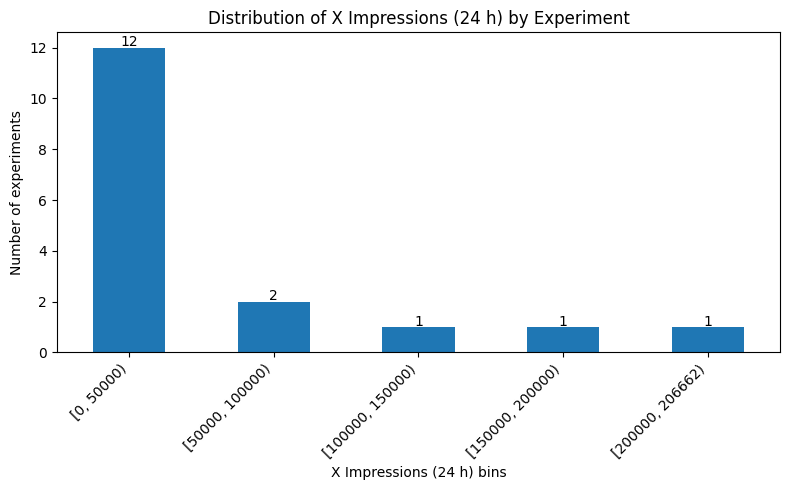

In [ ]:
# Experiment-level bins + plot
import matplotlib.pyplot as plt

target = "X Impressions (24 h)"

# keep one value per experiment
exp_impressions = (
    df.groupby("Experiment ID")[target]
      .first()
)

bins = [0, 50_000, 100_000, 150_000, 200_000, exp_impressions.max() + 1]

binned_counts_exp = (
    pd.cut(exp_impressions, bins=bins, right=False)
      .value_counts()
      .sort_index()
)

print("Binned X Impressions (24 h) counts at the experiment level:")
print(binned_counts_exp)

# plot
ax = binned_counts_exp.plot(kind="bar", figsize=(8, 5))

plt.title("Distribution of X Impressions (24 h) by Experiment")
plt.xlabel("X Impressions (24 h) bins")
plt.ylabel("Number of experiments")
plt.xticks(rotation=45, ha="right")

# add labels on bars
for i, v in enumerate(binned_counts_exp.values):
    ax.text(i, v + 0.05, str(v), ha="center")

plt.tight_layout()
plt.show()

In [ ]:
# verify the target is identical inside each experiment
target = "X Impressions (24 h)"

df.groupby("Experiment ID")[target].nunique().sort_values(ascending=False)


Experiment ID
airplane_0117           1
gravity_cloth_0107      1
spongebob_0128          1
spaceship_1227          1
snake_0121              1
pirate_ship_0110        1
paper_airplane_0204     1
new_years_1231          1
flappy_bird_1210        1
backflip_1014           1
dvd_logo_1220           1
drifting_car_1213       1
dog_fetch_0103          1
dna_0124                1
blooming_flower_1217    1
basketball_0131         1
super_mario_1224        1
Name: X Impressions (24 h), dtype: int64

#### Variable: Lines of HTML

Binned Lines of HTML counts:
Lines of HTML
[0, 100)        0
[100, 200)     13
[200, 300)      8
[300, 400)      9
[400, 500)      7
[500, 600)      9
[600, 1423)    22
Name: count, dtype: int64


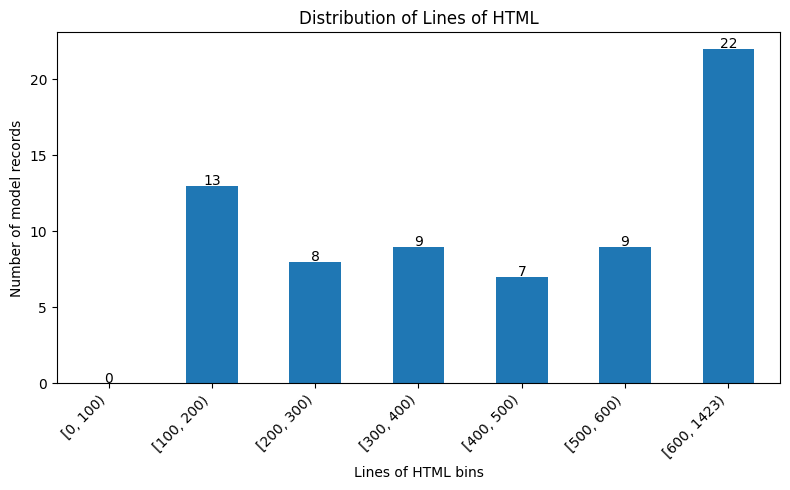

In [ ]:
# Target variable: HTML Lines of Code

target = "Lines of HTML"
bins = [0, 100, 200, 300, 400, 500, 600, df[target].max() + 1]

binned_counts = (
    pd.cut(df[target], bins=bins, right=False)
      .value_counts()
      .sort_index()
)

print("Binned Lines of HTML counts:")
print(binned_counts)

ax = binned_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Distribution of Lines of HTML")
plt.xlabel("Lines of HTML bins")
plt.ylabel("Number of model records")
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(binned_counts.values):
    ax.text(i, v + 0.05, str(v), ha="center")

plt.tight_layout()
plt.show()

Lines of HTML per experiment and model:
Model Family           GPT  Gemini  Grok  Claude
Experiment ID                                   
airplane_0117          838     208   190    1254
backflip_1014          827     414   179     587
basketball_0131        537     367   215     862
blooming_flower_1217   554     261   192     459
dna_0124               549     191   113     471
dog_fetch_0103         570     361   116     615
drifting_car_1213      640     282   151     682
dvd_logo_1220          366     146   108     479
flappy_bird_1210       427     324   201     503
gravity_cloth_0107     502     351   262     795
new_years_1231         758     380   241     608
paper_airplane_0204    711     509   158     629
pirate_ship_0110       974     427   189     770
snake_0121            1422     506   366    1085
spaceship_1227         618     332   188     820
spongebob_0128         837     474   234     702
super_mario_1224      1024     319   191    1134

Experiment-level summary:
Mo

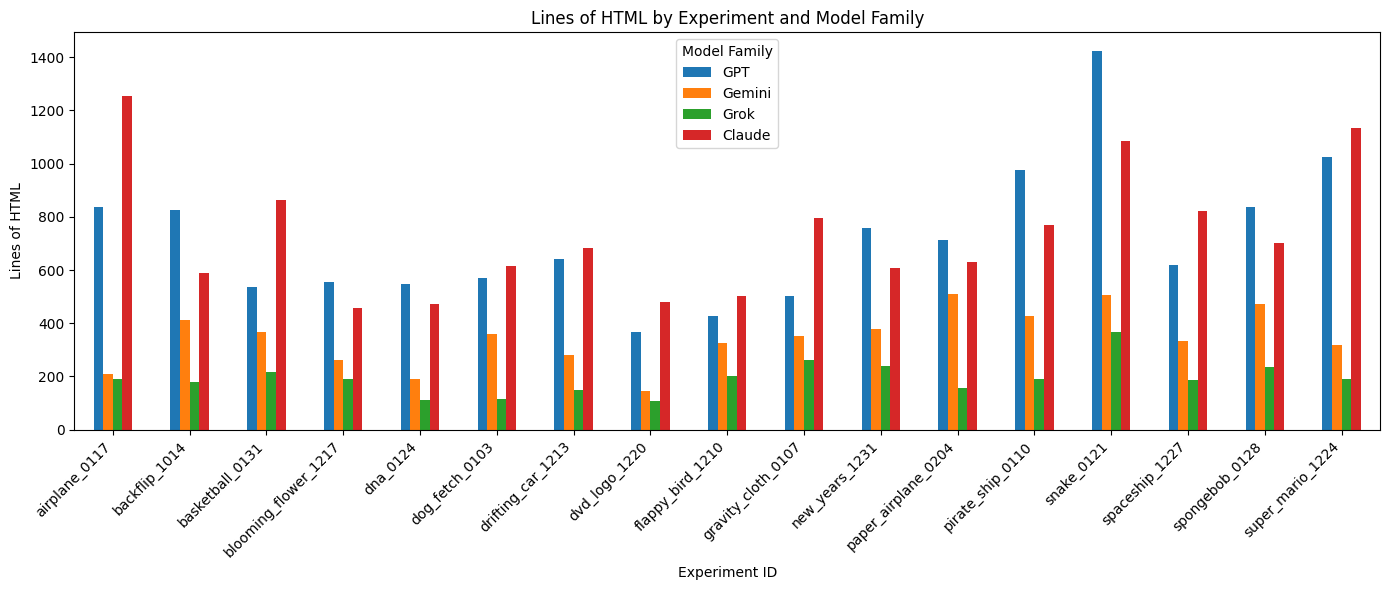

In [ ]:
# Grouped bar plot + numeric report
plot_df = df.pivot_table(
    index="Experiment ID",
    columns="Model Family",
    values="Lines of HTML",
    aggfunc="first"
)

# Keep a fixed model order
desired_order = ["GPT", "Gemini", "Grok", "Claude"]
plot_df = plot_df[[c for c in desired_order if c in plot_df.columns]]

plot_df = plot_df.fillna(0).astype(int)

# ===== Numeric report =====
print("Lines of HTML per experiment and model:")
print(plot_df.to_string())

report_df = plot_df.copy()
report_df["Mean_HTML_Lines"] = report_df.mean(axis=1).round(1)
report_df["Max_HTML_Lines"] = report_df.max(axis=1)
report_df["Min_HTML_Lines"] = report_df.min(axis=1)

print("\nExperiment-level summary:")
print(report_df.to_string())

# ===== Plot =====
ax = plot_df.plot(kind="bar", figsize=(14, 6))

plt.title("Lines of HTML by Experiment and Model Family")
plt.xlabel("Experiment ID")
plt.ylabel("Lines of HTML")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model Family")
plt.tight_layout()
plt.show()

### Experiment Level DF

Each experiment contributes 4 rows in the dataframe, one for each AI model. Some analyses therefore collapse the data from 68 model-level rows to 17 experiment-level rows, while other analyses continue to use the full model-level dataframe.

**Data Frame at the model level:** *df*

**Collapsed dataframe at the experiment level:** *exp_df*


These Columns wont be used from the df, as they are model specific and/or not numeric and/or dont add relevant information to the agregated table:



* LLM Model
* Model Family
* Platform
* Time ET of the Generation
* Reasoning top keyword
* Code in Reasoning?
* Time ET of the Generation
* Time ET of the Generation_hour
* Time ET of the Generation_minute

In [ ]:
# colapse 4 rows into 1 new df = exp_df

target = "X Impressions (24 h)"

# custom aggregator for 'Code in Reasoning?'
def same_value_or_not_unique(s):
    # keeps the repeated value if all 4 rows match, otherwise returns "not unique"
    return s.iloc[0] if s.nunique(dropna=False) == 1 else "not unique"


exp_df = (
    df.groupby("Experiment ID", as_index=False)
      .agg(
          # -----------------------
          # TARGET (experiment-level, same across the 4 model rows)
          # -----------------------
          X_Impressions_24h=(target, "first"),

          # -----------------------
          # Experiment/post metadata (same across the 4 model rows)
          # -----------------------
          Prompt=("Prompt", "first"),
          Experiment_Type=("Experiment Type", "first"),
          Visual_Type=("Visual type", "first"),
          Input_Word_Count=("Input Word Count", "first"),

          Date_Generated=("Date Generated", "min"),
          Date_posted=("Date posted", "first"),
          Day_of_week_posted=("Day of the week posted", "first"),
          Time_posted_X_hour=("Time ET posted on X_hour", "first"),
          Time_posted_X_minute=("Time ET posted on X_minute", "first"),

          X_followers=("X Followers posted", "first"),
          TikTok_followers=("Tik Tok Followers posted", "first"),
          YouTube_followers=("Youtube Followers posted", "first"),
          Video_duration_s=("Video Duration (s)", "first"),

          MaleFemale_song_voice=("Male / Female Song's Voice", "first"),
          Song_Key=("Song Key", "first"),
          Song_BPM=("Song BPM", "first"),
          Song_style=("Song style", "first"),
          Lyrics_words=("Lyrics number of words", "first"),
          LLM_used_for_song=("LLM used for song", "first"),
          Suno_version=("Suno version", "first"),

          # -----------------------
          # Model-varying signals (aggregate across the 4 models)
          # -----------------------
          Perf_mean=("Performance Score (0-10)", "mean"),
          Perf_max=("Performance Score (0-10)", "max"),
          Perf_min=("Performance Score (0-10)", "min"),

          PA_mean=("prompt_adherence_score (0-10)", "mean"),
          FC_mean=("functional_correctness_score (0-10)", "mean"),
          UI_mean=("ui_score (0-10)", "mean"),

          LinesHTML_mean=("Lines of HTML", "mean"),
          LinesHTML_max=("Lines of HTML", "max"),

          ReasonTime_mean=("LLM Reasoning Time (s)", "mean"),
          RespTime_mean=("LLM Response Time (s)", "mean"),

          Reason_words_mean=("Reasoning Total words", "mean"),
          Reason_chars_mean=("Reasoning Total characters", "mean"),
          Reason_sentences_mean=("Reasoning Total sentences", "mean"),
          Reason_topkw_rep_mean=("Reasoning top keyword repetitions", "mean"),

          gemini_pa_mean=("gemini_pa (0-10)", "mean"),
          gemini_fc_mean=("gemini_fc (0-10)", "mean"),
          gemini_ui_mean=("gemini_ui (0-10)", "mean"),
          gemini_perf_mean=("gemini perf (0-10)", "mean"),

          # -----------------------
          # Engagement metadata (experiment-level)
          # -----------------------
          X_Likes_24h=("X Likes (24h)", "first"),
          X_Shares_24h=("X Shares (24h)", "first"),
          TikTok_Views_24h=("Tik Tok Views (24 h)", "first"),
          TikTok_Likes_24h=("Tik Tok Likes (24h)", "first"),
          YouTube_Views_24h=("Youtube short views (24 h)", "first"),
          YouTube_Likes_24h=("Youtube short Likes (24h)", "first"),

          Code_in_Reasoning_unique=("Code in Reasoning?", same_value_or_not_unique),

      )
)
print("Rows before:", df.shape[0], "| Rows after:", exp_df.shape[0])
print("Columns before:", df.shape[1], "| Columns after:", exp_df.shape[1])
exp_df



Rows before: 68 | Rows after: 17
Columns before: 52 | Columns after: 47


,Experiment ID,X_Impressions_24h,Prompt,Experiment_Type,Visual_Type,Input_Word_Count,Date_Generated,Date_posted,Day_of_week_posted,Time_posted_X_hour,...,gemini_fc_mean,gemini_ui_mean,gemini_perf_mean,X_Likes_24h,X_Shares_24h,TikTok_Views_24h,TikTok_Likes_24h,YouTube_Views_24h,YouTube_Likes_24h,Code_in_Reasoning_unique
0,airplane_0117,15636,Create a 3D simulation of an airplane landing ...,0,1,10,2026-01-15,2026-01-17,0,9,...,7.50,6.00,7.2250,128,3,990,44,188,1,0
1,backflip_1014,214,Create a slow-motion simulation of a stick-fig...,0,1,43,2026-01-10,2026-01-14,1,12,...,9.00,8.25,9.2125,5,1,197,8,20,0,not unique
2,basketball_0131,346,Create a simulation of a basketball free-throw...,1,0,36,2026-01-31,2026-01-31,0,11,...,5.25,7.00,6.2875,8,0,197,3,165,0,not unique
3,blooming_flower_1217,97813,Create an animation of a single flower bloomin...,0,1,18,2025-12-12,2025-12-17,1,16,...,10.00,9.00,9.7500,650,20,180,5,284,0,not unique
4,dna_0124,5502,Create a rotating 3D animation of a Double Hel...,0,1,19,2026-01-22,2026-01-24,0,9,...,7.75,7.75,7.7500,39,2,835,48,208,2,not unique
5,dog_fetch_0103,24987,Animate a dog fetching a ball. Using HTML/CSS/...,0,1,13,2025-12-26,2026-01-03,0,8,...,8.50,7.25,8.0875,149,5,178,5,0,0,0
6,drifting_car_1213,206661,Create a 3D simulation of a formula 1 car perf...,0,1,24,2025-12-11,2025-12-13,0,7,...,7.00,6.00,6.4500,1396,78,14,0,106,0,not unique
7,dvd_logo_1220,21741,Create a physics-accurate “Bouncing DVD Logo” ...,0,1,36,2025-12-15,2025-12-20,0,8,...,8.25,6.75,7.8750,45,3,392,11,425,0,not unique
8,flappy_bird_1210,135606,Make a game like flappy bird using HTML/CSS/JS...,1,1,13,2025-12-10,2025-12-10,1,20,...,10.00,8.75,9.6875,433,22,259,9,265,3,not unique
9,gravity_cloth_0107,27182,Create an interactive 'Tearable Cloth' simulat...,0,0,44,2025-12-30,2026-01-07,1,17,...,10.00,9.25,9.8125,273,7,433,12,3,0,not unique


In [ ]:
exp_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Experiment ID             17 non-null     str           
 1   X_Impressions_24h         17 non-null     int64         
 2   Prompt                    17 non-null     str           
 3   Experiment_Type           17 non-null     Int64         
 4   Visual_Type               17 non-null     Int64         
 5   Input_Word_Count          17 non-null     int64         
 6   Date_Generated            17 non-null     datetime64[us]
 7   Date_posted               17 non-null     datetime64[us]
 8   Day_of_week_posted        17 non-null     Int64         
 9   Time_posted_X_hour        17 non-null     int32         
 10  Time_posted_X_minute      17 non-null     int32         
 11  X_followers               17 non-null     int64         
 12  TikTok_followers          17 non-nu

2 Dataframes:


*   df = Model Level
*   exp_df = Experiment level



In [ ]:
# df, display unique values and their counts for
# categorical columns model specific

categorical_cols_model = [
    'LLM Model',
    'Model Family',
    'Platform',
    'Code in Reasoning?',
]

for col in categorical_cols_model:
    if col not in df.columns:
        print(f"\nColumn not found in df: {col}")
        continue

    counts = df[col].value_counts(dropna=False)

    print(f"\nUnique {col} and their counts:")
    print('=====')
    print(counts)



Unique LLM Model and their counts:
=====
LLM Model
gemini-3-pro                 17
grok-4.1-thinking            17
opus-4.5-thinking-32k        17
gpt-5.2-extended-thinking    16
gpt-5.1-extended-thinking     1
Name: count, dtype: int64

Unique Model Family and their counts:
=====
Model Family
GPT       17
Gemini    17
Grok      17
Claude    17
Name: count, dtype: int64

Unique Platform and their counts:
=====
Platform
1    51
0    17
Name: count, dtype: Int64

Unique Code in Reasoning? and their counts:
=====
Code in Reasoning?
0    53
1    15
Name: count, dtype: Int64


In [ ]:
# exp_df, display unique values and their counts for
# categorical columns experiment specific

categorical_cols_exp = [
    'Experiment ID',
    'Experiment_Type',
    'Visual_Type',
    'Date_posted',
    'Song_Key',
    'LLM_used_for_song',
    'Suno_version',
    'Day_of_week_posted',
    'MaleFemale_song_voice',
    'Song_style',
    'LLM_used_for_song',
]

for col in categorical_cols_exp:
    if col not in exp_df.columns:
        print(f"\nColumn not found in df: {col}")
        continue

    exp_counts = exp_df[col].value_counts(dropna=False)

    print(f"\nUnique {col} and their counts:")
    print('=====')
    print(exp_counts)



Unique Experiment ID and their counts:
=====
Experiment ID
airplane_0117           1
backflip_1014           1
basketball_0131         1
blooming_flower_1217    1
dna_0124                1
dog_fetch_0103          1
drifting_car_1213       1
dvd_logo_1220           1
flappy_bird_1210        1
gravity_cloth_0107      1
new_years_1231          1
paper_airplane_0204     1
pirate_ship_0110        1
snake_0121              1
spaceship_1227          1
spongebob_0128          1
super_mario_1224        1
Name: count, dtype: int64

Unique Experiment_Type and their counts:
=====
Experiment_Type
0    13
1     4
Name: count, dtype: Int64

Unique Visual_Type and their counts:
=====
Visual_Type
1    13
0     4
Name: count, dtype: Int64

Unique Date_posted and their counts:
=====
Date_posted
2026-01-17    1
2026-01-14    1
2026-01-31    1
2025-12-17    1
2026-01-24    1
2026-01-03    1
2025-12-13    1
2025-12-20    1
2025-12-10    1
2026-01-07    1
2025-12-31    1
2026-02-04    1
2026-01-10    1
2026

### Missing Values

In [ ]:
# Detect missing values in df

# This function returns True if an element has no value; otherwise,
# it returns None or False for each element in a DataFrame.
df.isnull()

,Experiment ID,LLM Model,Prompt,Experiment Type,Visual type,LLM Reasoning Time (s),LLM Response Time (s),Date Generated,Time ET of the Generation,Reasoning Total words,...,X Likes (24h),X Shares (24h),Tik Tok Views (24 h),Tik Tok Likes (24h),Youtube short views (24 h),Youtube short Likes (24h),Time ET of the Generation_hour,Time ET of the Generation_minute,Time ET posted on X_hour,Time ET posted on X_minute
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
65,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
66,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print(missing_values)

Experiment ID                          0
LLM Model                              0
Prompt                                 0
Experiment Type                        0
Visual type                            0
LLM Reasoning Time (s)                 0
LLM Response Time (s)                  0
Date Generated                         0
Time ET of the Generation              0
Reasoning Total words                  0
Reasoning Total characters             0
Reasoning Total sentences              0
Reasoning top keyword                  0
Reasoning top keyword repetitions      0
Input Word Count                       0
Lines of HTML                          0
Model Family                           0
Platform                               0
Code in Reasoning?                     0
prompt_adherence_score (0-10)          0
gemini_pa (0-10)                       0
functional_correctness_score (0-10)    0
gemini_fc (0-10)                       0
ui_score (0-10)                        0
gemini_ui (0-10)

In [ ]:
# Check for duplicate rows
duplicates = df[df.duplicated(keep=False)]

# Display the appropriate message
if duplicates.empty:
    print("NO DUPLICATES FOUND")
else:
    print("Here are the duplicates:")
    print(duplicates)


NO DUPLICATES FOUND


In [ ]:
# Initialize a flag to check if any columns with empty or trailing spaces are found
found = False

# Loop through each column in the DataFrame
for column in df.columns:
    if df[column].dtype == 'object':  # Check if the column is of type 'object'
        value_counts = df[column].value_counts()  # Calculate value counts
        # Check for empty strings or strings that might contain only spaces
        if '' in value_counts.index or ' ' in value_counts.index:
            print(f"Value counts for column {column} (including empty/trailing spaces):\n{value_counts}\n")
            found = True  # Set the flag to True if such a column is found

# If no columns with empty or trailing spaces were found, print message
if not found:
    print("No variables found with empty strings or strings that contain only spaces.")


No variables found with empty strings or strings that contain only spaces.


In [ ]:
# Detect missing values in exp_df

# This function returns True if an element has no value; otherwise,
# it returns None or False for each element in a DataFrame.
exp_df.isnull()

,Experiment ID,X_Impressions_24h,Prompt,Experiment_Type,Visual_Type,Input_Word_Count,Date_Generated,Date_posted,Day_of_week_posted,Time_posted_X_hour,...,gemini_fc_mean,gemini_ui_mean,gemini_perf_mean,X_Likes_24h,X_Shares_24h,TikTok_Views_24h,TikTok_Likes_24h,YouTube_Views_24h,YouTube_Likes_24h,Code_in_Reasoning_unique
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Check for missing values
missing_values = exp_df.isnull().sum()
print(missing_values)

Experiment ID               0
X_Impressions_24h           0
Prompt                      0
Experiment_Type             0
Visual_Type                 0
Input_Word_Count            0
Date_Generated              0
Date_posted                 0
Day_of_week_posted          0
Time_posted_X_hour          0
Time_posted_X_minute        0
X_followers                 0
TikTok_followers            0
YouTube_followers           0
Video_duration_s            0
MaleFemale_song_voice       0
Song_Key                    0
Song_BPM                    0
Song_style                  0
Lyrics_words                0
LLM_used_for_song           0
Suno_version                0
Perf_mean                   0
Perf_max                    0
Perf_min                    0
PA_mean                     0
FC_mean                     0
UI_mean                     0
LinesHTML_mean              0
LinesHTML_max               0
ReasonTime_mean             0
RespTime_mean               0
Reason_words_mean           0
Reason_cha

In [ ]:
# Check for duplicate rows
duplicates = exp_df[exp_df.duplicated(keep=False)]

# Display the appropriate message
if duplicates.empty:
    print("NO DUPLICATES FOUND")
else:
    print("Here are the duplicates:")
    print(duplicates)


NO DUPLICATES FOUND


In [ ]:
# Initialize a flag to check if any columns with empty or trailing spaces are found
found = False

# Loop through each column in the DataFrame
for column in exp_df.columns:
    if exp_df[column].dtype == 'object':  # Check if the column is of type 'object'
        value_counts = exp_df[column].value_counts()  # Calculate value counts
        # Check for empty strings or strings that might contain only spaces
        if '' in value_counts.index or ' ' in value_counts.index:
            print(f"Value counts for column {column} (including empty/trailing spaces):\n{value_counts}\n")
            found = True  # Set the flag to True if such a column is found

# If no columns with empty or trailing spaces were found, print message
if not found:
    print("No variables found with empty strings or strings that contain only spaces.")


No variables found with empty strings or strings that contain only spaces.


No missing values in any df

### '0' values

In [ ]:
# df
# Find columns that contain at least one '0' value

# Detect binary numeric columns (values are only 0/1, ignoring NaNs)
binary_cols_detected = [
    c for c in df.select_dtypes(include="number").columns
    if set(df[c].dropna().unique()).issubset({0, 1}) and df[c].nunique(dropna=True) <= 2
]

columns_with_zeros = [
    c for c in df.select_dtypes(include="number").columns
    if c not in binary_cols_detected and (df[c] == 0).any()
]

# Print the names of the columns that contain '0' values
print("Binary columns ignored:")
print(binary_cols_detected)

print("\nColumns with at least one 0 (excluding binary cols):")
for c in columns_with_zeros:
    print(c)

Binary columns ignored:
['Experiment Type', 'Visual type', 'Platform', 'Code in Reasoning?', "Male / Female Song's Voice", 'Suno version', 'Day of the week posted']

Columns with at least one 0 (excluding binary cols):
prompt_adherence_score (0-10)
functional_correctness_score (0-10)
ui_score (0-10)
Performance Score (0-10)
X Shares (24h)
Tik Tok Likes (24h)
Youtube short views (24 h)
Youtube short Likes (24h)


These columns can be 0 if the model has a bad score or no social media interaction

In [ ]:
# exp_df
# Find columns that contain at least one '0' value

# Detect binary numeric columns (values are only 0/1, ignoring NaNs)
binary_cols_detected = [
    c for c in exp_df.select_dtypes(include="number").columns
    if set(exp_df[c].dropna().unique()).issubset({0, 1}) and exp_df[c].nunique(dropna=True) <= 2
]

columns_with_zeros = [
    c for c in exp_df.select_dtypes(include="number").columns
    if c not in binary_cols_detected and (exp_df[c] == 0).any()
]

# Print the names of the columns that contain '0' values
print("Binary columns ignored:")
print(binary_cols_detected)

print("\nColumns with at least one 0 (excluding binary cols):")
for c in columns_with_zeros:
    print(c)

Binary columns ignored:
['Experiment_Type', 'Visual_Type', 'Day_of_week_posted', 'MaleFemale_song_voice', 'Suno_version']

Columns with at least one 0 (excluding binary cols):
Perf_min
X_Shares_24h
TikTok_Likes_24h
YouTube_Views_24h
YouTube_Likes_24h


These columns can be 0 if the model has no social media interaction

### Outliers

df

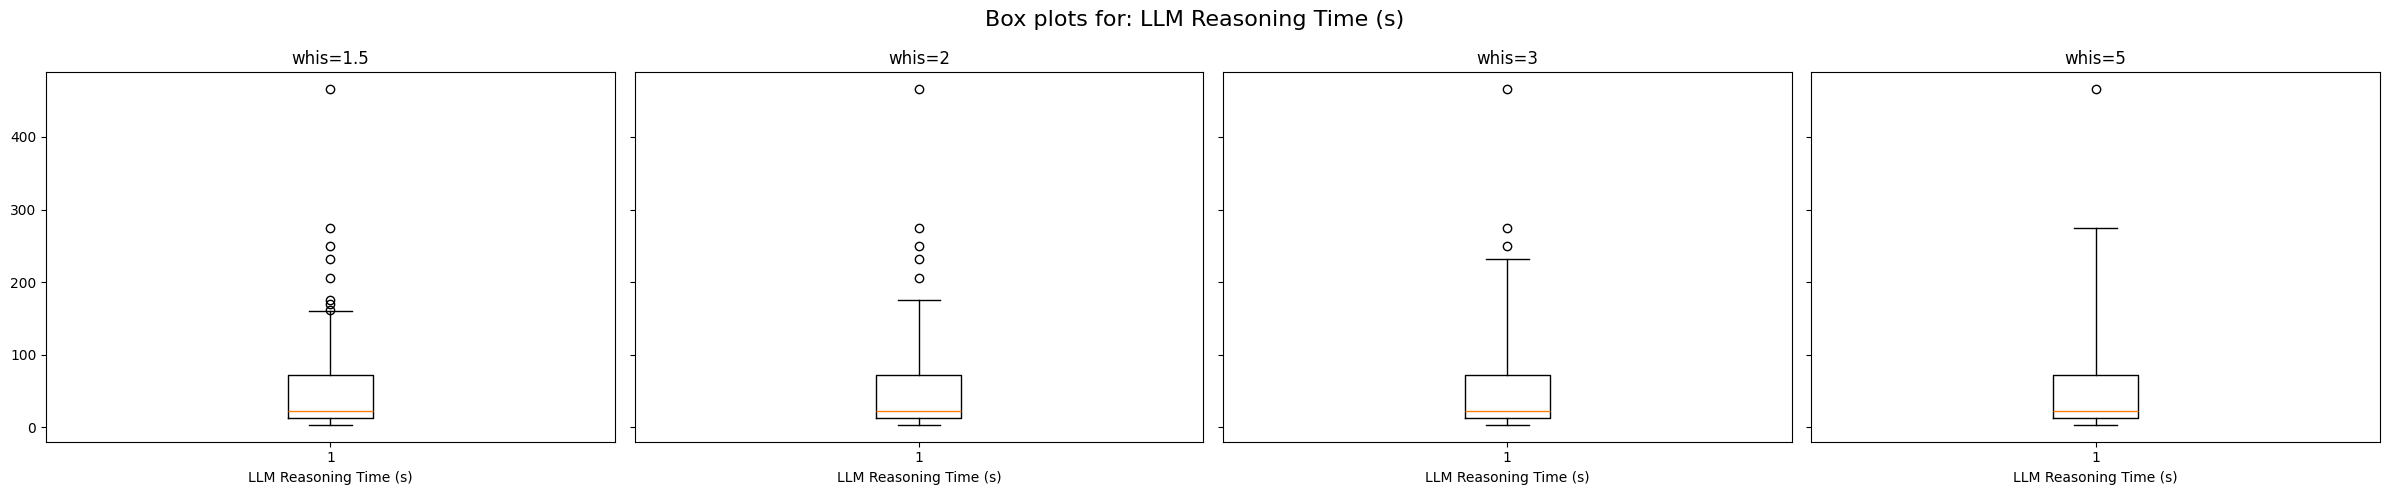

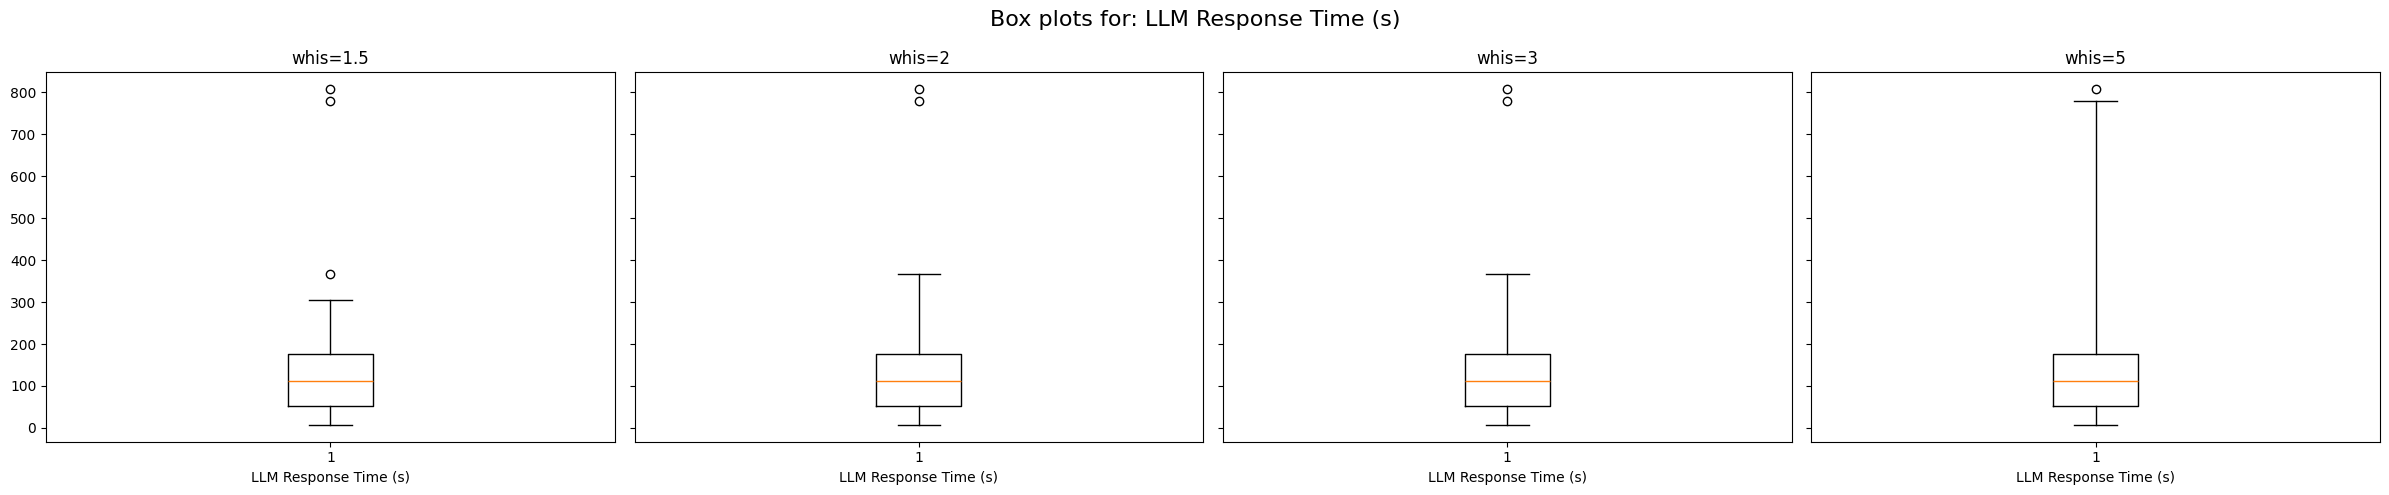

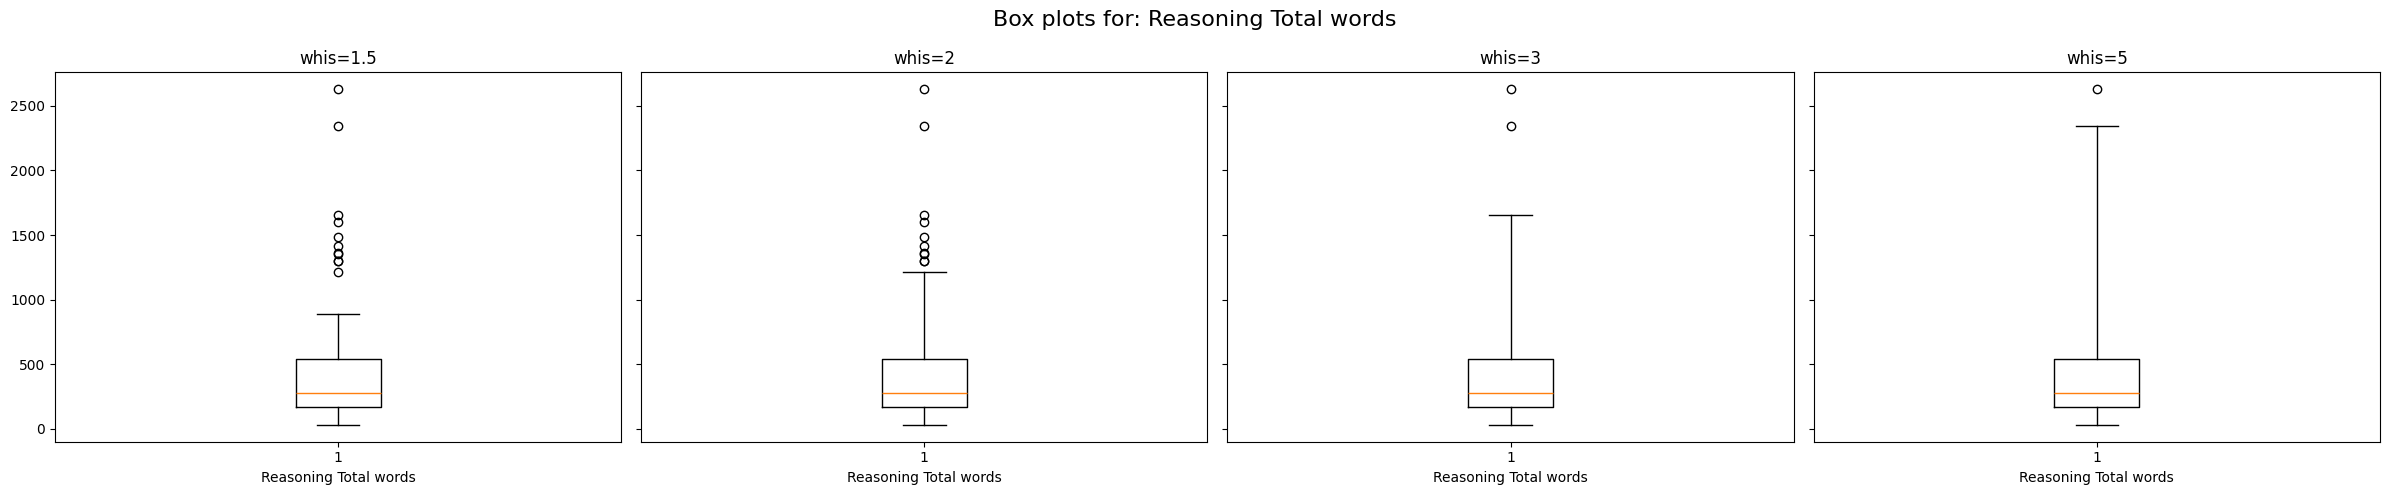

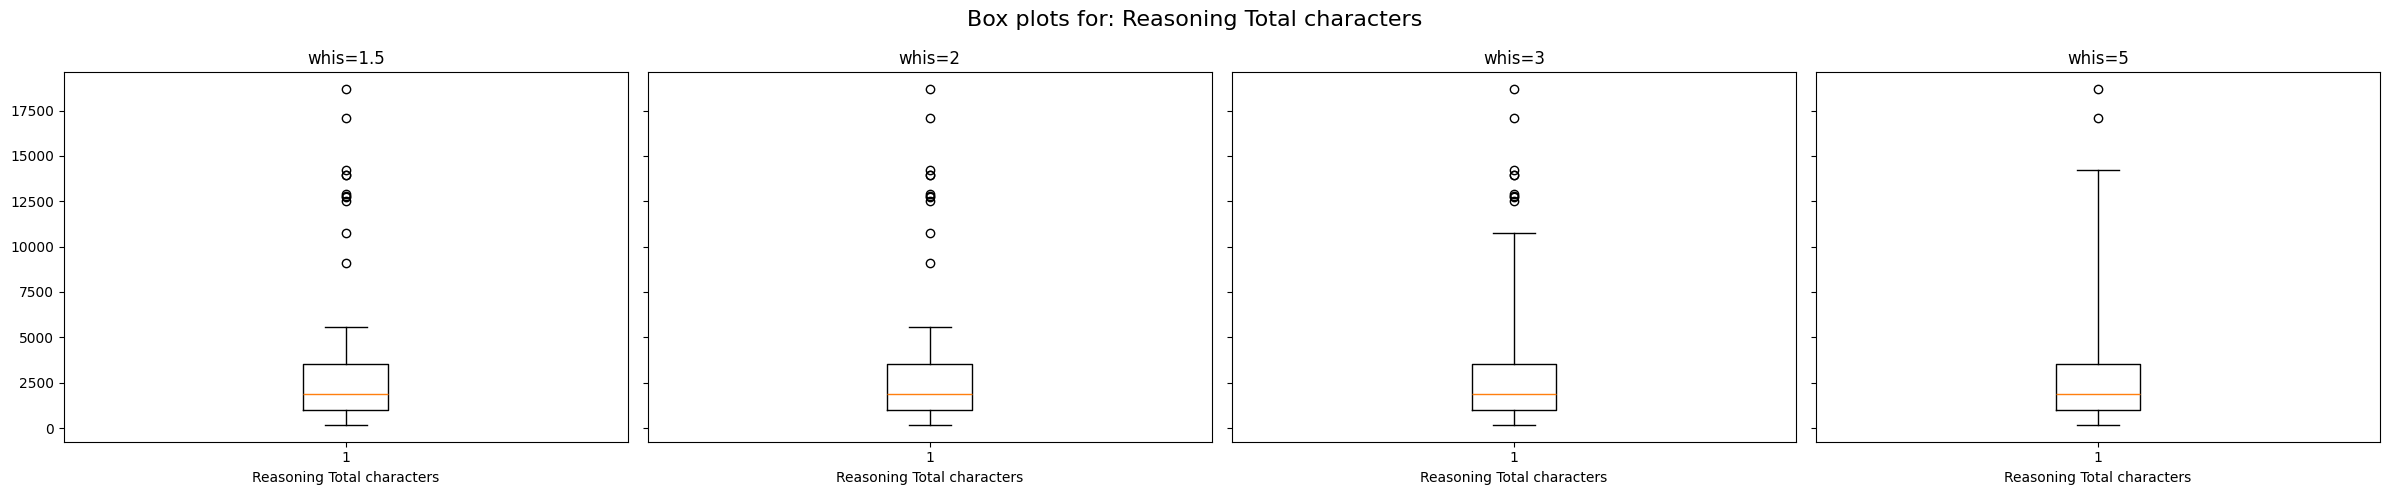

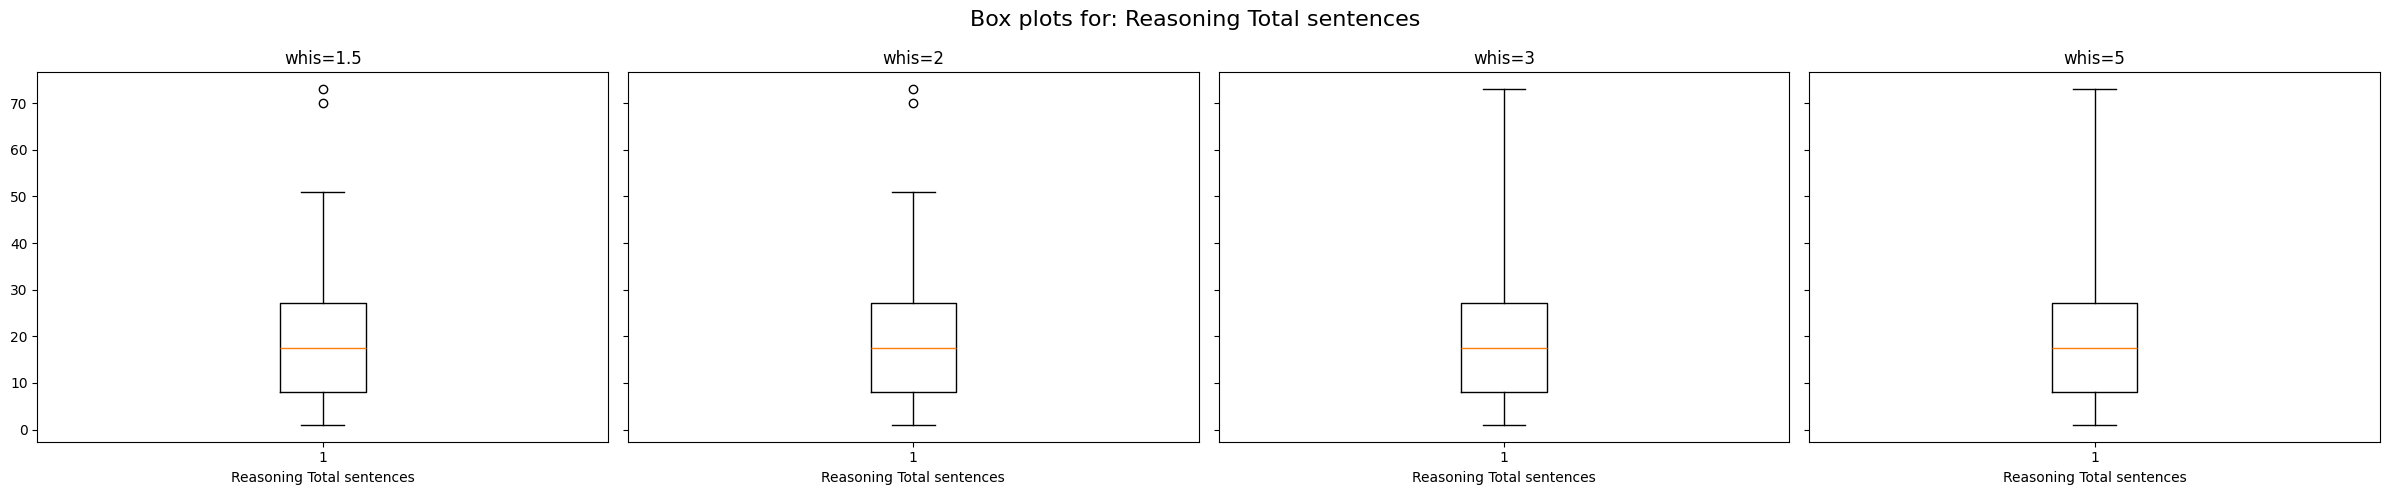

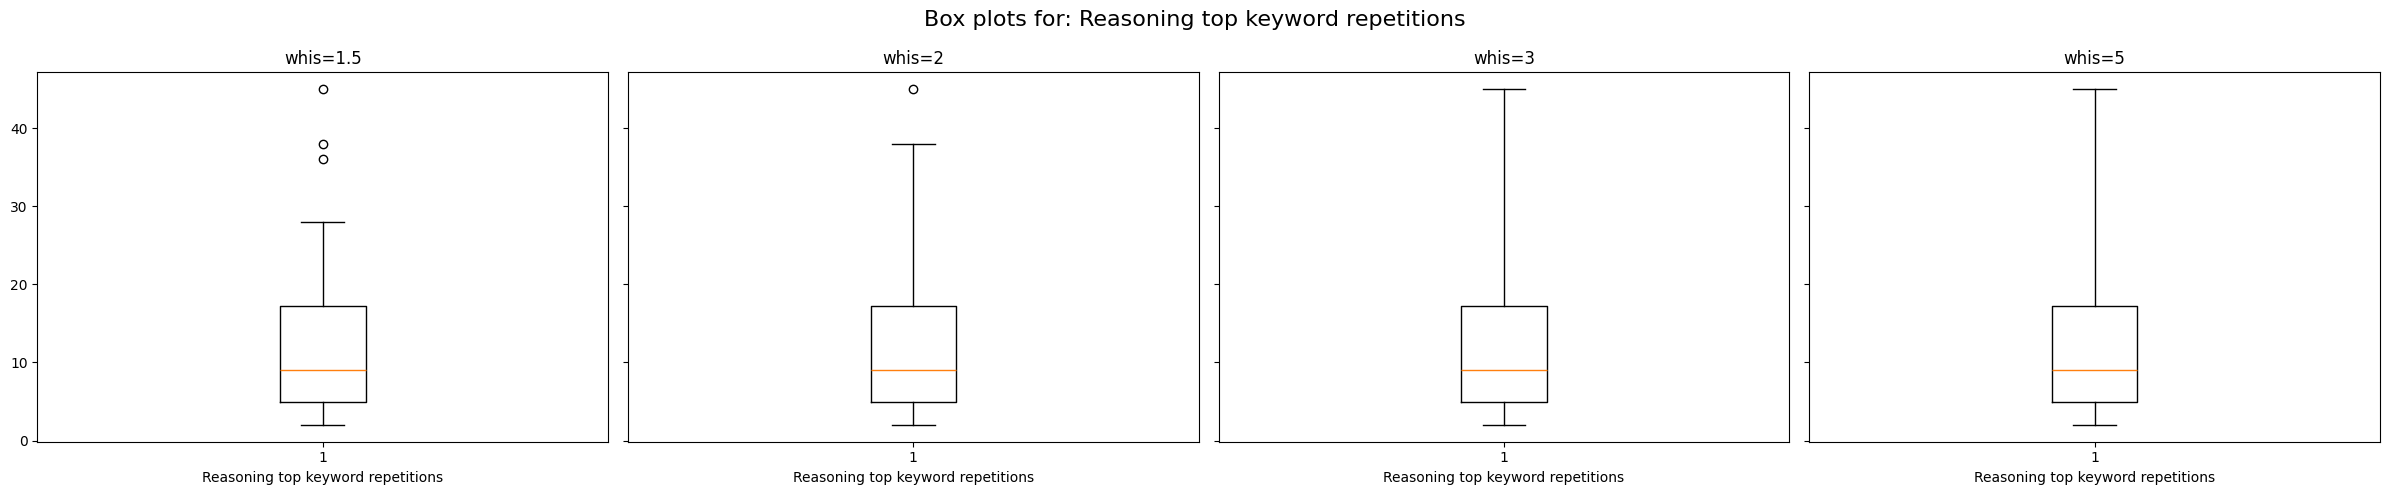

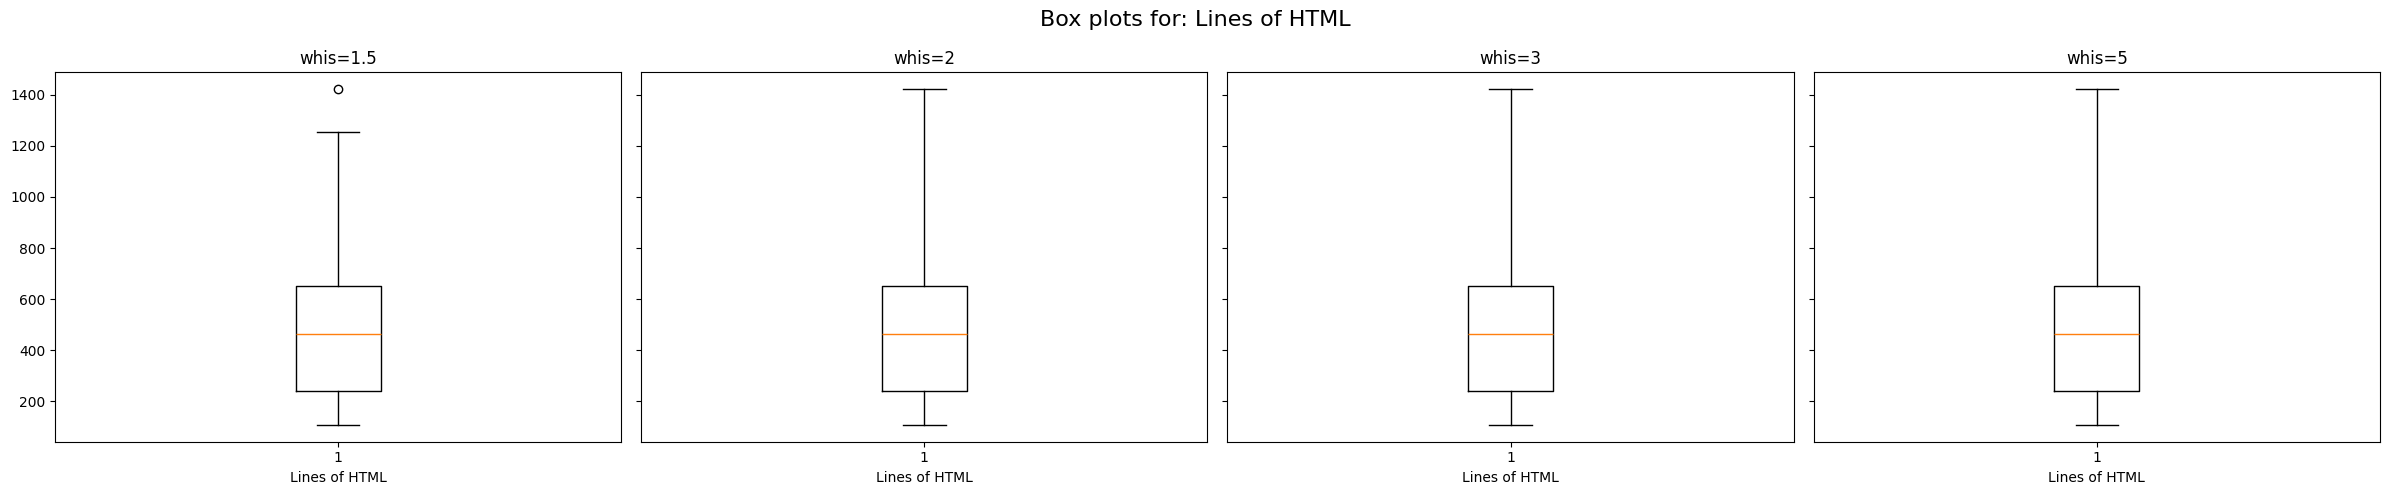

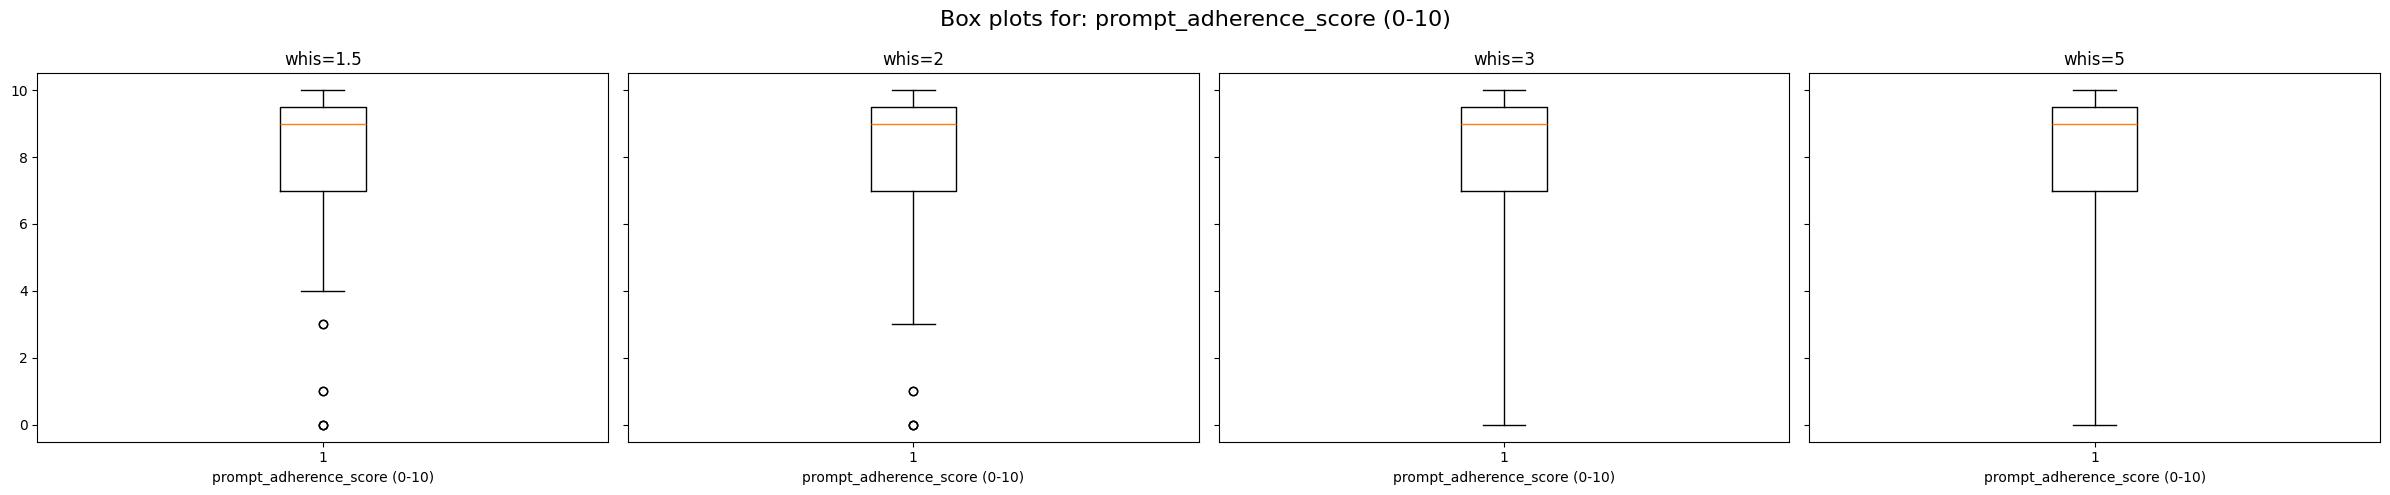

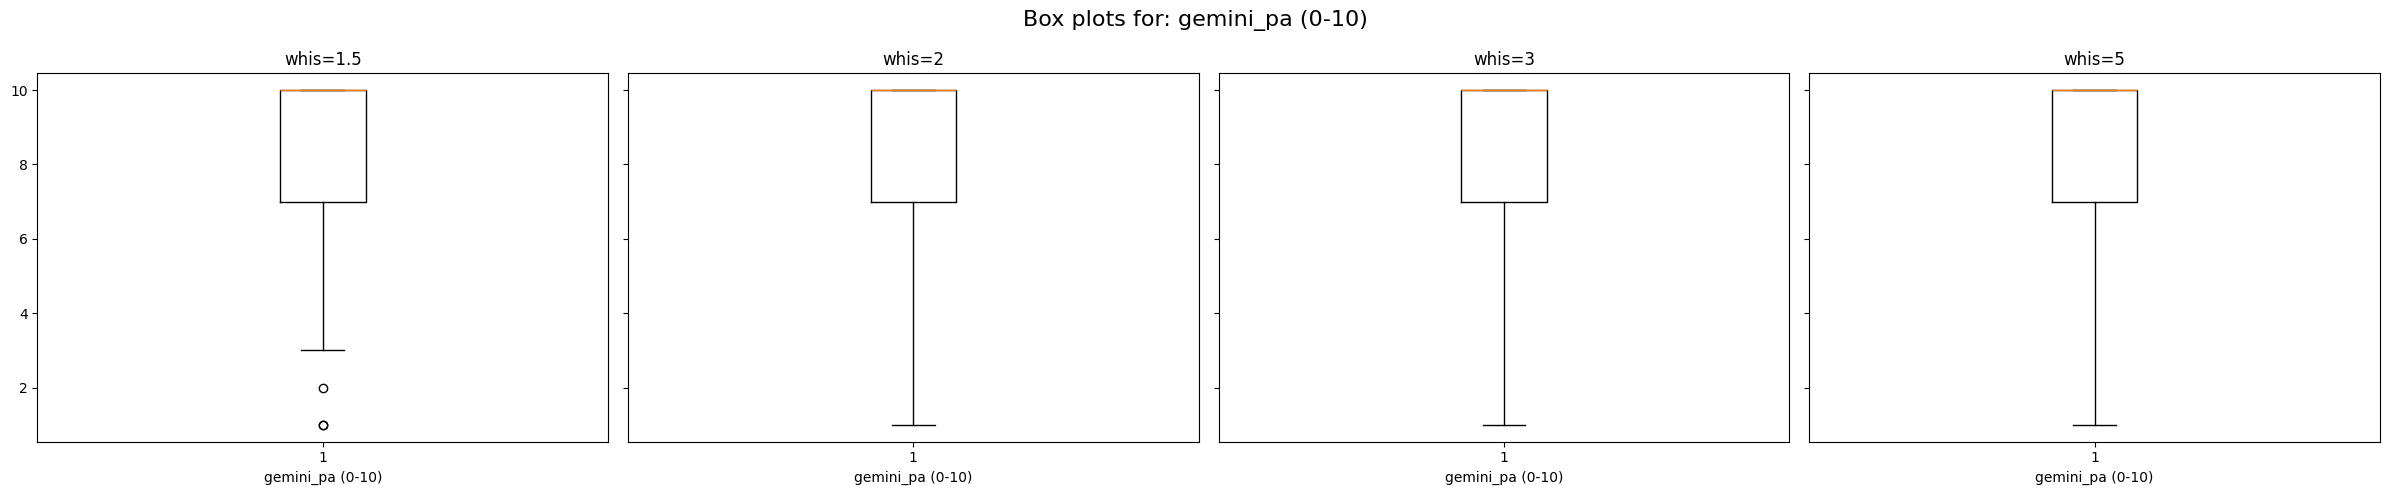

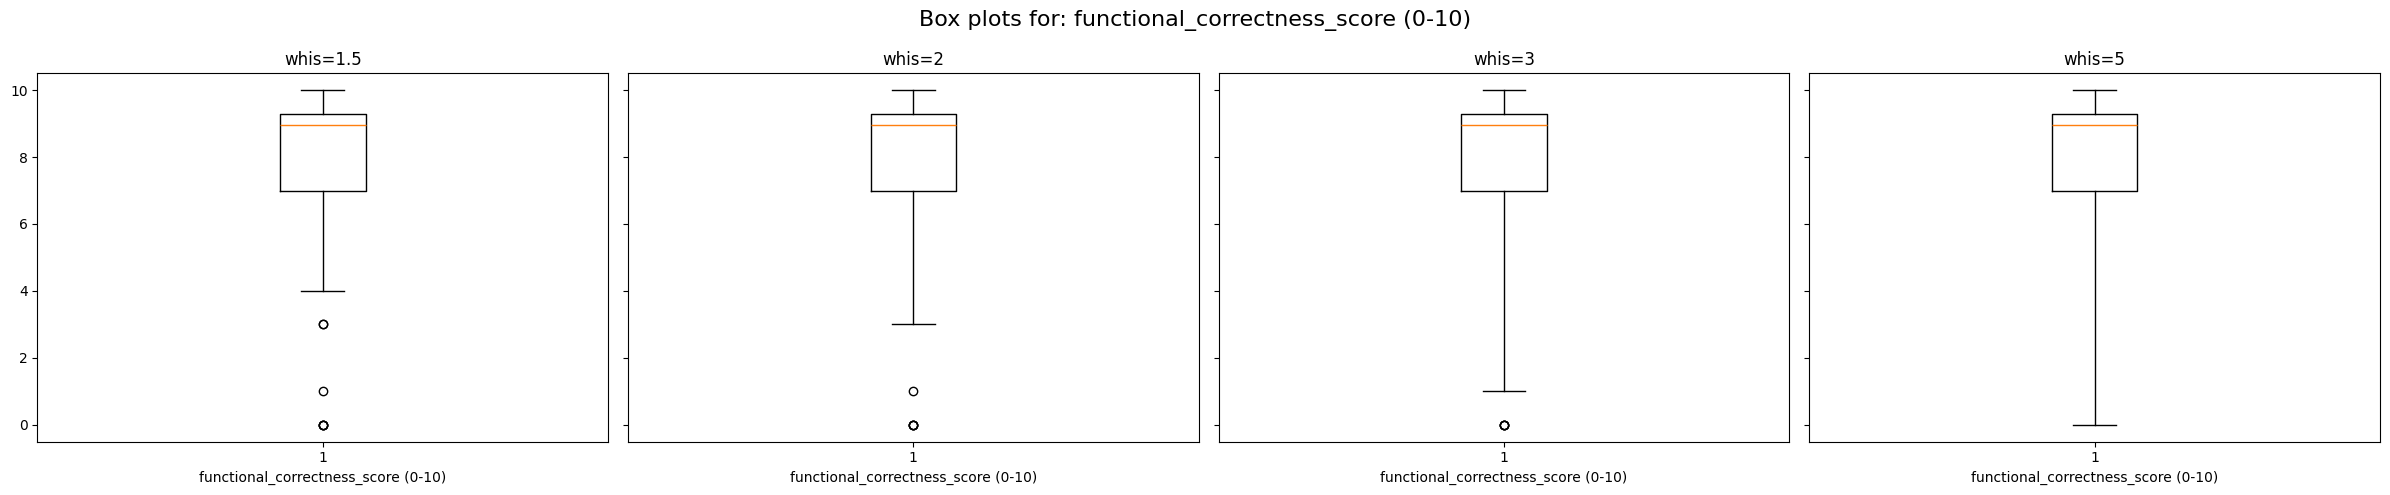

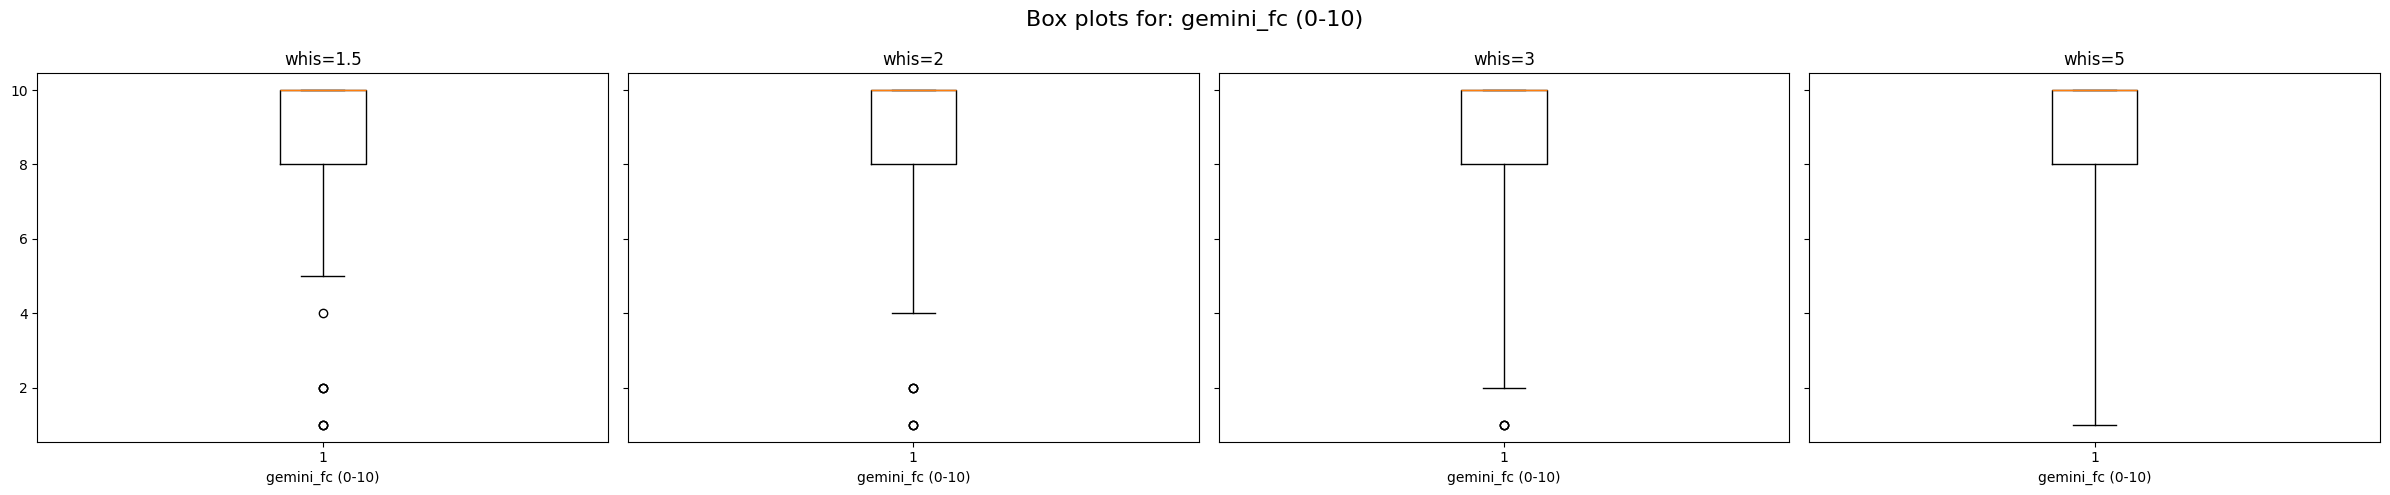

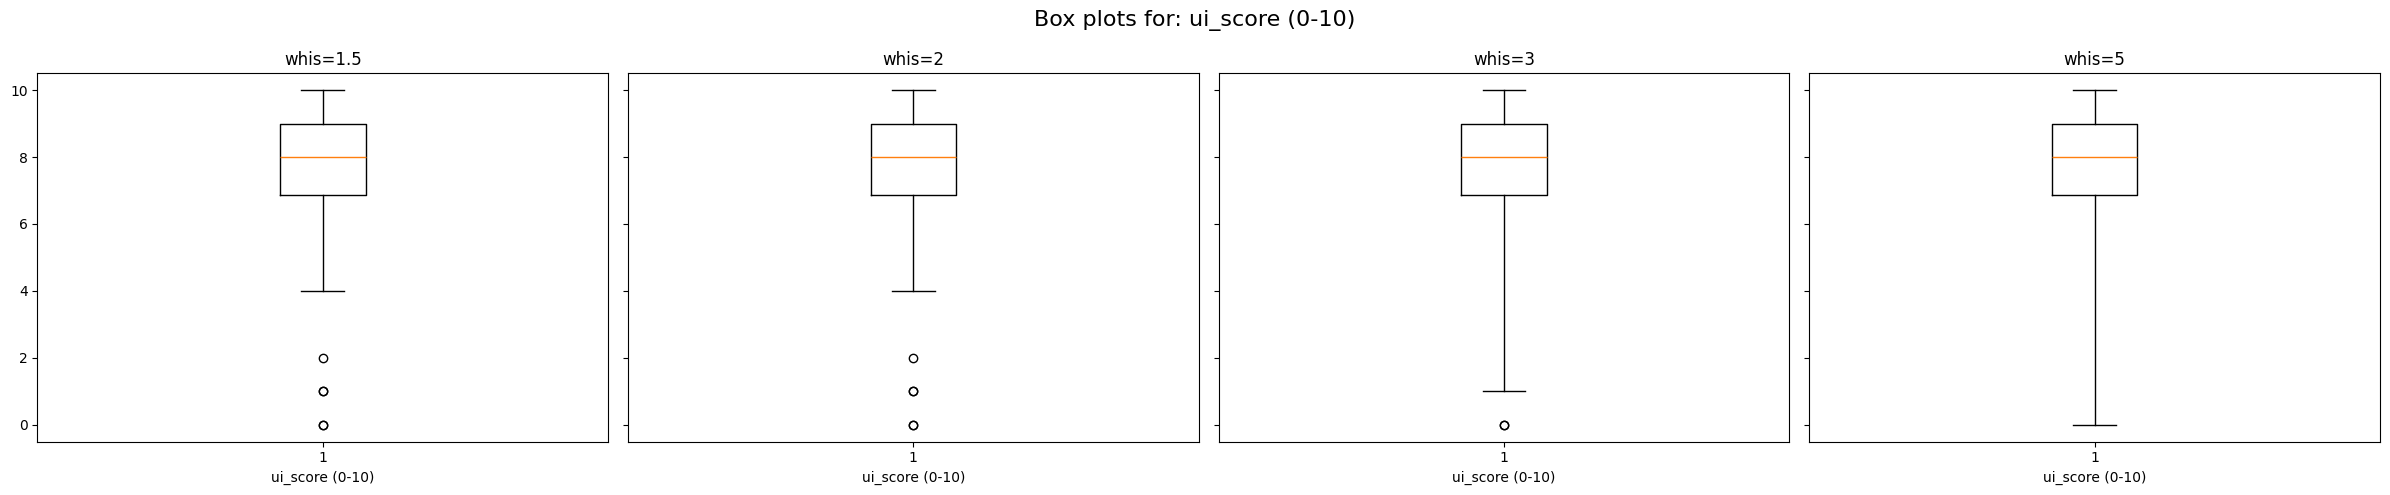

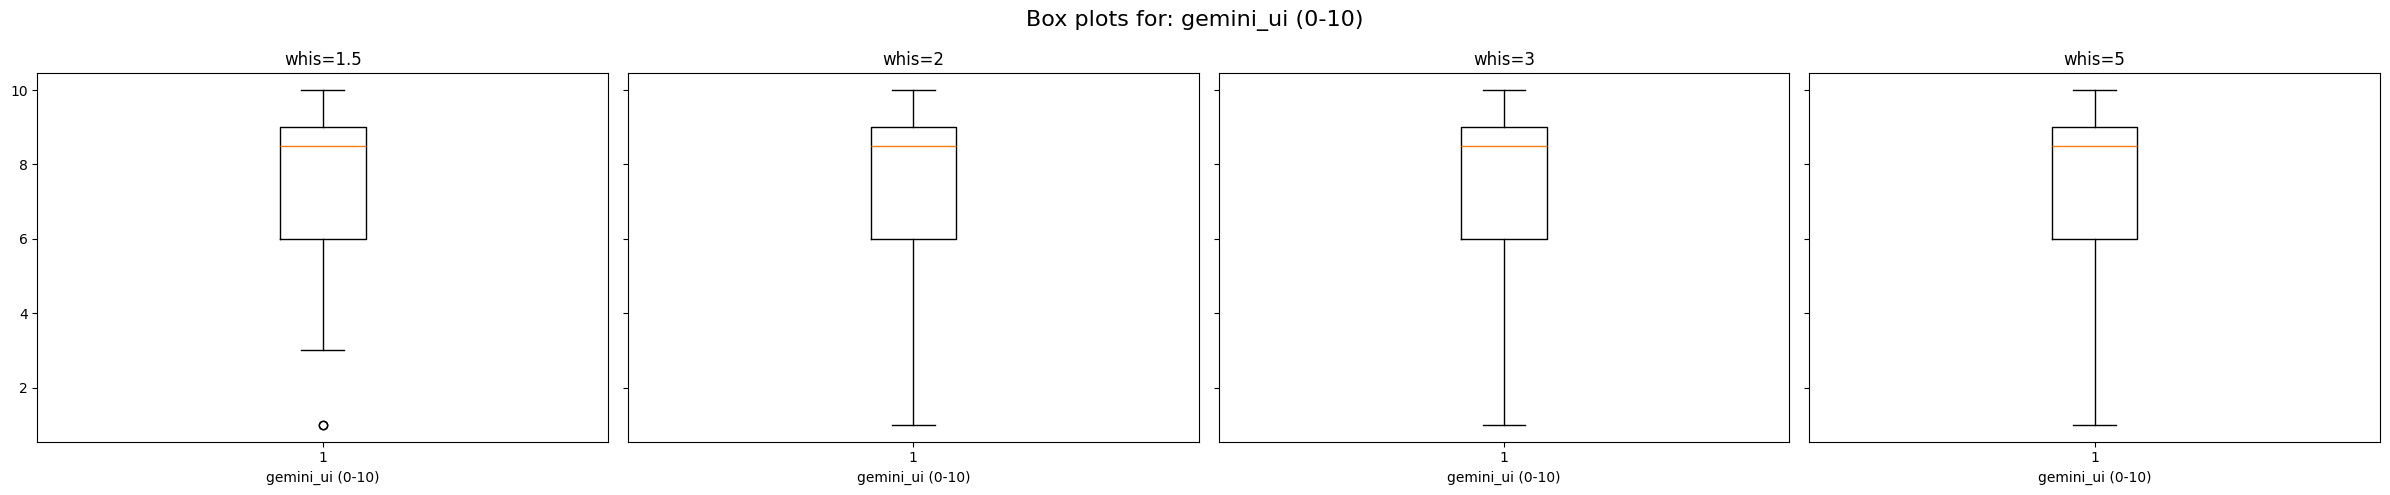

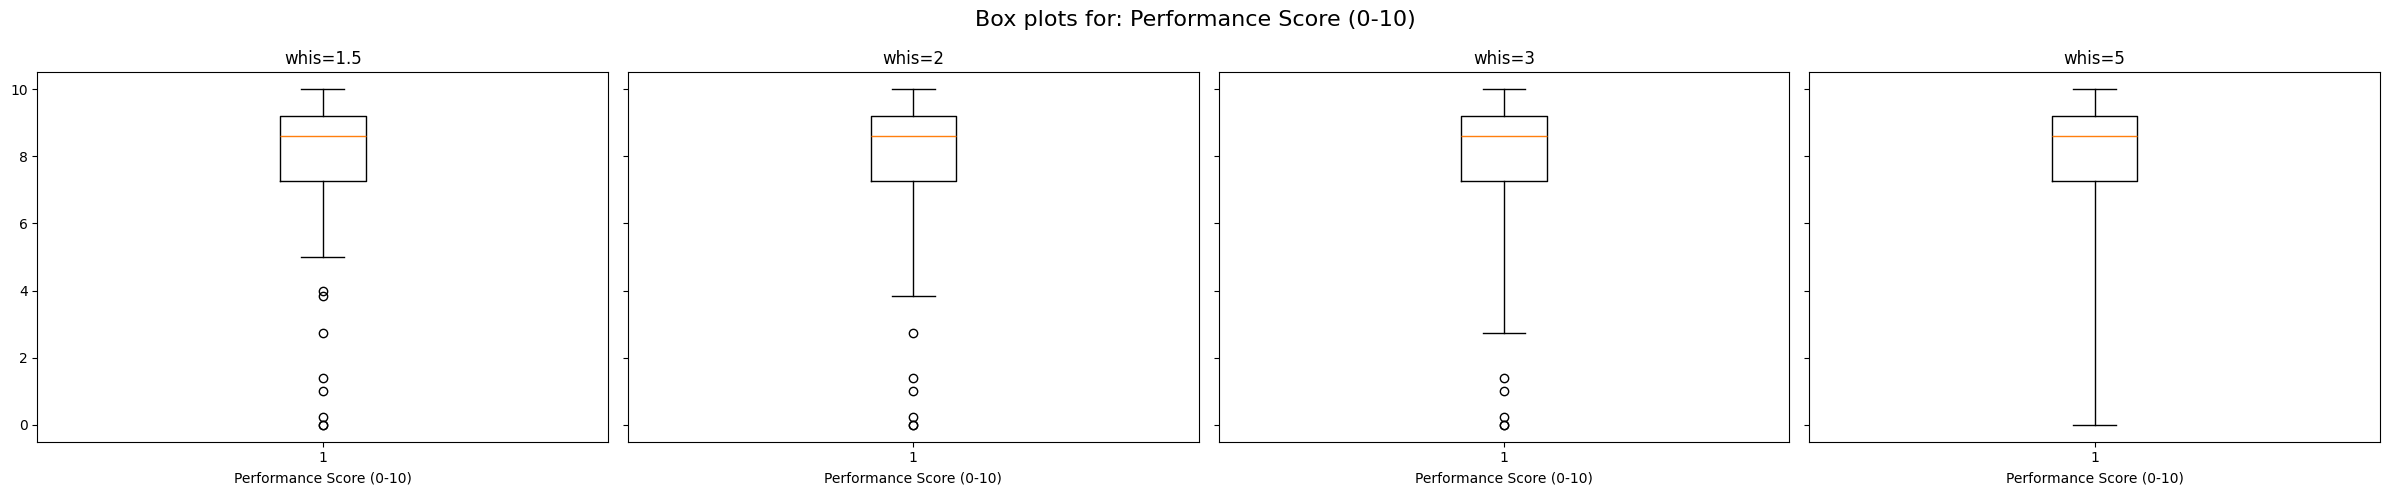

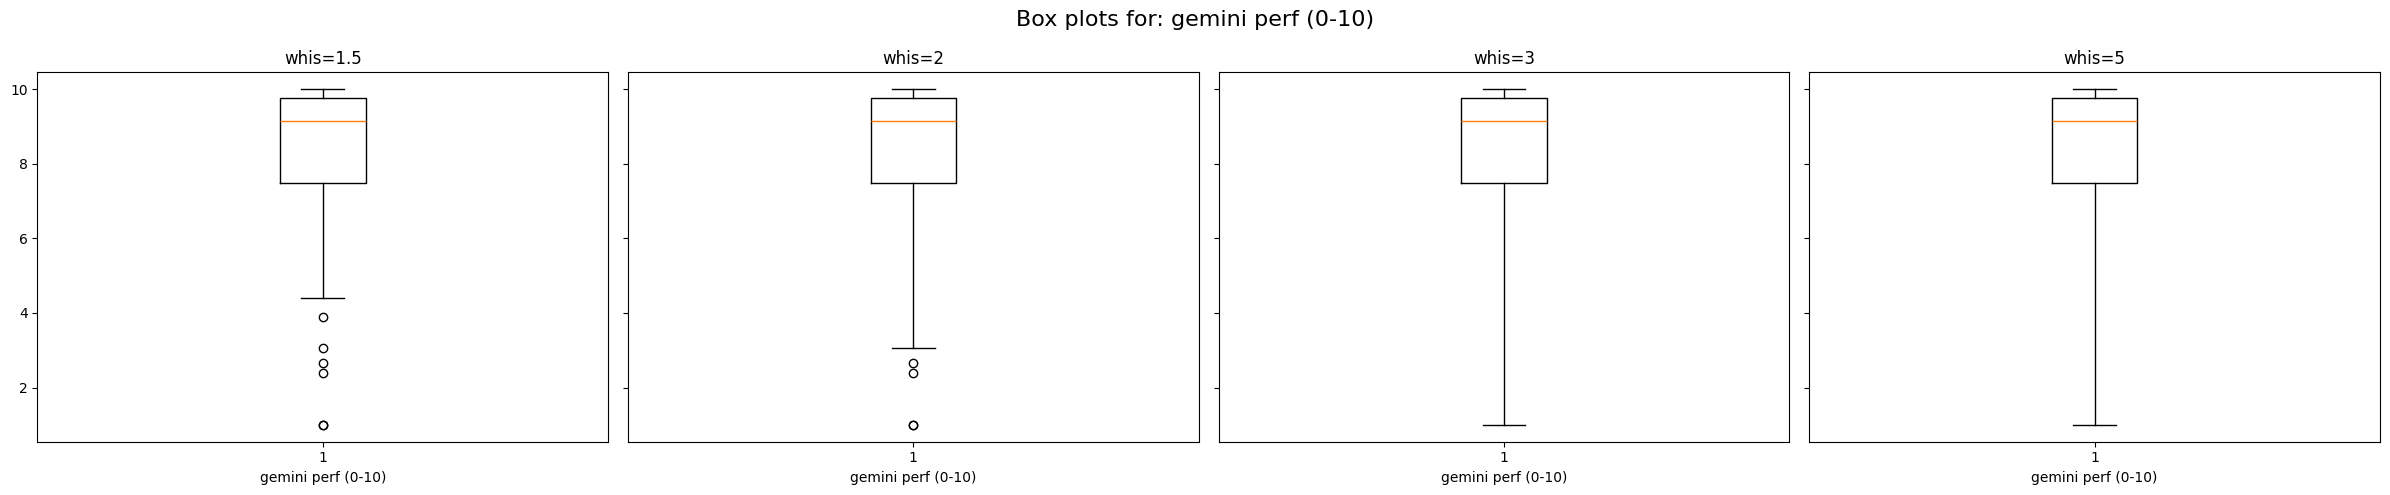

In [ ]:
# Only model-level numeric cols (exclude experiment-level metrics)
numeric_cols_model = [
    'LLM Reasoning Time (s)', 'LLM Response Time (s)', 'Reasoning Total words',
    'Reasoning Total characters', 'Reasoning Total sentences',
    'Reasoning top keyword repetitions', 'Lines of HTML',
    'prompt_adherence_score (0-10)', 'gemini_pa (0-10)',
    'functional_correctness_score (0-10)', 'gemini_fc (0-10)',
    'ui_score (0-10)', 'gemini_ui (0-10)',
    'Performance Score (0-10)', 'gemini perf (0-10)'
]

# Keep only columns that actually exist in df
numerical_cols = [c for c in numeric_cols_model if c in df.columns]
missing = [c for c in numeric_cols_model if c not in df.columns]
if missing:
    print("Missing columns in df (skipped):")
    for c in missing:
        print(" -", c)

# Whisker values to test
whis_values = [1.5, 2, 3, 5]

for col in numerical_cols:
    fig, axes = plt.subplots(1, len(whis_values), figsize=(24, 5), sharey=True)

    for ax, whis in zip(axes, whis_values):
        ax.boxplot(df[col].dropna(), whis=whis)
        ax.set_title(f"whis={whis}", fontsize=12)
        ax.set_xlabel(col, fontsize=10)
        ax.tick_params(labelsize=10)

    fig.suptitle(f"Box plots for: {col}", fontsize=16)
    plt.tight_layout()
    plt.show()

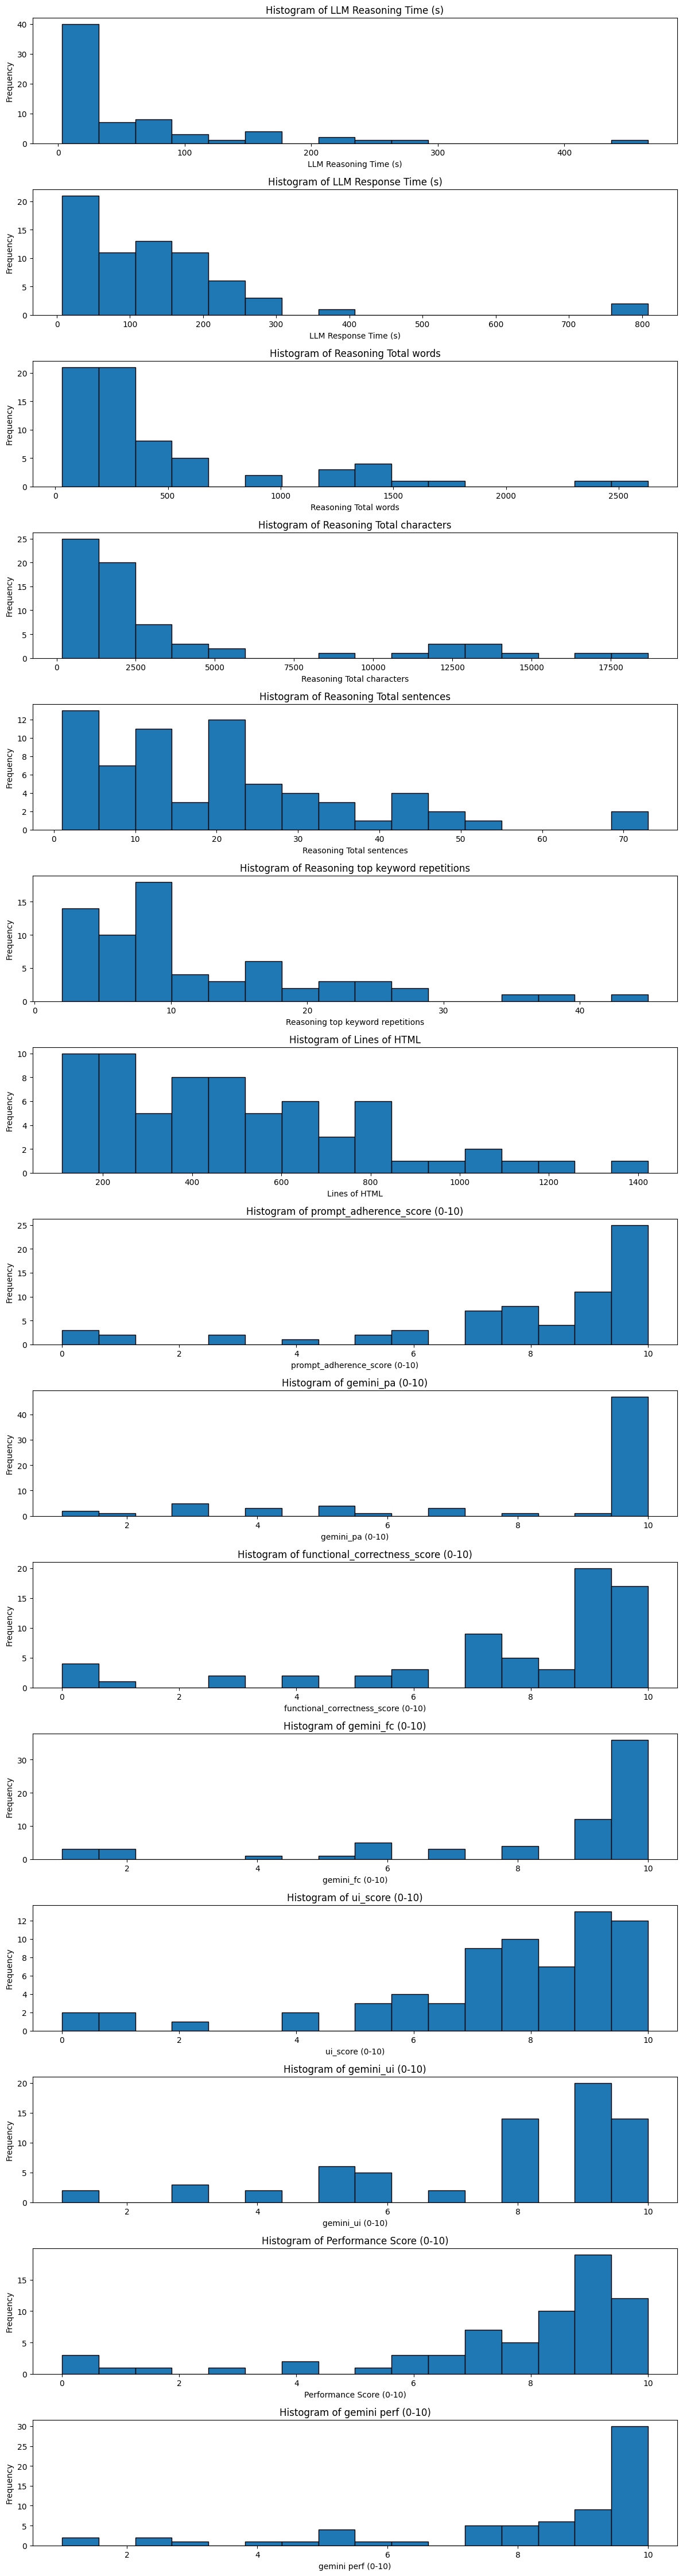

In [ ]:
import numpy as np

n = len(numerical_cols)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, 3 * n))


if n == 1:
    axes = [axes]

for ax, col in zip(axes, numerical_cols):
    s = df[col].dropna()


    bins = min(30, max(5, int(np.sqrt(len(s)) * 2)))

    ax.hist(s, bins=bins, edgecolor='black')
    ax.set_title(f"Histogram of {col}")
    ax.set_ylabel("Frequency")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()


exp_df

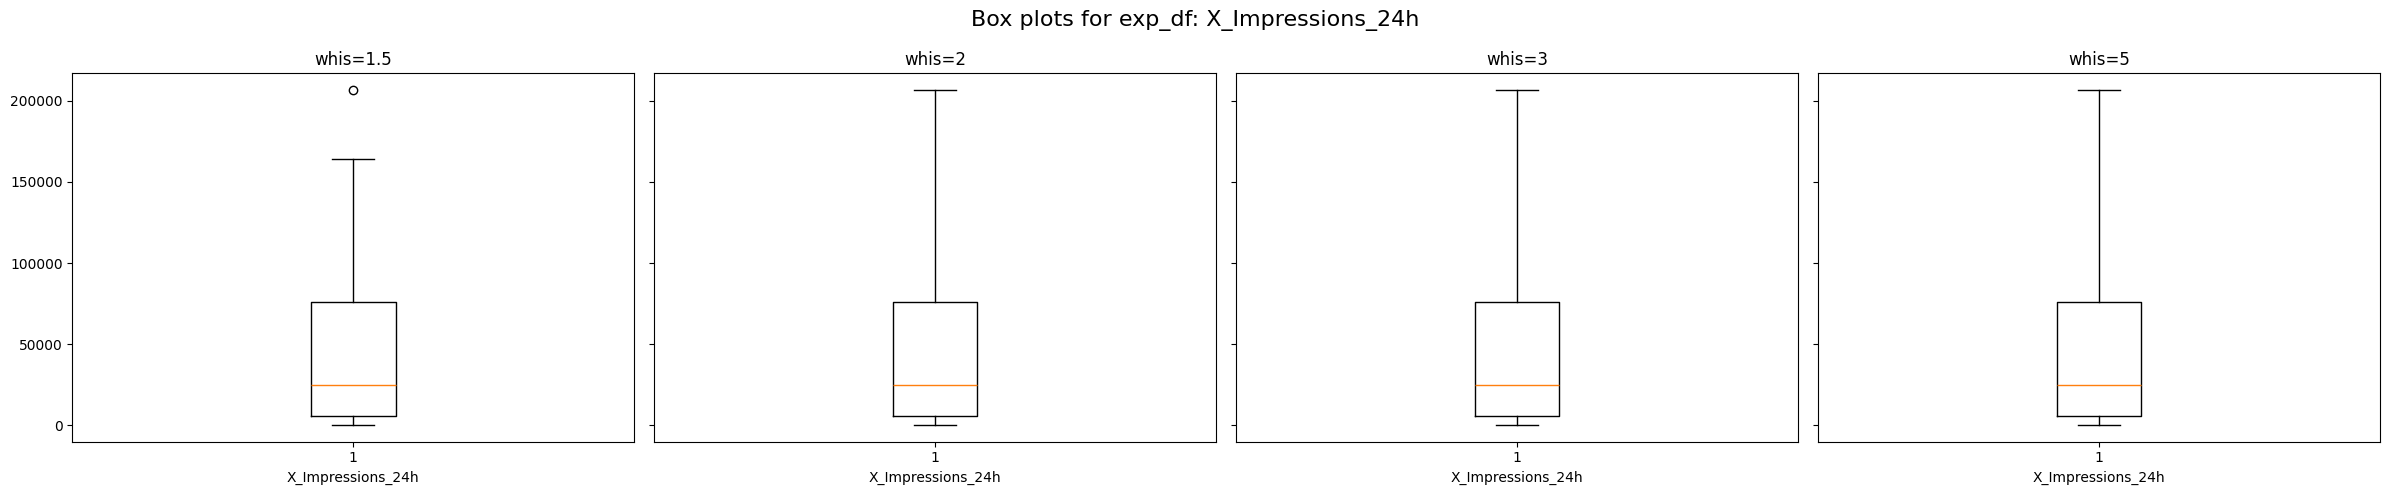

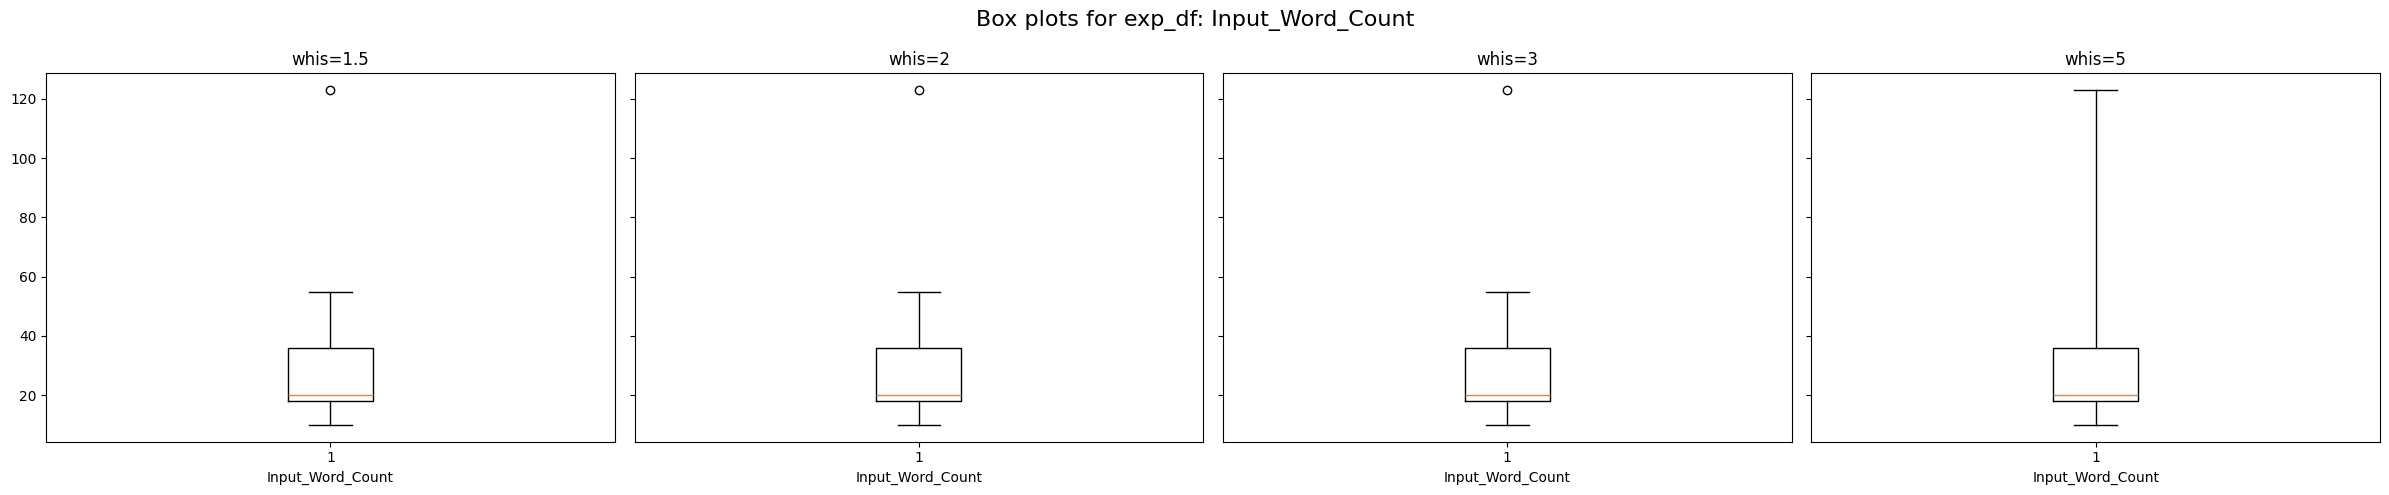

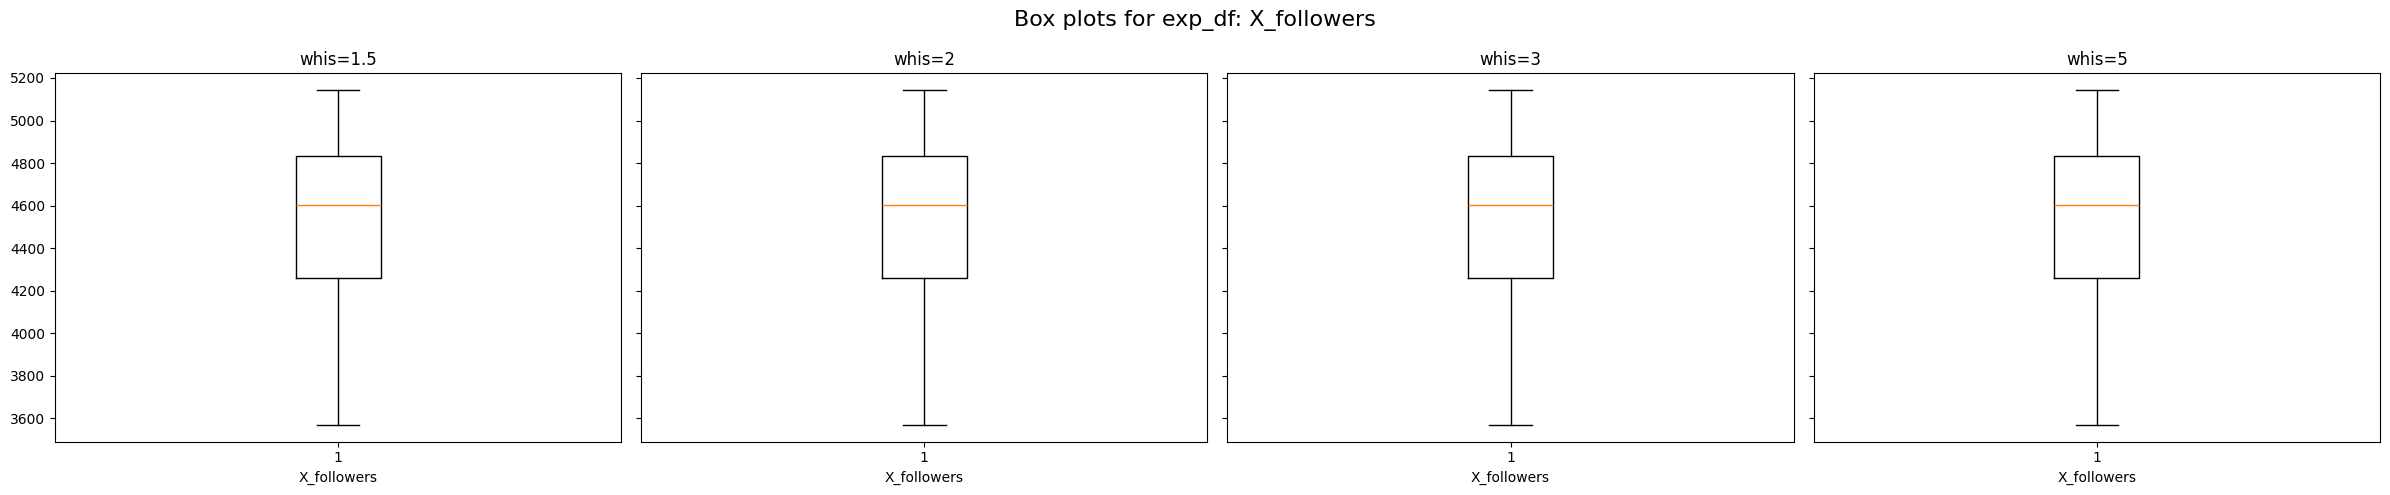

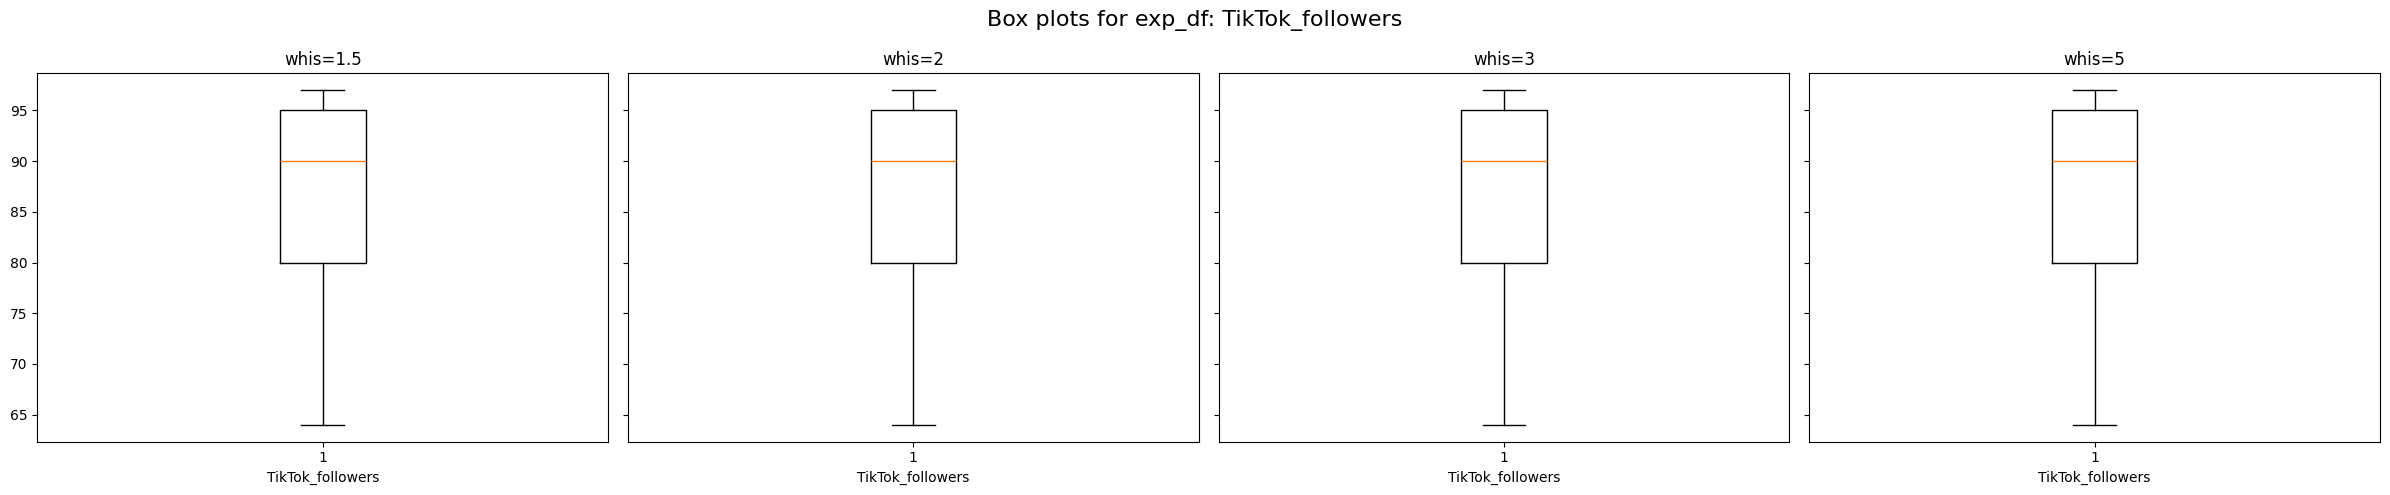

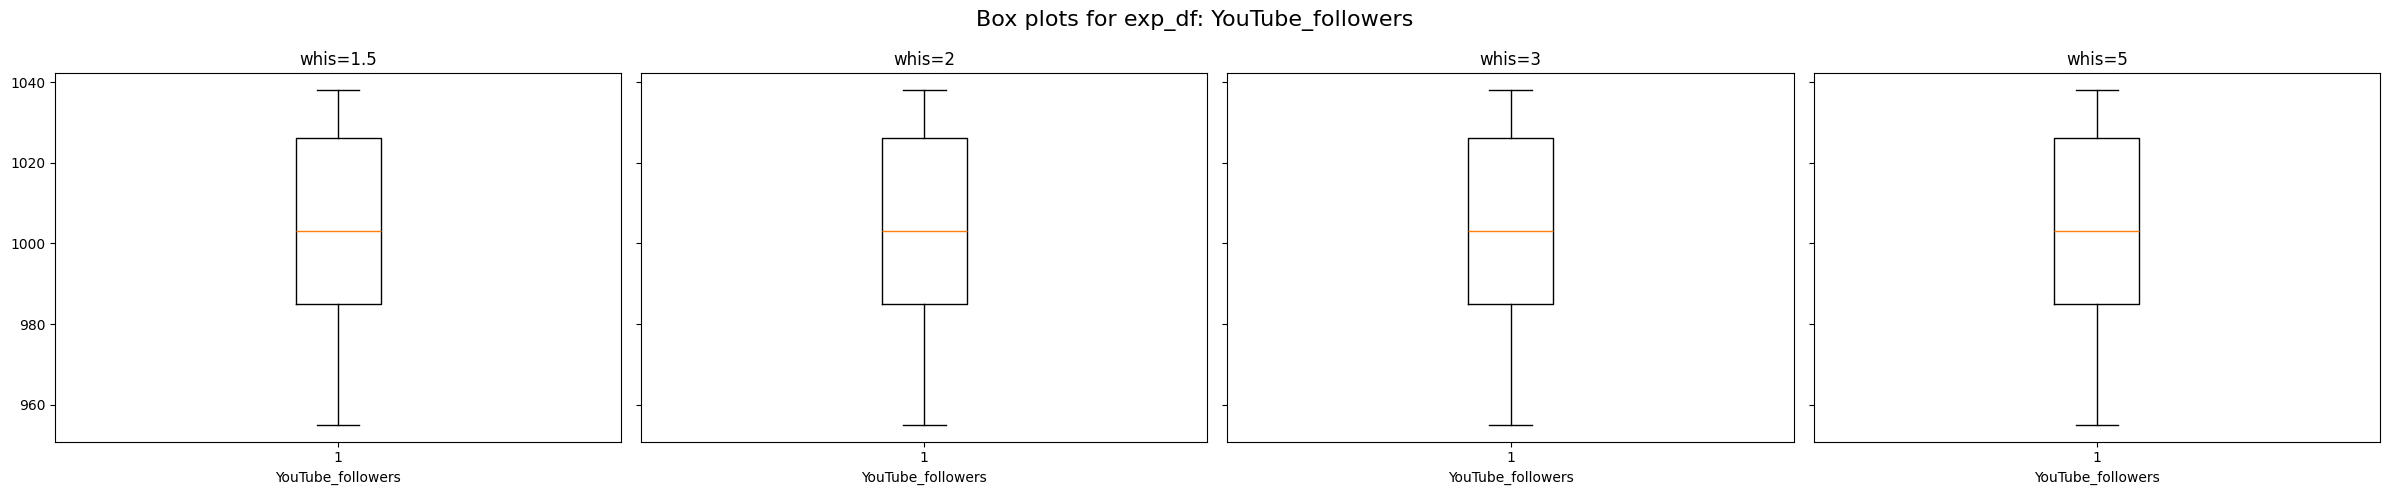

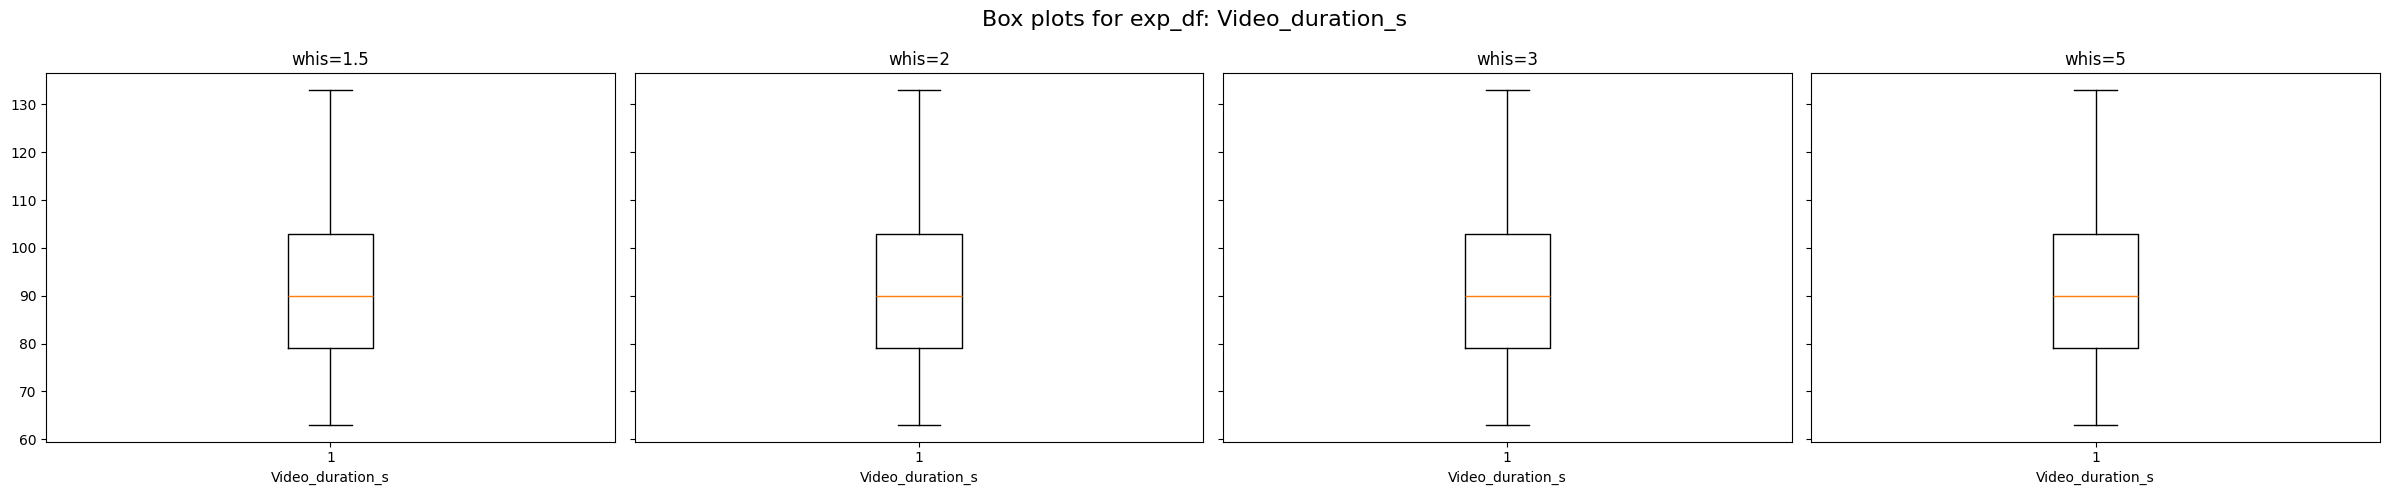

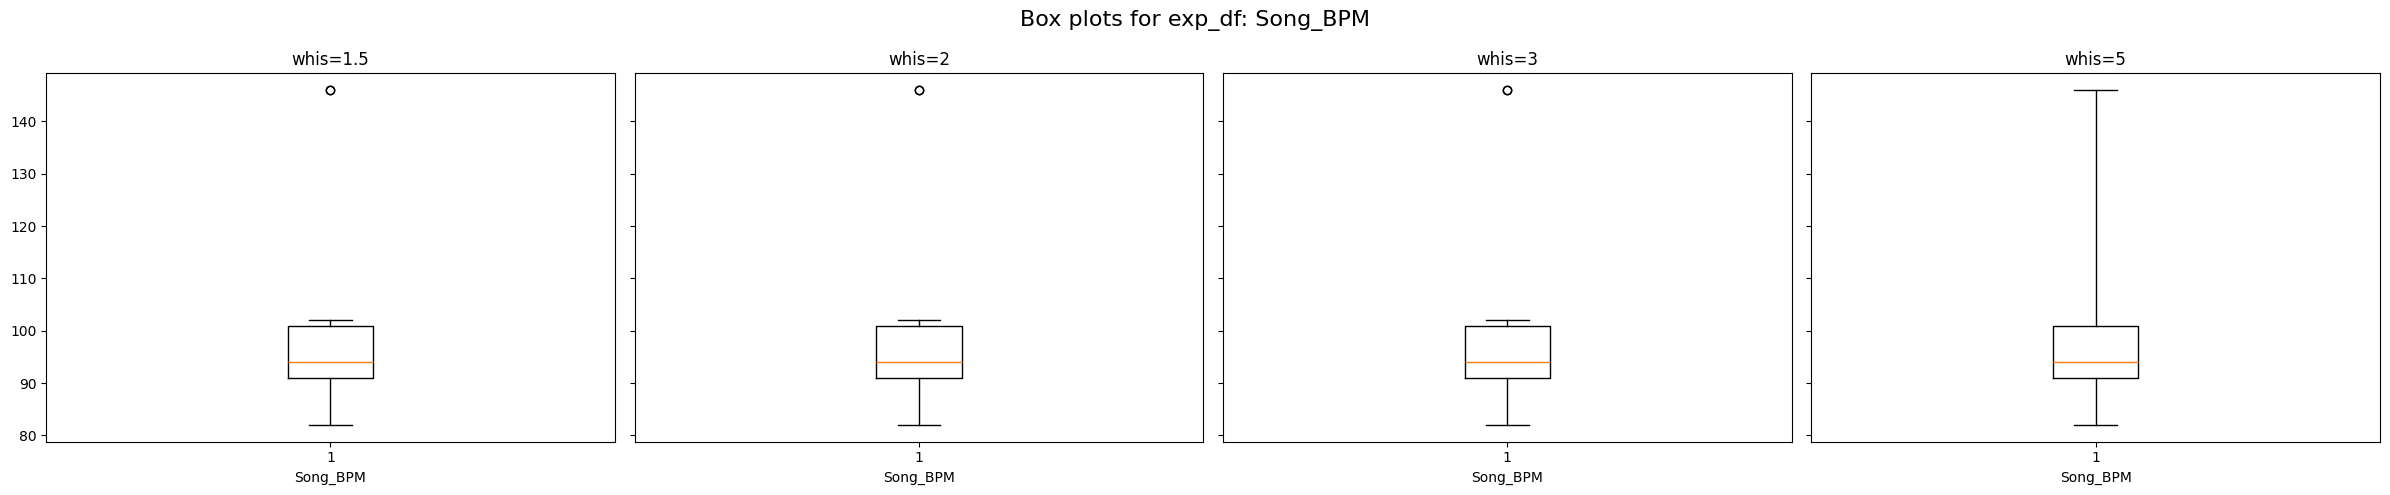

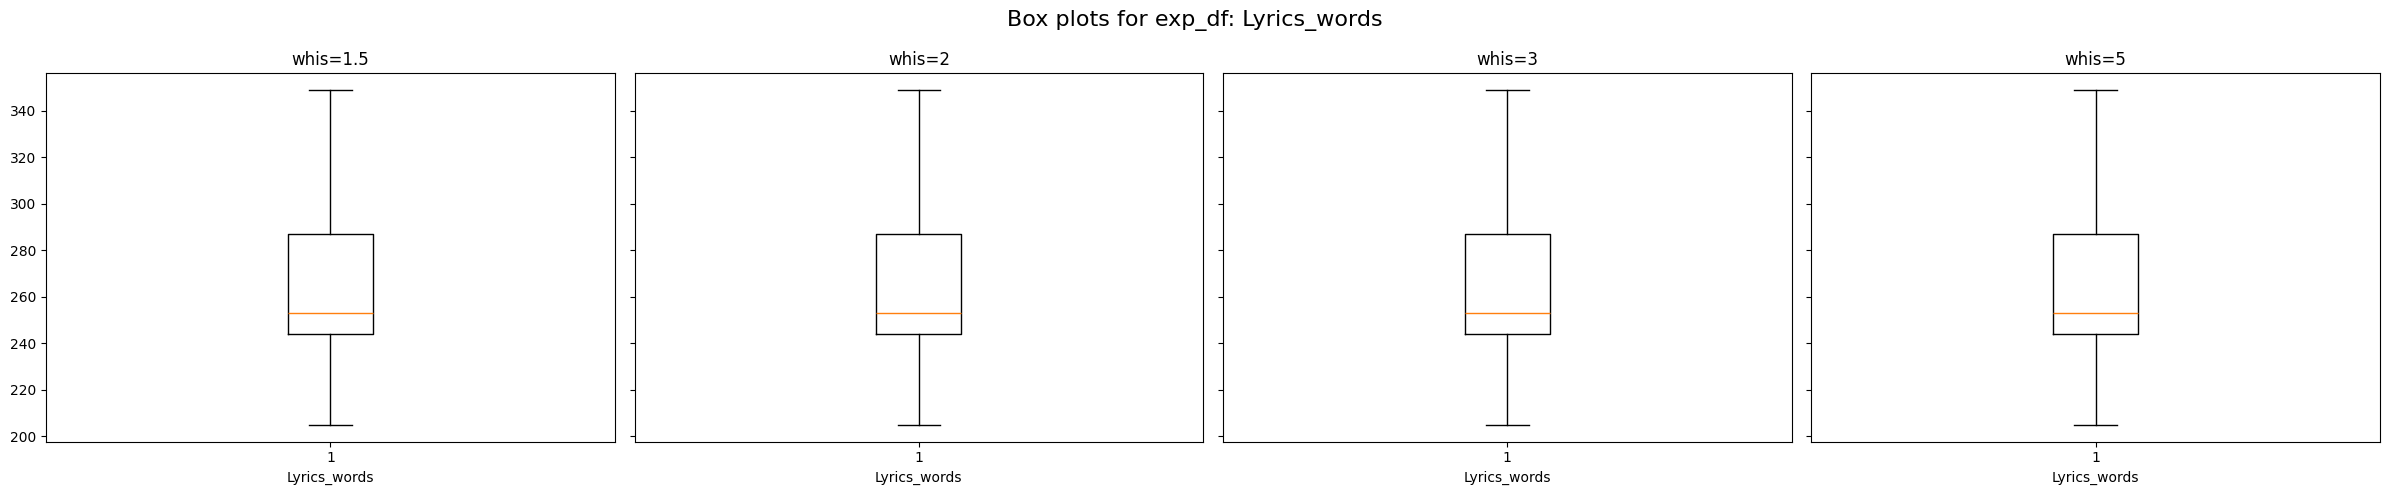

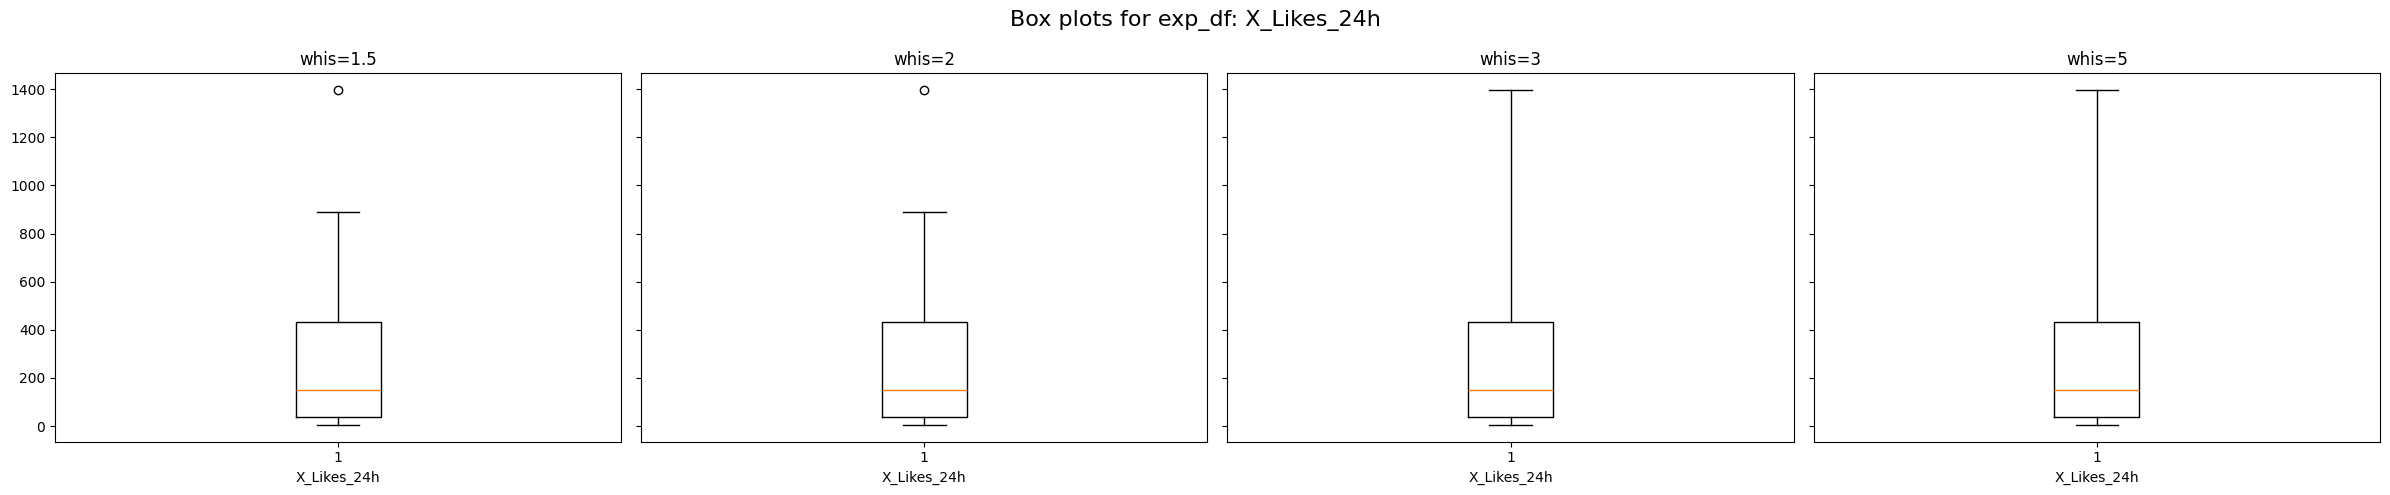

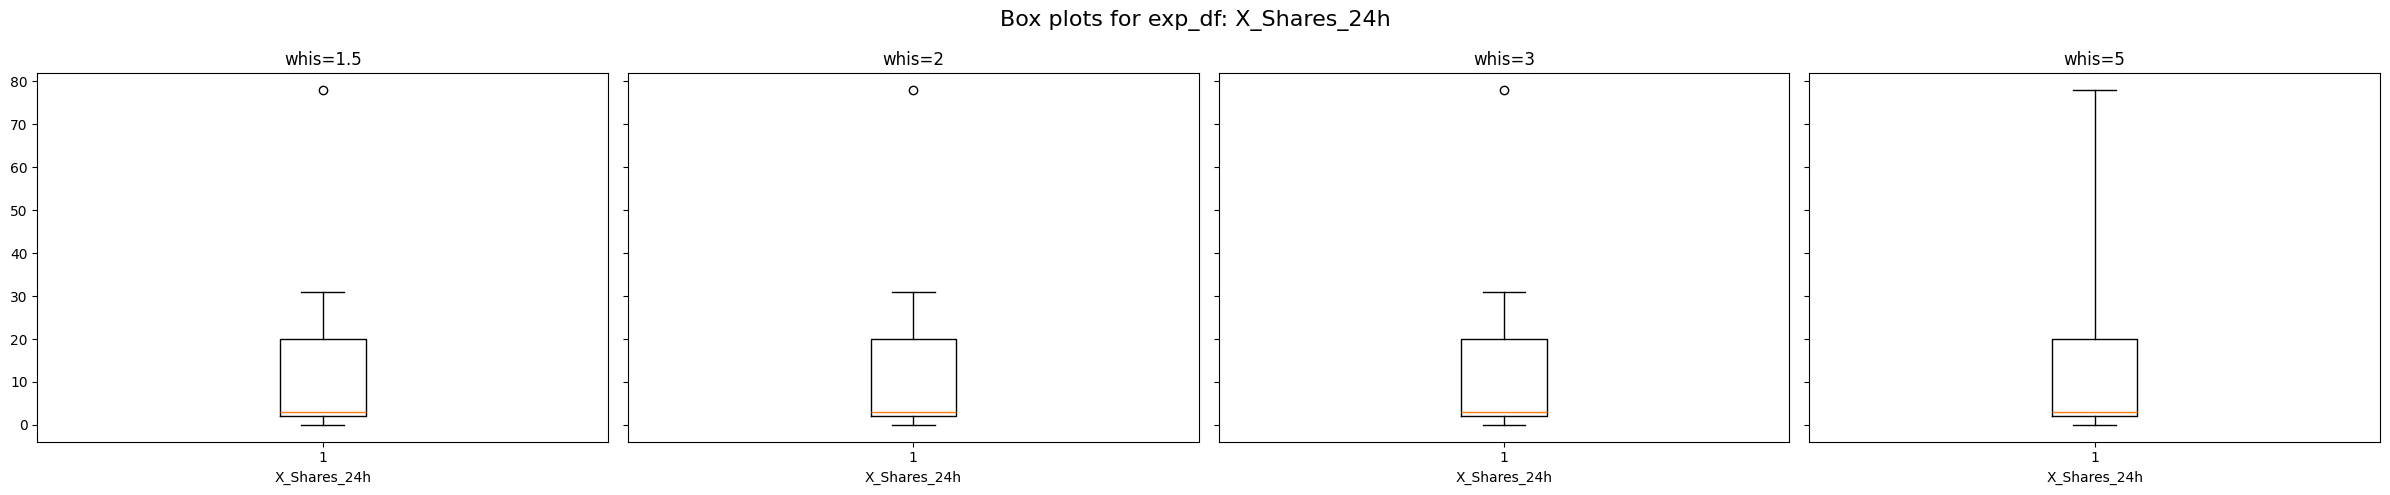

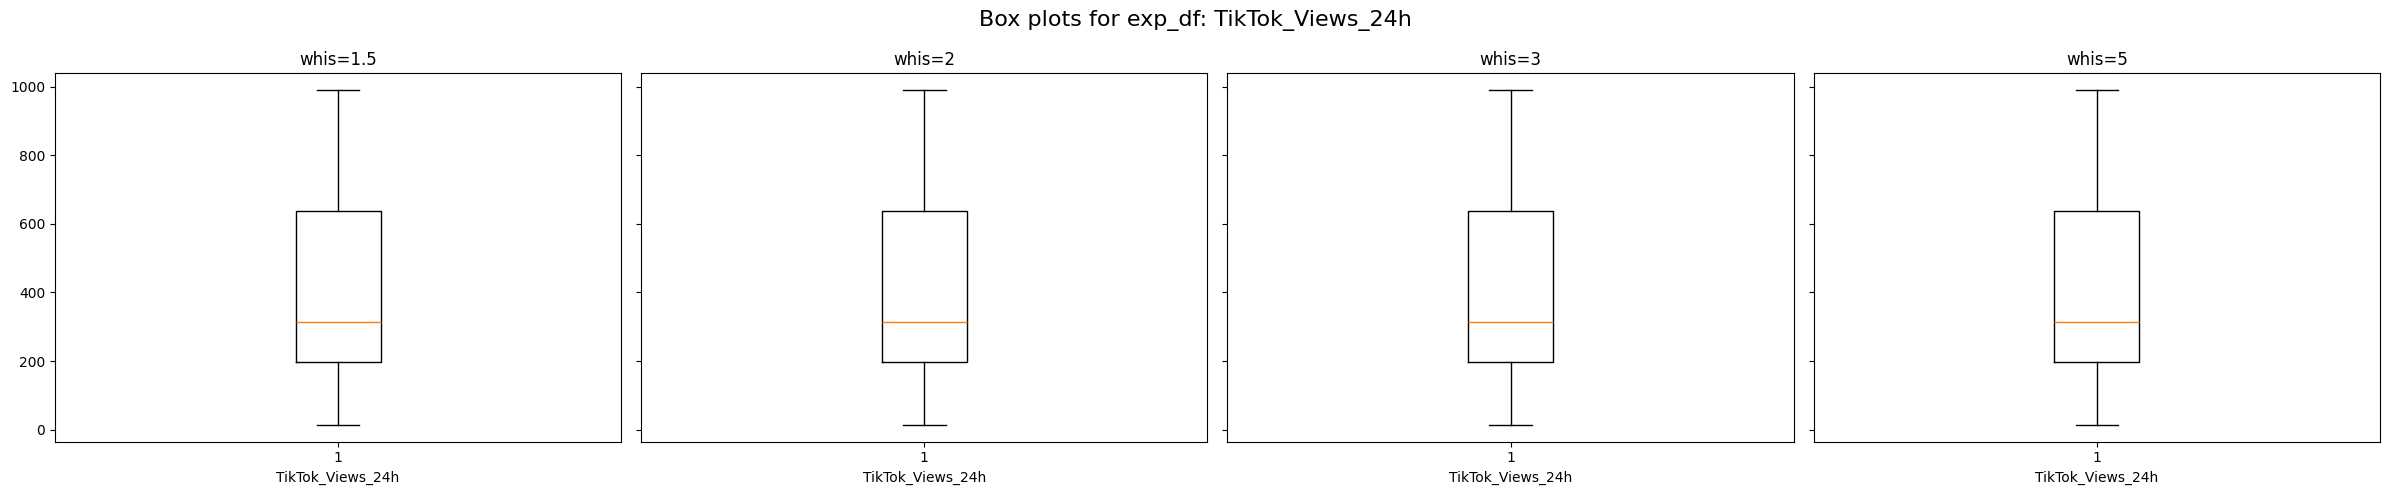

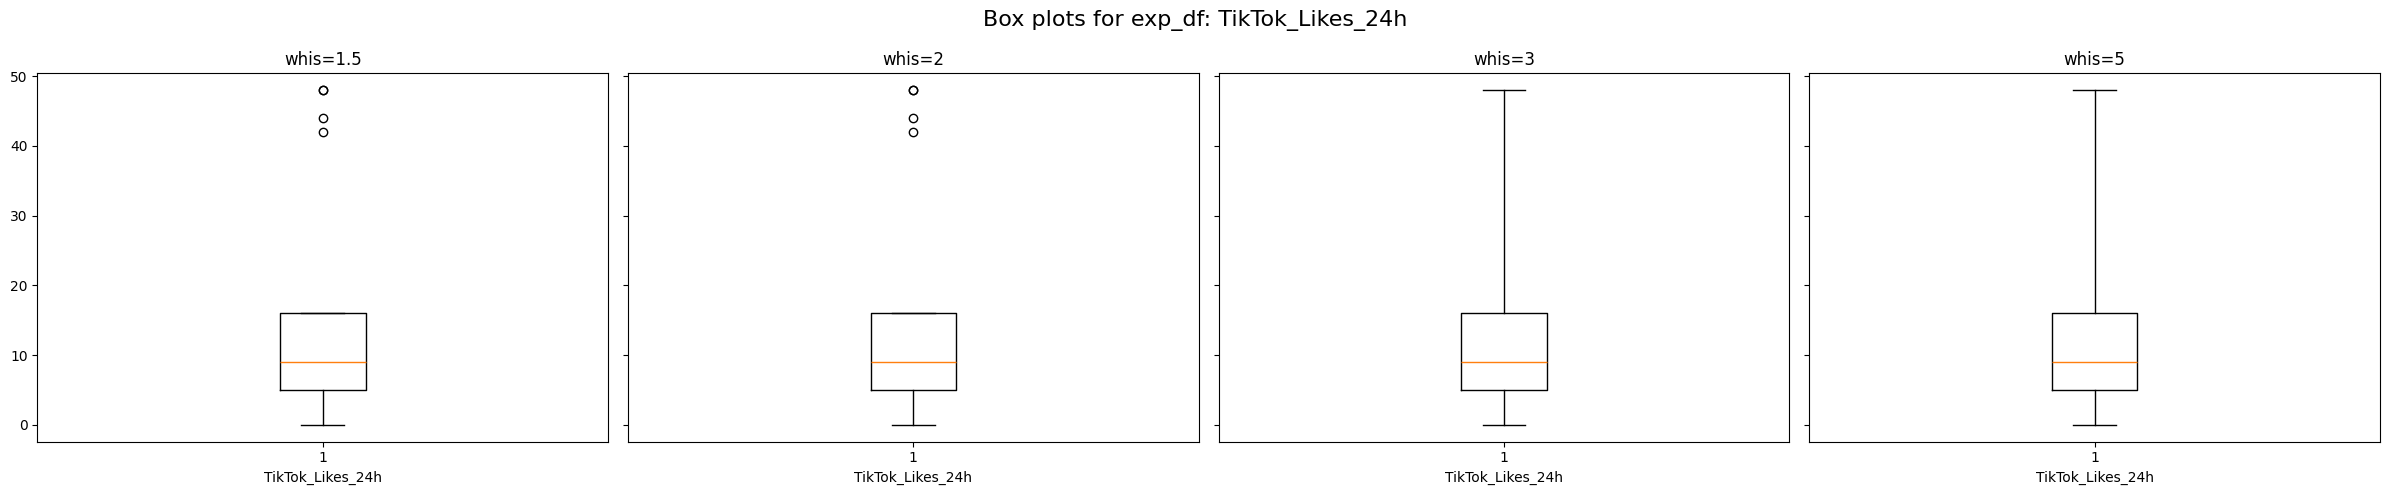

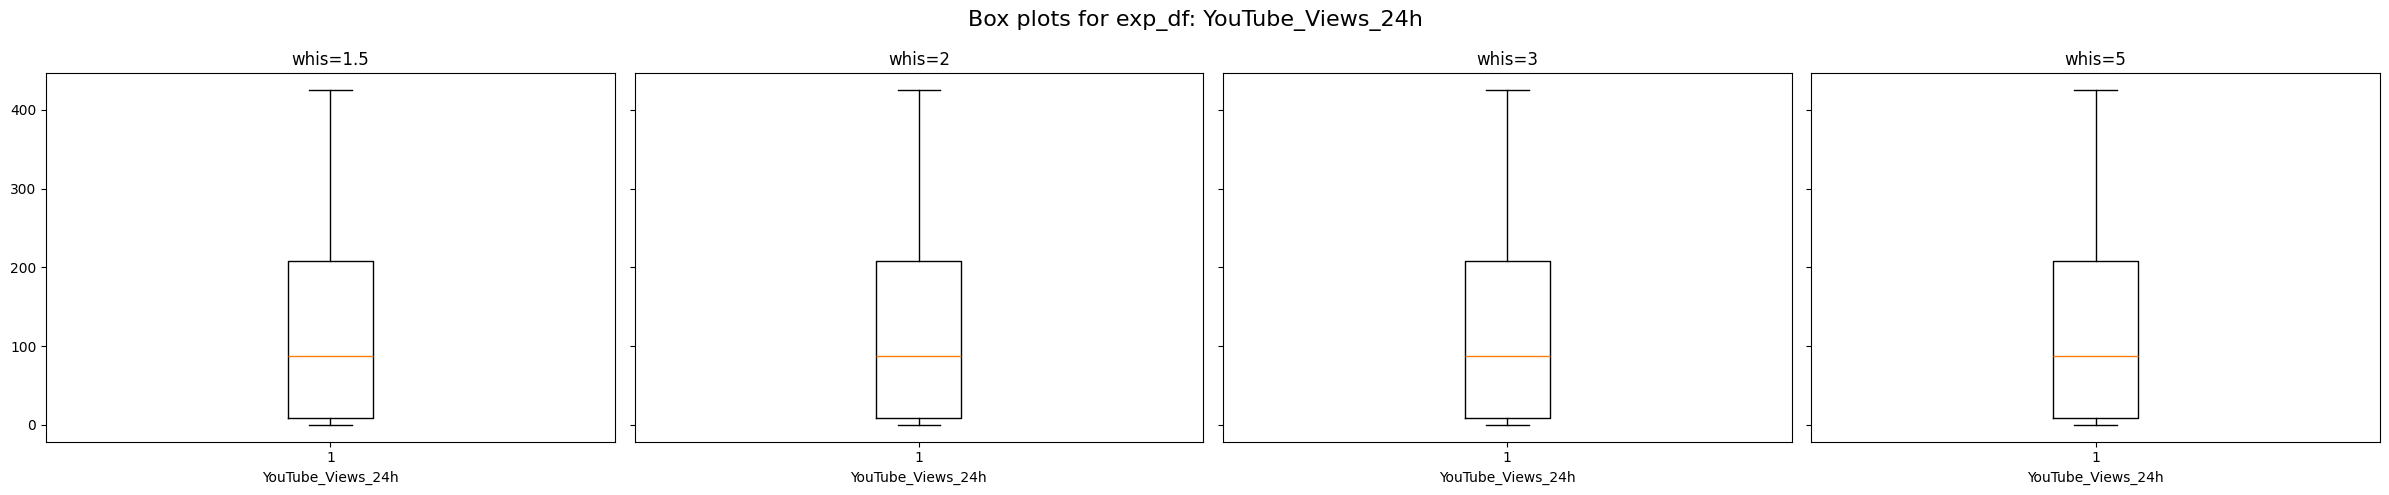

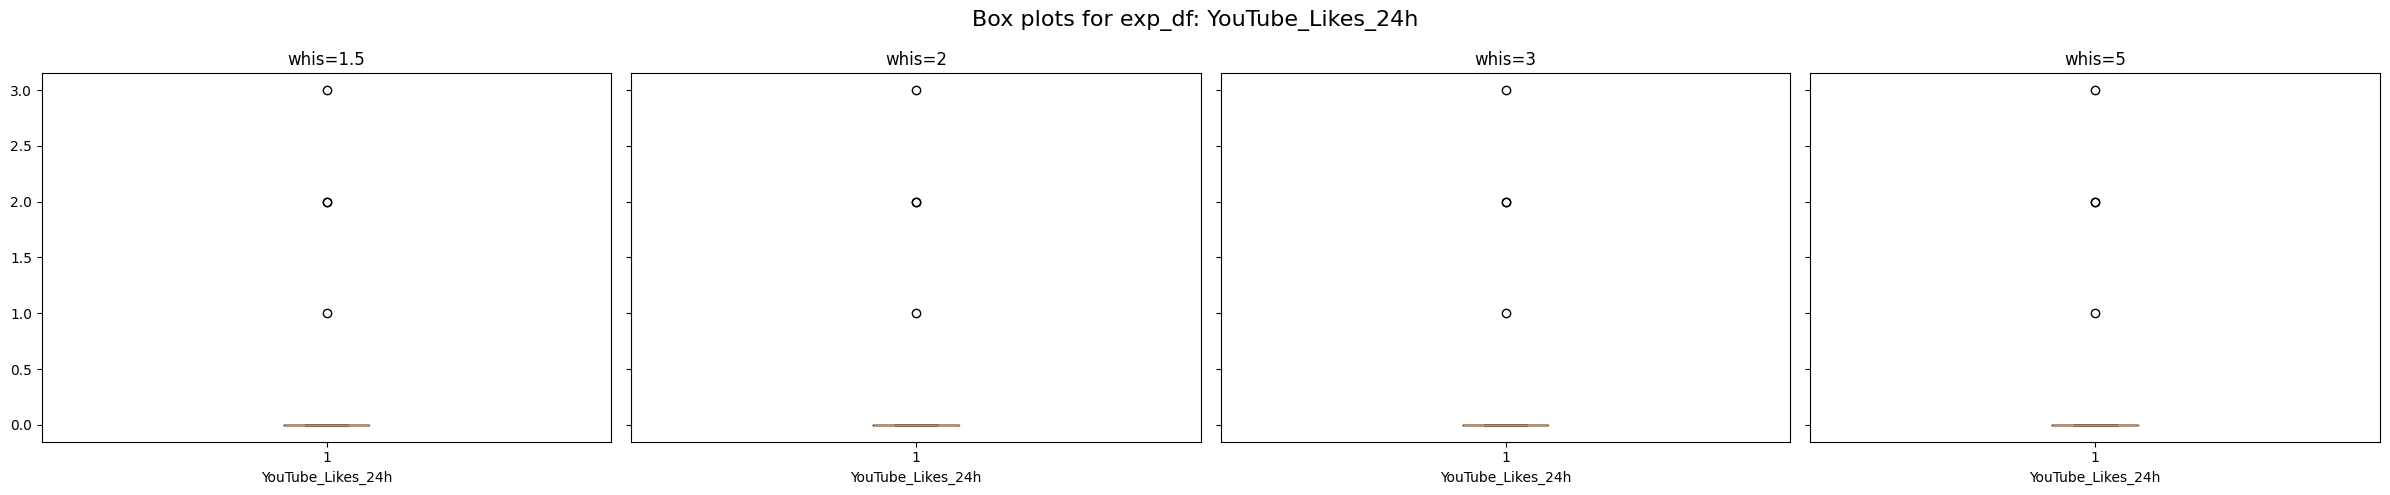

In [ ]:


# Only model-level numeric cols (only experiment-level metrics)
numeric_cols_exp = [
    'X_Impressions_24h',
    'Input_Word_Count',
    'X_followers',
    'TikTok_followers',
    'YouTube_followers',
    'Video_duration_s',
    'Song_BPM',
    'Lyrics_words',
    'X_Likes_24h',
    'X_Shares_24h',
    'TikTok_Views_24h',
    'TikTok_Likes_24h',
    'YouTube_Views_24h',
    'YouTube_Likes_24h'
]

# Keep only columns that actually exist in df
numerical_cols = [c for c in numeric_cols_exp if c in exp_df.columns]
missing = [c for c in numeric_cols_exp if c not in exp_df.columns]
if missing:
    print("Missing columns in df (skipped):")
    for c in missing:
        print(" -", c)

# Whisker values to test
whis_values = [1.5, 2, 3, 5]

for col in numerical_cols:
    fig, axes = plt.subplots(1, len(whis_values), figsize=(24, 5), sharey=True)

    for ax, whis in zip(axes, whis_values):
        ax.boxplot(exp_df[col].dropna(), whis=whis)
        ax.set_title(f"whis={whis}", fontsize=12)
        ax.set_xlabel(col, fontsize=10)
        ax.tick_params(labelsize=10)

    fig.suptitle(f"Box plots for exp_df: {col}", fontsize=16)
    plt.tight_layout()
    plt.show()

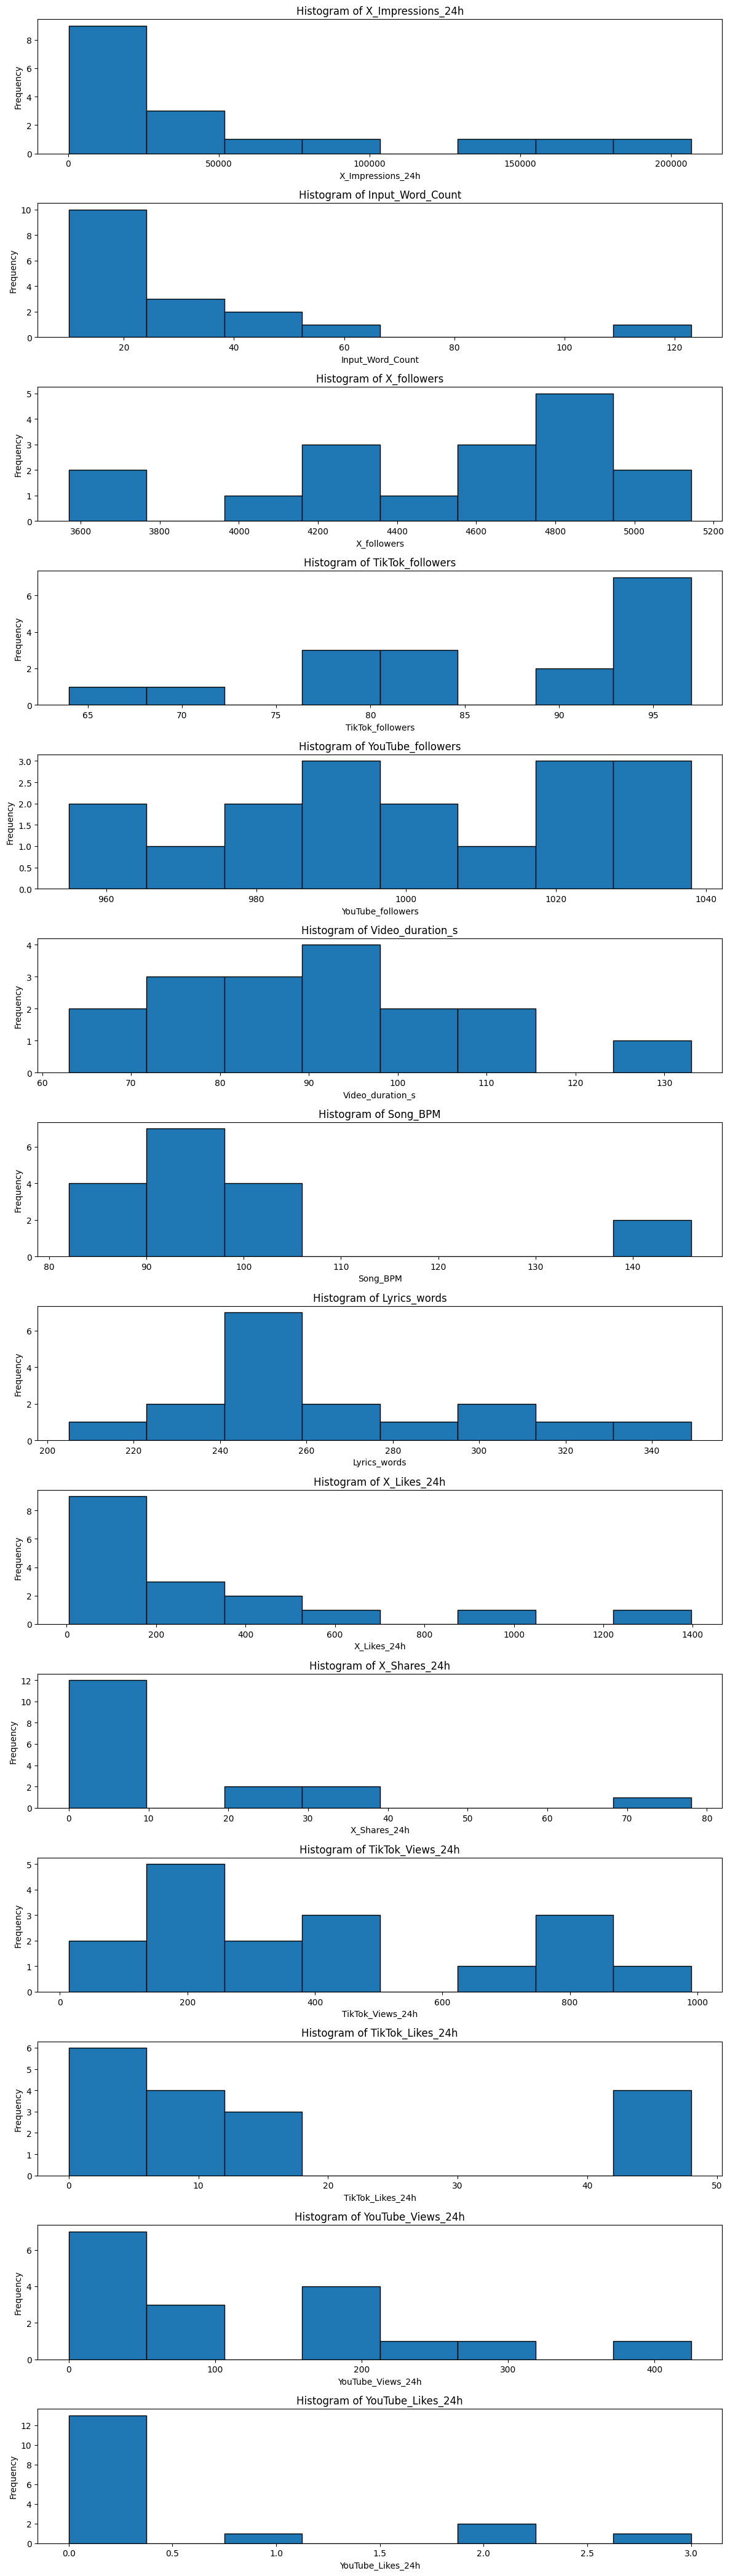

In [ ]:


if len(numerical_cols) == 0:
    print("No numeric columns found to plot.")
else:
    n = len(numerical_cols)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, 3 * n))


    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, numerical_cols):
        s = exp_df[col].dropna()


        bins = min(30, max(5, int(np.sqrt(len(s)) * 2)))

        ax.hist(s, bins=bins, edgecolor='black')
        ax.set_title(f"Histogram of {col}")
        ax.set_ylabel("Frequency")
        ax.set_xlabel(col)

    plt.tight_layout()
    plt.show()


exp_df

In [ ]:
# Get basic statistics for numerical columns
pd.set_option("display.max_columns", None)
print(exp_df.describe())

# Get statistics for categorical columns
print(exp_df.describe(include=['object', 'string']))

       X_Impressions_24h  Experiment_Type  Visual_Type  Input_Word_Count  \
count          17.000000             17.0         17.0         17.000000   
mean        50188.176471         0.235294     0.764706         31.294118   
min           214.000000              0.0          0.0         10.000000   
25%          5502.000000              0.0          1.0         18.000000   
50%         24987.000000              0.0          1.0         20.000000   
75%         75948.000000              0.0          1.0         36.000000   
max        206661.000000              1.0          1.0        123.000000   
std         63804.350549         0.437237     0.437237         26.881138   

                   Date_Generated                 Date_posted  \
count                          17                          17   
mean   2026-01-03 07:03:31.764706  2026-01-06 18:21:10.588235   
min           2025-12-10 00:00:00         2025-12-10 00:00:00   
25%           2025-12-18 00:00:00         2025-12-24 00

df

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 52 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Experiment ID                        68 non-null     str           
 1   LLM Model                            68 non-null     str           
 2   Prompt                               68 non-null     str           
 3   Experiment Type                      68 non-null     Int64         
 4   Visual type                          68 non-null     Int64         
 5   LLM Reasoning Time (s)               68 non-null     int64         
 6   LLM Response Time (s)                68 non-null     int64         
 7   Date Generated                       68 non-null     datetime64[us]
 8   Time ET of the Generation            68 non-null     object        
 9   Reasoning Total words                68 non-null     int64         
 10  Reasoning Total characters 

In [ ]:
# Get basic statistics for numerical columns
pd.set_option("display.max_columns", None)
print(df.describe())

# Get statistics for categorical columns
print(df.describe(include=['object', 'string']))

       Experiment Type  Visual type  LLM Reasoning Time (s)  \
count             68.0         68.0               68.000000   
mean          0.235294     0.764706               58.926471   
min                0.0          0.0                3.000000   
25%                0.0          1.0               12.000000   
50%                0.0          1.0               22.000000   
75%                0.0          1.0               71.250000   
max                1.0          1.0              466.000000   
std           0.427336     0.427336               81.005862   

       LLM Response Time (s)              Date Generated  \
count              68.000000                          68   
mean              138.500000  2026-01-03 07:03:31.764706   
min                 7.000000         2025-12-10 00:00:00   
25%                51.000000         2025-12-18 00:00:00   
50%               112.000000         2025-12-30 00:00:00   
75%               176.250000         2026-01-20 00:00:00   
max         

<a name='1.3'></a>
## 1.3 - Data Exploration (EDA)

### Model Dataframe

In [ ]:
df.head()

,Experiment ID,LLM Model,Prompt,Experiment Type,Visual type,LLM Reasoning Time (s),LLM Response Time (s),Date Generated,Time ET of the Generation,Reasoning Total words,Reasoning Total characters,Reasoning Total sentences,Reasoning top keyword,Reasoning top keyword repetitions,Input Word Count,Lines of HTML,Model Family,Platform,Code in Reasoning?,prompt_adherence_score (0-10),gemini_pa (0-10),functional_correctness_score (0-10),gemini_fc (0-10),ui_score (0-10),gemini_ui (0-10),Performance Score (0-10),gemini perf (0-10),Male / Female Song's Voice,Song Key,Song BPM,Song style,Lyrics number of words,LLM used for song,Suno version,Date posted,Day of the week posted,Time ET posted on X,X Followers posted,Tik Tok Followers posted,Youtube Followers posted,Video Duration (s),X Impressions (24 h),X Likes (24h),X Shares (24h),Tik Tok Views (24 h),Tik Tok Likes (24h),Youtube short views (24 h),Youtube short Likes (24h),Time ET of the Generation_hour,Time ET of the Generation_minute,Time ET posted on X_hour,Time ET posted on X_minute
0,flappy_bird_1210,gpt-5.1-extended-thinking,Make a game like flappy bird using HTML/CSS/JS...,1,1,44,106,2025-12-10,17:01:00,326,2010,23,Game,12,13,427,GPT,1,0,10.0,10.0,9.5,10.0,7.5,9.0,9.20,9.75,1,G Major,102,"hip hop, pop",312,gemini-3-pro,1,2025-12-10,1,20:19:00,3570,64,955,133,135606,433,22,259,9,265,3,17,1,20,19
1,flappy_bird_1210,gemini-3-pro,Make a game like flappy bird using HTML/CSS/JS...,1,1,17,44,2025-12-10,16:54:00,261,1534,19,I'm,9,13,324,Gemini,1,0,10.0,10.0,9.0,10.0,6.0,8.0,8.65,9.50,1,G Major,102,"hip hop, pop",312,gemini-3-pro,1,2025-12-10,1,20:19:00,3570,64,955,133,135606,433,22,259,9,265,3,16,54,20,19
2,flappy_bird_1210,grok-4.1-thinking,Make a game like flappy bird using HTML/CSS/JS...,1,1,11,19,2025-12-10,17:50:00,114,704,6,Game,6,13,201,Grok,1,0,10.0,10.0,9.0,10.0,6.0,8.0,8.65,9.50,1,G Major,102,"hip hop, pop",312,gemini-3-pro,1,2025-12-10,1,20:19:00,3570,64,955,133,135606,433,22,259,9,265,3,17,50,20,19
3,flappy_bird_1210,opus-4.5-thinking-32k,Make a game like flappy bird using HTML/CSS/JS...,1,1,61,124,2025-12-10,17:36:00,1363,12726,23,Pipes,18,13,503,Claude,0,1,10.0,10.0,9.5,10.0,8.0,10.0,9.33,10.00,1,G Major,102,"hip hop, pop",312,gemini-3-pro,1,2025-12-10,1,20:19:00,3570,64,955,133,135606,433,22,259,9,265,3,17,36,20,19
4,drifting_car_1213,gpt-5.2-extended-thinking,Create a 3D simulation of a formula 1 car perf...,0,1,23,102,2025-12-11,19:33:00,229,1374,16,Will,8,24,640,GPT,1,0,0.0,2.0,0.0,1.0,1.0,5.0,0.25,2.40,0,G minor,94,"hip hop, pop",205,gemini-3-pro,1,2025-12-13,0,07:55:00,3760,70,959,63,206661,1396,78,14,0,106,0,19,33,7,55


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 52 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Experiment ID                        68 non-null     str           
 1   LLM Model                            68 non-null     str           
 2   Prompt                               68 non-null     str           
 3   Experiment Type                      68 non-null     Int64         
 4   Visual type                          68 non-null     Int64         
 5   LLM Reasoning Time (s)               68 non-null     int64         
 6   LLM Response Time (s)                68 non-null     int64         
 7   Date Generated                       68 non-null     datetime64[us]
 8   Time ET of the Generation            68 non-null     object        
 9   Reasoning Total words                68 non-null     int64         
 10  Reasoning Total characters 

#### Does code in reasoning correlate with a higher final output score?

In [ ]:
print(df["Code in Reasoning?"].unique())

<IntegerArray>
[0, 1]
Length: 2, dtype: Int64


0=no
1=yes

Counts by coding in reasoning:
Code in Reasoning?
0    53
1    15
Name: count, dtype: int64

0 = No code in reasoning, 1 = Code in reasoning


Performance Score (0-10)                       \
                                      count   mean median    std   
Code in Reasoning?                                                 
0                                        53  7.381    8.5  2.683   
1                                        15  8.493    9.3  1.546   

                   gemini perf (0-10)                       
                                count   mean median    std  
Code in Reasoning?                                          
0                                  53  8.003   9.10  2.444  
1                                  15  8.817   9.75  1.870


Mean comparison:


,No code mean,Code mean,Difference (Code - No code)
Performance Score (0-10),7.380566,8.492667,1.112
gemini perf (0-10),8.002830,8.816667,0.814



Statistical comparison:


,Metric,Mean_NoCode,Mean_Code,Diff_Code_minus_NoCode,Median_NoCode,Median_Code,MannWhitney_U,MW_p_value,PointBiserial_r,PB_p_value
0,Performance Score (0-10),7.3806,8.4927,1.1121,8.5,9.30,527.5,0.0554,0.1851,0.1308
1,gemini perf (0-10),8.0028,8.8167,0.8138,9.1,9.75,504.0,0.1148,0.1452,0.2374


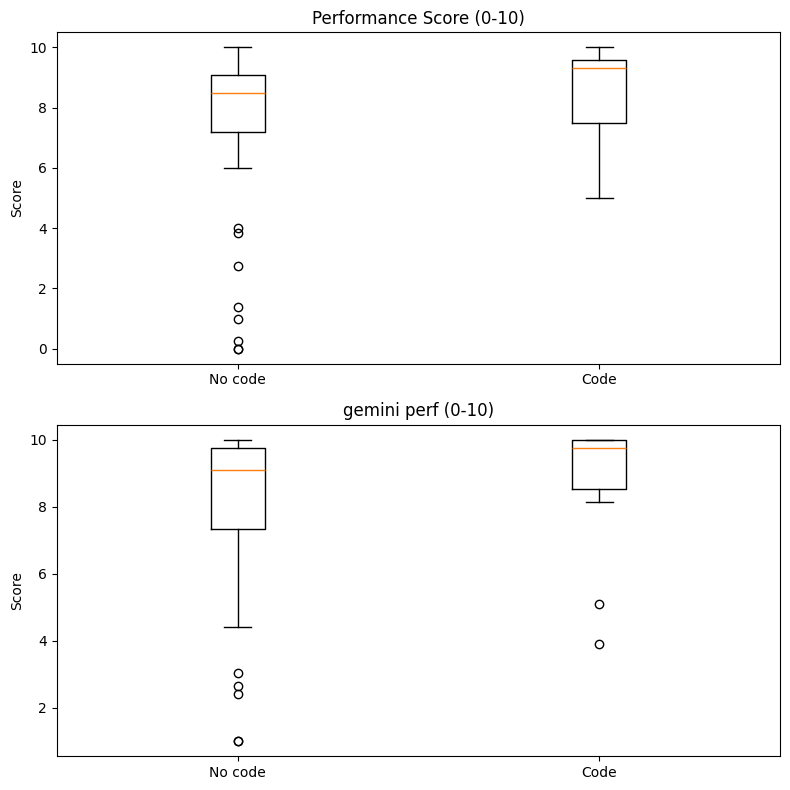

In [ ]:
from scipy.stats import mannwhitneyu, pointbiserialr

analysis_df = df.copy()

final_metrics = [
    "Performance Score (0-10)",
    "gemini perf (0-10)"
]

subset = analysis_df.dropna(subset=["Code in Reasoning?"]).copy()
subset["Code in Reasoning?"] = subset["Code in Reasoning?"].astype(int)

print("Counts by coding in reasoning:")
print(subset["Code in Reasoning?"].value_counts().sort_index())
print("\n0 = No code in reasoning, 1 = Code in reasoning")

group_summary = (
    subset
    .groupby("Code in Reasoning?")[final_metrics]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)

display(group_summary)

mean_compare = pd.DataFrame({
    "No code mean": subset.loc[subset["Code in Reasoning?"] == 0, final_metrics].mean(),
    "Code mean": subset.loc[subset["Code in Reasoning?"] == 1, final_metrics].mean()
})
mean_compare["Difference (Code - No code)"] = (
    mean_compare["Code mean"] - mean_compare["No code mean"]
).round(3)

print("\nMean comparison:")
display(mean_compare)

results = []

group0 = subset[subset["Code in Reasoning?"] == 0]
group1 = subset[subset["Code in Reasoning?"] == 1]

for metric in final_metrics:
    x0 = group0[metric].dropna()
    x1 = group1[metric].dropna()

    u_stat, p_val = mannwhitneyu(x1, x0, alternative="two-sided")
    r_pb, r_p = pointbiserialr(subset["Code in Reasoning?"], subset[metric])

    results.append({
        "Metric": metric,
        "Mean_NoCode": x0.mean(),
        "Mean_Code": x1.mean(),
        "Diff_Code_minus_NoCode": x1.mean() - x0.mean(),
        "Median_NoCode": x0.median(),
        "Median_Code": x1.median(),
        "MannWhitney_U": u_stat,
        "MW_p_value": p_val,
        "PointBiserial_r": r_pb,
        "PB_p_value": r_p
    })

results_df = pd.DataFrame(results).round(4)

print("\nStatistical comparison:")
display(results_df)

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

for ax, metric in zip(axes, final_metrics):
    data_to_plot = [
        subset.loc[subset["Code in Reasoning?"] == 0, metric].dropna(),
        subset.loc[subset["Code in Reasoning?"] == 1, metric].dropna()
    ]
    ax.boxplot(data_to_plot, tick_labels=["No code", "Code"])
    ax.set_title(metric)
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

Code in Reasoning?,No code,Code
Model Family,,
Claude,3,14
GPT,16,1
Gemini,17,0
Grok,17,0


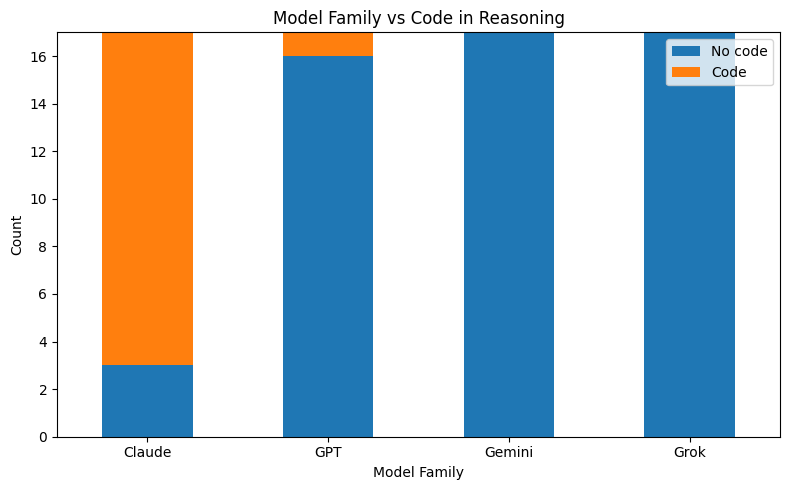

In [ ]:
plot_df = df.copy()
plot_df["Code in Reasoning?"] = plot_df["Code in Reasoning?"].astype(int)

# counts by model family and code/no-code
family_code_counts = (
    plot_df.groupby(["Model Family", "Code in Reasoning?"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "No code", 1: "Code"})
)

display(family_code_counts)

# stacked bar chart
family_code_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Model Family vs Code in Reasoning")
plt.xlabel("Model Family")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

#### Are the lines of HTML related to the final human and Gemini total performance score?

Rows used: 68


,Lines of HTML,Performance Score (0-10),gemini perf (0-10)
count,68.000,68.000,68.000
mean,496.397,7.626,8.182
std,297.773,2.510,2.341
min,108.000,0.000,1.000
25%,239.250,7.268,7.475
50%,465.000,8.605,9.150
75%,650.500,9.200,9.750
max,1422.000,10.000,10.000


Correlation results:


,Outcome,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,Performance Score (0-10),0.1850,0.1309,0.2432,0.0456
1,gemini perf (0-10),0.3342,0.0053,0.4009,0.0007


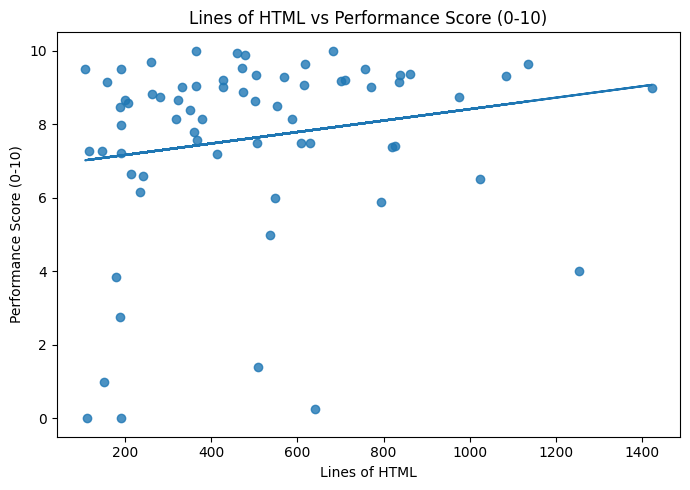

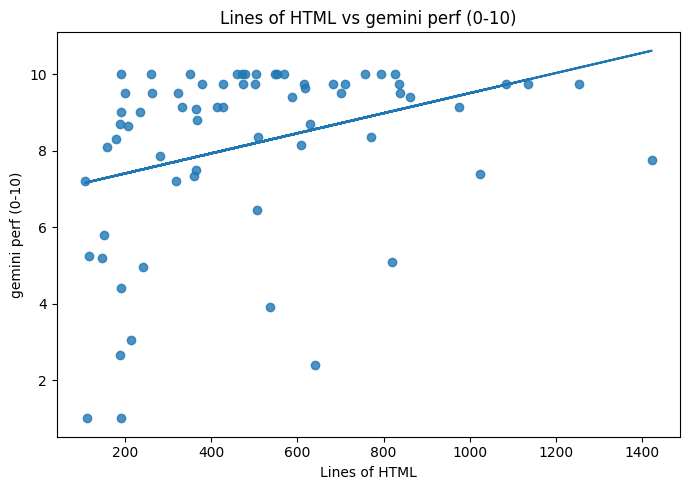

Performance by HTML line quartile:


Performance Score (0-10)                       \
                                       count   mean median    std   
HTML Lines Quartile                                                 
Q1 Lowest                                 17  6.119   7.28  3.310   
Q2                                        17  8.586   8.75  0.935   
Q3                                        17  7.412   8.50  2.807   
Q4 Highest                                17  8.386   9.15  1.619   

                    gemini perf (0-10)                       
                                 count   mean median    std  
HTML Lines Quartile                                          
Q1 Lowest                           17  6.282   7.20  3.001  
Q2                                  17  8.747   9.15  1.360  
Q3                                  17  8.603   9.75  2.276  
Q4 Highest                          17  9.097   9.75  1.291


Quick interpretation helper:
- Performance Score (0-10): positive relationship, Spearman rho = 0.243, p = 0.0456; Pearson r = 0.185, p = 0.1309
- gemini perf (0-10): positive relationship, Spearman rho = 0.401, p = 0.0007; Pearson r = 0.334, p = 0.0053


In [ ]:
from scipy.stats import spearmanr, pearsonr

# -----------------------------
# 1) Setup
# -----------------------------
analysis_df = df.copy()

x_col = "Lines of HTML"
y_cols = ["Performance Score (0-10)", "gemini perf (0-10)"]

subset = analysis_df[[x_col] + y_cols].dropna().copy()

print("Rows used:", len(subset))
display(subset[[x_col] + y_cols].describe().round(3))

# -----------------------------
# 2) Correlations
# -----------------------------
results = []

for y_col in y_cols:
    x = subset[x_col]
    y = subset[y_col]

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    results.append({
        "Outcome": y_col,
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_rho": spearman_rho,
        "Spearman_p": spearman_p
    })

corr_df = pd.DataFrame(results).round(4)

print("Correlation results:")
display(corr_df)

# -----------------------------
# 3) Scatter plots
# -----------------------------
for y_col in y_cols:
    plt.figure(figsize=(7, 5))
    plt.scatter(subset[x_col], subset[y_col], alpha=0.8)

    # simple linear trend line
    z = np.polyfit(subset[x_col], subset[y_col], 1)
    p = np.poly1d(z)
    plt.plot(subset[x_col], p(subset[x_col]))

    plt.title(f"{x_col} vs {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 4) Bucket view
# -----------------------------
subset["HTML Lines Quartile"] = pd.qcut(
    subset[x_col],
    q=4,
    labels=["Q1 Lowest", "Q2", "Q3", "Q4 Highest"]
)

quartile_summary = (
    subset.groupby("HTML Lines Quartile")[y_cols]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)

print("Performance by HTML line quartile:")
display(quartile_summary)

# -----------------------------
# 5) Interpretation helper
# -----------------------------
print("\nQuick interpretation helper:")
for _, row in corr_df.iterrows():
    direction = (
        "positive"
        if row["Spearman_rho"] > 0
        else "negative"
        if row["Spearman_rho"] < 0
        else "no"
    )
    print(
        f"- {row['Outcome']}: {direction} relationship, "
        f"Spearman rho = {row['Spearman_rho']:.3f}, p = {row['Spearman_p']:.4f}; "
        f"Pearson r = {row['Pearson_r']:.3f}, p = {row['Pearson_p']:.4f}"
    )

#### Reasoning Efficiency Metric = Human Performance Score per model / Reasoning Time in seconds per model

In [ ]:
# -----------------------------------
# 1) Create efficiency_df
# -----------------------------------
efficiency_df = df.copy()

# Avoid division by zero
efficiency_df["Reasoning Efficiency (E_r)"] = np.where(
    efficiency_df["LLM Reasoning Time (s)"] > 0,
    efficiency_df["Performance Score (0-10)"] / efficiency_df["LLM Reasoning Time (s)"],
    np.nan
)

# Gemini-based Perf Score
efficiency_df["Gemini Reasoning Efficiency"] = np.where(
    efficiency_df["LLM Reasoning Time (s)"] > 0,
    efficiency_df["gemini perf (0-10)"] / efficiency_df["LLM Reasoning Time (s)"],
    np.nan
)

print("efficiency_df shape:", efficiency_df.shape)
display(
    efficiency_df[
        [
            "Experiment ID",
            "LLM Model",
            "Model Family",
            "LLM Reasoning Time (s)",
            "Performance Score (0-10)",
            "gemini perf (0-10)",
            "Reasoning Efficiency (E_r)",
            "Gemini Reasoning Efficiency"
        ]
    ].head()
)

# -----------------------------------
# 2) Summary stats
# -----------------------------------
print("Summary stats for human reasoning efficiency:")
display(
    efficiency_df["Reasoning Efficiency (E_r)"].describe().round(4)
)

print("Summary stats for Gemini reasoning efficiency:")
display(
    efficiency_df["Gemini Reasoning Efficiency"].describe().round(4)
)

# -----------------------------------
# 3) Top 5 and bottom 5
# -----------------------------------
cols_to_show = [
    "Experiment ID",
    "LLM Model",
    "Model Family",
    "LLM Reasoning Time (s)",
    "Performance Score (0-10)",
    "gemini perf (0-10)",
    "Reasoning Efficiency (E_r)",
    "Gemini Reasoning Efficiency"
]

top5_efficiency = (
    efficiency_df
    .sort_values("Reasoning Efficiency (E_r)", ascending=False)
    [cols_to_show]
    .head(5)
)

bottom5_efficiency = (
    efficiency_df
    .sort_values("Reasoning Efficiency (E_r)", ascending=True)
    [cols_to_show]
    .head(5)
)

print("Top 5 by human reasoning efficiency:")
display(top5_efficiency.round(4))

print("Bottom 5 by human reasoning efficiency:")
display(bottom5_efficiency.round(4))

# -----------------------------------
# 4) Model family
# -----------------------------------
family_efficiency = (
    efficiency_df
    .groupby("Model Family")[["Reasoning Efficiency (E_r)", "Gemini Reasoning Efficiency"]]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(4)
)

print("Reasoning efficiency by model family:")
display(family_efficiency)

efficiency_df shape: (68, 54)


,Experiment ID,LLM Model,Model Family,LLM Reasoning Time (s),Performance Score (0-10),gemini perf (0-10),Reasoning Efficiency (E_r),Gemini Reasoning Efficiency
0,flappy_bird_1210,gpt-5.1-extended-thinking,GPT,44,9.20,9.75,0.209091,0.221591
1,flappy_bird_1210,gemini-3-pro,Gemini,17,8.65,9.50,0.508824,0.558824
2,flappy_bird_1210,grok-4.1-thinking,Grok,11,8.65,9.50,0.786364,0.863636
3,flappy_bird_1210,opus-4.5-thinking-32k,Claude,61,9.33,10.00,0.152951,0.163934
4,drifting_car_1213,gpt-5.2-extended-thinking,GPT,23,0.25,2.40,0.010870,0.104348


Summary stats for human reasoning efficiency:


count    68.0000
mean      0.4440
std       0.4801
min       0.0000
25%       0.0995
50%       0.3537
75%       0.6257
max       2.6600
Name: Reasoning Efficiency (E_r), dtype: float64

Summary stats for Gemini reasoning efficiency:


...

,Experiment ID,LLM Model,Model Family,LLM Reasoning Time (s),Performance Score (0-10),gemini perf (0-10),Reasoning Efficiency (E_r),Gemini Reasoning Efficiency
10,blooming_flower_1217,grok-4.1-thinking,Grok,3,7.98,9.00,2.6600,3.0000
18,super_mario_1224,grok-4.1-thinking,Grok,4,7.23,4.40,1.8075,1.1000
17,super_mario_1224,gemini-3-pro,Gemini,5,8.15,7.20,1.6300,1.4400
45,airplane_0117,gemini-3-pro,Gemini,6,8.58,8.65,1.4300,1.4417
31,dog_fetch_0103,opus-4.5-thinking-32k,Claude,8,9.08,9.75,1.1350,1.2188


Bottom 5 by human reasoning efficiency:


,Experiment ID,LLM Model,Model Family,LLM Reasoning Time (s),Performance Score (0-10),gemini perf (0-10),Reasoning Efficiency (E_r),Gemini Reasoning Efficiency
46,airplane_0117,grok-4.1-thinking,Grok,95,0.00,1.0,0.0000,0.0105
54,dna_0124,grok-4.1-thinking,Grok,88,0.00,1.0,0.0000,0.0114
4,drifting_car_1213,gpt-5.2-extended-thinking,GPT,23,0.25,2.4,0.0109,0.1043
40,backflip_1014,gpt-5.2-extended-thinking,GPT,466,7.40,10.0,0.0159,0.0215
42,backflip_1014,grok-4.1-thinking,Grok,206,3.85,8.3,0.0187,0.0403


Reasoning efficiency by model family:


Reasoning Efficiency (E_r)                                  \
                                  count    mean  median     std     min   
Model Family                                                              
Claude                               17  0.3793  0.1733  0.3495  0.0502   
GPT                                  17  0.3083  0.3500  0.2384  0.0109   
Gemini                               17  0.6672  0.6067  0.3955  0.0778   
Grok                                 17  0.4211  0.0744  0.7432  0.0000   

                    Gemini Reasoning Efficiency                          \
                max                       count    mean  median     std   
Model Family                                                              
Claude        1.135                          17  0.4343  0.1818  0.4133   
GPT           0.928                          17  0.3491  0.3660  0.2635   
Gemini        1.630                          17  0.6945  0.5882  0.3440   
Grok          2.660                          17  0.4287  0.0913  0.7482   

                              
                 min     max  
Model Family                  
Claude        0.0580  1.2188  
GPT           0.0156  1.0000  
Gemini        0.3225  1.4417  
Grok          0.0105  3.0000

In [ ]:
efficiency_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 54 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Experiment ID                        68 non-null     str           
 1   LLM Model                            68 non-null     str           
 2   Prompt                               68 non-null     str           
 3   Experiment Type                      68 non-null     Int64         
 4   Visual type                          68 non-null     Int64         
 5   LLM Reasoning Time (s)               68 non-null     int64         
 6   LLM Response Time (s)                68 non-null     int64         
 7   Date Generated                       68 non-null     datetime64[us]
 8   Time ET of the Generation            68 non-null     object        
 9   Reasoning Total words                68 non-null     int64         
 10  Reasoning Total characters 

#### Are longer prompts associated with higher performance scores, reasoning efficiency or more HTML lines?

Rows used: 68


,Input Word Count,Performance Score (0-10),gemini perf (0-10),Reasoning Efficiency (E_r),Gemini Reasoning Efficiency,Lines of HTML
count,68.000,68.000,68.000,68.000,68.000,68.000
mean,31.294,7.626,8.182,0.444,0.477,496.397
std,26.272,2.510,2.341,0.480,0.486,297.773
min,10.000,0.000,1.000,0.000,0.011,108.000
25%,18.000,7.268,7.475,0.099,0.121,239.250
50%,20.000,8.605,9.150,0.354,0.422,465.000
75%,36.000,9.200,9.750,0.626,0.631,650.500
max,123.000,10.000,10.000,2.660,3.000,1422.000


Correlation results:


,Outcome,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
4,Lines of HTML,0.2404,0.0483,0.0745,0.5462
1,gemini perf (0-10),-0.0213,0.8632,-0.0465,0.7066
0,Performance Score (0-10),0.1032,0.4024,-0.0539,0.6623
2,Reasoning Efficiency (E_r),-0.2211,0.0700,-0.3048,0.0115
3,Gemini Reasoning Efficiency,-0.2498,0.0399,-0.3401,0.0045


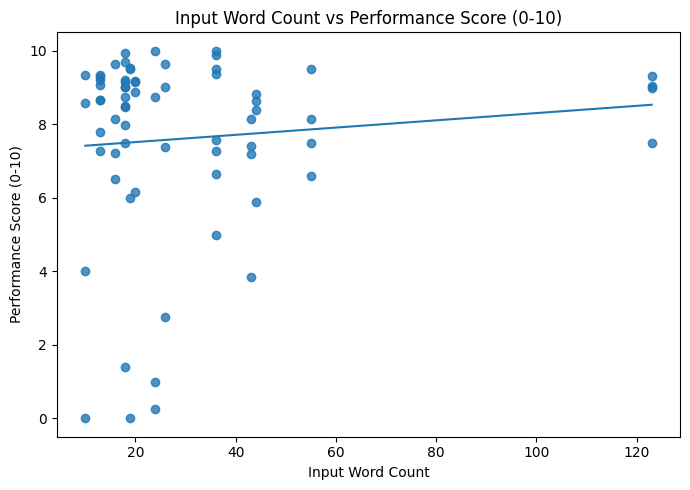

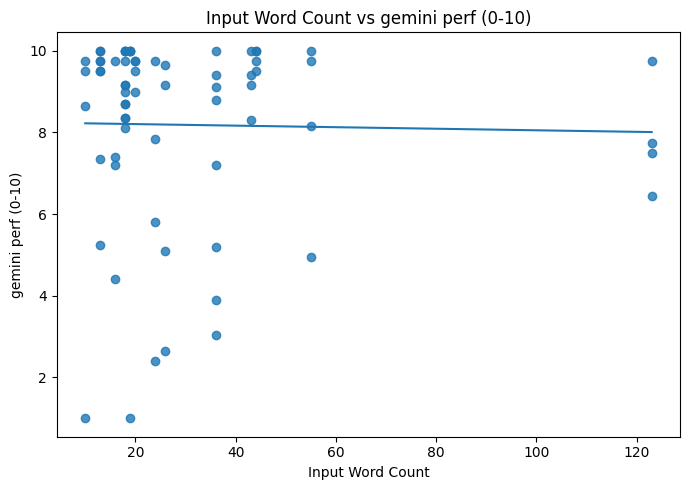

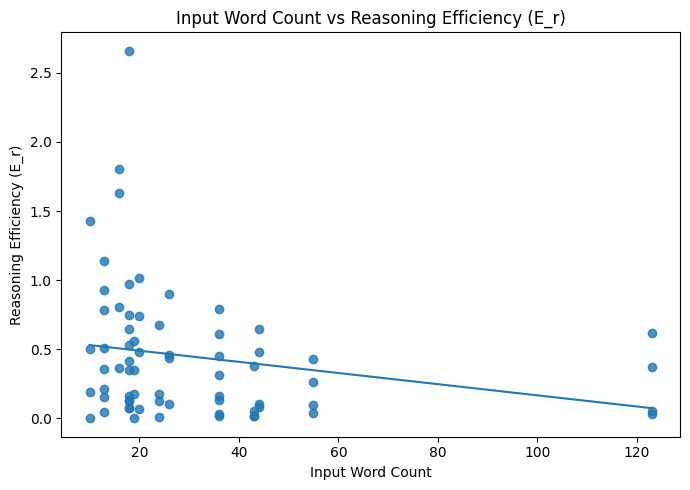

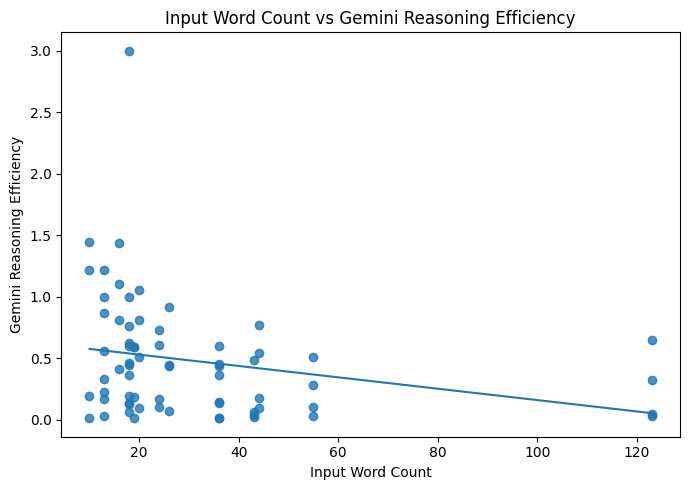

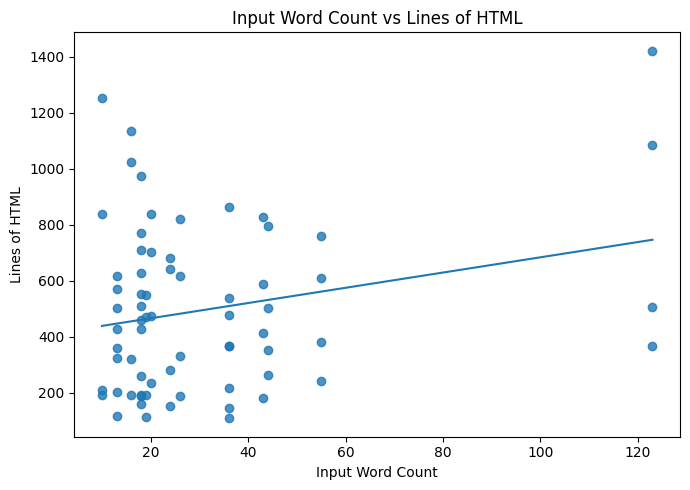

Outcome summary by prompt-length quartile:


Performance Score (0-10)                       \
                                          count   mean median    std   
Prompt Length Quartile                                                 
Q1 Shortest                                  28  7.904  8.650  2.365   
Q2                                            8  7.298  9.015  3.285   
Q3                                           16  7.127  8.165  3.227   
Q4 Longest                                   16  7.803  8.130  1.457   

                       gemini perf (0-10)                       \
                                    count   mean median    std   
Prompt Length Quartile                                           
Q1 Shortest                            28  8.500  9.150  2.030   
Q2                                      8  8.625  9.750  3.100   
Q3                                     16  6.812  7.525  2.774   
Q4 Longest                             16  8.775  9.450  1.489   

                       Reasoning Efficiency (E_r)                       \
                                            count   mean median    std   
Prompt Length Quartile                                                   
Q1 Shortest                                    28  0.634  0.459  0.628   
Q2                                              8  0.424  0.417  0.349   
Q3                                             16  0.337  0.246  0.289   
Q4 Longest                                     16  0.230  0.098  0.225   

                       Gemini Reasoning Efficiency                       \
                                             count   mean median    std   
Prompt Length Quartile                                                    
Q1 Shortest                                     28  0.671  0.511  0.632   
Q2                                               8  0.481  0.551  0.363   
Q3                                              16  0.352  0.400  0.272   
Q4 Longest                                      16  0.259  0.137  0.254   

                       Lines of HTML                           
                               count     mean median      std  
Prompt Length Quartile                                         
Q1 Shortest                       28  503.857  443.0  317.018  
Q2                                 8  446.375  472.5  253.910  
Q3                                16  424.562  366.5  245.166  
Q4 Longest                        16  580.188  504.0  332.459

Mean outcomes by prompt-length quartile:


,Performance Score (0-10),gemini perf (0-10),Reasoning Efficiency (E_r),Gemini Reasoning Efficiency,Lines of HTML
Prompt Length Quartile,,,,,
Q1 Shortest,7.904,8.500,0.634,0.671,503.857
Q2,7.298,8.625,0.424,0.481,446.375
Q3,7.127,6.812,0.337,0.352,424.562
Q4 Longest,7.803,8.775,0.230,0.259,580.188



Quick interpretation helper:
- Performance Score (0-10): negative relationship, Spearman rho = -0.054, p = 0.6623; Pearson r = 0.103, p = 0.4024
- gemini perf (0-10): negative relationship, Spearman rho = -0.046, p = 0.7066; Pearson r = -0.021, p = 0.8632
- Reasoning Efficiency (E_r): negative relationship, Spearman rho = -0.305, p = 0.0115; Pearson r = -0.221, p = 0.0700
- Gemini Reasoning Efficiency: negative relationship, Spearman rho = -0.340, p = 0.0045; Pearson r = -0.250, p = 0.0399
- Lines of HTML: positive relationship, Spearman rho = 0.074, p = 0.5462; Pearson r = 0.240, p = 0.0483


In [ ]:
from scipy.stats import pearsonr, spearmanr

# -----------------------------------
# 1) Setup
# -----------------------------------
prompt_df = efficiency_df.copy()

x_col = "Input Word Count"
y_cols = [
    "Performance Score (0-10)",
    "gemini perf (0-10)",
    "Reasoning Efficiency (E_r)",
    "Gemini Reasoning Efficiency",
    "Lines of HTML"
]

subset = prompt_df[[x_col] + y_cols].dropna().copy()

print("Rows used:", len(subset))
display(subset[[x_col] + y_cols].describe().round(3))

# -----------------------------------
# 2) Correlation table
# -----------------------------------
results = []

for y_col in y_cols:
    x = subset[x_col]
    y = subset[y_col]

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    results.append({
        "Outcome": y_col,
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_rho": spearman_rho,
        "Spearman_p": spearman_p
    })

corr_df = pd.DataFrame(results).round(4)

print("Correlation results:")
display(corr_df.sort_values("Spearman_rho", ascending=False))

# -----------------------------------
# 3) Scatter plots with trend lines
# -----------------------------------
for y_col in y_cols:
    plt.figure(figsize=(7, 5))
    plt.scatter(subset[x_col], subset[y_col], alpha=0.8)

    z = np.polyfit(subset[x_col], subset[y_col], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(subset[x_col])
    plt.plot(x_sorted, p(x_sorted))

    plt.title(f"{x_col} vs {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()

# -----------------------------------
# 4) Prompt-length quartiles
# -----------------------------------
subset["Prompt Length Quartile"] = pd.qcut(
    subset[x_col],
    q=4,
    labels=["Q1 Shortest", "Q2", "Q3", "Q4 Longest"]
)

quartile_summary = (
    subset.groupby("Prompt Length Quartile", observed=False)[y_cols]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)

print("Outcome summary by prompt-length quartile:")
display(quartile_summary)

# -----------------------------------
# 5) Mean table only, easier to read
# -----------------------------------
quartile_means = (
    subset.groupby("Prompt Length Quartile", observed=False)[y_cols]
    .mean()
    .round(3)
)

print("Mean outcomes by prompt-length quartile:")
display(quartile_means)

# -----------------------------------
# 6) Interpretation helper
# -----------------------------------
print("\nQuick interpretation helper:")
for _, row in corr_df.iterrows():
    direction = (
        "positive" if row["Spearman_rho"] > 0
        else "negative" if row["Spearman_rho"] < 0
        else "no"
    )
    print(
        f"- {row['Outcome']}: {direction} relationship, "
        f"Spearman rho = {row['Spearman_rho']:.3f}, p = {row['Spearman_p']:.4f}; "
        f"Pearson r = {row['Pearson_r']:.3f}, p = {row['Pearson_p']:.4f}"
    )

#### Relation between lines of HTML and Reasoning efficiency

Rows used: 68


,Lines of HTML,Reasoning Efficiency (E_r),Gemini Reasoning Efficiency
count,68.000,68.000,68.000
mean,496.397,0.444,0.477
std,297.773,0.480,0.486
min,108.000,0.000,0.011
25%,239.250,0.099,0.121
50%,465.000,0.354,0.422
75%,650.500,0.626,0.631
max,1422.000,2.660,3.000


Correlation results:


,Outcome,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,Reasoning Efficiency (E_r),-0.1453,0.2371,-0.0050,0.9676
1,Gemini Reasoning Efficiency,-0.0742,0.5473,0.0222,0.8573


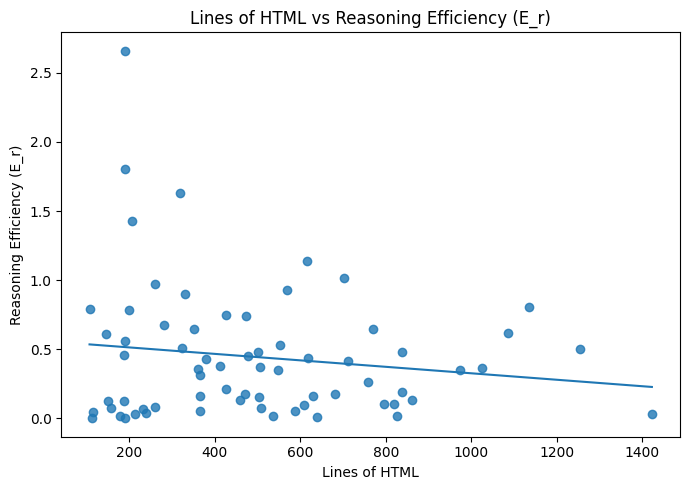

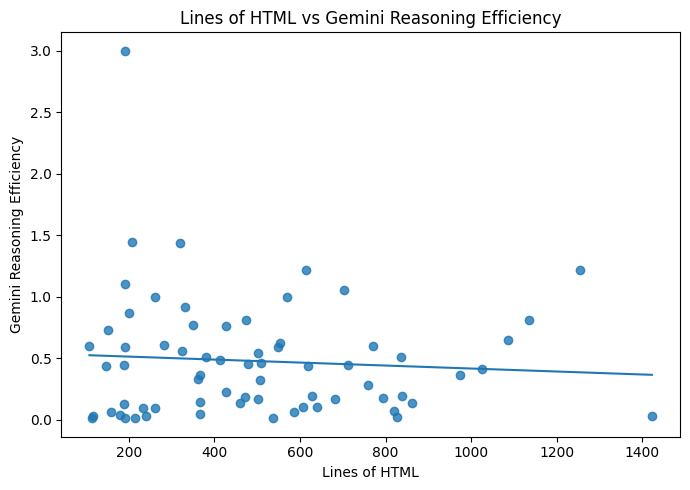

Reasoning efficiency by HTML quartile:


Reasoning Efficiency (E_r)                       \
                                   count   mean median    std   
HTML Quartile                                                   
Q1 Lowest                             17  0.563  0.125  0.757   
Q2                                    17  0.484  0.379  0.416   
Q3                                    17  0.363  0.353  0.328   
Q4 Highest                            17  0.365  0.350  0.285   

              Gemini Reasoning Efficiency                       
                                    count   mean median    std  
HTML Quartile                                                   
Q1 Lowest                              17  0.564  0.433  0.761  
Q2                                     17  0.495  0.482  0.391  
Q3                                     17  0.428  0.439  0.344  
Q4 Highest                             17  0.420  0.366  0.354


Quick interpretation helper:
- Reasoning Efficiency (E_r): negative relationship, Spearman rho = -0.005, p = 0.9676; Pearson r = -0.145, p = 0.2371
- Gemini Reasoning Efficiency: positive relationship, Spearman rho = 0.022, p = 0.8573; Pearson r = -0.074, p = 0.5473


In [ ]:
# -----------------------------------
# Lines of HTML vs Reasoning Efficiency
# -----------------------------------
html_eff_df = efficiency_df.copy()

x_col = "Lines of HTML"
y_cols = ["Reasoning Efficiency (E_r)", "Gemini Reasoning Efficiency"]

subset = html_eff_df[[x_col] + y_cols].dropna().copy()

print("Rows used:", len(subset))
display(subset[[x_col] + y_cols].describe().round(3))

# -----------------------------------
# Correlation table
# -----------------------------------
results = []

for y_col in y_cols:
    x = subset[x_col]
    y = subset[y_col]

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    results.append({
        "Outcome": y_col,
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_rho": spearman_rho,
        "Spearman_p": spearman_p
    })

corr_df = pd.DataFrame(results).round(4)

print("Correlation results:")
display(corr_df)

# -----------------------------------
# Scatter plots
# -----------------------------------
for y_col in y_cols:
    plt.figure(figsize=(7, 5))
    plt.scatter(subset[x_col], subset[y_col], alpha=0.8)

    z = np.polyfit(subset[x_col], subset[y_col], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(subset[x_col])
    plt.plot(x_sorted, p(x_sorted))

    plt.title(f"{x_col} vs {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()

# -----------------------------------
# HTML quartiles
# -----------------------------------
subset["HTML Quartile"] = pd.qcut(
    subset[x_col],
    q=4,
    labels=["Q1 Lowest", "Q2", "Q3", "Q4 Highest"]
)

quartile_summary = (
    subset.groupby("HTML Quartile", observed=False)[y_cols]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)

print("Reasoning efficiency by HTML quartile:")
display(quartile_summary)

# -----------------------------------
# Quick interpretation helper
# -----------------------------------
print("\nQuick interpretation helper:")
for _, row in corr_df.iterrows():
    direction = (
        "positive" if row["Spearman_rho"] > 0
        else "negative" if row["Spearman_rho"] < 0
        else "no"
    )
    print(
        f"- {row['Outcome']}: {direction} relationship, "
        f"Spearman rho = {row['Spearman_rho']:.3f}, p = {row['Spearman_p']:.4f}; "
        f"Pearson r = {row['Pearson_r']:.3f}, p = {row['Pearson_p']:.4f}"
    )

#### Experiment Similarity in HTML Verbosity Patterns

Each experiment was represented as a four-value vector of HTML line counts, one value per model family, and cosine similarity was used to compare whether experiments shared similar cross-model verbosity patterns independent of overall output size.

Experiment x Model Family HTML matrix:


Model Family,GPT,Gemini,Grok,Claude
Experiment ID,,,,
airplane_0117,838.0,208.0,190.0,1254.0
backflip_1014,827.0,414.0,179.0,587.0
basketball_0131,537.0,367.0,215.0,862.0
blooming_flower_1217,554.0,261.0,192.0,459.0
dna_0124,549.0,191.0,113.0,471.0
dog_fetch_0103,570.0,361.0,116.0,615.0
drifting_car_1213,640.0,282.0,151.0,682.0
dvd_logo_1220,366.0,146.0,108.0,479.0
flappy_bird_1210,427.0,324.0,201.0,503.0


Normalized HTML pattern matrix (share of HTML lines by model family):


Model Family,GPT,Gemini,Grok,Claude
Experiment ID,,,,
airplane_0117,0.337,0.084,0.076,0.504
backflip_1014,0.412,0.206,0.089,0.292
basketball_0131,0.271,0.185,0.109,0.435
blooming_flower_1217,0.378,0.178,0.131,0.313
dna_0124,0.415,0.144,0.085,0.356
dog_fetch_0103,0.343,0.217,0.070,0.370
drifting_car_1213,0.365,0.161,0.086,0.389
dvd_logo_1220,0.333,0.133,0.098,0.436
flappy_bird_1210,0.293,0.223,0.138,0.346


Cosine similarity between experiments (raw HTML vectors):


...

Experiment ID,airplane_0117,backflip_1014,basketball_0131,blooming_flower_1217,dna_0124,dog_fetch_0103,drifting_car_1213,dvd_logo_1220,flappy_bird_1210,gravity_cloth_0107,new_years_1231,paper_airplane_0204,pirate_ship_0110,snake_0121,spaceship_1227,spongebob_0128,super_mario_1224
Experiment ID,,,,,,,,,,,,,,,,,
airplane_0117,0.000,0.090,0.024,0.066,0.042,0.047,0.025,0.008,0.064,0.032,0.073,0.090,0.063,0.062,0.018,0.074,0.012
backflip_1014,0.090,0.000,0.067,0.007,0.012,0.018,0.022,0.050,0.032,0.067,0.004,0.010,0.003,0.007,0.043,0.003,0.038
basketball_0131,0.024,0.067,0.000,0.044,0.045,0.019,0.019,0.010,0.017,0.002,0.048,0.045,0.052,0.059,0.004,0.043,0.027
blooming_flower_1217,0.066,0.007,0.044,0.000,0.009,0.016,0.012,0.031,0.018,0.041,0.001,0.015,0.006,0.005,0.026,0.003,0.027
dna_0124,0.042,0.012,0.045,0.009,0.000,0.017,0.006,0.020,0.036,0.049,0.010,0.027,0.003,0.003,0.023,0.012,0.009
dog_fetch_0103,0.047,0.018,0.019,0.016,0.017,0.000,0.007,0.019,0.012,0.023,0.015,0.008,0.013,0.023,0.010,0.009,0.020
drifting_car_1213,0.025,0.022,0.019,0.012,0.006,0.007,0.000,0.006,0.020,0.023,0.014,0.023,0.010,0.013,0.006,0.013,0.004
dvd_logo_1220,0.008,0.050,0.010,0.031,0.020,0.019,0.006,0.000,0.028,0.014,0.036,0.047,0.032,0.033,0.003,0.035,0.005
flappy_bird_1210,0.064,0.032,0.017,0.018,0.036,0.012,0.020,0.028,0.000,0.012,0.018,0.016,0.031,0.037,0.016,0.015,0.041


Top 5 most similar experiment pairs by normalized pattern:


,Experiment 1,Experiment 2,Cosine Similarity (raw),Cosine Distance (raw),Cosine Similarity (pattern),Cosine Distance (pattern)
51,blooming_flower_1217,new_years_1231,0.9994,0.0006,0.9994,0.0006
119,new_years_1231,spongebob_0128,0.9986,0.0014,0.9986,0.0014
37,basketball_0131,gravity_cloth_0107,0.9982,0.0018,0.9982,0.0018
66,dna_0124,snake_0121,0.9974,0.0026,0.9974,0.0026
97,dvd_logo_1220,spaceship_1227,0.9972,0.0028,0.9972,0.0028


Top 5 most different experiment pairs by normalized pattern:


,Experiment 1,Experiment 2,Cosine Similarity (raw),Cosine Distance (raw),Cosine Similarity (pattern),Cosine Distance (pattern)
0,airplane_0117,backflip_1014,0.9097,0.0903,0.9097,0.0903
10,airplane_0117,paper_airplane_0204,0.9103,0.0897,0.9103,0.0897
14,airplane_0117,spongebob_0128,0.9263,0.0737,0.9263,0.0737
9,airplane_0117,new_years_1231,0.9266,0.0734,0.9266,0.0734
23,backflip_1014,gravity_cloth_0107,0.9329,0.0671,0.9329,0.0671


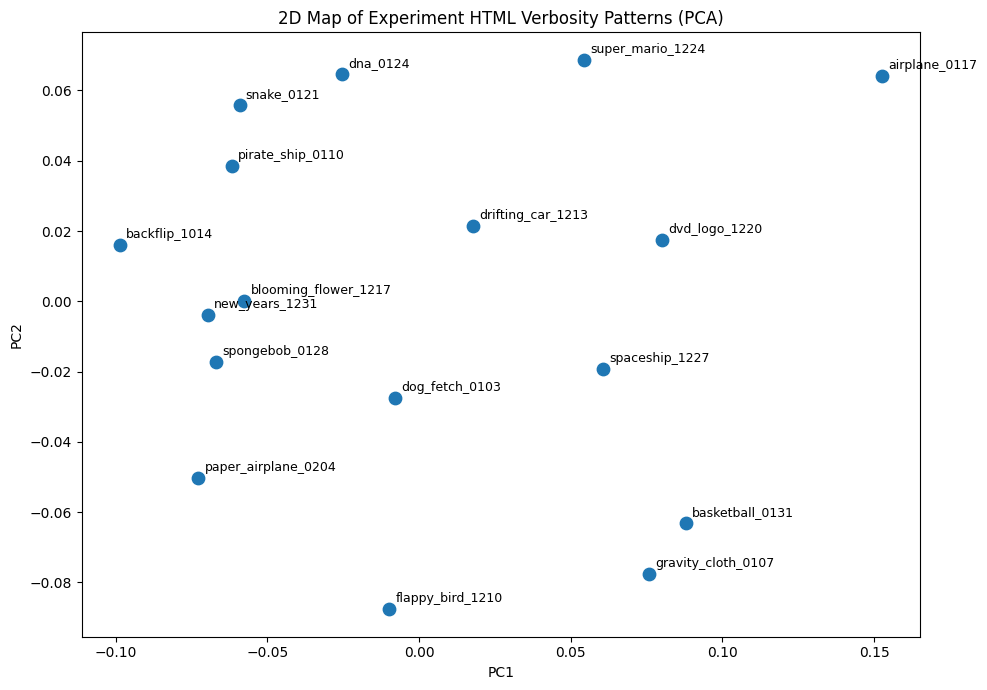

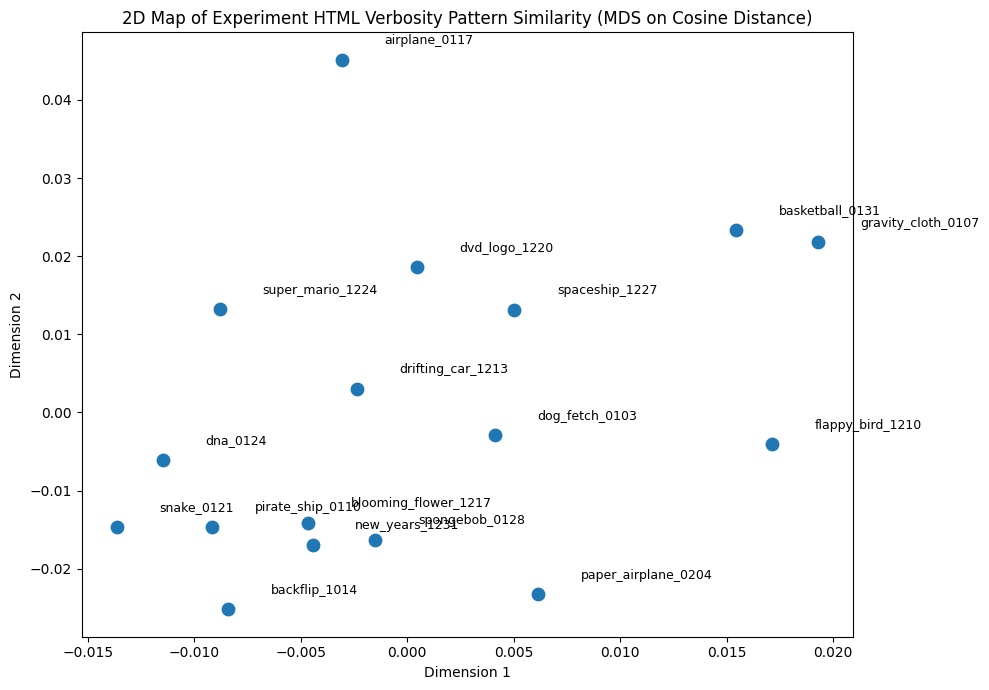


Quick interpretation helper:
- Experiments that appear closer together have more similar cross-model HTML verbosity patterns.
- The normalized pattern view focuses on shape, not overall HTML size.
- Cosine similarity near 1 means very similar model-family verbosity structure.


In [ ]:
import warnings
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from sklearn.decomposition import PCA
from sklearn.manifold import MDS

warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn.manifold._mds')

# -------------------------------------------------
# Experiment-level HTML verbosity pattern analysis
# Each experiment = 4-value vector of Lines of HTML
# ordered by model family: GPT, Gemini, Grok, Claude
# -------------------------------------------------

analysis_df = df.copy()

family_order = ["GPT", "Gemini", "Grok", "Claude"]

# 1) Build experiment x model-family matrix
exp_html = (
    analysis_df.pivot_table(
        index="Experiment ID",
        columns="Model Family",
        values="Lines of HTML",
        aggfunc="mean"
    )
    .reindex(columns=family_order)
)

print("Experiment x Model Family HTML matrix:")
display(exp_html.round(2))

# 2) Optional normalized pattern matrix
# This keeps the within-experiment shape but removes overall scale
exp_html_pattern = exp_html.div(exp_html.sum(axis=1), axis=0)

print("Normalized HTML pattern matrix (share of HTML lines by model family):")
display(exp_html_pattern.round(3))

# 3) Cosine similarity and distance on raw vectors
cos_sim_raw = pd.DataFrame(
    cosine_similarity(exp_html),
    index=exp_html.index,
    columns=exp_html.index
)

cos_dist_raw = pd.DataFrame(
    cosine_distances(exp_html),
    index=exp_html.index,
    columns=exp_html.index
)

print("Cosine similarity between experiments (raw HTML vectors):")
display(cos_sim_raw.round(3))

print("Cosine distance between experiments (raw HTML vectors):")
display(cos_dist_raw.round(3))

# 4) Cosine similarity and distance on normalized pattern vectors
cos_sim_pattern = pd.DataFrame(
    cosine_similarity(exp_html_pattern),
    index=exp_html_pattern.index,
    columns=exp_html_pattern.index
)

cos_dist_pattern = pd.DataFrame(
    cosine_distances(exp_html_pattern),
    index=exp_html_pattern.index,
    columns=exp_html_pattern.index
)

print("Cosine similarity between experiments (normalized patterns):")
display(cos_sim_pattern.round(3))

print("Cosine distance between experiments (normalized patterns):")
display(cos_dist_pattern.round(3))

# 5) Find most similar and most different experiment pairs
pairs = []
exp_ids = exp_html.index.tolist()

for i in range(len(exp_ids)):
    for j in range(i + 1, len(exp_ids)):
        e1, e2 = exp_ids[i], exp_ids[j]
        pairs.append({
            "Experiment 1": e1,
            "Experiment 2": e2,
            "Cosine Similarity (raw)": cos_sim_raw.loc[e1, e2],
            "Cosine Distance (raw)": cos_dist_raw.loc[e1, e2],
            "Cosine Similarity (pattern)": cos_sim_pattern.loc[e1, e2],
            "Cosine Distance (pattern)": cos_dist_pattern.loc[e1, e2]
        })

pairs_df = pd.DataFrame(pairs)

print("Top 5 most similar experiment pairs by normalized pattern:")
display(
    pairs_df.sort_values("Cosine Similarity (pattern)", ascending=False)
    .head(5)
    .round(4)
)

print("Top 5 most different experiment pairs by normalized pattern:")
display(
    pairs_df.sort_values("Cosine Distance (pattern)", ascending=False)
    .head(5)
    .round(4)
)

# 6) 2D projection for plotting
# PCA on normalized pattern vectors
pca = PCA(n_components=2)
coords_pca = pca.fit_transform(exp_html_pattern)

plot_df = pd.DataFrame(
    coords_pca,
    index=exp_html_pattern.index,
    columns=["PC1", "PC2"]
).reset_index()

# Alternative: MDS on cosine distance matrix
mds_kwargs = {
    "n_components": 2,
    "dissimilarity": "precomputed",
    "random_state": 42
}

try:
    mds = MDS(n_init=4, **mds_kwargs)
except TypeError:
    # Older sklearn builds may reject newer constructor keywords.
    mds = MDS(**mds_kwargs)

coords_mds = mds.fit_transform(cos_dist_pattern)

plot_df_mds = pd.DataFrame(
    coords_mds,
    index=exp_html_pattern.index,
    columns=["Dim 1", "Dim 2"]
).reset_index()

# 7) Plot PCA map
plt.figure(figsize=(10, 7))
plt.scatter(plot_df["PC1"], plot_df["PC2"], s=80)

for _, row in plot_df.iterrows():
    plt.text(row["PC1"] + 0.002, row["PC2"] + 0.002, row["Experiment ID"], fontsize=9)

plt.title("2D Map of Experiment HTML Verbosity Patterns (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# 8) Plot MDS map using cosine distances
plt.figure(figsize=(10, 7))
plt.scatter(plot_df_mds["Dim 1"], plot_df_mds["Dim 2"], s=80)

for _, row in plot_df_mds.iterrows():
    plt.text(row["Dim 1"] + 0.002, row["Dim 2"] + 0.002, row["Experiment ID"], fontsize=9)

plt.title("2D Map of Experiment HTML Verbosity Pattern Similarity (MDS on Cosine Distance)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.tight_layout()
plt.show()

# 9) Quick interpretation helper
print("\nQuick interpretation helper:")
print("- Experiments that appear closer together have more similar cross-model HTML verbosity patterns.")
print("- The normalized pattern view focuses on shape, not overall HTML size.")
print("- Cosine similarity near 1 means very similar model-family verbosity structure.")

#### For the exact same prompt, how far apart were the shortest and longest implementations?

Per-experiment HTML spread:


,Experiment ID,shortest_family,shortest_model,min_html,longest_family,longest_model,max_html,range_html,max_to_min_ratio,mean_html,median_html,std_html
0,airplane_0117,Grok,grok-4.1-thinking,190,Claude,opus-4.5-thinking-32k,1254,1064,6.60,622.50,523.0,517.72
1,snake_0121,Grok,grok-4.1-thinking,366,GPT,gpt-5.2-extended-thinking,1422,1056,3.89,844.75,795.5,494.94
2,super_mario_1224,Grok,grok-4.1-thinking,191,Claude,opus-4.5-thinking-32k,1134,943,5.94,667.00,671.5,480.70
3,pirate_ship_0110,Grok,grok-4.1-thinking,189,GPT,gpt-5.2-extended-thinking,974,785,5.15,590.00,598.5,349.87
4,backflip_1014,Grok,grok-4.1-thinking,179,GPT,gpt-5.2-extended-thinking,827,648,4.62,501.75,500.5,273.81
5,basketball_0131,Grok,grok-4.1-thinking,215,Claude,opus-4.5-thinking-32k,862,647,4.01,495.25,452.0,277.63
6,spaceship_1227,Grok,grok-4.1-thinking,188,Claude,opus-4.5-thinking-32k,820,632,4.36,489.50,475.0,283.70
7,spongebob_0128,Grok,grok-4.1-thinking,234,GPT,gpt-5.2-extended-thinking,837,603,3.58,561.75,588.0,264.92
8,paper_airplane_0204,Grok,grok-4.1-thinking,158,GPT,gpt-5.2-extended-thinking,711,553,4.50,501.75,569.0,243.72
9,gravity_cloth_0107,Grok,grok-4.1-thinking,262,Claude,opus-4.5-thinking-32k,795,533,3.03,477.50,426.5,233.70


Summary of within-experiment HTML spread:


,min_html,max_html,range_html,max_to_min_ratio,std_html
count,17.00,17.00,17.00,17.00,17.00
mean,193.76,810.35,616.59,4.31,284.17
std,62.25,263.63,227.67,1.09,113.62
min,108.00,479.00,302.00,2.50,130.97
25%,158.00,615.00,499.00,3.58,228.28
50%,190.00,795.00,553.00,4.44,262.71
75%,215.00,862.00,648.00,4.86,283.70
max,366.00,1422.00,1064.00,6.60,517.72


Top 5 widest spreads:


,Experiment ID,shortest_family,shortest_model,min_html,longest_family,longest_model,max_html,range_html,max_to_min_ratio,mean_html,median_html,std_html
0,airplane_0117,Grok,grok-4.1-thinking,190,Claude,opus-4.5-thinking-32k,1254,1064,6.60,622.50,523.0,517.72
1,snake_0121,Grok,grok-4.1-thinking,366,GPT,gpt-5.2-extended-thinking,1422,1056,3.89,844.75,795.5,494.94
2,super_mario_1224,Grok,grok-4.1-thinking,191,Claude,opus-4.5-thinking-32k,1134,943,5.94,667.00,671.5,480.70
3,pirate_ship_0110,Grok,grok-4.1-thinking,189,GPT,gpt-5.2-extended-thinking,974,785,5.15,590.00,598.5,349.87
4,backflip_1014,Grok,grok-4.1-thinking,179,GPT,gpt-5.2-extended-thinking,827,648,4.62,501.75,500.5,273.81


Top 5 narrowest spreads:


,Experiment ID,shortest_family,shortest_model,min_html,longest_family,longest_model,max_html,range_html,max_to_min_ratio,mean_html,median_html,std_html
16,flappy_bird_1210,Grok,grok-4.1-thinking,201,Claude,opus-4.5-thinking-32k,503,302,2.50,363.75,375.5,130.97
15,blooming_flower_1217,Grok,grok-4.1-thinking,192,GPT,gpt-5.2-extended-thinking,554,362,2.89,366.50,360.0,168.61
14,dvd_logo_1220,Grok,grok-4.1-thinking,108,Claude,opus-4.5-thinking-32k,479,371,4.44,274.75,256.0,177.41
13,dna_0124,Grok,grok-4.1-thinking,113,GPT,gpt-5.2-extended-thinking,549,436,4.86,331.00,331.0,211.54
12,dog_fetch_0103,Grok,grok-4.1-thinking,116,Claude,opus-4.5-thinking-32k,615,499,5.30,415.50,465.5,228.28


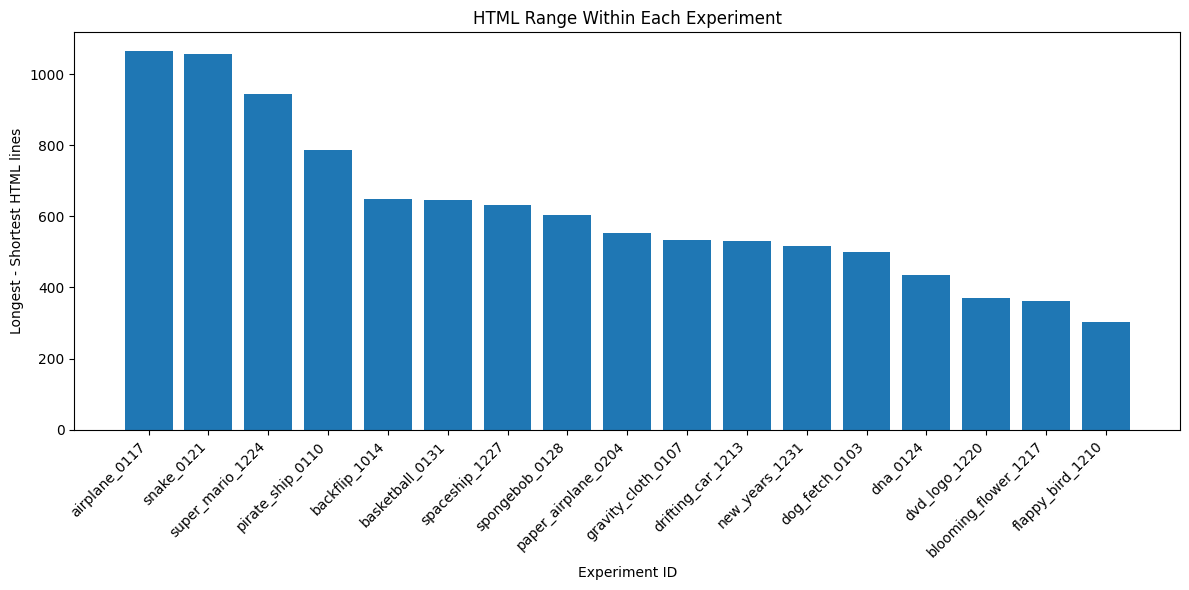

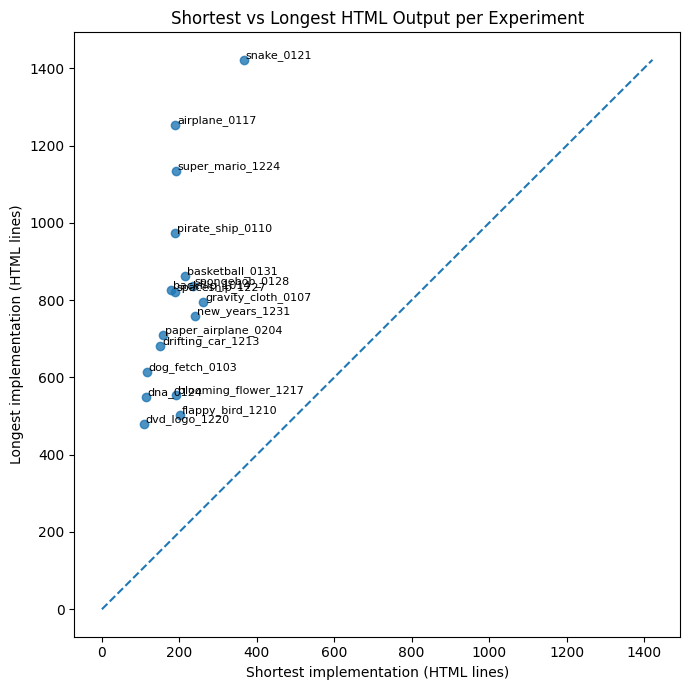

In [ ]:
# -----------------------------------
# Shortest vs longest HTML output
# within the same experiment
# -----------------------------------
spread_df = df.copy()

exp_spread = (
    spread_df.groupby("Experiment ID")
    .agg(
        min_html=("Lines of HTML", "min"),
        max_html=("Lines of HTML", "max"),
        mean_html=("Lines of HTML", "mean"),
        median_html=("Lines of HTML", "median"),
        std_html=("Lines of HTML", "std"),
        range_html=("Lines of HTML", lambda x: x.max() - x.min())
    )
    .sort_values("range_html", ascending=False)
    .round(2)
)

# Add which model was shortest / longest
idx_min = spread_df.groupby("Experiment ID")["Lines of HTML"].idxmin()
idx_max = spread_df.groupby("Experiment ID")["Lines of HTML"].idxmax()

min_models = (
    spread_df.loc[idx_min, ["Experiment ID", "LLM Model", "Model Family", "Lines of HTML"]]
    .rename(columns={
        "LLM Model": "shortest_model",
        "Model Family": "shortest_family",
        "Lines of HTML": "min_html_check"
    })
)

max_models = (
    spread_df.loc[idx_max, ["Experiment ID", "LLM Model", "Model Family", "Lines of HTML"]]
    .rename(columns={
        "LLM Model": "longest_model",
        "Model Family": "longest_family",
        "Lines of HTML": "max_html_check"
    })
)

exp_spread = (
    exp_spread
    .merge(min_models, on="Experiment ID", how="left")
    .merge(max_models, on="Experiment ID", how="left")
)

# Ratio: longest / shortest
exp_spread["max_to_min_ratio"] = np.where(
    exp_spread["min_html"] > 0,
    exp_spread["max_html"] / exp_spread["min_html"],
    np.nan
)

# Reorder columns
exp_spread = exp_spread[
    [
        "Experiment ID",
        "shortest_family",
        "shortest_model",
        "min_html",
        "longest_family",
        "longest_model",
        "max_html",
        "range_html",
        "max_to_min_ratio",
        "mean_html",
        "median_html",
        "std_html"
    ]
].round(2)

print("Per-experiment HTML spread:")
display(exp_spread)

print("Summary of within-experiment HTML spread:")
display(exp_spread[["min_html", "max_html", "range_html", "max_to_min_ratio", "std_html"]].describe().round(2))

print("Top 5 widest spreads:")
display(exp_spread.sort_values("range_html", ascending=False).head(5))

print("Top 5 narrowest spreads:")
display(exp_spread.sort_values("range_html", ascending=True).head(5))

# -----------------------------------
# Plot 1: range by experiment
# -----------------------------------
plt.figure(figsize=(12, 6))
plt.bar(exp_spread["Experiment ID"], exp_spread["range_html"])
plt.title("HTML Range Within Each Experiment")
plt.xlabel("Experiment ID")
plt.ylabel("Longest - Shortest HTML lines")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# -----------------------------------
# Plot 2: shortest vs longest
# -----------------------------------
plt.figure(figsize=(7, 7))
plt.scatter(exp_spread["min_html"], exp_spread["max_html"], alpha=0.8)

for _, row in exp_spread.iterrows():
    plt.text(row["min_html"] + 5, row["max_html"] + 5, row["Experiment ID"], fontsize=8)

max_val = exp_spread["max_html"].max()
plt.plot([0, max_val], [0, max_val], linestyle="--")
plt.title("Shortest vs Longest HTML Output per Experiment")
plt.xlabel("Shortest implementation (HTML lines)")
plt.ylabel("Longest implementation (HTML lines)")
plt.tight_layout()
plt.show()

#### What is the minimum amount of HTML lines that appears to guarantee, or at least strongly support, a good performance score?

Using good performance threshold: 8.0
Rows used: 68

Absolute minimum HTML lines among good outputs:
- Minimum HTML lines: 108
- Corresponding performance score: 9.50

Performance by HTML bucket:


,count,mean_score,median_score,good_rate,min_score,max_score,good_rate_pct
HTML Bucket,,,,,,,
<=200,13,5.692,7.280,0.308,0.00,9.50,30.8
201-300,8,7.989,8.615,0.625,6.15,9.70,62.5
301-400,9,8.528,8.400,0.778,7.58,10.00,77.8
401-500,7,9.089,9.200,0.857,7.20,9.93,85.7
501-600,9,7.083,8.130,0.556,1.40,9.33,55.6
601-800,11,7.883,9.080,0.636,0.25,10.00,63.6
801-1000,6,8.565,8.950,0.667,7.38,9.38,66.7
1000+,5,7.686,8.980,0.600,4.00,9.65,60.0



Threshold table:


,html_threshold,n_outputs_at_or_above,good_rate_at_or_above,mean_score_at_or_above,good_rate_pct
0,108,68,0.603,7.626,60.3
1,113,67,0.597,7.598,59.7
2,116,66,0.606,7.713,60.6
3,146,65,0.615,7.720,61.5
4,151,64,0.625,7.727,62.5
5,158,63,0.635,7.833,63.5
6,179,62,0.629,7.812,62.9
7,188,61,0.639,7.877,63.9
8,189,60,0.650,7.962,65.0
9,190,59,0.644,7.954,64.4



Practical threshold summary:


,target_good_rate,min_html_threshold,n_outputs_at_or_above,actual_good_rate_pct,mean_score_at_or_above
0,70%,261,50,70.0,8.159
1,80%,1422,1,100.0,8.980
2,90%,1422,1,100.0,8.980


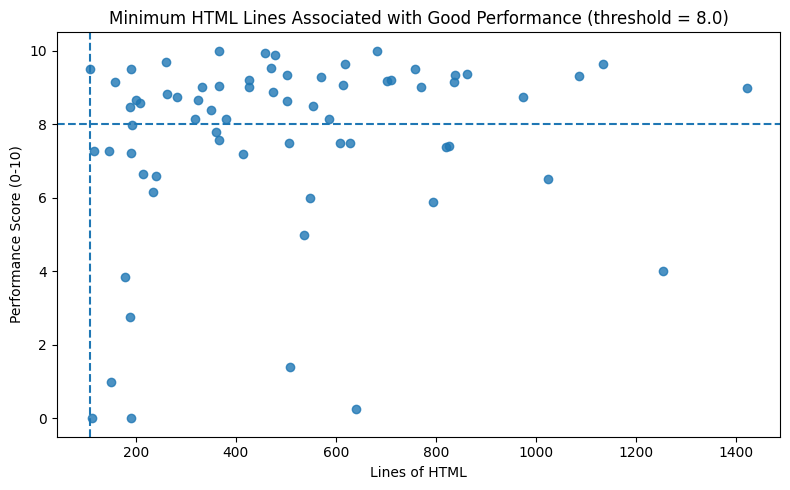

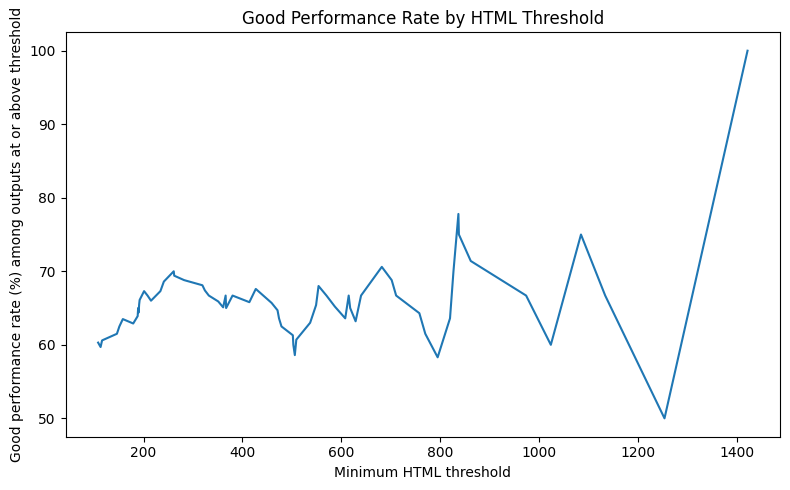

In [ ]:
# -----------------------------------
# Minimum HTML lines for a "good" score
# -----------------------------------
analysis_df = df.copy()

score_col = "Performance Score (0-10)"
html_col = "Lines of HTML"
good_threshold = 8.0   # change if you want, for example 7.5, 8.5, or 9.0

subset = analysis_df[[html_col, score_col]].dropna().copy()
subset["good_performance"] = subset[score_col] >= good_threshold

print(f"Using good performance threshold: {good_threshold}")
print("Rows used:", len(subset))

# -----------------------------------
# 1) Absolute minimum HTML among good outputs
# -----------------------------------
good_only = subset[subset["good_performance"]].copy()

min_good_html = good_only[html_col].min()
row_min_good = good_only.loc[good_only[html_col].idxmin()]

print("\nAbsolute minimum HTML lines among good outputs:")
print(f"- Minimum HTML lines: {min_good_html}")
print(f"- Corresponding performance score: {row_min_good[score_col]:.2f}")

# -----------------------------------
# 2) Bucket analysis
# Helps answer "from what HTML range onward
# do good scores become common?"
# -----------------------------------
bins = [0, 200, 300, 400, 500, 600, 800, 1000, np.inf]
labels = ["<=200", "201-300", "301-400", "401-500", "501-600", "601-800", "801-1000", "1000+"]

subset["HTML Bucket"] = pd.cut(subset[html_col], bins=bins, labels=labels, include_lowest=True)

bucket_summary = (
    subset.groupby("HTML Bucket", observed=False)
    .agg(
        count=(score_col, "count"),
        mean_score=(score_col, "mean"),
        median_score=(score_col, "median"),
        good_rate=("good_performance", "mean"),
        min_score=(score_col, "min"),
        max_score=(score_col, "max")
    )
    .round(3)
)

bucket_summary["good_rate_pct"] = (bucket_summary["good_rate"] * 100).round(1)

print("\nPerformance by HTML bucket:")
display(bucket_summary)

# -----------------------------------
# 3) Running success rate
# For each HTML threshold, what % of outputs
# at or above that threshold are good?
# -----------------------------------
thresholds = sorted(subset[html_col].unique())
threshold_results = []

for t in thresholds:
    temp = subset[subset[html_col] >= t]
    threshold_results.append({
        "html_threshold": t,
        "n_outputs_at_or_above": len(temp),
        "good_rate_at_or_above": temp["good_performance"].mean(),
        "mean_score_at_or_above": temp[score_col].mean()
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df["good_rate_pct"] = (threshold_df["good_rate_at_or_above"] * 100).round(1)

print("\nThreshold table:")
display(threshold_df.head(15).round(3))

# -----------------------------------
# 4) Practical thresholds
# Find smallest HTML threshold where good rate
# reaches 70%, 80%, 90%
# -----------------------------------
targets = [0.70, 0.80, 0.90]
practical_rows = []

for target in targets:
    eligible = threshold_df[threshold_df["good_rate_at_or_above"] >= target]
    if len(eligible) > 0:
        first_hit = eligible.iloc[0]
        practical_rows.append({
            "target_good_rate": f"{int(target*100)}%",
            "min_html_threshold": int(first_hit["html_threshold"]),
            "n_outputs_at_or_above": int(first_hit["n_outputs_at_or_above"]),
            "actual_good_rate_pct": round(first_hit["good_rate_pct"], 1),
            "mean_score_at_or_above": round(first_hit["mean_score_at_or_above"], 3)
        })
    else:
        practical_rows.append({
            "target_good_rate": f"{int(target*100)}%",
            "min_html_threshold": np.nan,
            "n_outputs_at_or_above": np.nan,
            "actual_good_rate_pct": np.nan,
            "mean_score_at_or_above": np.nan
        })

practical_df = pd.DataFrame(practical_rows)

print("\nPractical threshold summary:")
display(practical_df)

# -----------------------------------
# 5) Plot
# -----------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(subset[html_col], subset[score_col], alpha=0.8)
plt.axhline(good_threshold, linestyle="--")
plt.axvline(min_good_html, linestyle="--")
plt.xlabel("Lines of HTML")
plt.ylabel("Performance Score (0-10)")
plt.title(f"Minimum HTML Lines Associated with Good Performance (threshold = {good_threshold})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["html_threshold"], threshold_df["good_rate_pct"])
plt.xlabel("Minimum HTML threshold")
plt.ylabel("Good performance rate (%) among outputs at or above threshold")
plt.title("Good Performance Rate by HTML Threshold")
plt.tight_layout()
plt.show()

#### Does prompt length correlate with model quality outcomes?

In [ ]:
import seaborn as sns

target_cols = [
    "prompt_adherence_score (0-10)",
    "gemini_pa (0-10)",
    "functional_correctness_score (0-10)",
    "gemini_fc (0-10)",
    "ui_score (0-10)",
    "gemini_ui (0-10)",
    "Performance Score (0-10)",
    "gemini perf (0-10)"
]

analysis_df = df[["Input Word Count"] + target_cols].dropna().copy()

results = []

for col in target_cols:
    x = analysis_df["Input Word Count"]
    y = analysis_df[col]

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    results.append({
        "Outcome": col,
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_rho": spearman_rho,
        "Spearman_p": spearman_p
    })

corr_results_df = pd.DataFrame(results).round(4)

display(corr_results_df.sort_values("Spearman_rho", ascending=False))

,Outcome,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
4,ui_score (0-10),0.1742,0.1553,0.1483,0.2275
3,gemini_fc (0-10),0.1488,0.2259,0.0700,0.5704
2,functional_correctness_score (0-10),0.1720,0.1609,0.0574,0.6420
5,gemini_ui (0-10),0.0949,0.4416,0.0566,0.6469
7,gemini perf (0-10),-0.0213,0.8632,-0.0465,0.7066
6,Performance Score (0-10),0.1032,0.4024,-0.0539,0.6623
1,gemini_pa (0-10),-0.2120,0.0826,-0.1708,0.1638
0,prompt_adherence_score (0-10),-0.0055,0.9644,-0.2427,0.0461


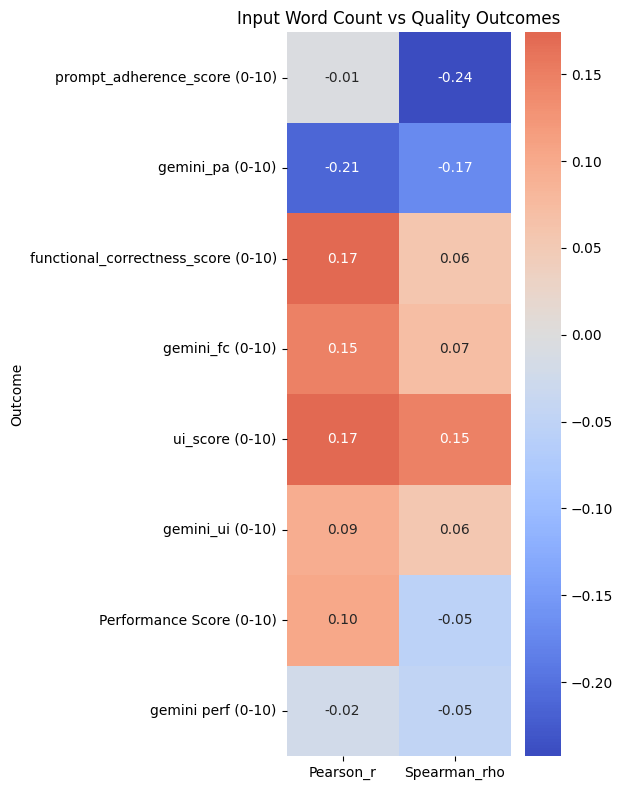

In [ ]:
corr_for_plot = corr_results_df.set_index("Outcome")[["Pearson_r", "Spearman_rho"]]

plt.figure(figsize=(6, 8))
sns.heatmap(corr_for_plot, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Input Word Count vs Quality Outcomes")
plt.tight_layout()
plt.show()

#### Does Gemini score itself better, and if so, is that because Gemini outputs were actually better, or because Gemini is biased as a judge?

This comparison is informative but low-power at the experiment level (`n = 17`). A non-significant paired result here should be read as inconclusive about stable self-favoring bias, not as evidence that such bias is absent.


Mean score baseline, paired by experiment:


,Judge: Gemini output,Judge: Others mean,Human: Gemini output,Human: Others mean,Judge-Human bias: Gemini,Judge-Human bias: Others
Metric,,,,,,
Prompt Adherence,9.118,8.039,8.176,7.649,0.941,0.390
Functional Correctness,8.706,8.255,7.959,7.459,0.747,0.796
UI Score,7.647,7.745,7.647,7.357,0.000,0.388
Overall Performance,8.606,8.041,7.969,7.511,0.636,0.530


Bias test summary:


,n_experiments,mean_delta_human (Gem - Others),p_human,mean_delta_judge (Gem - Others),p_judge,mean_bias_delta,p_bias,judge_favored_gem_cases,% favored cases where human also preferred Gemini,% favored cases where human did NOT prefer Gemini
Metric,,,,,,,,,,
Prompt Adherence,17,0.5275,0.1549,1.0784,0.0739,0.5510,0.6050,8,87.5,12.5
Functional Correctness,17,0.5000,0.1960,0.4510,0.3501,-0.0490,0.6050,8,100.0,0.0
UI Score,17,0.2902,0.5870,-0.0980,0.9546,-0.3882,0.2975,8,75.0,25.0
Overall Performance,17,0.4580,0.3060,0.5647,0.2182,0.1067,0.4038,11,100.0,0.0


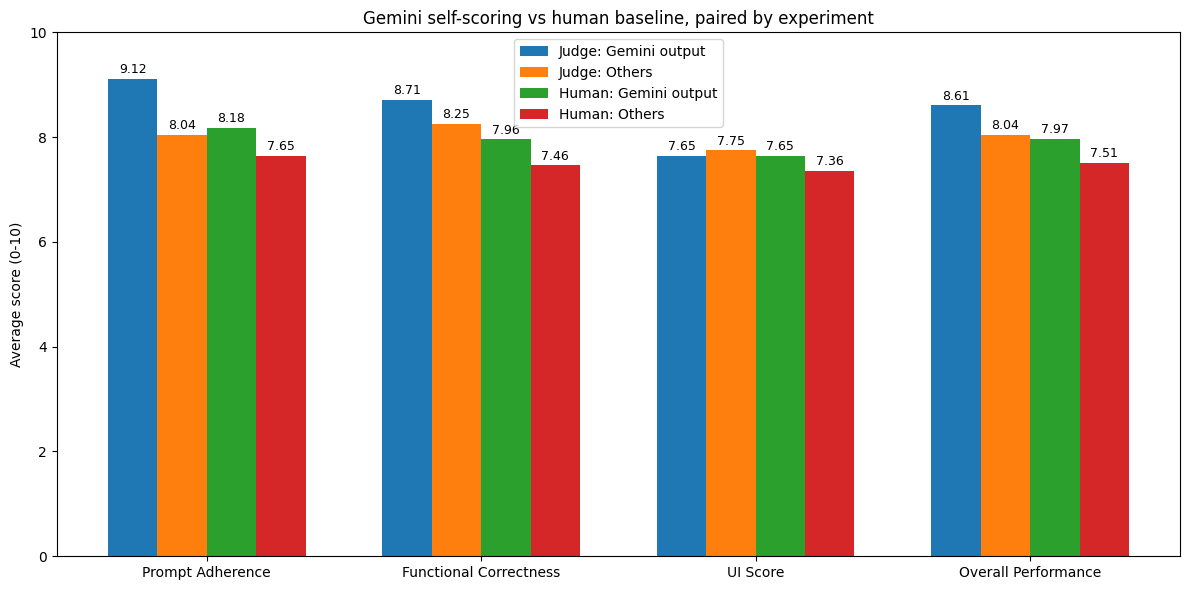

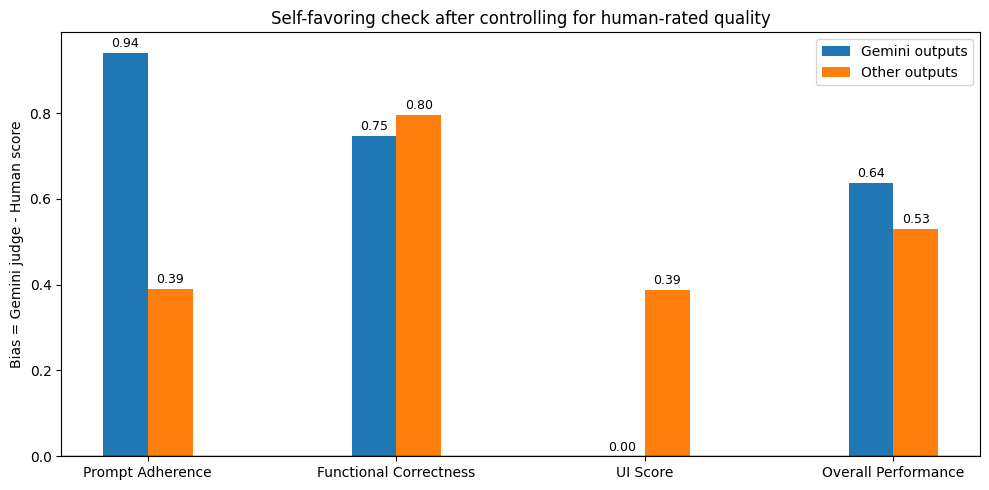

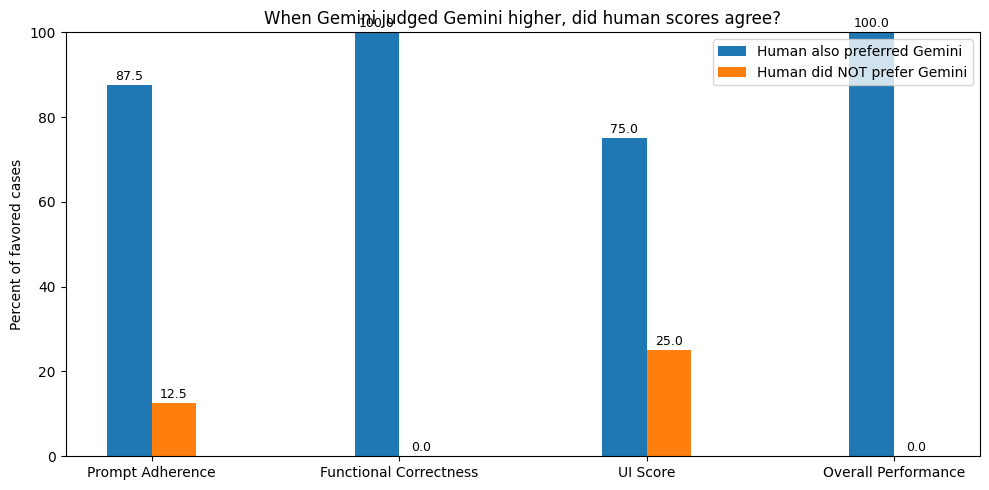


Quick interpretation helper:

Prompt Adherence
  Human delta (Gem - Others): 0.527 | p = 0.1549
  Judge delta (Gem - Others): 1.078 | p = 0.0739
  Bias delta: 0.551 | p = 0.6050
  Gemini favored Gemini in 8 experiments
  Of those favored cases, human also preferred Gemini: 87.5%
  Of those favored cases, human did NOT prefer Gemini: 12.5%

Functional Correctness
  Human delta (Gem - Others): 0.500 | p = 0.1960
  Judge delta (Gem - Others): 0.451 | p = 0.3501
  Bias delta: -0.049 | p = 0.6050
  Gemini favored Gemini in 8 experiments
  Of those favored cases, human also preferred Gemini: 100.0%
  Of those favored cases, human did NOT prefer Gemini: 0.0%

UI Score
  Human delta (Gem - Others): 0.290 | p = 0.5870
  Judge delta (Gem - Others): -0.098 | p = 0.9546
  Bias delta: -0.388 | p = 0.2975
  Gemini favored Gemini in 8 experiments
  Of those favored cases, human also preferred Gemini: 75.0%
  Of those favored cases, human did NOT prefer Gemini: 25.0%

Overall Performance
  Human delt

In [ ]:
from scipy.stats import wilcoxon

METRICS = [
    ("Prompt Adherence", "prompt_adherence_score (0-10)", "gemini_pa (0-10)"),
    ("Functional Correctness", "functional_correctness_score (0-10)", "gemini_fc (0-10)"),
    ("UI Score", "ui_score (0-10)", "gemini_ui (0-10)"),
    ("Overall Performance", "Performance Score (0-10)", "gemini perf (0-10)")
]

def wilcoxon_safe(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0 or np.allclose(x, 0):
        return np.nan, 1.0
    stat, p = wilcoxon(x, alternative="two-sided", zero_method="wilcox")
    return stat, p

analysis_df = df.copy()

summary_rows = []
mean_rows = []
paired_store = {}

for label, human_col, gemini_col in METRICS:
    tmp = analysis_df[["Experiment ID", "Model Family", human_col, gemini_col]].dropna().copy()

    # One row per experiment-model pair
    agg = (
        tmp.groupby(["Experiment ID", "Model Family"], as_index=False)[[human_col, gemini_col]]
        .mean()
    )

    # Gemini output for each experiment
    gem = (
        agg[agg["Model Family"] == "Gemini"]
        .set_index("Experiment ID")[[human_col, gemini_col]]
        .rename(columns={human_col: "human_gem", gemini_col: "judge_gem"})
    )

    # Mean of the other 3 models in the same experiment
    oth = (
        agg[agg["Model Family"] != "Gemini"]
        .groupby("Experiment ID")[[human_col, gemini_col]]
        .mean()
        .rename(columns={human_col: "human_oth", gemini_col: "judge_oth"})
    )

    paired = gem.join(oth, how="inner").dropna().copy()

    # Key deltas
    paired["delta_human"] = paired["human_gem"] - paired["human_oth"]
    paired["delta_judge"] = paired["judge_gem"] - paired["judge_oth"]

    # Bias measure:
    # If positive, Gemini judge favored Gemini more than it favored others,
    # after accounting for human-rated quality.
    paired["bias_delta"] = (
        (paired["judge_gem"] - paired["human_gem"]) -
        (paired["judge_oth"] - paired["human_oth"])
    )

    # Cases where Gemini judge scored Gemini above others
    judge_favors_gem = paired["delta_judge"] > 0
    favored_cases = paired[judge_favors_gem].copy()

    # Among those favored cases, was Gemini actually better by human score?
    if len(favored_cases) > 0:
        favored_cases["human_supports_gem"] = favored_cases["delta_human"] > 0
        favored_cases["human_not_better"] = favored_cases["delta_human"] <= 0

        pct_human_supports = favored_cases["human_supports_gem"].mean() * 100
        pct_human_not_better = favored_cases["human_not_better"].mean() * 100
    else:
        pct_human_supports = np.nan
        pct_human_not_better = np.nan

    # Stats
    stat_h, p_h = wilcoxon_safe(paired["delta_human"])
    stat_j, p_j = wilcoxon_safe(paired["delta_judge"])
    stat_b, p_b = wilcoxon_safe(paired["bias_delta"])

    summary_rows.append({
        "Metric": label,
        "n_experiments": len(paired),
        "mean_delta_human (Gem - Others)": paired["delta_human"].mean(),
        "p_human": p_h,
        "mean_delta_judge (Gem - Others)": paired["delta_judge"].mean(),
        "p_judge": p_j,
        "mean_bias_delta": paired["bias_delta"].mean(),
        "p_bias": p_b,
        "judge_favored_gem_cases": int(judge_favors_gem.sum()),
        "% favored cases where human also preferred Gemini": pct_human_supports,
        "% favored cases where human did NOT prefer Gemini": pct_human_not_better
    })

    mean_rows.append({
        "Metric": label,
        "Judge: Gemini output": paired["judge_gem"].mean(),
        "Judge: Others mean": paired["judge_oth"].mean(),
        "Human: Gemini output": paired["human_gem"].mean(),
        "Human: Others mean": paired["human_oth"].mean(),
        "Judge-Human bias: Gemini": (paired["judge_gem"] - paired["human_gem"]).mean(),
        "Judge-Human bias: Others": (paired["judge_oth"] - paired["human_oth"]).mean(),
    })

    paired_store[label] = paired.copy()

summary = pd.DataFrame(summary_rows).set_index("Metric")
means = pd.DataFrame(mean_rows).set_index("Metric")

print("Mean score baseline, paired by experiment:")
display(means.round(3))

print("Bias test summary:")
display(summary.round(4))

# ------------------------------------------------------------
# Plot 1: Gemini judge vs human baseline
# ------------------------------------------------------------
x = np.arange(len(means.index))
w = 0.18

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - 1.5*w, means["Judge: Gemini output"], w, label="Judge: Gemini output")
b2 = ax.bar(x - 0.5*w, means["Judge: Others mean"], w, label="Judge: Others")
b3 = ax.bar(x + 0.5*w, means["Human: Gemini output"], w, label="Human: Gemini output")
b4 = ax.bar(x + 1.5*w, means["Human: Others mean"], w, label="Human: Others")

ax.set_ylim(0, 10)
ax.set_ylabel("Average score (0-10)")
ax.set_xticks(x)
ax.set_xticklabels(means.index)
ax.set_title("Gemini self-scoring vs human baseline, paired by experiment")
ax.legend()

for bars in [b1, b2, b3, b4]:
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=9)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2: Bias after controlling for human quality
# Positive = Gemini judge favored Gemini more than others
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, means["Judge-Human bias: Gemini"], w, label="Gemini outputs")
b2 = ax.bar(x + w/2, means["Judge-Human bias: Others"], w, label="Other outputs")
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Bias = Gemini judge - Human score")
ax.set_xticks(x)
ax.set_xticklabels(means.index)
ax.set_title("Self-favoring check after controlling for human-rated quality")
ax.legend()

for bars in [b1, b2]:
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=9)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 3: Of the times Gemini favored Gemini, did humans agree?
# ------------------------------------------------------------
plot_cols = [
    "% favored cases where human also preferred Gemini",
    "% favored cases where human did NOT prefer Gemini"
]

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, summary[plot_cols[0]], w, label="Human also preferred Gemini")
b2 = ax.bar(x + w/2, summary[plot_cols[1]], w, label="Human did NOT prefer Gemini")
ax.set_ylim(0, 100)
ax.set_ylabel("Percent of favored cases")
ax.set_xticks(x)
ax.set_xticklabels(summary.index)
ax.set_title("When Gemini judged Gemini higher, did human scores agree?")
ax.legend()

for bars in [b1, b2]:
    ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=9)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Quick interpretation helper
# ------------------------------------------------------------
print("\nQuick interpretation helper:")
for metric, row in summary.iterrows():
    print(f"\n{metric}")
    print(f"  Human delta (Gem - Others): {row['mean_delta_human (Gem - Others)']:.3f} | p = {row['p_human']:.4f}")
    print(f"  Judge delta (Gem - Others): {row['mean_delta_judge (Gem - Others)']:.3f} | p = {row['p_judge']:.4f}")
    print(f"  Bias delta: {row['mean_bias_delta']:.3f} | p = {row['p_bias']:.4f}")
    print(f"  Gemini favored Gemini in {int(row['judge_favored_gem_cases'])} experiments")
    print(f"  Of those favored cases, human also preferred Gemini: {row['% favored cases where human also preferred Gemini']:.1f}%")
    print(f"  Of those favored cases, human did NOT prefer Gemini: {row['% favored cases where human did NOT prefer Gemini']:.1f}%")

#### % reasoning vs total

Overall reasoning % summary:


count    68.00
mean     40.36
std      25.60
min       4.91
25%      19.41
50%      37.39
75%      55.48
max      95.81
Name: reasoning_pct, dtype: float64

Reasoning time as % of total response time, by model family:


,count,mean,median,std,min,max
Model Family,,,,,,
Claude,17,31.21,38.41,19.15,4.91,61.13
GPT,17,25.55,17.05,19.17,7.01,68.31
Gemini,17,31.31,32.26,8.45,14.29,44.74
Grok,17,73.37,84.15,19.31,36.36,95.81


Mean reasoning time vs mean total response time, by model family:


,LLM Reasoning Time (s),LLM Response Time (s)
Model Family,,
Claude,48.47,148.35
GPT,80.71,247.18
Gemini,14.65,46.24
Grok,91.88,112.24


Reasoning % using family-level mean times:


Model Family
Claude    32.67
GPT       32.65
Gemini    31.68
Grok      81.86
Name: Mean reasoning %, dtype: float64

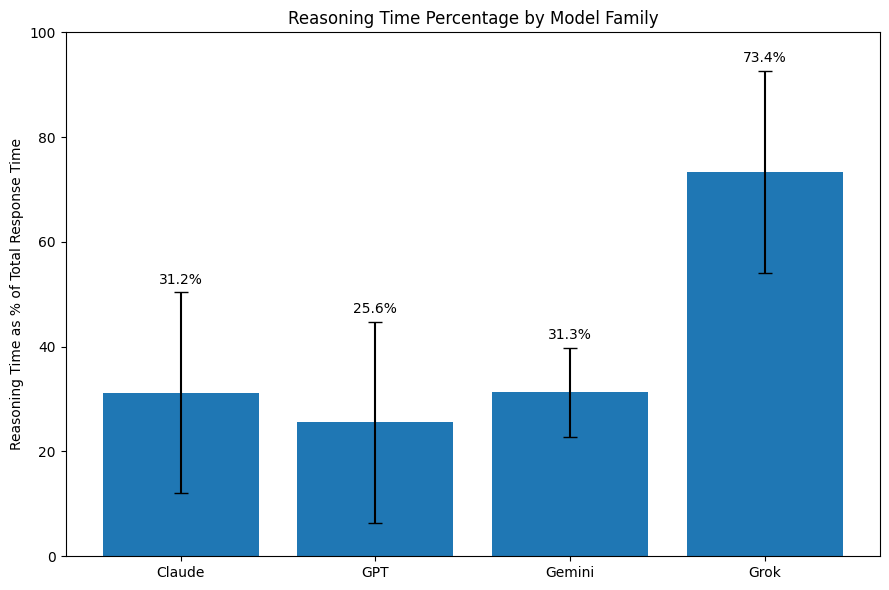

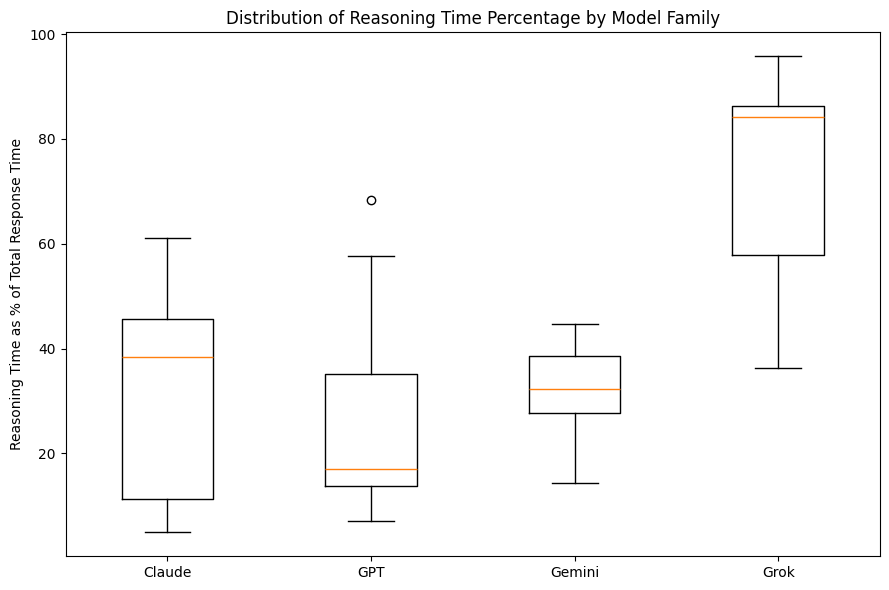

In [ ]:
# -------------------------------------------------
# % Reasoning time vs total response time
# -------------------------------------------------

time_df = df.copy()

# Safe calculation
time_df["reasoning_pct"] = np.where(
    time_df["LLM Response Time (s)"] > 0,
    (time_df["LLM Reasoning Time (s)"] / time_df["LLM Response Time (s)"]) * 100,
    np.nan
)

# Keep within logical bounds just in case of weird data
time_df["reasoning_pct"] = time_df["reasoning_pct"].clip(lower=0, upper=100)

print("Overall reasoning % summary:")
display(time_df["reasoning_pct"].describe().round(2))

# By model family
reasoning_stats = (
    time_df.groupby("Model Family")["reasoning_pct"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

print("Reasoning time as % of total response time, by model family:")
display(reasoning_stats)

# Raw means for context
raw_time_stats = (
    time_df.groupby("Model Family")[["LLM Reasoning Time (s)", "LLM Response Time (s)"]]
    .mean()
    .round(2)
)

print("Mean reasoning time vs mean total response time, by model family:")
display(raw_time_stats)

# Per-model-family ratio using means too
family_mean_ratio = (
    (raw_time_stats["LLM Reasoning Time (s)"] / raw_time_stats["LLM Response Time (s)"]) * 100
).round(2)

print("Reasoning % using family-level mean times:")
display(family_mean_ratio.rename("Mean reasoning %"))

# -------------------------------------------------
# Plot 1: average reasoning %
# -------------------------------------------------
families = reasoning_stats.index
means = reasoning_stats["mean"]
stds = reasoning_stats["std"].fillna(0)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(families, means, yerr=stds, capsize=5)

ax.set_ylabel("Reasoning Time as % of Total Response Time")
ax.set_title("Reasoning Time Percentage by Model Family")
ax.set_ylim(0, 100)
ax.bar_label(bars, fmt="%.1f%%", padding=4)

plt.tight_layout()
plt.show()

# -------------------------------------------------
# Plot 2: per-row distribution
# -------------------------------------------------
plot_data = [
    time_df.loc[time_df["Model Family"] == fam, "reasoning_pct"].dropna()
    for fam in families
]

fig, ax = plt.subplots(figsize=(9, 6))
ax.boxplot(plot_data, tick_labels=families)
ax.set_ylabel("Reasoning Time as % of Total Response Time")
ax.set_title("Distribution of Reasoning Time Percentage by Model Family")
plt.tight_layout()
plt.show()

#### Is reasoning time related to performance?

Rows used: 68


,LLM Reasoning Time (s),Performance Score (0-10),gemini perf (0-10)
count,68.000,68.000,68.000
mean,58.926,7.626,8.182
std,81.006,2.510,2.341
min,3.000,0.000,1.000
25%,12.000,7.268,7.475
50%,22.000,8.605,9.150
75%,71.250,9.200,9.750
max,466.000,10.000,10.000


Overall correlations:


,Outcome,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,Performance Score (0-10),-0.1117,0.3647,-0.0945,0.4434
1,gemini perf (0-10),-0.2042,0.0949,-0.1497,0.2230


Per-model-family correlations:


,Model Family,Outcome,n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,Claude,Performance Score (0-10),17,-0.0256,0.9222,0.0209,0.9367
1,Claude,gemini perf (0-10),17,-0.1811,0.4866,-0.1460,0.5762
2,GPT,Performance Score (0-10),17,-0.1037,0.6921,0.1074,0.6815
3,GPT,gemini perf (0-10),17,-0.1567,0.5481,-0.3863,0.1256
4,Gemini,Performance Score (0-10),17,-0.3262,0.2014,-0.5404,0.0251
5,Gemini,gemini perf (0-10),17,0.0049,0.9851,-0.0749,0.7750
6,Grok,Performance Score (0-10),17,0.0577,0.8258,0.0674,0.7970
7,Grok,gemini perf (0-10),17,-0.0826,0.7527,-0.0368,0.8884


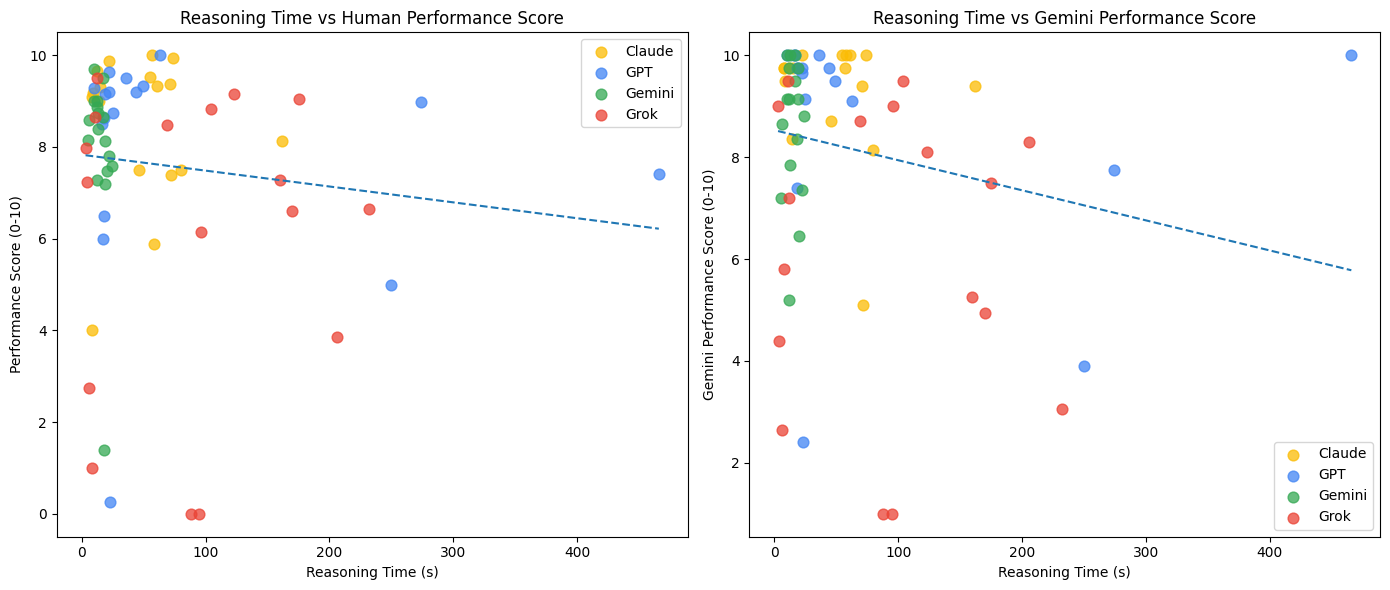

Performance by reasoning-time quartile:


Performance Score (0-10)                       \
                                           count   mean median    std   
Reasoning Time Quartile                                                 
Q1 Fastest                                    18  7.716  8.765  2.518   
Q2                                            19  8.058  8.630  1.921   
Q3                                            14  8.194  9.265  2.553   
Q4 Slowest                                    17  6.581  7.380  2.921   

                        gemini perf (0-10)                       
                                     count   mean median    std  
Reasoning Time Quartile                                          
Q1 Fastest                              18  8.133   9.15  2.223  
Q2                                      19  9.095   9.75  1.113  
Q3                                      14  8.946   9.45  1.948  
Q4 Slowest                              17  6.585   7.75  3.002


Quick interpretation helper:
- Performance Score (0-10): negative relationship overall, Spearman rho = -0.095, p = 0.4434; Pearson r = -0.112, p = 0.3647
- gemini perf (0-10): negative relationship overall, Spearman rho = -0.150, p = 0.2230; Pearson r = -0.204, p = 0.0949


In [ ]:
# -------------------------------------------------
# Is reasoning time related to performance score?
# -------------------------------------------------

analysis_df = df.copy()

x_col = "LLM Reasoning Time (s)"
y_cols = ["Performance Score (0-10)", "gemini perf (0-10)"]

subset = analysis_df[[x_col, "Model Family"] + y_cols].dropna().copy()

print("Rows used:", len(subset))
display(subset[[x_col] + y_cols].describe().round(3))

# -------------------------------------------------
# 1) Overall correlations
# -------------------------------------------------
overall_results = []

for y_col in y_cols:
    x = subset[x_col]
    y = subset[y_col]

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    overall_results.append({
        "Outcome": y_col,
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_rho": spearman_rho,
        "Spearman_p": spearman_p
    })

overall_corr_df = pd.DataFrame(overall_results).round(4)

print("Overall correlations:")
display(overall_corr_df)

# -------------------------------------------------
# 2) Per-model-family correlations
# -------------------------------------------------
family_results = []

for family in sorted(subset["Model Family"].unique()):
    fam_df = subset[subset["Model Family"] == family]

    for y_col in y_cols:
        x = fam_df[x_col]
        y = fam_df[y_col]

        pearson_r, pearson_p = pearsonr(x, y)
        spearman_rho, spearman_p = spearmanr(x, y)

        family_results.append({
            "Model Family": family,
            "Outcome": y_col,
            "n": len(fam_df),
            "Pearson_r": pearson_r,
            "Pearson_p": pearson_p,
            "Spearman_rho": spearman_rho,
            "Spearman_p": spearman_p
        })

family_corr_df = pd.DataFrame(family_results).round(4)

print("Per-model-family correlations:")
display(family_corr_df)

# -------------------------------------------------
# 3) Scatter plots, overall colored by model family
# -------------------------------------------------
colors = {
    "GPT": "#4285F4",
    "Gemini": "#34A853",
    "Grok": "#EA4335",
    "Claude": "#FBBC04"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for family, group in subset.groupby("Model Family"):
    axes[0].scatter(
        group[x_col],
        group["Performance Score (0-10)"],
        label=family,
        color=colors.get(family, None),
        alpha=0.75,
        s=60
    )
    axes[1].scatter(
        group[x_col],
        group["gemini perf (0-10)"],
        label=family,
        color=colors.get(family, None),
        alpha=0.75,
        s=60
    )

# Add overall trend lines
for ax, y_col in zip(axes, y_cols):
    z = np.polyfit(subset[x_col], subset[y_col], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(subset[x_col])
    ax.plot(x_sorted, p(x_sorted), linestyle="--")

axes[0].set_xlabel("Reasoning Time (s)")
axes[0].set_ylabel("Performance Score (0-10)")
axes[0].set_title("Reasoning Time vs Human Performance Score")
axes[0].legend()

axes[1].set_xlabel("Reasoning Time (s)")
axes[1].set_ylabel("Gemini Performance Score (0-10)")
axes[1].set_title("Reasoning Time vs Gemini Performance Score")
axes[1].legend()

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 4) Optional quartile view
# -------------------------------------------------
subset["Reasoning Time Quartile"] = pd.qcut(
    subset[x_col],
    q=4,
    labels=["Q1 Fastest", "Q2", "Q3", "Q4 Slowest"]
)

quartile_summary = (
    subset.groupby("Reasoning Time Quartile", observed=False)[y_cols]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)

print("Performance by reasoning-time quartile:")
display(quartile_summary)

# -------------------------------------------------
# 5) Quick interpretation helper
# -------------------------------------------------
print("\nQuick interpretation helper:")
for _, row in overall_corr_df.iterrows():
    direction = (
        "positive" if row["Spearman_rho"] > 0
        else "negative" if row["Spearman_rho"] < 0
        else "no"
    )
    print(
        f"- {row['Outcome']}: {direction} relationship overall, "
        f"Spearman rho = {row['Spearman_rho']:.3f}, p = {row['Spearman_p']:.4f}; "
        f"Pearson r = {row['Pearson_r']:.3f}, p = {row['Pearson_p']:.4f}"
    )

#### Is total inference time related to performance?

Rows used: 68


,LLM Response Time (s),Performance Score (0-10),gemini perf (0-10)
count,68.000,68.000,68.000
mean,138.500,7.626,8.182
std,139.874,2.510,2.341
min,7.000,0.000,1.000
25%,51.000,7.268,7.475
50%,112.000,8.605,9.150
75%,176.250,9.200,9.750
max,808.000,10.000,10.000


Overall correlations:


,Outcome,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,Performance Score (0-10),0.0516,0.6762,0.0560,0.6502
1,gemini perf (0-10),0.0264,0.8307,0.0674,0.5851


Per-model-family correlations:


,Model Family,Outcome,n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,Claude,Performance Score (0-10),17,-0.2154,0.4064,-0.1202,0.6459
1,Claude,gemini perf (0-10),17,-0.2146,0.4082,-0.3093,0.2270
2,GPT,Performance Score (0-10),17,0.0191,0.9421,-0.0221,0.9329
3,GPT,gemini perf (0-10),17,-0.0695,0.7909,-0.1912,0.4624
4,Gemini,Performance Score (0-10),17,-0.5446,0.0238,-0.5770,0.0153
5,Gemini,gemini perf (0-10),17,-0.1752,0.5013,-0.2054,0.4290
6,Grok,Performance Score (0-10),17,0.1237,0.6363,0.0576,0.8261
7,Grok,gemini perf (0-10),17,0.0030,0.9909,0.0147,0.9552


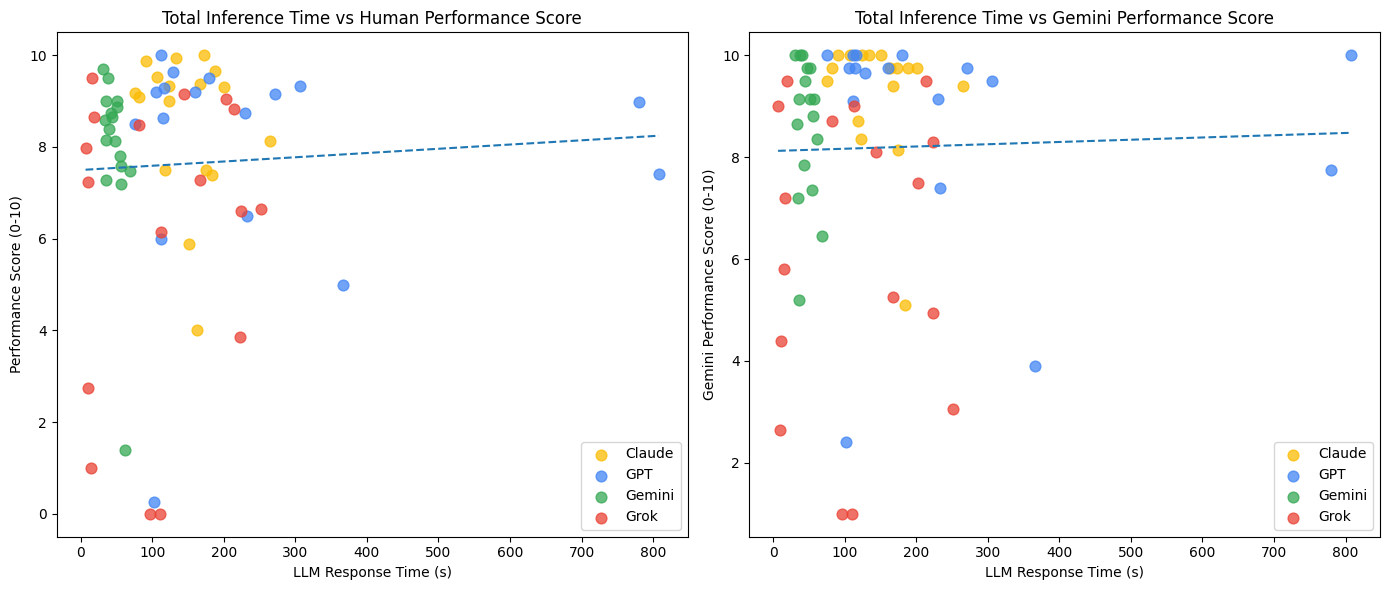

Performance by total inference time quartile:


Performance Score (0-10)                       \
                                          count   mean median    std   
Response Time Quartile                                                 
Q1 Fastest                                   18  7.841  8.615  2.292   
Q2                                           17  6.562  7.800  3.674   
Q3                                           16  8.240  9.075  1.710   
Q4 Slowest                                   17  7.885  8.750  1.693   

                       gemini perf (0-10)                       
                                    count   mean median    std  
Response Time Quartile                                          
Q1 Fastest                             18  8.042  9.075  2.199  
Q2                                     17  7.724  9.100  3.153  
Q3                                     16  9.100  9.700  1.232  
Q4 Slowest                             17  7.926  9.150  2.300


Quick interpretation helper:
- Performance Score (0-10): positive relationship overall, Spearman rho = 0.056, p = 0.6502; Pearson r = 0.052, p = 0.6762
- gemini perf (0-10): positive relationship overall, Spearman rho = 0.067, p = 0.5851; Pearson r = 0.026, p = 0.8307


In [ ]:
# -------------------------------------------------
# Total inference time = LLM Response Time (s)
# -------------------------------------------------

analysis_df = df.copy()

x_col = "LLM Response Time (s)"
y_cols = ["Performance Score (0-10)", "gemini perf (0-10)"]

subset = analysis_df[[x_col, "Model Family"] + y_cols].dropna().copy()

print("Rows used:", len(subset))
display(subset[[x_col] + y_cols].describe().round(3))

# -------------------------------------------------
# 1) Overall correlations
# -------------------------------------------------
overall_results = []

for y_col in y_cols:
    x = subset[x_col]
    y = subset[y_col]

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    overall_results.append({
        "Outcome": y_col,
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_rho": spearman_rho,
        "Spearman_p": spearman_p
    })

overall_corr_df = pd.DataFrame(overall_results).round(4)

print("Overall correlations:")
display(overall_corr_df)

# -------------------------------------------------
# 2) Per-model-family correlations
# -------------------------------------------------
family_results = []

for family in sorted(subset["Model Family"].unique()):
    fam_df = subset[subset["Model Family"] == family]

    for y_col in y_cols:
        x = fam_df[x_col]
        y = fam_df[y_col]

        pearson_r, pearson_p = pearsonr(x, y)
        spearman_rho, spearman_p = spearmanr(x, y)

        family_results.append({
            "Model Family": family,
            "Outcome": y_col,
            "n": len(fam_df),
            "Pearson_r": pearson_r,
            "Pearson_p": pearson_p,
            "Spearman_rho": spearman_rho,
            "Spearman_p": spearman_p
        })

family_corr_df = pd.DataFrame(family_results).round(4)

print("Per-model-family correlations:")
display(family_corr_df)

# -------------------------------------------------
# 3) Scatter plots, overall colored by model family
# -------------------------------------------------
colors = {
    "GPT": "#4285F4",
    "Gemini": "#34A853",
    "Grok": "#EA4335",
    "Claude": "#FBBC04"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for family, group in subset.groupby("Model Family"):
    axes[0].scatter(
        group[x_col],
        group["Performance Score (0-10)"],
        label=family,
        color=colors.get(family, None),
        alpha=0.75,
        s=60
    )
    axes[1].scatter(
        group[x_col],
        group["gemini perf (0-10)"],
        label=family,
        color=colors.get(family, None),
        alpha=0.75,
        s=60
    )

# Add overall trend lines
for ax, y_col in zip(axes, y_cols):
    z = np.polyfit(subset[x_col], subset[y_col], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(subset[x_col])
    ax.plot(x_sorted, p(x_sorted), linestyle="--")

axes[0].set_xlabel("LLM Response Time (s)")
axes[0].set_ylabel("Performance Score (0-10)")
axes[0].set_title("Total Inference Time vs Human Performance Score")
axes[0].legend()

axes[1].set_xlabel("LLM Response Time (s)")
axes[1].set_ylabel("Gemini Performance Score (0-10)")
axes[1].set_title("Total Inference Time vs Gemini Performance Score")
axes[1].legend()

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 4) Quartile view
# -------------------------------------------------
subset["Response Time Quartile"] = pd.qcut(
    subset[x_col],
    q=4,
    labels=["Q1 Fastest", "Q2", "Q3", "Q4 Slowest"]
)

quartile_summary = (
    subset.groupby("Response Time Quartile", observed=False)[y_cols]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)

print("Performance by total inference time quartile:")
display(quartile_summary)

# -------------------------------------------------
# 5) Quick interpretation helper
# -------------------------------------------------
print("\nQuick interpretation helper:")
for _, row in overall_corr_df.iterrows():
    direction = (
        "positive" if row["Spearman_rho"] > 0
        else "negative" if row["Spearman_rho"] < 0
        else "no"
    )
    print(
        f"- {row['Outcome']}: {direction} relationship overall, "
        f"Spearman rho = {row['Spearman_rho']:.3f}, p = {row['Spearman_p']:.4f}; "
        f"Pearson r = {row['Pearson_r']:.3f}, p = {row['Pearson_p']:.4f}"
    )

#### Analysis per model

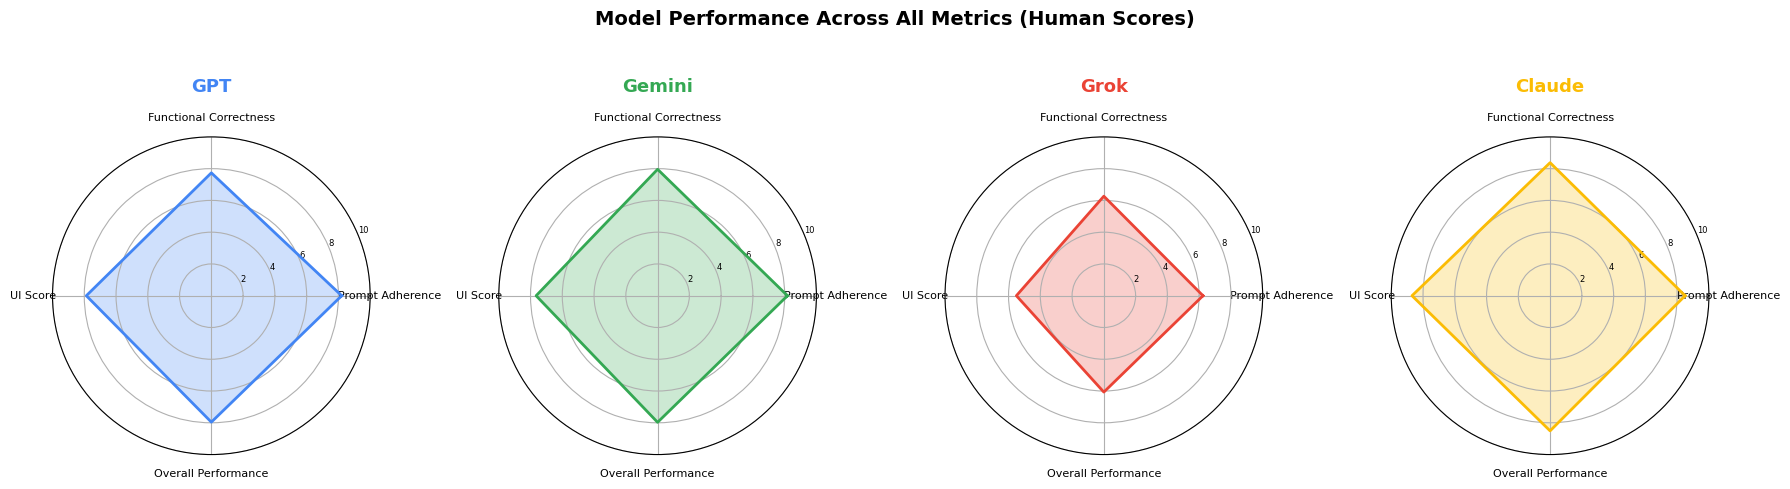

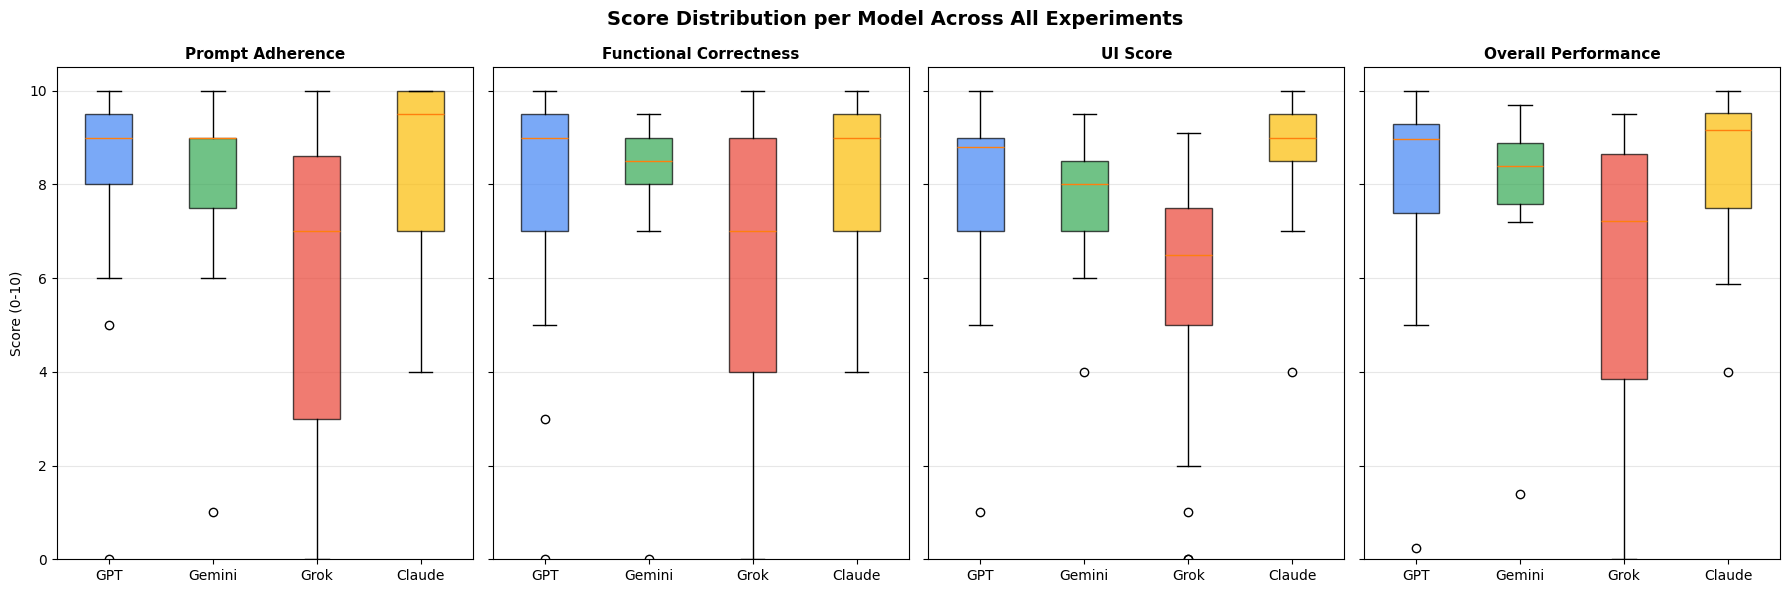


Per-model summary table:


,Prompt Adherence,Functional Correctness,UI Score,Overall Performance,Prompt Adherence Median,Functional Correctness Median,UI Score Median,Overall Performance Median,Prompt Adherence Std,Functional Correctness Std,UI Score Std,Overall Performance Std
Model Family,,,,,,,,,,,,
Claude,8.50,8.38,8.69,8.51,9.5,9.0,9.0,9.17,1.80,1.73,1.43,1.62
GPT,8.21,7.74,7.87,7.96,9.0,9.0,8.8,8.98,2.53,2.75,2.25,2.43
Gemini,8.18,7.96,7.65,7.97,9.0,8.5,8.0,8.40,2.14,2.22,1.43,1.85
Grok,6.24,6.26,5.51,6.07,7.0,7.0,6.5,7.23,3.49,3.43,2.95,3.28


In [ ]:
metrics = [
    'prompt_adherence_score (0-10)',
    'functional_correctness_score (0-10)',
    'ui_score (0-10)',
    'Performance Score (0-10)'
]

metric_labels = [
    'Prompt Adherence',
    'Functional Correctness',
    'UI Score',
    'Overall Performance'
]

colors = {'GPT': '#4285F4', 'Gemini': '#34A853', 'Grok': '#EA4335', 'Claude': '#FBBC04'}
models = ['GPT', 'Gemini', 'Grok', 'Claude']

# --- Plot 1: Radar / Spider Chart per model ---
fig, axes = plt.subplots(1, 4, figsize=(18, 5), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

for ax, model in zip(axes, models):
    subset = df[df['Model Family'] == model]
    means = [subset[m].mean() for m in metrics]
    means += means[:1]

    ax.plot(angles, means, color=colors[model], linewidth=2)
    ax.fill(angles, means, color=colors[model], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_labels, size=8)
    ax.set_ylim(0, 10)
    ax.set_title(model, size=13, fontweight='bold', pad=15, color=colors[model])
    ax.set_yticks([2, 4, 6, 8, 10])
    ax.set_yticklabels(['2', '4', '6', '8', '10'], size=6)

plt.suptitle('Model Performance Across All Metrics (Human Scores)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Plot 2: Box plot per model per metric ---
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)

for ax, metric, label in zip(axes, metrics, metric_labels):
    data = [df[df['Model Family'] == m][metric].values for m in models]
    bp = ax.boxplot(data, patch_artist=True)

    for patch, model in zip(bp['boxes'], models):
        patch.set_facecolor(colors[model])
        patch.set_alpha(0.7)

    ax.set_xticklabels(models, fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 10.5)
    ax.set_ylabel('Score (0-10)' if ax == axes[0] else '')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Score Distribution per Model Across All Experiments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Summary tables ---
mean_table = df.groupby('Model Family')[metrics].mean().round(2)
median_table = df.groupby('Model Family')[metrics].median().round(2)
std_table = df.groupby('Model Family')[metrics].std().round(2)

mean_table.columns = metric_labels
median_table.columns = [f'{x} Median' for x in metric_labels]
std_table.columns = [f'{x} Std' for x in metric_labels]

summary_table = pd.concat([mean_table, median_table, std_table], axis=1)

print("\nPer-model summary table:")
display(summary_table)

#### What exp took each model the longest inference and reasoning time?

In [ ]:
time_extremes_df = df.copy()

# Longest reasoning time per model family
idx_max_reasoning = time_extremes_df.groupby("Model Family")["LLM Reasoning Time (s)"].idxmax()
longest_reasoning = (
    time_extremes_df.loc[idx_max_reasoning, [
        "Model Family",
        "LLM Model",
        "Experiment ID",
        "LLM Reasoning Time (s)",
        "LLM Response Time (s)",
        "Performance Score (0-10)",
        "gemini perf (0-10)"
    ]]
    .sort_values("LLM Reasoning Time (s)", ascending=False)
    .reset_index(drop=True)
)

# Longest total inference time per model family
idx_max_inference = time_extremes_df.groupby("Model Family")["LLM Response Time (s)"].idxmax()
longest_inference = (
    time_extremes_df.loc[idx_max_inference, [
        "Model Family",
        "LLM Model",
        "Experiment ID",
        "LLM Response Time (s)",
        "LLM Reasoning Time (s)",
        "Performance Score (0-10)",
        "gemini perf (0-10)"
    ]]
    .sort_values("LLM Response Time (s)", ascending=False)
    .reset_index(drop=True)
)

print("--- Longest Reasoning Time per Model Family ---")
display(longest_reasoning)

print("--- Longest Total Inference Time per Model Family ---")
display(longest_inference)

# -------------------------------------------------
# Combined summary table
# -------------------------------------------------
combined = (
    longest_reasoning[[
        "Model Family",
        "LLM Model",
        "Experiment ID",
        "LLM Reasoning Time (s)"
    ]]
    .rename(columns={
        "LLM Model": "Reasoning Max Model",
        "Experiment ID": "Reasoning Max Experiment",
        "LLM Reasoning Time (s)": "Max Reasoning Time (s)"
    })
    .merge(
        longest_inference[[
            "Model Family",
            "LLM Model",
            "Experiment ID",
            "LLM Response Time (s)"
        ]].rename(columns={
            "LLM Model": "Inference Max Model",
            "Experiment ID": "Inference Max Experiment",
            "LLM Response Time (s)": "Max Inference Time (s)"
        }),
        on="Model Family",
        how="inner"
    )
)

combined["Same experiment for both?"] = (
    combined["Reasoning Max Experiment"] == combined["Inference Max Experiment"]
)

print("--- Combined summary ---")
display(combined)

# Printout
print("\nQuick summary:")
for _, row in combined.iterrows():
    print(
        f"- {row['Model Family']}: longest reasoning = {row['Reasoning Max Experiment']} "
        f"({row['Max Reasoning Time (s)']}s), longest inference = {row['Inference Max Experiment']} "
        f"({row['Max Inference Time (s)']}s), same experiment = {row['Same experiment for both?']}"
    )

--- Longest Reasoning Time per Model Family ---


,Model Family,LLM Model,Experiment ID,LLM Reasoning Time (s),LLM Response Time (s),Performance Score (0-10),gemini perf (0-10)
0,GPT,gpt-5.2-extended-thinking,backflip_1014,466,808,7.40,10.00
1,Grok,grok-4.1-thinking,basketball_0131,232,252,6.65,3.05
2,Claude,opus-4.5-thinking-32k,backflip_1014,162,265,8.13,9.40
3,Gemini,gemini-3-pro,basketball_0131,24,56,7.58,8.80


--- Longest Total Inference Time per Model Family ---


,Model Family,LLM Model,Experiment ID,LLM Response Time (s),LLM Reasoning Time (s),Performance Score (0-10),gemini perf (0-10)
0,GPT,gpt-5.2-extended-thinking,backflip_1014,808,466,7.40,10.00
1,Claude,opus-4.5-thinking-32k,backflip_1014,265,162,8.13,9.40
2,Grok,grok-4.1-thinking,basketball_0131,252,232,6.65,3.05
3,Gemini,gemini-3-pro,snake_0121,69,20,7.48,6.45


--- Combined summary ---


,Model Family,Reasoning Max Model,Reasoning Max Experiment,Max Reasoning Time (s),Inference Max Model,Inference Max Experiment,Max Inference Time (s),Same experiment for both?
0,GPT,gpt-5.2-extended-thinking,backflip_1014,466,gpt-5.2-extended-thinking,backflip_1014,808,True
1,Grok,grok-4.1-thinking,basketball_0131,232,grok-4.1-thinking,basketball_0131,252,True
2,Claude,opus-4.5-thinking-32k,backflip_1014,162,opus-4.5-thinking-32k,backflip_1014,265,True
3,Gemini,gemini-3-pro,basketball_0131,24,gemini-3-pro,snake_0121,69,False



Quick summary:
- GPT: longest reasoning = backflip_1014 (466s), longest inference = backflip_1014 (808s), same experiment = True
- Grok: longest reasoning = basketball_0131 (232s), longest inference = basketball_0131 (252s), same experiment = True
- Claude: longest reasoning = backflip_1014 (162s), longest inference = backflip_1014 (265s), same experiment = True
- Gemini: longest reasoning = basketball_0131 (24s), longest inference = snake_0121 (69s), same experiment = False


#### What exp took each model the longest code? (HTML lines)

--- Longest HTML Output per Model Family ---


,Model Family,LLM Model,Experiment ID,Lines of HTML,Performance Score (0-10),LLM Reasoning Time (s)
0,GPT,gpt-5.2-extended-thinking,snake_0121,1422,8.98,274
1,Claude,opus-4.5-thinking-32k,airplane_0117,1254,4.00,8
2,Gemini,gemini-3-pro,paper_airplane_0204,509,1.40,18
3,Grok,grok-4.1-thinking,snake_0121,366,9.04,175


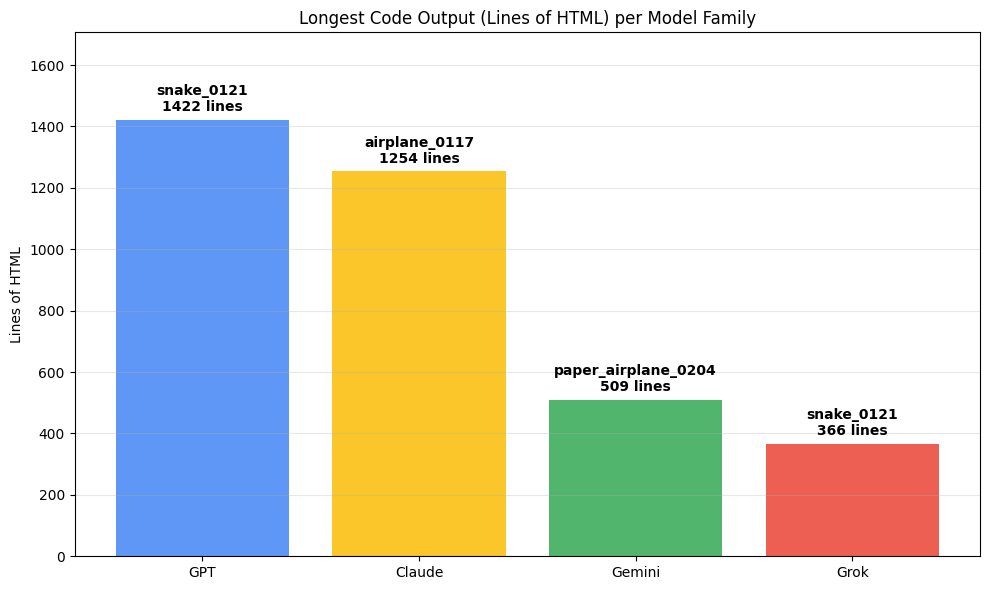

In [ ]:
longest_html = (
    df.loc[
        df.groupby('Model Family')['Lines of HTML'].idxmax(),
        ['Model Family', 'LLM Model', 'Experiment ID', 'Lines of HTML', 'Performance Score (0-10)', 'LLM Reasoning Time (s)']
    ]
    .sort_values('Lines of HTML', ascending=False)
    .reset_index(drop=True)
)

print('--- Longest HTML Output per Model Family ---')
display(longest_html)

fig, ax = plt.subplots(figsize=(10, 6))
colors = {'GPT': '#4285F4', 'Gemini': '#34A853', 'Grok': '#EA4335', 'Claude': '#FBBC04'}
bar_colors = [colors.get(model, '#888888') for model in longest_html['Model Family']]

bars = ax.bar(longest_html['Model Family'], longest_html['Lines of HTML'], color=bar_colors, alpha=0.85)

for bar, (_, row) in zip(bars, longest_html.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 18,
        f"{row['Experiment ID']}\n{int(row['Lines of HTML'])} lines",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_ylabel('Lines of HTML')
ax.set_title('Longest Code Output (Lines of HTML) per Model Family')
ax.set_ylim(0, longest_html['Lines of HTML'].max() * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig('figures/figure_11.png', dpi=300, bbox_inches='tight')
plt.show()

#### Correlation of length of code vs performance?

Correlation: Lines of HTML vs Human Performance Score
Pearson:  r=0.185, p=0.1309
Spearman: r=0.243, p=0.0456

Performance by HTML quartile:


,count,mean,median,std
HTML Quartile,,,,
Q1 Lowest,17,6.119,7.28,3.310
Q2,17,8.586,8.75,0.935
Q3,17,7.412,8.50,2.807
Q4 Highest,17,8.386,9.15,1.619


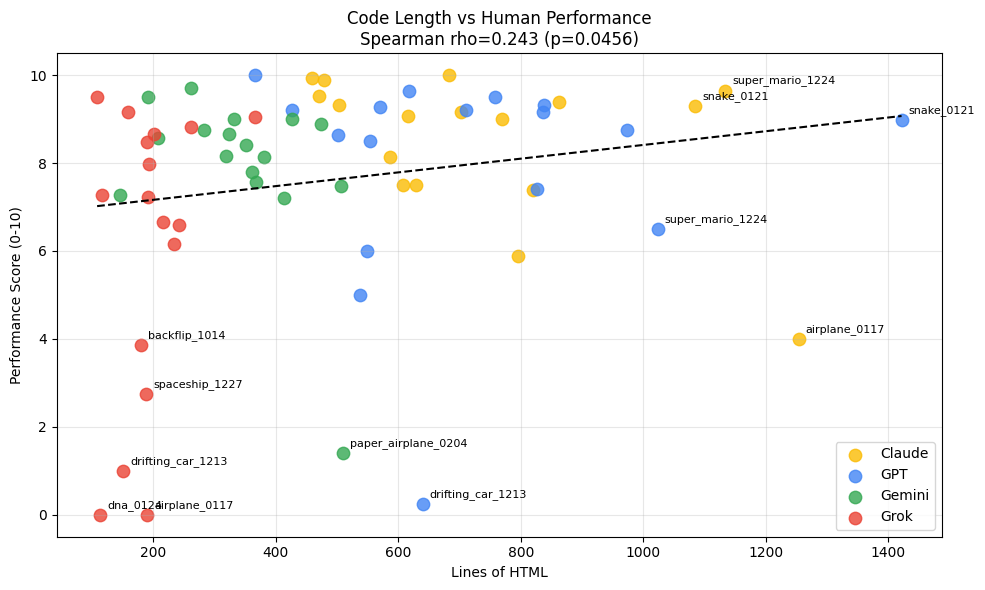

In [ ]:
analysis_df = df[['Lines of HTML', 'Performance Score (0-10)', 'Model Family', 'Experiment ID']].dropna().copy()

pr, pp = pearsonr(analysis_df['Lines of HTML'], analysis_df['Performance Score (0-10)'])
sr, sp = spearmanr(analysis_df['Lines of HTML'], analysis_df['Performance Score (0-10)'])

print('Correlation: Lines of HTML vs Human Performance Score')
print(f'Pearson:  r={pr:.3f}, p={pp:.4f}')
print(f'Spearman: r={sr:.3f}, p={sp:.4f}')

analysis_df['HTML Quartile'] = pd.qcut(
    analysis_df['Lines of HTML'],
    q=4,
    labels=['Q1 Lowest', 'Q2', 'Q3', 'Q4 Highest']
)
quartile_summary = (
    analysis_df.groupby('HTML Quartile', observed=False)['Performance Score (0-10)']
    .agg(['count', 'mean', 'median', 'std'])
    .round(3)
)

print('\nPerformance by HTML quartile:')
display(quartile_summary)

fig, ax = plt.subplots(figsize=(10, 6))
colors = {'GPT': '#4285F4', 'Gemini': '#34A853', 'Grok': '#EA4335', 'Claude': '#FBBC04'}

for family, group in analysis_df.groupby('Model Family'):
    ax.scatter(
        group['Lines of HTML'],
        group['Performance Score (0-10)'],
        label=family,
        color=colors.get(family, '#888888'),
        alpha=0.8,
        s=80
    )

trend = np.polyfit(analysis_df['Lines of HTML'], analysis_df['Performance Score (0-10)'], 1)
trend_fn = np.poly1d(trend)
x_sorted = np.sort(analysis_df['Lines of HTML'])
ax.plot(x_sorted, trend_fn(x_sorted), linestyle='--', color='black', linewidth=1.5)

for _, row in analysis_df.iterrows():
    if row['Lines of HTML'] > 1000 or row['Performance Score (0-10)'] < 5:
        ax.annotate(row['Experiment ID'], (row['Lines of HTML'], row['Performance Score (0-10)']), fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Lines of HTML')
ax.set_ylabel('Performance Score (0-10)')
ax.set_title(f'Code Length vs Human Performance\nSpearman rho={sr:.3f} (p={sp:.4f})')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('figures/figure_12.png', dpi=300, bbox_inches='tight')
plt.show()

### Experiment Dataframe

In [ ]:
exp_df.head()

,Experiment ID,X_Impressions_24h,Prompt,Experiment_Type,Visual_Type,Input_Word_Count,Date_Generated,Date_posted,Day_of_week_posted,Time_posted_X_hour,Time_posted_X_minute,X_followers,TikTok_followers,YouTube_followers,Video_duration_s,MaleFemale_song_voice,Song_Key,Song_BPM,Song_style,Lyrics_words,LLM_used_for_song,Suno_version,Perf_mean,Perf_max,Perf_min,PA_mean,FC_mean,UI_mean,LinesHTML_mean,LinesHTML_max,ReasonTime_mean,RespTime_mean,Reason_words_mean,Reason_chars_mean,Reason_sentences_mean,Reason_topkw_rep_mean,gemini_pa_mean,gemini_fc_mean,gemini_ui_mean,gemini_perf_mean,X_Likes_24h,X_Shares_24h,TikTok_Views_24h,TikTok_Likes_24h,YouTube_Views_24h,YouTube_Likes_24h,Code_in_Reasoning_unique
0,airplane_0117,15636,Create a 3D simulation of an airplane landing ...,0,1,10,2026-01-15,2026-01-17,0,9,11,4787,95,1022,93,0,D♯ minor,96,"hip hop, pop",244,gpt-5.2-extended-thinking,0,5.4775,9.33,0.00,5.625,5.375,5.375,622.50,1254,39.50,153.50,225.25,1445.50,13.25,6.50,7.75,7.50,6.00,7.2250,128,3,990,44,188,1,0
1,backflip_1014,214,Create a slow-motion simulation of a stick-fig...,0,1,43,2026-01-10,2026-01-14,1,12,27,4755,94,1016,92,1,D♯ minor,146,"Trap, Southern hip-hop, Atlanta rap, Melodic r...",241,opus-4.5-thinking-32k,0,6.6450,8.13,3.85,6.625,6.500,6.875,501.75,827,213.25,338.25,1084.25,7011.75,46.75,21.25,10.00,9.00,8.25,9.2125,5,1,197,8,20,0,not unique
2,basketball_0131,346,Create a simulation of a basketball free-throw...,1,0,36,2026-01-31,2026-01-31,0,11,49,4961,97,1034,112,1,D♯ minor,87,"hip hop, pop",251,gemini-3-pro,1,7.1525,9.38,5.00,7.250,6.875,7.375,495.25,862,144.25,210.25,1282.00,9642.00,47.25,23.00,6.75,5.25,7.00,6.2875,8,0,197,3,165,0,not unique
3,blooming_flower_1217,97813,Create an animation of a single flower bloomin...,0,1,18,2025-12-12,2025-12-17,1,16,12,4082,77,974,93,1,A major,91,"hip hop, pop",304,gpt-5.2-extended-thinking,1,9.0275,9.93,7.98,9.250,9.375,8.175,366.50,554,25.75,62.00,375.75,2715.75,11.00,8.50,10.00,10.00,9.00,9.7500,650,20,180,5,284,0,not unique
4,dna_0124,5502,Create a rotating 3D animation of a Double Hel...,0,1,19,2026-01-22,2026-01-24,0,9,10,4836,96,1026,77,1,B minor,97,"hip hop, pop",229,opus-4.5-thinking-32k,0,6.2575,9.53,0.00,6.250,6.250,6.275,331.00,549,44.25,88.50,558.50,3976.75,23.25,10.00,7.75,7.75,7.75,7.7500,39,2,835,48,208,2,not unique


In [ ]:
exp_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Experiment ID             17 non-null     str           
 1   X_Impressions_24h         17 non-null     int64         
 2   Prompt                    17 non-null     str           
 3   Experiment_Type           17 non-null     Int64         
 4   Visual_Type               17 non-null     Int64         
 5   Input_Word_Count          17 non-null     int64         
 6   Date_Generated            17 non-null     datetime64[us]
 7   Date_posted               17 non-null     datetime64[us]
 8   Day_of_week_posted        17 non-null     Int64         
 9   Time_posted_X_hour        17 non-null     int32         
 10  Time_posted_X_minute      17 non-null     int32         
 11  X_followers               17 non-null     int64         
 12  TikTok_followers          17 non-nu

#### Are longer prompts associated with weaker or inconsistent gains in user impressions?

Prompt length vs X impressions
Pearson:  r=-0.269, p=0.2961
Spearman: r=-0.274, p=0.2864

Quartile summary:


,count,mean,median,std,min,max,cv
Prompt Length Quartile,,,,,,,
Q1 Shortest,7,55572.57,38167.0,49045.17,851,135606,0.883
Q2,2,5502.00,5502.0,0.00,5502,5502,0.000
Q3,4,98249.25,92995.0,102546.95,346,206661,1.044
Q4 Longest,4,15047.50,14637.5,16125.86,214,30701,1.072


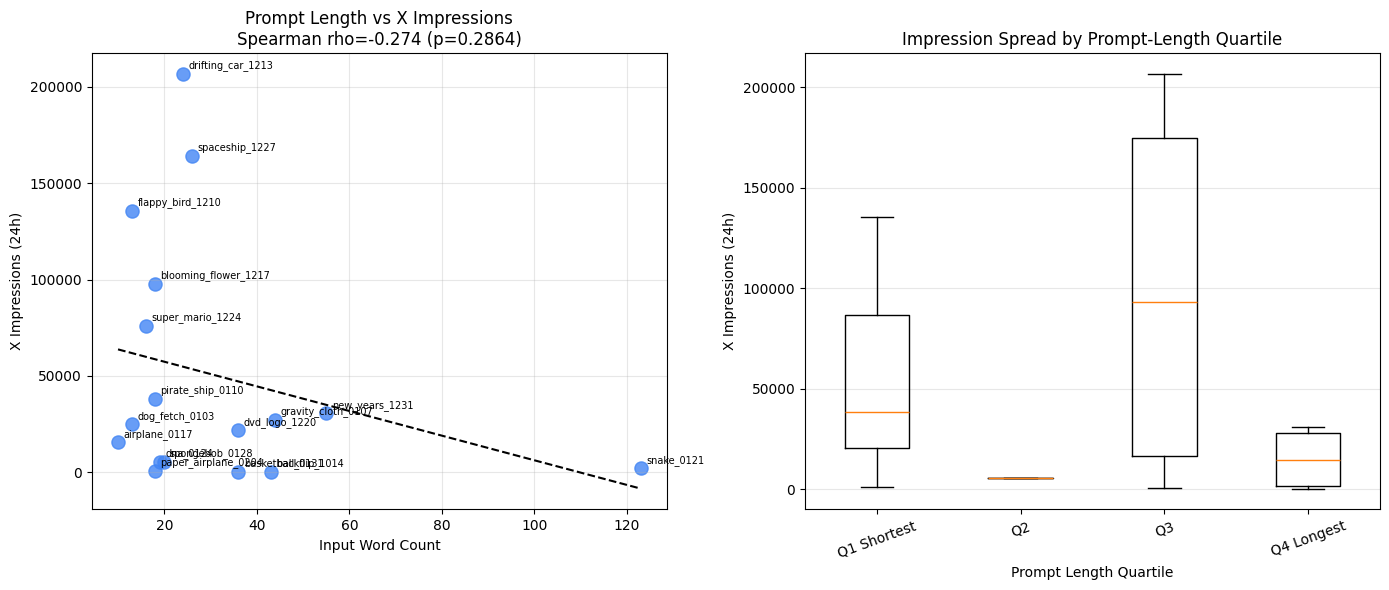

In [ ]:
prompt_impressions_df = exp_df[['Experiment ID', 'Input_Word_Count', 'X_Impressions_24h']].dropna().copy()

pr, pp = pearsonr(prompt_impressions_df['Input_Word_Count'], prompt_impressions_df['X_Impressions_24h'])
sr, sp = spearmanr(prompt_impressions_df['Input_Word_Count'], prompt_impressions_df['X_Impressions_24h'])

prompt_impressions_df['Prompt Length Quartile'] = pd.qcut(
    prompt_impressions_df['Input_Word_Count'],
    q=4,
    labels=['Q1 Shortest', 'Q2', 'Q3', 'Q4 Longest']
)

quartile_summary = (
    prompt_impressions_df.groupby('Prompt Length Quartile', observed=False)['X_Impressions_24h']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .round(2)
)
quartile_summary['cv'] = (quartile_summary['std'] / quartile_summary['mean']).round(3)

print('Prompt length vs X impressions')
print(f'Pearson:  r={pr:.3f}, p={pp:.4f}')
print(f'Spearman: r={sr:.3f}, p={sp:.4f}')
print('\nQuartile summary:')
display(quartile_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(prompt_impressions_df['Input_Word_Count'], prompt_impressions_df['X_Impressions_24h'], color='#4285F4', s=90, alpha=0.8)
trend = np.polyfit(prompt_impressions_df['Input_Word_Count'], prompt_impressions_df['X_Impressions_24h'], 1)
trend_fn = np.poly1d(trend)
x_sorted = np.sort(prompt_impressions_df['Input_Word_Count'])
axes[0].plot(x_sorted, trend_fn(x_sorted), linestyle='--', color='black', linewidth=1.5)
for _, row in prompt_impressions_df.iterrows():
    axes[0].annotate(row['Experiment ID'], (row['Input_Word_Count'], row['X_Impressions_24h']), fontsize=7, xytext=(4, 4), textcoords='offset points')
axes[0].set_title(f'Prompt Length vs X Impressions\nSpearman rho={sr:.3f} (p={sp:.4f})')
axes[0].set_xlabel('Input Word Count')
axes[0].set_ylabel('X Impressions (24h)')
axes[0].grid(alpha=0.3)

quartile_groups = [
    prompt_impressions_df.loc[prompt_impressions_df['Prompt Length Quartile'] == label, 'X_Impressions_24h']
    for label in ['Q1 Shortest', 'Q2', 'Q3', 'Q4 Longest']
]
axes[1].boxplot(quartile_groups, tick_labels=['Q1 Shortest', 'Q2', 'Q3', 'Q4 Longest'])
axes[1].set_title('Impression Spread by Prompt-Length Quartile')
axes[1].set_xlabel('Prompt Length Quartile')
axes[1].set_ylabel('X Impressions (24h)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig('figures/figure_13.png', dpi=300, bbox_inches='tight')
plt.show()

#### Analyze followers on X growth according to impressions and likes

Correlation between starting X followers and post outcomes:


,Metric,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,X_Impressions_24h,-0.8281,0.0000,-0.8449,0.0000
1,X_Likes_24h,-0.7202,0.0011,-0.8179,0.0001
2,impressions_per_follower,-0.8483,0.0000,-0.8578,0.0000
3,likes_per_follower,-0.7389,0.0007,-0.8186,0.0001
4,like_rate_from_impressions,0.5644,0.0183,0.7223,0.0011


Top experiments by impressions per follower:


,Experiment ID,X_followers,X_Impressions_24h,impressions_per_follower
6,drifting_car_1213,3760,206661,54.96
8,flappy_bird_1210,3570,135606,37.98
14,spaceship_1227,4342,164249,37.83
3,blooming_flower_1217,4082,97813,23.96
16,super_mario_1224,4262,75948,17.82


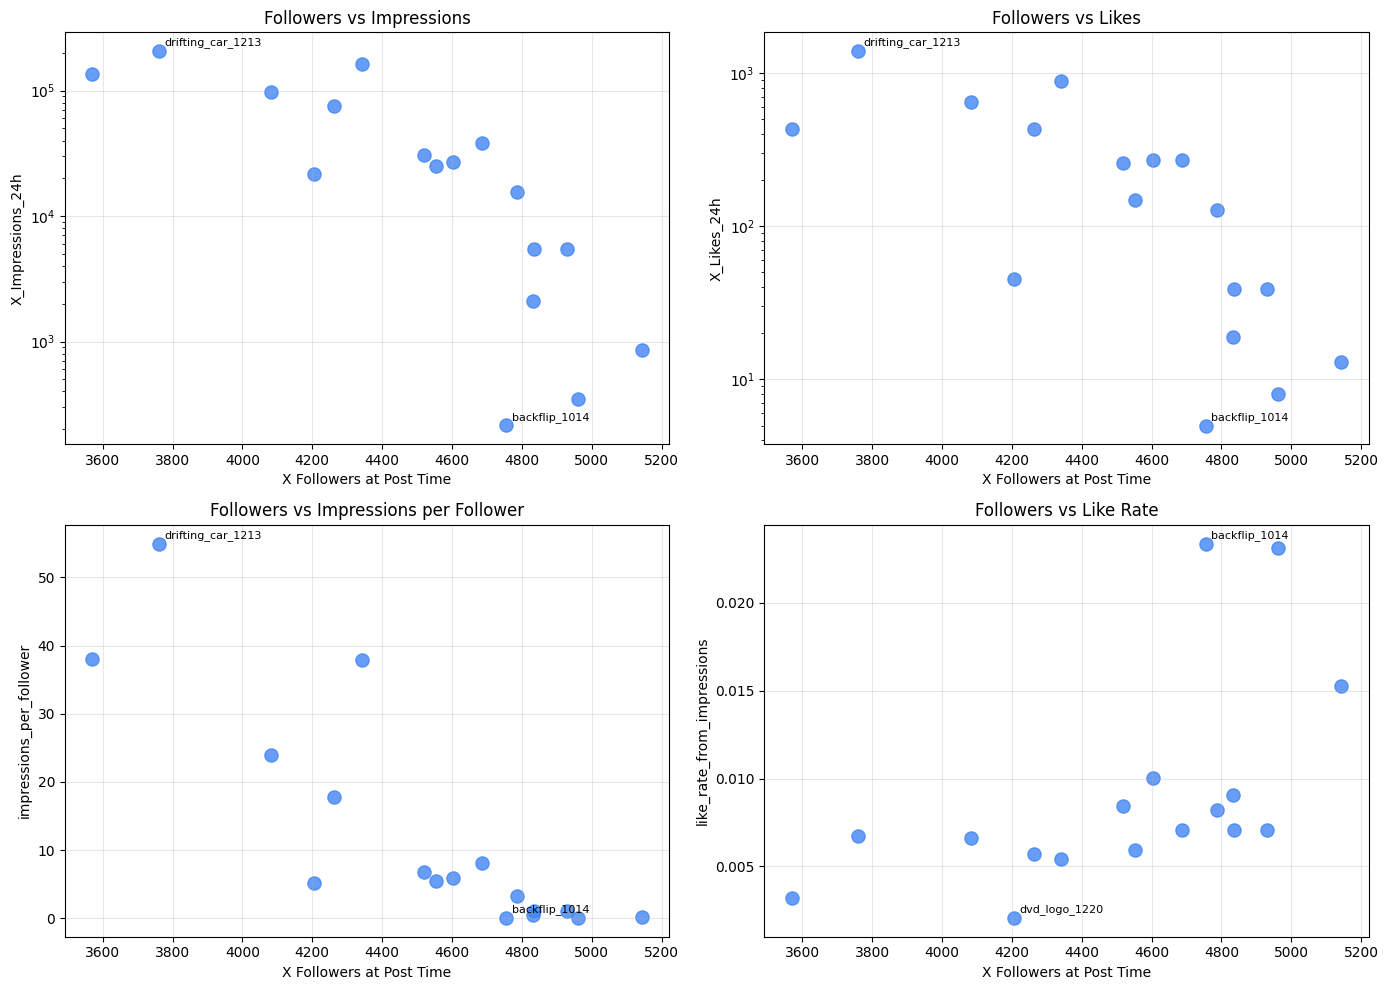

In [ ]:
followers_df = exp_df[['Experiment ID', 'X_followers', 'X_Impressions_24h', 'X_Likes_24h']].dropna().copy()

followers_df['impressions_per_follower'] = followers_df['X_Impressions_24h'] / followers_df['X_followers']
followers_df['likes_per_follower'] = followers_df['X_Likes_24h'] / followers_df['X_followers']
followers_df['like_rate_from_impressions'] = followers_df['X_Likes_24h'] / followers_df['X_Impressions_24h']

metrics_to_test = [
    'X_Impressions_24h',
    'X_Likes_24h',
    'impressions_per_follower',
    'likes_per_follower',
    'like_rate_from_impressions'
]

rows = []
for metric in metrics_to_test:
    pr, pp = pearsonr(followers_df['X_followers'], followers_df[metric])
    sr, sp = spearmanr(followers_df['X_followers'], followers_df[metric])
    rows.append({
        'Metric': metric,
        'Pearson_r': pr,
        'Pearson_p': pp,
        'Spearman_rho': sr,
        'Spearman_p': sp
    })

followers_corr_df = pd.DataFrame(rows).round(4)
print('Correlation between starting X followers and post outcomes:')
display(followers_corr_df)

print('Top experiments by impressions per follower:')
display(
    followers_df.sort_values('impressions_per_follower', ascending=False)[
        ['Experiment ID', 'X_followers', 'X_Impressions_24h', 'impressions_per_follower']
    ].head(5).round(2)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_specs = [
    ('X_Impressions_24h', 'Followers vs Impressions', True),
    ('X_Likes_24h', 'Followers vs Likes', True),
    ('impressions_per_follower', 'Followers vs Impressions per Follower', False),
    ('like_rate_from_impressions', 'Followers vs Like Rate', False),
]

for ax, (metric, title, log_y) in zip(axes.flatten(), plot_specs):
    ax.scatter(followers_df['X_followers'], followers_df[metric], color='#4285F4', s=90, alpha=0.8)
    for _, row in followers_df.iterrows():
        if row[metric] == followers_df[metric].max() or row[metric] == followers_df[metric].min():
            ax.annotate(row['Experiment ID'], (row['X_followers'], row[metric]), fontsize=8, xytext=(4, 4), textcoords='offset points')
    if log_y:
        ax.set_yscale('log')
    ax.set_xlabel('X Followers at Post Time')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('figures/figure_14.png', dpi=300, bbox_inches='tight')
plt.show()

#### Is the song bpm related to impressions?

Pearson:  r=-0.257, p=0.3195
Spearman: r=-0.163, p=0.5325


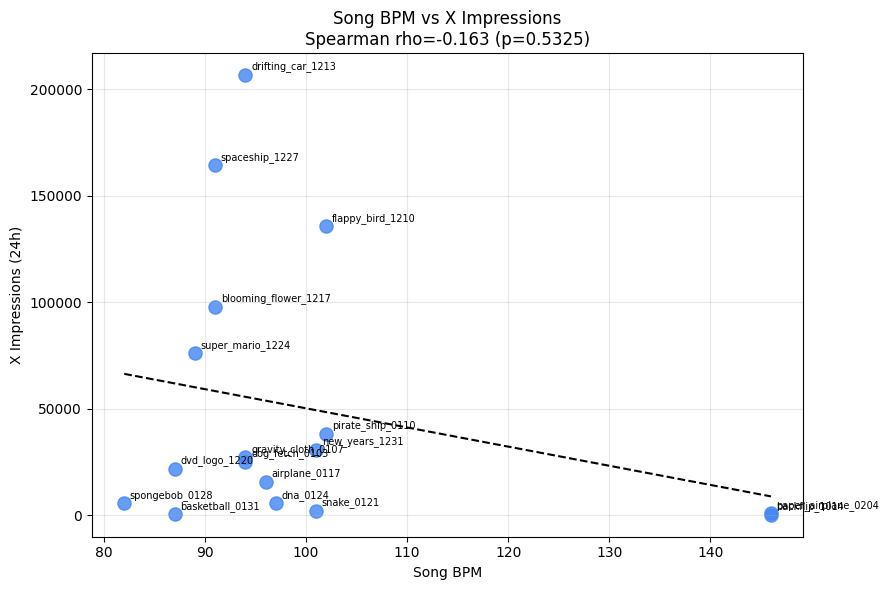

In [ ]:
pr, pp = pearsonr(exp_df['Song_BPM'], exp_df['X_Impressions_24h'])
sr, sp = spearmanr(exp_df['Song_BPM'], exp_df['X_Impressions_24h'])
print(f'Pearson:  r={pr:.3f}, p={pp:.4f}')
print(f'Spearman: r={sr:.3f}, p={sp:.4f}')

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(exp_df['Song_BPM'], exp_df['X_Impressions_24h'], color='#4285F4', s=90, alpha=0.8)
trend = np.polyfit(exp_df['Song_BPM'], exp_df['X_Impressions_24h'], 1)
trend_fn = np.poly1d(trend)
x_sorted = np.sort(exp_df['Song_BPM'])
ax.plot(x_sorted, trend_fn(x_sorted), linestyle='--', color='black', linewidth=1.5)

for _, row in exp_df.iterrows():
    ax.annotate(row['Experiment ID'], (row['Song_BPM'], row['X_Impressions_24h']), fontsize=7, xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Song BPM')
ax.set_ylabel('X Impressions (24h)')
ax.set_title(f'Song BPM vs X Impressions\nSpearman rho={sr:.3f} (p={sp:.4f})')
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('figures/figure_15.png', dpi=300, bbox_inches='tight')
plt.show()

#### Is model-level generation time related to performance?

In [ ]:
# Model-level analysis: generation time varies by model row, so do not collapse with .first().
generation_perf_df = df[
    [
        'Experiment ID',
        'LLM Model',
        'Model Family',
        'Time ET of the Generation_hour',
        'Performance Score (0-10)',
        'gemini perf (0-10)'
    ]
].dropna().copy()

generation_perf_df = generation_perf_df.rename(
    columns={'Time ET of the Generation_hour': 'Generation_Hour'}
)

print(f'Rows used: {len(generation_perf_df)} model generations')
print('\nGeneration-hour distribution:')
display(generation_perf_df['Generation_Hour'].value_counts().sort_index())

generation_hour_variation = (
    generation_perf_df.groupby('Experiment ID')['Generation_Hour']
    .agg(['nunique', 'min', 'max', 'mean'])
    .sort_values(['nunique', 'max'], ascending=False)
)

print('\nExperiment-level variation in generation hour:')
display(generation_hour_variation)

Rows used: 68 model generations

Generation-hour distribution:


Generation_Hour
3      1
10     8
11     4
12     4
13     4
14     5
15     2
16    13
17     7
18    12
19     8
Name: count, dtype: int64


Experiment-level variation in generation hour:


,nunique,min,max,mean
Experiment ID,,,,
super_mario_1224,3,3,15,11.75
flappy_bird_1210,2,16,17,16.75
drifting_car_1213,1,19,19,19.00
paper_airplane_0204,1,19,19,19.00
airplane_0117,1,18,18,18.00
dna_0124,1,18,18,18.00
spaceship_1227,1,18,18,18.00
dvd_logo_1220,1,17,17,17.00
blooming_flower_1217,1,16,16,16.00


,Outcome,n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,Human Performance Score,68,-0.1676,0.1719,0.0315,0.7984
1,Gemini Performance Score,68,0.0275,0.8241,0.0518,0.6747


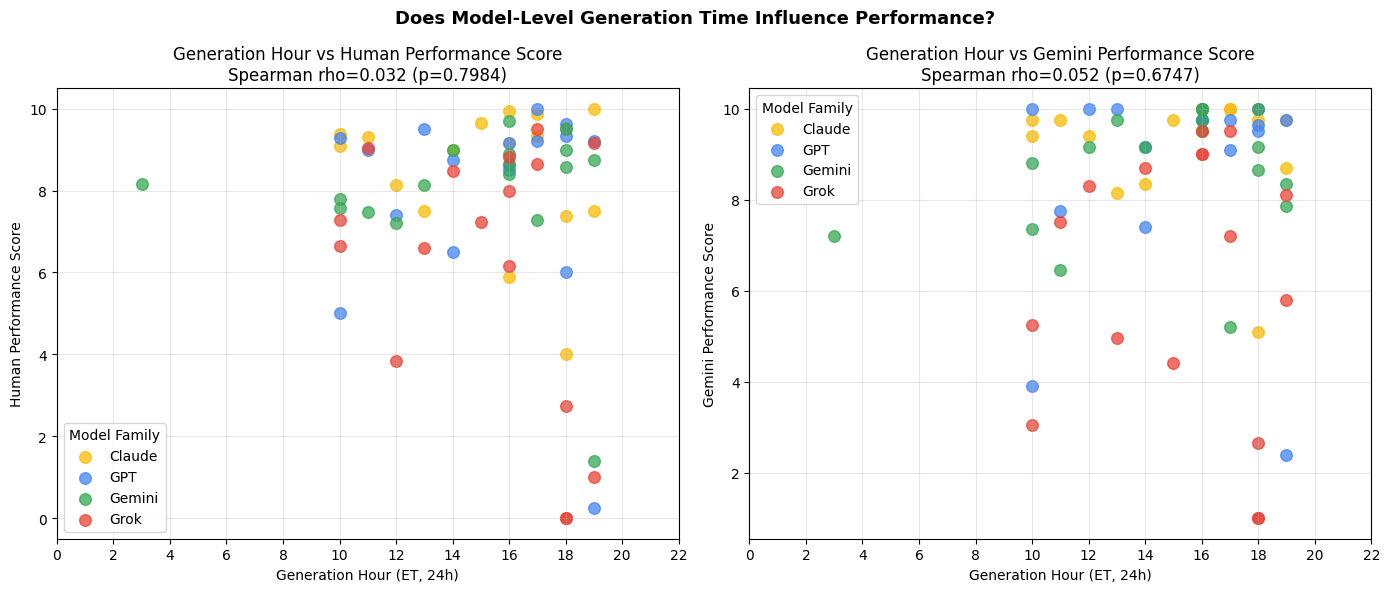

In [ ]:
generation_metrics = [
    ('Performance Score (0-10)', 'Human Performance Score'),
    ('gemini perf (0-10)', 'Gemini Performance Score')
]

generation_corr_rows = []
for y_col, label in generation_metrics:
    pr, pp = pearsonr(generation_perf_df['Generation_Hour'], generation_perf_df[y_col])
    sr, sp = spearmanr(generation_perf_df['Generation_Hour'], generation_perf_df[y_col])
    generation_corr_rows.append({
        'Outcome': label,
        'n': len(generation_perf_df),
        'Pearson_r': pr,
        'Pearson_p': pp,
        'Spearman_rho': sr,
        'Spearman_p': sp
    })

generation_hour_corr_df = pd.DataFrame(generation_corr_rows).round(4)
display(generation_hour_corr_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {
    'GPT': '#4285F4',
    'Gemini': '#34A853',
    'Grok': '#EA4335',
    'Claude': '#FBBC04'
}

for ax, (y_col, label), (_, corr_row) in zip(axes, generation_metrics, generation_hour_corr_df.iterrows()):
    for family, group in generation_perf_df.groupby('Model Family'):
        ax.scatter(
            group['Generation_Hour'],
            group[y_col],
            label=family,
            color=colors.get(family),
            s=70,
            alpha=0.75
        )
    ax.set_xlabel('Generation Hour (ET, 24h)')
    ax.set_ylabel(label)
    ax.set_title(
        f"Generation Hour vs {label}\n"
        f"Spearman rho={corr_row['Spearman_rho']:.3f} (p={corr_row['Spearman_p']:.4f})"
    )
    ax.set_xticks(range(0, 24, 2))
    ax.grid(alpha=0.3)
    ax.legend(title='Model Family')

plt.suptitle('Does Model-Level Generation Time Influence Performance?', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('figures/figure_16.png', dpi=300, bbox_inches='tight')
plt.show()

#### Does song voice gender influence X impressions?

Male   | n=10 | mean=48420 | median=24462
Female | n=7 | mean=52713 | median=24987
Mann-Whitney U=30.5, p=0.6961 (not significant)


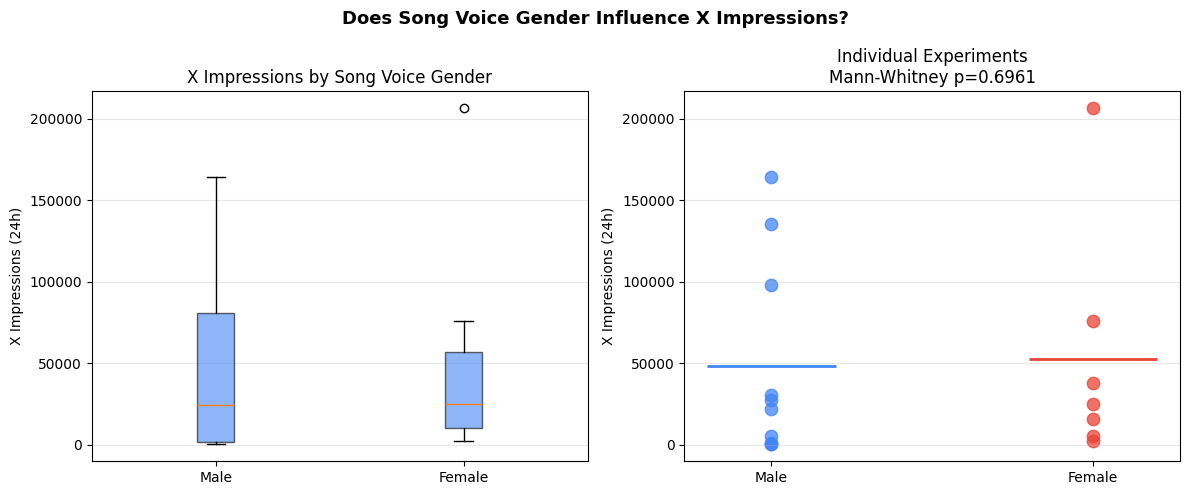

In [ ]:
from scipy.stats import mannwhitneyu

male = exp_df[exp_df['MaleFemale_song_voice'] == 1]['X_Impressions_24h']
female = exp_df[exp_df['MaleFemale_song_voice'] == 0]['X_Impressions_24h']

stat, p = mannwhitneyu(male, female, alternative='two-sided')
print(f'Male   | n={len(male)} | mean={male.mean():.0f} | median={male.median():.0f}')
print(f'Female | n={len(female)} | mean={female.mean():.0f} | median={female.median():.0f}')
print(f'Mann-Whitney U={stat:.1f}, p={p:.4f} {"*** SIGNIFICANT" if p < 0.05 else "(not significant)"}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([male, female], tick_labels=['Male', 'Female'], patch_artist=True, boxprops=dict(facecolor='#4285F4', alpha=0.6))
axes[0].set_ylabel('X Impressions (24h)')
axes[0].set_title('X Impressions by Song Voice Gender')
axes[0].grid(axis='y', alpha=0.3)

for vals, x, color, label in [(male, 1, '#4285F4', 'Male'), (female, 2, '#EA4335', 'Female')]:
    axes[1].scatter([x] * len(vals), vals, alpha=0.75, s=80, color=color, label=label)
    axes[1].hlines(vals.mean(), x - 0.2, x + 0.2, color=color, linewidth=2)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Male', 'Female'])
axes[1].set_ylabel('X Impressions (24h)')
axes[1].set_title(f'Individual Experiments\nMann-Whitney p={p:.4f}')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Does Song Voice Gender Influence X Impressions?', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('figures/figure_17.png', dpi=300, bbox_inches='tight')
plt.show()

#### Is the Day of the week and time the experiment is posted on X correlated with X impressions?

Day effect (Wednesday vs Saturday): U=31.5, p=0.7001
Posting hour vs impressions | Pearson r=-0.169 p=0.5156 | Spearman r=-0.432 p=0.0834


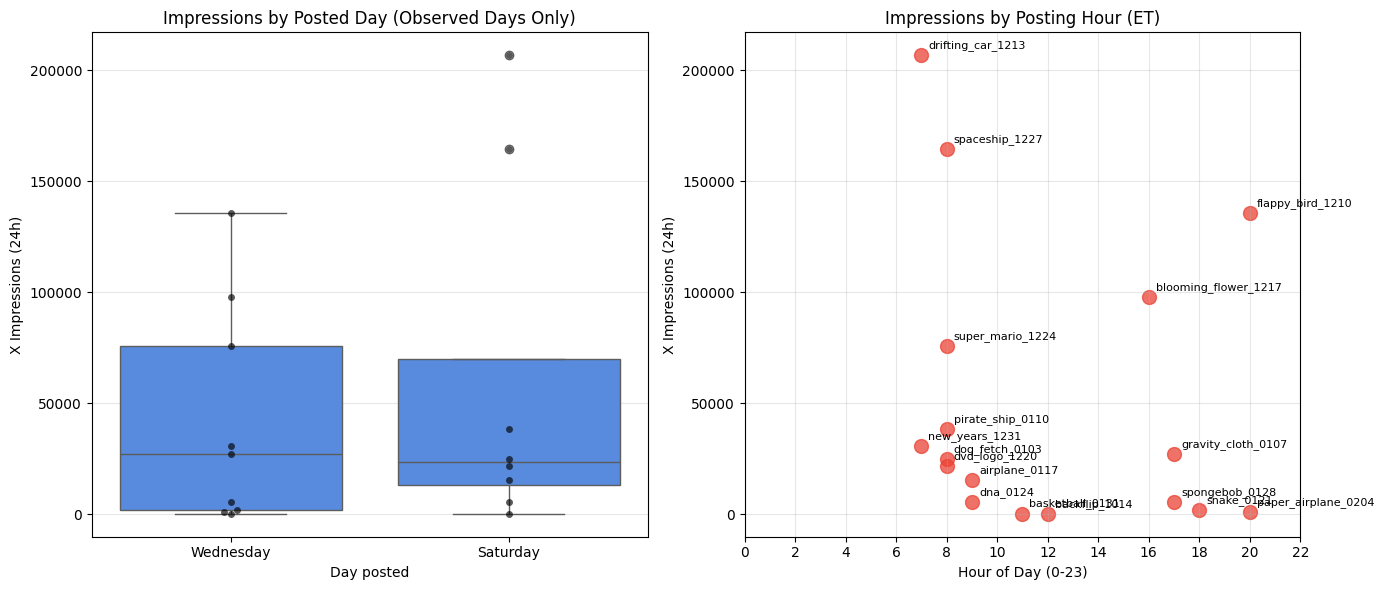

In [ ]:
from scipy.stats import pearsonr, spearmanr

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_df = exp_df.copy()
day_map = {0: 'Saturday', 1: 'Wednesday'}
plot_df['Day_posted_label'] = plot_df['Day_of_week_posted'].map(day_map)

sns.boxplot(
    x='Day_posted_label',
    y='X_Impressions_24h',
    data=plot_df,
    order=['Wednesday', 'Saturday'],
    ax=axes[0],
    color='#4285F4'
)
sns.swarmplot(
    x='Day_posted_label',
    y='X_Impressions_24h',
    data=plot_df,
    order=['Wednesday', 'Saturday'],
    ax=axes[0],
    color='black',
    alpha=0.65
)
axes[0].set_title('Impressions by Posted Day (Observed Days Only)')
axes[0].set_xlabel('Day posted')
axes[0].set_ylabel('X Impressions (24h)')
axes[0].grid(axis='y', alpha=0.3)

wed = plot_df.loc[plot_df['Day_of_week_posted'] == 1, 'X_Impressions_24h']
sat = plot_df.loc[plot_df['Day_of_week_posted'] == 0, 'X_Impressions_24h']
u, p_day = mannwhitneyu(wed, sat, alternative='two-sided')
print(f'Day effect (Wednesday vs Saturday): U={u:.1f}, p={p_day:.4f}')

axes[1].scatter(plot_df['Time_posted_X_hour'], plot_df['X_Impressions_24h'], color='#EA4335', s=100, alpha=0.75)
for _, row in plot_df.iterrows():
    axes[1].annotate(row['Experiment ID'], (row['Time_posted_X_hour'], row['X_Impressions_24h']), fontsize=8, xytext=(5, 5), textcoords='offset points')

axes[1].set_title('Impressions by Posting Hour (ET)')
axes[1].set_xlabel('Hour of Day (0-23)')
axes[1].set_ylabel('X Impressions (24h)')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, alpha=0.3)

pr, pp = pearsonr(plot_df['Time_posted_X_hour'], plot_df['X_Impressions_24h'])
sr, sp = spearmanr(plot_df['Time_posted_X_hour'], plot_df['X_Impressions_24h'])
print(f'Posting hour vs impressions | Pearson r={pr:.3f} p={pp:.4f} | Spearman r={sr:.3f} p={sp:.4f}')

plt.tight_layout()
fig.savefig('figures/figure_18.png', dpi=300, bbox_inches='tight')
plt.show()

#### Is the song style correlated with X impressions?

--- Song Style Frequency ---
Song_style
hip hop, pop                                                                                                                                        15
Trap, Southern hip-hop, Atlanta rap, Melodic rap, Gangsta rap, Modern hip-hop, Street rap, Drill-influenced rap, Bass-heavy rap, Minimalist trap     2
Name: count, dtype: int64

--- Mann-Whitney U ---
Statistic = 29.000, p = 0.0440
                                                    count      mean   median
Song_style                                                                  
Trap, Southern hip-hop, Atlanta rap, Melodic ra...      2    532.50    532.5
hip hop, pop                                           15  56808.93  27182.0


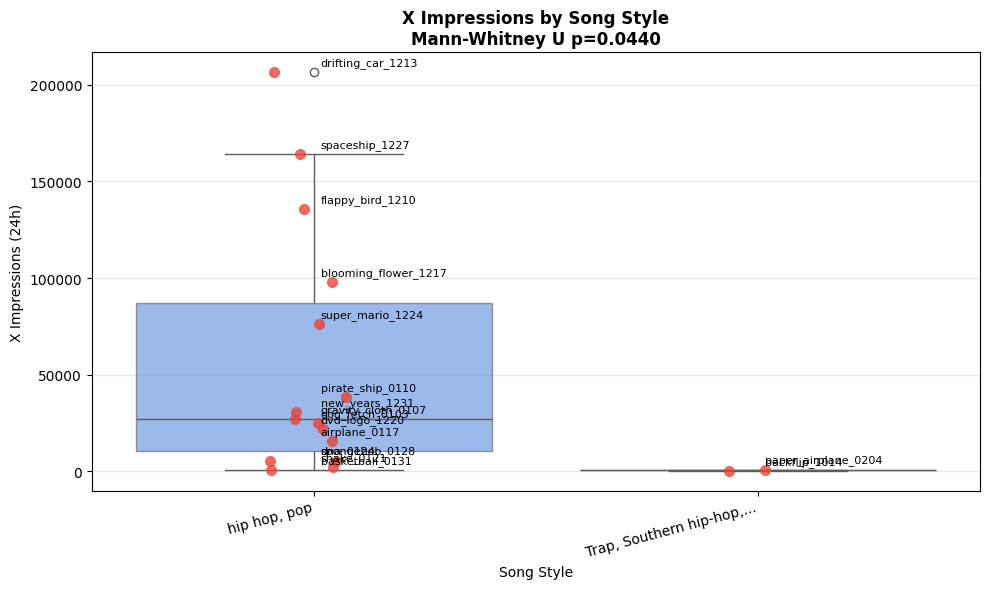

In [ ]:
import textwrap
from scipy.stats import kruskal, mannwhitneyu

style_df = exp_df[['Experiment ID', 'Song_style', 'X_Impressions_24h']].dropna().copy()
style_df['Song_style_short'] = style_df['Song_style'].apply(lambda x: textwrap.shorten(str(x), width=28, placeholder='...'))

print('--- Song Style Frequency ---')
print(style_df['Song_style'].value_counts())

styles = style_df['Song_style'].unique()
groups = [style_df.loc[style_df['Song_style'] == style, 'X_Impressions_24h'].values for style in styles]

if len(groups) == 2:
    stat, p = mannwhitneyu(groups[0], groups[1], alternative='two-sided')
    test_label = 'Mann-Whitney U'
elif len(groups) > 2:
    stat, p = kruskal(*groups)
    test_label = 'Kruskal-Wallis H'
else:
    stat, p = np.nan, np.nan
    test_label = 'No statistical test'

print(f'\n--- {test_label} ---')
print(f'Statistic = {stat:.3f}, p = {p:.4f}')
print(style_df.groupby('Song_style')['X_Impressions_24h'].agg(['count', 'mean', 'median']).round(2))

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='Song_style_short', y='X_Impressions_24h', data=style_df, ax=ax, color='#4285F4', boxprops=dict(alpha=0.6))
sns.stripplot(x='Song_style_short', y='X_Impressions_24h', data=style_df, ax=ax, color='#EA4335', size=8, alpha=0.8)

unique_shorts = style_df['Song_style_short'].unique().tolist()
for _, row in style_df.iterrows():
    x_pos = unique_shorts.index(row['Song_style_short'])
    ax.annotate(row['Experiment ID'], (x_pos, row['X_Impressions_24h']), fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.set_title(f'X Impressions by Song Style\n{test_label} p={p:.4f}', fontweight='bold')
ax.set_ylabel('X Impressions (24h)')
ax.set_xlabel('Song Style')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
fig.savefig('figures/figure_19.png', dpi=300, bbox_inches='tight')
plt.show()

The small number of experiments in each song-style group, together with time-dependent changes in impressions across the project, may make this result unstable.

#### Does prompt length correlate with X Impressions (24h)?

Pearson:  r=-0.269, p=0.2961
Spearman: r=-0.274, p=0.2864


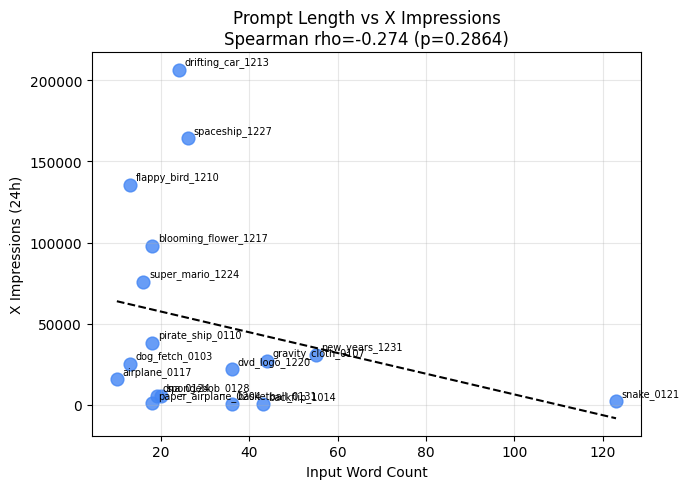

In [ ]:
prompt_len_df = df.groupby('Experiment ID', as_index=False).agg(
    Input_Word_Count=('Input Word Count', 'first'),
    X_Impressions_24h=('X Impressions (24 h)', 'first')
)

pr, pp = pearsonr(prompt_len_df['Input_Word_Count'], prompt_len_df['X_Impressions_24h'])
sr, sp = spearmanr(prompt_len_df['Input_Word_Count'], prompt_len_df['X_Impressions_24h'])
print(f'Pearson:  r={pr:.3f}, p={pp:.4f}')
print(f'Spearman: r={sr:.3f}, p={sp:.4f}')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(prompt_len_df['Input_Word_Count'], prompt_len_df['X_Impressions_24h'], color='#4285F4', s=85, alpha=0.8)
trend = np.polyfit(prompt_len_df['Input_Word_Count'], prompt_len_df['X_Impressions_24h'], 1)
trend_fn = np.poly1d(trend)
x_sorted = np.sort(prompt_len_df['Input_Word_Count'])
ax.plot(x_sorted, trend_fn(x_sorted), linestyle='--', color='black', linewidth=1.5)
for _, row in prompt_len_df.iterrows():
    ax.annotate(row['Experiment ID'], (row['Input_Word_Count'], row['X_Impressions_24h']), fontsize=7, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Input Word Count')
ax.set_ylabel('X Impressions (24h)')
ax.set_title(f'Prompt Length vs X Impressions\nSpearman rho={sr:.3f} (p={sp:.4f})')
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('figures/figure_20.png', dpi=300, bbox_inches='tight')
plt.show()

#### Are visual type and experiment type correlated with X impressions?

--- Statistical Analysis ---

Visual Type vs Impressions:
  Point-Biserial r: 0.213 (p=0.4112)
  Mann-Whitney U:   33.0 (p=0.4615)
  Mean (1=Simple): 57,510
  Mean (0=Complex): 26,392

Experiment Type vs Impressions:
  Point-Biserial r: 0.030 (p=0.9100)
  Mann-Whitney U:   24.0 (p=0.8651)
  Mean (1=Game): 53,498
  Mean (0=Simulation): 49,170


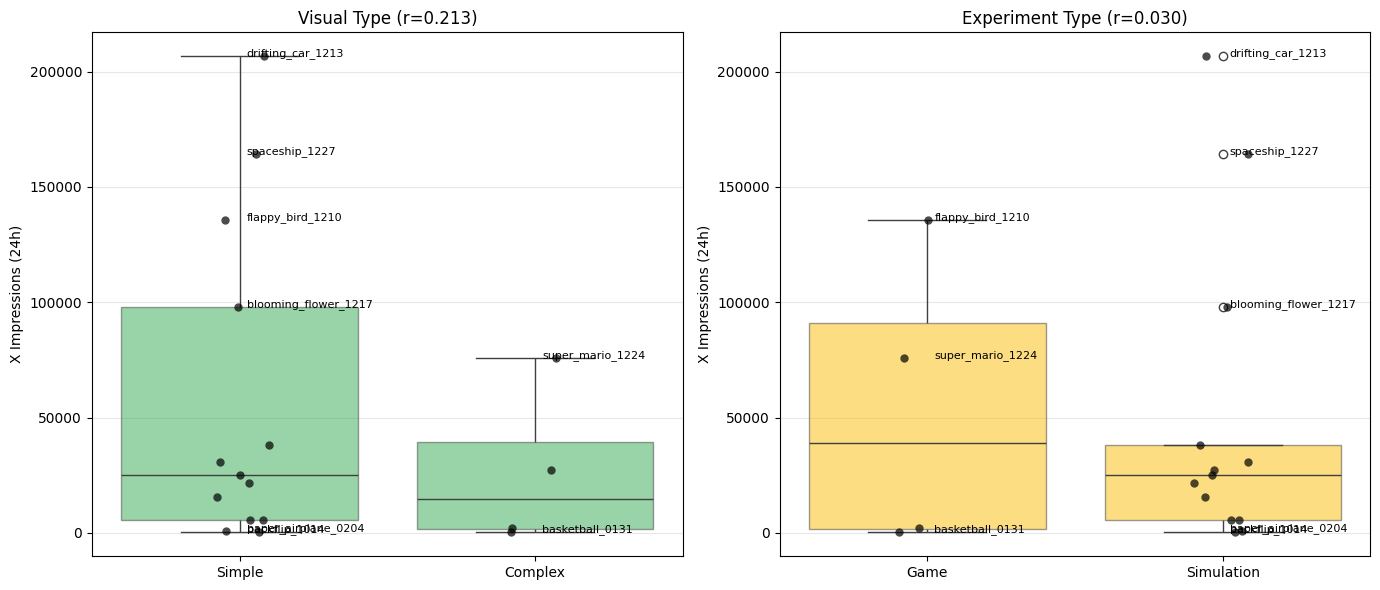

In [ ]:
from scipy.stats import pointbiserialr

analyses = [
    {
        'col': 'Visual_Type',
        'label': 'Visual Type',
        'mapping': {1: 'Simple', 0: 'Complex'},
        'color': '#34A853'
    },
    {
        'col': 'Experiment_Type',
        'label': 'Experiment Type',
        'mapping': {1: 'Game', 0: 'Simulation'},
        'color': '#FBBC04'
    }
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
print('--- Statistical Analysis ---')

for ax, analysis in zip(axes, analyses):
    col = analysis['col']
    clean_data = exp_df[[col, 'X_Impressions_24h']].dropna()
    r, p_corr = pointbiserialr(clean_data[col], clean_data['X_Impressions_24h'])

    group1 = clean_data[clean_data[col] == 1]['X_Impressions_24h']
    group0 = clean_data[clean_data[col] == 0]['X_Impressions_24h']
    u_stat, p_mann = mannwhitneyu(group1, group0)

    print(f"\n{analysis['label']} vs Impressions:")
    print(f'  Point-Biserial r: {r:.3f} (p={p_corr:.4f})')
    print(f'  Mann-Whitney U:   {u_stat:.1f} (p={p_mann:.4f})')
    print(f"  Mean (1={analysis['mapping'][1]}): {group1.mean():,.0f}")
    print(f"  Mean (0={analysis['mapping'][0]}): {group0.mean():,.0f}")

    plot_df = exp_df.copy()
    plot_df['Label'] = plot_df[col].map(analysis['mapping'])

    sns.boxplot(
        x='Label',
        y='X_Impressions_24h',
        data=plot_df,
        ax=ax,
        order=[analysis['mapping'][1], analysis['mapping'][0]],
        boxprops=dict(alpha=0.5, facecolor=analysis['color'])
    )
    sns.stripplot(
        x='Label',
        y='X_Impressions_24h',
        data=plot_df,
        ax=ax,
        order=[analysis['mapping'][1], analysis['mapping'][0]],
        color='black',
        size=6,
        alpha=0.7
    )

    for _, row in plot_df.iterrows():
        label = row['Label']
        x_idx = 0 if label == analysis['mapping'][1] else 1
        if row['X_Impressions_24h'] > 50000 or row['X_Impressions_24h'] < 1000:
            ax.annotate(row['Experiment ID'], (x_idx, row['X_Impressions_24h']), fontsize=8, xytext=(5, 0), textcoords='offset points')

    ax.set_title(f"{analysis['label']} (r={r:.3f})")
    ax.set_ylabel('X Impressions (24h)')
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig('figures/figure_21.png', dpi=300, bbox_inches='tight')
plt.show()

#### Correlation with target variable

--- Linear Correlation (Pearson) with X_Impressions_24h ---


,X_Impressions_24h
X_Likes_24h,0.955
X_Shares_24h,0.909
Perf_max,0.501
Time_posted_X_minute,0.430
Suno_version,0.272
Visual_Type,0.213
YouTube_Likes_24h,0.045
Experiment_Type,0.030
Lyrics_words,0.021
YouTube_Views_24h,0.005


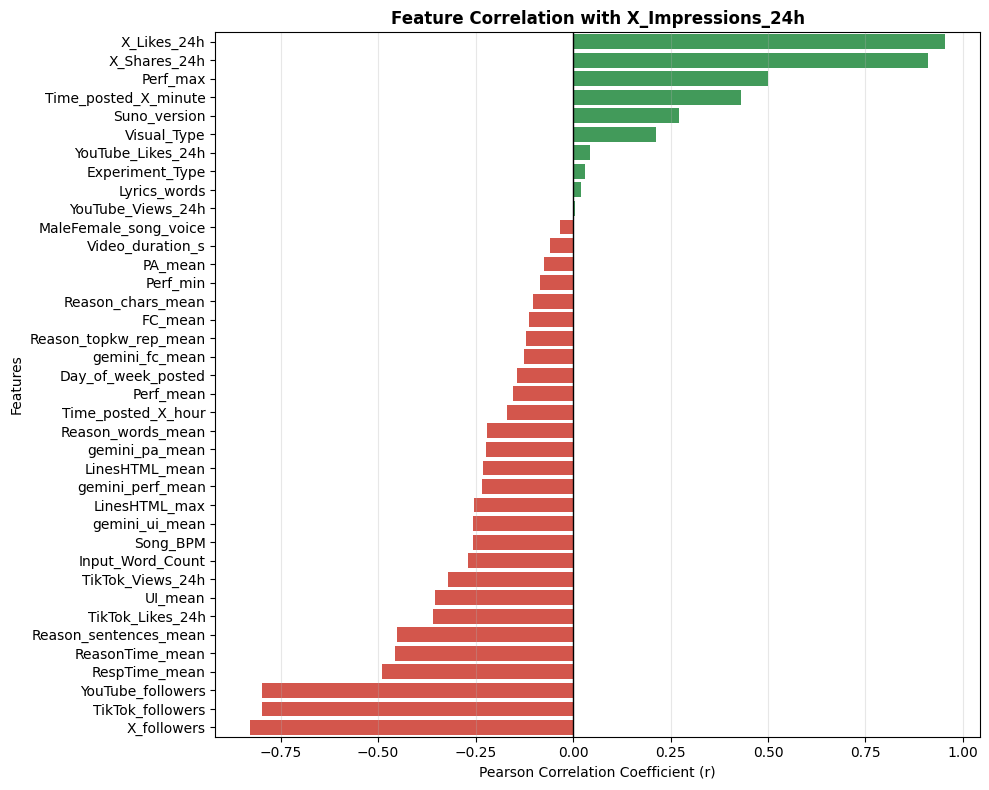

In [ ]:
target_col = 'X_Impressions_24h'

numeric_df = exp_df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()[[target_col]].drop(target_col).sort_values(by=target_col, ascending=False)

print(f'--- Linear Correlation (Pearson) with {target_col} ---')
display(correlations.round(3))

plt.figure(figsize=(10, 8))
colors = ['#34A853' if val > 0 else '#EA4335' for val in correlations[target_col]]
sns.barplot(x=correlations[target_col], y=correlations.index, hue=correlations.index, palette=colors, legend=False)

plt.axvline(x=0, color='black', linewidth=1)
plt.title(f'Feature Correlation with {target_col}', fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient (r)')
plt.ylabel('Features')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/figure_22.png', dpi=300, bbox_inches='tight')
plt.show()

<a name='1.4'></a>
## 1.4 - Feature Engineering (EDA)

<a name='1.4.1'></a>
### 1.4.1 - X Impressions

The initial Lasso screen considers a broader descriptive pool of pre-24h variables, including distribution context, evaluation scores, and generation metrics. This screen is exploratory and is used only for feature discovery. The final evaluated model is then restricted to the four pre-publication technical/audio variables described in the paper.

--- Exploratory Full-Sample Feature Screening (n=17) ---
This step is descriptive only and is not a valid out-of-sample evaluation.
In-sample R² (descriptive only): 0.977
Optimal Alpha: 0.0729
Intercept: 9.559

--- Top Features Selected by Exploratory Lasso Screen ---


YouTube_followers      -0.9823
ReasonTime_mean        -0.8271
Suno_version           -0.3847
Reasoning_Ratio_mean   -0.2644
TikTok_followers       -0.2486
Song_BPM               -0.2165
Video_duration_s       -0.0514
Time_posted_X_minute    0.0339
dtype: float64

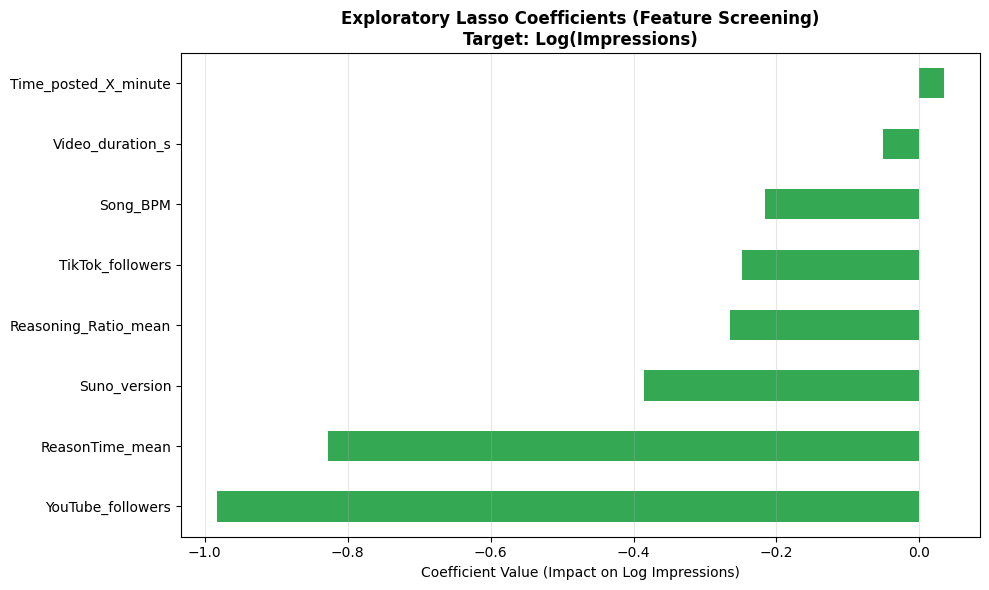

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score

leaky_cols = [
    'X_Likes_24h', 'X_Shares_24h',
    'TikTok_Views_24h', 'TikTok_Likes_24h',
    'YouTube_Views_24h', 'YouTube_Likes_24h',
    'Date_Generated', 'Date_posted',
    'Experiment ID', 'Prompt', 'Code_in_Reasoning_unique',
    'Song_style_short'
]

ml_df = exp_df.drop(columns=leaky_cols, errors='ignore').copy()
ml_df['Perf_Variance'] = ml_df['Perf_max'] - ml_df['Perf_min']
ml_df['Reasoning_Ratio_mean'] = ml_df['ReasonTime_mean'] / ml_df['RespTime_mean']
ml_df['Prompt_to_Code_Ratio'] = ml_df['LinesHTML_mean'] / ml_df['Input_Word_Count']

string_cols = ml_df.select_dtypes(include=['object', 'string']).columns
ml_df = ml_df.drop(columns=string_cols)

ml_df['Log_Impressions'] = np.log1p(ml_df['X_Impressions_24h'])
ml_df = ml_df.drop(columns=['X_Impressions_24h'])

X = ml_df.drop(columns=['Log_Impressions']).fillna(ml_df.drop(columns=['Log_Impressions']).median())
y = ml_df['Log_Impressions']

screening_scaler = StandardScaler()
X_scaled = screening_scaler.fit_transform(X)

lasso = LassoCV(cv=LeaveOneOut(), random_state=42, max_iter=10000)
lasso.fit(X_scaled, y)

y_pred = lasso.predict(X_scaled)
in_sample_r2 = r2_score(y, y_pred)

print(f'--- Exploratory Full-Sample Feature Screening (n={len(ml_df)}) ---')
print('This step is descriptive only and is not a valid out-of-sample evaluation.')
print(f'In-sample R² (descriptive only): {in_sample_r2:.3f}')
print(f'Optimal Alpha: {lasso.alpha_:.4f}')
print(f'Intercept: {lasso.intercept_:.3f}')

impressions_feature_screening = pd.Series(lasso.coef_, index=X.columns)
impressions_feature_screening = impressions_feature_screening[impressions_feature_screening != 0].sort_values(key=abs, ascending=False)

print('\n--- Top Features Selected by Exploratory Lasso Screen ---')
display(impressions_feature_screening.round(4))

plt.figure(figsize=(10, 6))
impressions_feature_screening.plot(kind='barh', color='#34A853')
plt.title('Exploratory Lasso Coefficients (Feature Screening)\nTarget: Log(Impressions)', fontweight='bold')
plt.xlabel('Coefficient Value (Impact on Log Impressions)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/figure_23.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
leaky_cols = [
    'X_Likes_24h', 'X_Shares_24h',
    'TikTok_Views_24h', 'TikTok_Likes_24h',
    'YouTube_Views_24h', 'YouTube_Likes_24h',
    'Date_Generated', 'Date_posted',
    'Experiment ID', 'Prompt', 'Code_in_Reasoning_unique',
    'Song_style_short'
]
ml_df = exp_df.drop(columns=leaky_cols, errors='ignore').copy()

ml_df['Perf_Variance'] = ml_df['Perf_max'] - ml_df['Perf_min']
ml_df['Reasoning_Ratio_mean'] = ml_df['ReasonTime_mean'] / ml_df['RespTime_mean']
ml_df['Prompt_to_Code_Ratio'] = ml_df['LinesHTML_mean'] / ml_df['Input_Word_Count']
ml_df['Log_Impressions'] = np.log1p(ml_df['X_Impressions_24h'])
ml_df = ml_df.drop(columns=['X_Impressions_24h'])

string_cols = ml_df.select_dtypes(include=['object', 'string']).columns
ml_df = ml_df.drop(columns=string_cols)

target_col = 'Log_Impressions'
feature_cols = [col for col in ml_df.columns if col != target_col]

print('Feature engineering complete. Target logged.\n')
print('-' * 40)
print(f" TARGET VARIABLE: '{target_col}'")
print('   (This represents the log-transformed 24h X Impressions)\n')
print(f'TOTAL CANDIDATE FEATURES: {len(feature_cols)}\n')
print('FEATURE COLUMNS POOL:')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i}. {col}')
print('-' * 40)

Feature engineering complete. Target logged.

----------------------------------------
 TARGET VARIABLE: 'Log_Impressions'
   (This represents the log-transformed 24h X Impressions)

TOTAL CANDIDATE FEATURES: 35

FEATURE COLUMNS POOL:
  1. Experiment_Type
  2. Visual_Type
  3. Input_Word_Count
  4. Day_of_week_posted
  5. Time_posted_X_hour
  6. Time_posted_X_minute
  7. X_followers
  8. TikTok_followers
  9. YouTube_followers
  10. Video_duration_s
  11. MaleFemale_song_voice
  12. Song_BPM
  13. Lyrics_words
  14. Suno_version
  15. Perf_mean
  16. Perf_max
  17. Perf_min
  18. PA_mean
  19. FC_mean
  20. UI_mean
  21. LinesHTML_mean
  22. LinesHTML_max
  23. ReasonTime_mean
  24. RespTime_mean
  25. Reason_words_mean
  26. Reason_chars_mean
  27. Reason_sentences_mean
  28. Reason_topkw_rep_mean
  29. gemini_pa_mean
  30. gemini_fc_mean
  31. gemini_ui_mean
  32. gemini_perf_mean
  33. Perf_Variance
  34. Reasoning_Ratio_mean
  35. Prompt_to_Code_Ratio
------------------------------

<a name='1.4.2'></a>
### 1.4.2 - HTML Lines

In [ ]:
# HTML lines feature engineering dataset
html_ml_df = df[['Experiment ID', 'Prompt', 'Input Word Count', 'LLM Model', 'Model Family', 'Lines of HTML']].dropna().copy()
html_ml_df['Prompt_Char_Count'] = html_ml_df['Prompt'].str.len()
html_ml_df['Prompt_Sentence_Count'] = html_ml_df['Prompt'].str.count(r'[.!?]') + 1
html_ml_df['Prompt_Words_per_Sentence'] = html_ml_df['Input Word Count'] / html_ml_df['Prompt_Sentence_Count'].replace(0, 1)

html_feature_cols = [
    'Prompt',
    'Input Word Count',
    'Prompt_Char_Count',
    'Prompt_Sentence_Count',
    'Prompt_Words_per_Sentence',
    'Model Family',
    'LLM Model'
]

print('HTML-lines modeling dataframe ready.')
print(f'Rows: {len(html_ml_df)} | Unique experiments: {html_ml_df["Experiment ID"].nunique()} | Unique model families: {html_ml_df["Model Family"].nunique()}')
print('\nCandidate features:')
for i, col in enumerate(html_feature_cols, 1):
    print(f'  {i}. {col}')

print('\nPreview:')
display(html_ml_df.head())

print('Prompt-derived feature summary:')
display(
    html_ml_df[['Input Word Count', 'Prompt_Char_Count', 'Prompt_Sentence_Count', 'Prompt_Words_per_Sentence', 'Lines of HTML']]
    .describe()
    .round(2)
)

print('Observed HTML-length averages by model family:')
display(
    html_ml_df.groupby('Model Family')['Lines of HTML']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .round(2)
)

HTML-lines modeling dataframe ready.
Rows: 68 | Unique experiments: 17 | Unique model families: 4

Candidate features:
  1. Prompt
  2. Input Word Count
  3. Prompt_Char_Count
  4. Prompt_Sentence_Count
  5. Prompt_Words_per_Sentence
  6. Model Family
  7. LLM Model

Preview:


,Experiment ID,Prompt,Input Word Count,LLM Model,Model Family,Lines of HTML,Prompt_Char_Count,Prompt_Sentence_Count,Prompt_Words_per_Sentence
0,flappy_bird_1210,Make a game like flappy bird using HTML/CSS/JS...,13,gpt-5.1-extended-thinking,GPT,427,68,1,13.0
1,flappy_bird_1210,Make a game like flappy bird using HTML/CSS/JS...,13,gemini-3-pro,Gemini,324,68,1,13.0
2,flappy_bird_1210,Make a game like flappy bird using HTML/CSS/JS...,13,grok-4.1-thinking,Grok,201,68,1,13.0
3,flappy_bird_1210,Make a game like flappy bird using HTML/CSS/JS...,13,opus-4.5-thinking-32k,Claude,503,68,1,13.0
4,drifting_car_1213,Create a 3D simulation of a formula 1 car perf...,24,gpt-5.2-extended-thinking,GPT,640,136,2,12.0


Prompt-derived feature summary:


,Input Word Count,Prompt_Char_Count,Prompt_Sentence_Count,Prompt_Words_per_Sentence,Lines of HTML
count,68.00,68.00,68.00,68.00,68.00
mean,31.29,189.88,3.00,9.88,496.40
std,26.27,159.87,1.51,3.34,297.77
min,10.00,64.00,1.00,4.33,108.00
25%,18.00,101.00,2.00,6.00,239.25
50%,20.00,114.00,3.00,10.75,465.00
75%,36.00,236.00,3.00,12.00,650.50
max,123.00,730.00,8.00,15.38,1422.00


Observed HTML-length averages by model family:


,count,mean,median,std,min,max
Model Family,,,,,,
Claude,17,732.65,682.0,238.74,459,1254
GPT,17,714.94,640.0,259.59,366,1422
Gemini,17,344.24,351.0,105.28,146,509
Grok,17,193.76,190.0,62.25,108,366


<a name='2'></a>
# 2 - Modeling

## 2.1 Predicting X Impressions (Exploratory)

--- Model Evaluation (Post-Screen LOOCV, Descriptive) ---


This is an exploratory experiment-level model for 24-hour X impressions in this dataset.
Mean Absolute Error: +/- 46,874 impressions
RMSE: 72,633 impressions
R-squared (Original Scale): -0.377

Largest misses:


,Experiment ID,Actual Impressions,Predicted Impressions,Absolute Error
6,drifting_car_1213,206661.0,24738.0,181923.0
11,paper_airplane_0204,851.0,126319.0,125468.0
8,flappy_bird_1210,135606.0,12273.0,123333.0
14,spaceship_1227,164249.0,43591.0,120658.0
3,blooming_flower_1217,97813.0,24418.0,73395.0
15,spongebob_0128,5502.0,60743.0,55241.0
4,dna_0124,5502.0,37286.0,31784.0
0,airplane_0117,15636.0,45412.0,29776.0
10,new_years_1231,30701.0,8307.0,22394.0
7,dvd_logo_1220,21741.0,33723.0,11982.0


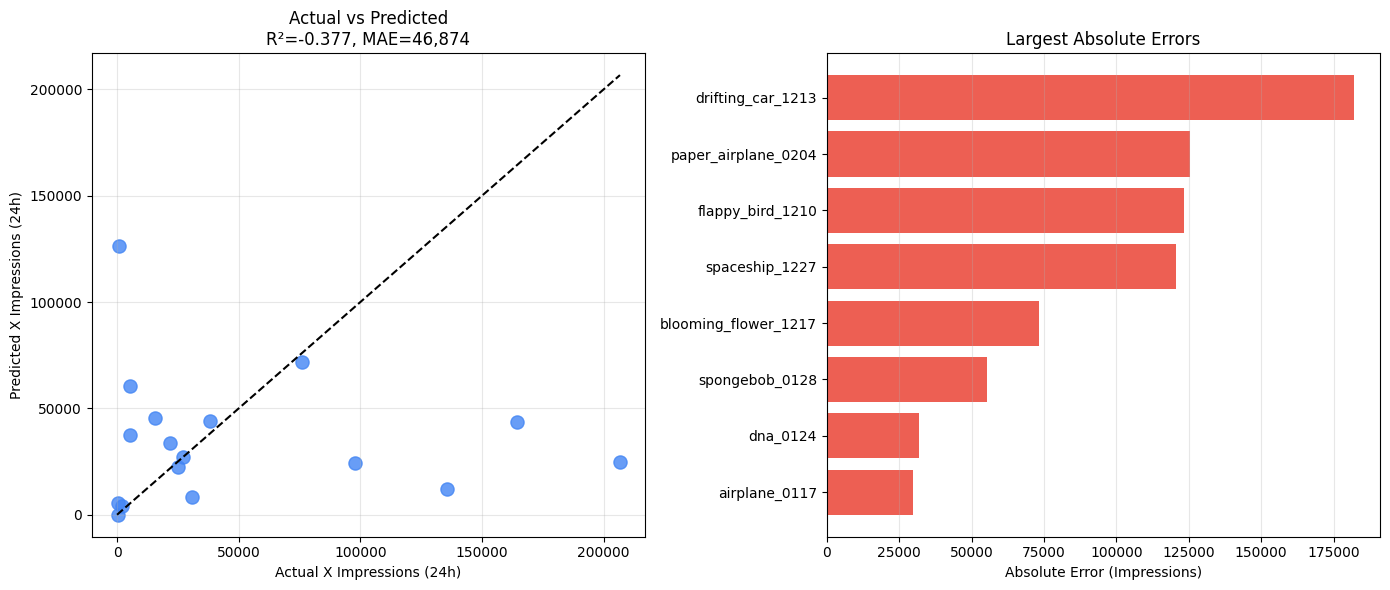


Final model coefficients:


ReasonTime_mean        -1.3093
Song_BPM               -0.3803
Suno_version           -0.2379
Reasoning_Ratio_mean   -0.1824
dtype: float64


--- Final Exploratory Model is Trained and Ready ---


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline

features = ['ReasonTime_mean', 'Suno_version', 'Song_BPM', 'Reasoning_Ratio_mean']

X = ml_df[features].fillna(ml_df[features].median())
y = ml_df['Log_Impressions']

impressions_cv_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

log_predictions = cross_val_predict(impressions_cv_model, X, y, cv=LeaveOneOut())

actual_impressions = np.expm1(y)
predicted_impressions = np.expm1(log_predictions)

impressions_model_mae = mean_absolute_error(actual_impressions, predicted_impressions)
impressions_model_rmse = root_mean_squared_error(actual_impressions, predicted_impressions)
impressions_model_r2 = r2_score(actual_impressions, predicted_impressions)

print('--- Model Evaluation (Post-Screen LOOCV, Descriptive) ---')
print('This is an exploratory experiment-level model for 24-hour X impressions in this dataset.')
print(f'Mean Absolute Error: +/- {impressions_model_mae:,.0f} impressions')
print(f'RMSE: {impressions_model_rmse:,.0f} impressions')
print(f'R-squared (Original Scale): {impressions_model_r2:.3f}')

impressions_prediction_df = pd.DataFrame({
    'Experiment ID': exp_df['Experiment ID'],
    'Actual Impressions': actual_impressions.round(0),
    'Predicted Impressions': predicted_impressions.round(0),
    'Absolute Error': np.abs(actual_impressions - predicted_impressions).round(0)
}).sort_values('Absolute Error', ascending=False)

print('\nLargest misses:')
display(impressions_prediction_df.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(actual_impressions, predicted_impressions, color='#4285F4', s=90, alpha=0.8)
max_val = max(actual_impressions.max(), predicted_impressions.max())
axes[0].plot([0, max_val], [0, max_val], linestyle='--', color='black', linewidth=1.5)
axes[0].set_xlabel('Actual X Impressions (24h)')
axes[0].set_ylabel('Predicted X Impressions (24h)')
axes[0].set_title(f'Actual vs Predicted\nR²={impressions_model_r2:.3f}, MAE={impressions_model_mae:,.0f}')
axes[0].grid(alpha=0.3)

plot_errors = impressions_prediction_df.head(8).sort_values('Absolute Error', ascending=True)
axes[1].barh(plot_errors['Experiment ID'], plot_errors['Absolute Error'], color='#EA4335', alpha=0.85)
axes[1].set_xlabel('Absolute Error (Impressions)')
axes[1].set_title('Largest Absolute Errors')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
fig.savefig('figures/figure_24.png', dpi=300, bbox_inches='tight')
plt.show()

final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
final_model.fit(X, y)

impressions_feature_coefficients = pd.Series(
    final_model.named_steps['ridge'].coef_,
    index=features
).sort_values(key=abs, ascending=False)
print('\nFinal model coefficients:')
display(impressions_feature_coefficients.round(4))
print('\n--- Final Exploratory Model is Trained and Ready ---')

<a name='2.2'></a>
## 2.2 - Predicting HTML Lines

--- HTML-lines model comparison (Leave-One-Experiment-Out) ---


,Model,MAE,RMSE,R2
0,Model family only,135.210,192.571,0.576
1,Input words + model family,139.576,208.834,0.501
2,Prompt text + input words + model family,148.450,214.960,0.471
3,Input words only,241.021,310.117,-0.101


Best out-of-sample model: Model family only

Largest misses for the best model:


,Experiment ID,Model Family,Actual HTML Lines,Predicted HTML Lines,Absolute Error
48,snake_0121,GPT,1422,659.2,762.8
47,airplane_0117,Claude,1254,687.6,566.4
19,super_mario_1224,Claude,1134,694.5,439.5
51,snake_0121,Claude,1085,696.7,388.3
12,dvd_logo_1220,GPT,366,723.4,357.4
16,super_mario_1224,GPT,1024,683.3,340.7
0,flappy_bird_1210,GPT,427,719.5,292.5
36,pirate_ship_0110,GPT,974,686.5,287.5
11,blooming_flower_1217,Claude,459,735.3,276.3
55,dna_0124,Claude,471,734.7,263.7


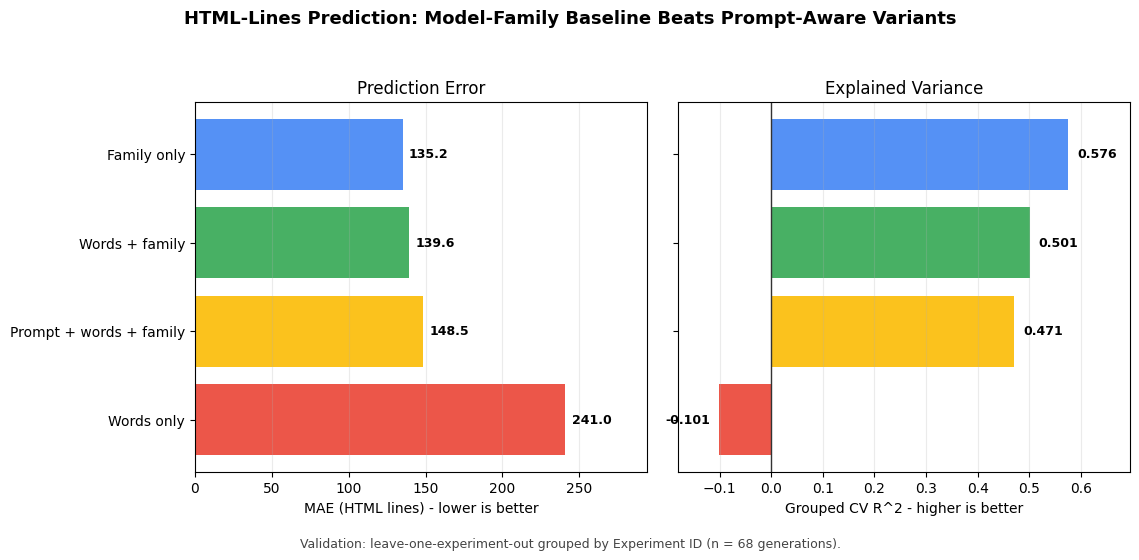


Final HTML models trained:
- Best out-of-sample model for this task: Model family only
- Prompt-aware comparison model kept for exploratory predictions in section 3.2


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

html_groups = html_ml_df['Experiment ID']
y_html = html_ml_df['Lines of HTML']

html_preprocessors = {
    'Input words only': ColumnTransformer([
        ('num', StandardScaler(), ['Input Word Count'])
    ], remainder='drop'),
    'Model family only': ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Model Family'])
    ], remainder='drop'),
    'Input words + model family': ColumnTransformer([
        ('num', StandardScaler(), ['Input Word Count']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Model Family'])
    ], remainder='drop'),
    'Prompt text + input words + model family': ColumnTransformer([
        ('prompt', TfidfVectorizer(ngram_range=(1, 2), stop_words='english', min_df=1), 'Prompt'),
        ('num', StandardScaler(), ['Input Word Count']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Model Family'])
    ], remainder='drop')
}

html_model_predictions = {}
results_rows = []
for name, preprocessor in html_preprocessors.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('ridge', Ridge(alpha=1.0))
    ])
    preds = cross_val_predict(pipe, html_ml_df, y_html, cv=LeaveOneGroupOut(), groups=html_groups)
    html_model_predictions[name] = preds
    results_rows.append({
        'Model': name,
        'MAE': mean_absolute_error(y_html, preds),
        'RMSE': root_mean_squared_error(y_html, preds),
        'R2': r2_score(y_html, preds)
    })

html_model_results_df = pd.DataFrame(results_rows).sort_values(['MAE', 'RMSE']).reset_index(drop=True)
print('--- HTML-lines model comparison (Leave-One-Experiment-Out) ---')
display(html_model_results_df.round(3))

best_html_model_name = html_model_results_df.loc[0, 'Model']
print(f'Best out-of-sample model: {best_html_model_name}')

html_best_prediction_df = pd.DataFrame({
    'Experiment ID': html_ml_df['Experiment ID'],
    'Model Family': html_ml_df['Model Family'],
    'Actual HTML Lines': y_html,
    'Predicted HTML Lines': np.round(html_model_predictions[best_html_model_name], 1),
    'Absolute Error': np.round(np.abs(y_html - html_model_predictions[best_html_model_name]), 1)
}).sort_values('Absolute Error', ascending=False)

print('\nLargest misses for the best model:')
display(html_best_prediction_df.head(12))

short_labels = {
    'Model family only': 'Family only',
    'Input words + model family': 'Words + family',
    'Prompt text + input words + model family': 'Prompt + words + family',
    'Input words only': 'Words only'
}
comparison_plot_df = html_model_results_df.copy()
comparison_plot_df['Label'] = comparison_plot_df['Model'].map(short_labels)
colors = ['#4285F4', '#34A853', '#FBBC04', '#EA4335']
ypos = range(len(comparison_plot_df))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.6), sharey=True)
fig.suptitle('HTML-Lines Prediction: Model-Family Baseline Beats Prompt-Aware Variants', fontsize=13, fontweight='bold', y=0.98)

axes[0].barh(list(ypos), comparison_plot_df['MAE'], color=colors, alpha=0.9)
axes[0].set_yticks(list(ypos))
axes[0].set_yticklabels(comparison_plot_df['Label'])
axes[0].invert_yaxis()
axes[0].set_xlabel('MAE (HTML lines) - lower is better')
axes[0].set_title('Prediction Error')
axes[0].grid(axis='x', alpha=0.25)
for y, value in zip(ypos, comparison_plot_df['MAE']):
    axes[0].text(value + 4, y, f'{value:.1f}', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlim(0, max(comparison_plot_df['MAE']) * 1.22)

axes[1].barh(list(ypos), comparison_plot_df['R2'], color=colors, alpha=0.9)
axes[1].axvline(0, color='#333333', linewidth=1)
axes[1].set_xlabel('Grouped CV R^2 - higher is better')
axes[1].set_title('Explained Variance')
axes[1].grid(axis='x', alpha=0.25)
for y, value in zip(ypos, comparison_plot_df['R2']):
    x = value + 0.018 if value >= 0 else value - 0.018
    ha = 'left' if value >= 0 else 'right'
    axes[1].text(x, y, f'{value:.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')
axes[1].set_xlim(min(comparison_plot_df['R2'].min() - 0.08, -0.16), max(comparison_plot_df['R2'].max() + 0.12, 0.65))

fig.text(0.5, 0.02, 'Validation: leave-one-experiment-out grouped by Experiment ID (n = 68 generations).', ha='center', fontsize=9, color='#444444')
plt.tight_layout(rect=[0, 0.05, 1, 0.94])
fig.savefig('figures/figure_25.png', dpi=300, bbox_inches='tight')
plt.show()

# Save a table image for the model comparison
fig_table, ax_table = plt.subplots(figsize=(12, 2.2 + 0.45 * len(html_model_results_df)))
ax_table.axis('off')
comparison_table = ax_table.table(
    cellText=html_model_results_df.round(3).values,
    colLabels=html_model_results_df.columns,
    loc='center'
)
comparison_table.auto_set_font_size(False)
comparison_table.set_fontsize(10)
comparison_table.scale(1, 1.4)
fig_table.tight_layout()
fig_table.savefig('tables/table_3.png', dpi=300, bbox_inches='tight')
plt.close(fig_table)

best_html_model = Pipeline([
    ('prep', html_preprocessors[best_html_model_name]),
    ('ridge', Ridge(alpha=1.0))
])
best_html_model.fit(html_ml_df, y_html)

prompt_aware_html_model = Pipeline([
    ('prep', html_preprocessors['Prompt text + input words + model family']),
    ('ridge', Ridge(alpha=1.0))
])
prompt_aware_html_model.fit(html_ml_df, y_html)

prompt_aware_html_mae = html_model_results_df.loc[
    html_model_results_df['Model'] == 'Prompt text + input words + model family',
    'MAE'
].iloc[0]

print('\nFinal HTML models trained:')
print(f'- Best out-of-sample model for this task: {best_html_model_name}')
print('- Prompt-aware comparison model kept for exploratory predictions in section 3.2')

<a name='3'></a>
# 3 - Predictions Playground

<a name='3.1'></a>
## 3.1 - X Impressions

In [ ]:
import gradio as gr

def predict_impressions(reason_time, suno_ver_str, bpm, reason_ratio):
    suno_ver = 1 if suno_ver_str == 'v4.5' else 0

    new_data = pd.DataFrame({
        'ReasonTime_mean': [reason_time],
        'Suno_version': [suno_ver],
        'Song_BPM': [bpm],
        'Reasoning_Ratio_mean': [reason_ratio]
    })

    pred_log = final_model.predict(new_data)[0]
    pred_actual = max(0, float(np.expm1(pred_log)))

    fig, ax = plt.subplots(figsize=(6, 4))
    historical_median = float(np.median(np.expm1(ml_df['Log_Impressions'])))
    values = [historical_median, pred_actual]
    categories = ['Historical Median', 'Predicted Impressions']
    colors = ['#888888', '#4285F4']

    bars = ax.bar(categories, values, color=colors)
    ax.set_ylabel('X Impressions (24h)')
    ax.set_title('Forecast vs Historical Baseline')

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + max(values) * 0.02,
            f'{height:,.0f}',
            ha='center',
            va='bottom',
            fontweight='bold'
        )

    ax.set_ylim(0, max(max(values) * 1.2, 35000))
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    forecast_text = f"{pred_actual:,.0f} Impressions"
    diagnostics = (
        f"Model MAE: +/- {impressions_model_mae:,.0f} impressions\n"
        f"Model RMSE: {impressions_model_rmse:,.0f} impressions\n"
        f"Post-screen CV R²: {impressions_model_r2:.3f}"
    )

    return forecast_text, diagnostics, fig

with gr.Blocks(theme=gr.themes.Soft()) as impressions_interface:
    gr.Markdown('# HTML AI Battle: 24-Hour X Impressions Explorer')
    gr.Markdown(
        f"""
**Algorithm:** Exploratory Ridge Regression (L2 Penalty)
**Validation:** Post-screen Leave-One-Out Cross-Validation with fold-local scaling/refitting
**Current Error:** +/- {impressions_model_mae:,.0f} impressions on average.

Use this to explore the model's learned directionality for 24-hour X impressions in this dataset, not as a reliable forecaster of broader social reach. With only 17 experiments behind the fit, the displayed error metrics are unstable and should be read descriptively.
"""
    )

    with gr.Row():
        with gr.Column():
            reason_time_input = gr.Slider(minimum=0, maximum=300, value=20, label='Avg Reasoning Time (seconds)')
            suno_ver_input = gr.Dropdown(choices=['v5', 'v4.5'], value='v5', label='Suno Version')
            bpm_input = gr.Slider(minimum=60, maximum=180, value=100, label='Song BPM')
            reason_ratio_input = gr.Slider(minimum=0.0, maximum=1.0, value=0.20, label='Reasoning Time Ratio (0 to 1)')
            predict_btn = gr.Button('Predict Impressions', variant='primary')

        with gr.Column():
            output_number = gr.Textbox(label='Predicted Target')
            diagnostics_box = gr.Textbox(label='Model Diagnostics', lines=3)
            output_plot = gr.Plot(label='Dynamic Comparison')

    predict_btn.click(
        fn=predict_impressions,
        inputs=[reason_time_input, suno_ver_input, bpm_input, reason_ratio_input],
        outputs=[output_number, diagnostics_box, output_plot]
    )

impressions_interface.launch(inline=True, prevent_thread_lock=True, quiet=True)


In [ ]:
# Interactive playground launched above. The interface is the main artifact for section 3.1.
print('3.1 playground ready: use the Gradio interface above to test custom inputs against the trained impressions model.')

3.1 playground ready: use the Gradio interface above to test custom inputs against the trained impressions model.


<a name='3.2'></a>
## 3.2 - HTML Lines

In [ ]:
import gradio as gr

def predict_html_lines(prompt_text, model_family):
    prompt_word_count = len(str(prompt_text).split())
    new_row = pd.DataFrame({
        'Prompt': [prompt_text],
        'Input Word Count': [prompt_word_count],
        'Model Family': [model_family]
    })

    baseline_pred = max(0, float(best_html_model.predict(new_row)[0]))
    prompt_aware_pred = max(0, float(prompt_aware_html_model.predict(new_row)[0]))

    fig, ax = plt.subplots(figsize=(6, 4))
    categories = [best_html_model_name, 'Prompt-aware model']
    values = [baseline_pred, prompt_aware_pred]
    colors = ['#4285F4', '#34A853']
    bars = ax.bar(categories, values, color=colors)
    ax.set_ylabel('Predicted HTML Lines')
    ax.set_title(f'HTML Length Forecast for {model_family}')
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + max(values) * 0.03,
            f'{height:,.0f}',
            ha='center',
            va='bottom',
            fontweight='bold'
        )
    ax.set_ylim(0, max(max(values) * 1.2, 400))
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    summary = (
        f"Prompt word count: {prompt_word_count}\n"
        f"{best_html_model_name}: {baseline_pred:,.0f} lines\n"
        f"Prompt-aware model: {prompt_aware_pred:,.0f} lines"
    )
    diagnostics = (
        f"Best baseline: {best_html_model_name}\n"
        f"Prompt-aware model MAE: +/- {prompt_aware_html_mae:.1f} lines\n"
        f"HTML best-model benchmark: MAE {html_model_results_df.loc[0, 'MAE']:.1f}, R² {html_model_results_df.loc[0, 'R2']:.3f}"
    )
    return summary, diagnostics, fig

sample_prompt = 'Build a single-file physics toy with one central interactive mechanic, polished motion, and a visible score overlay.'

with gr.Blocks(theme=gr.themes.Soft()) as html_interface:
    gr.Markdown('# HTML AI Battle: HTML Lines Predictor')
    gr.Markdown(
        """
Use this playground to estimate how verbose a generated HTML implementation will be for a given prompt and model family.
The interface shows both the best-performing baseline and the prompt-aware comparison model.
"""
    )

    with gr.Row():
        with gr.Column():
            prompt_input = gr.Textbox(value=sample_prompt, lines=5, label='Prompt')
            model_family_input = gr.Dropdown(choices=['GPT', 'Gemini', 'Grok', 'Claude'], value='GPT', label='Model Family')
            predict_btn = gr.Button('Predict HTML Lines', variant='primary')

        with gr.Column():
            output_summary = gr.Textbox(label='Prediction Summary', lines=4)
            diagnostics_box = gr.Textbox(label='Model Diagnostics', lines=3)
            output_plot = gr.Plot(label='Model Comparison')

    predict_btn.click(
        fn=predict_html_lines,
        inputs=[prompt_input, model_family_input],
        outputs=[output_summary, diagnostics_box, output_plot]
    )

html_interface.launch(inline=True, prevent_thread_lock=True, quiet=True)

<a name='4'></a>
# 4 - Conclusion

**How to Read These Results**

These results come from 17 "HTML AI Battle" experiments collected through public chat interfaces. The workflow was fixed, but the comparison is still observational rather than causal because model versions, interfaces, access paths, and collection timing were not fully controlled.

1. **Claude Had the Strongest Overall Results**
Claude achieved the highest weighted human score on **9 of 17 prompts**, compared with **6** for GPT, **1** for Gemini, and **1** for Grok.

* In direct prompt-paired comparisons, Claude beat GPT on **10 of 17** prompts, Gemini on **12 of 17** prompts with **1 tie**, and Grok on **15 of 17** prompts.
* The base **0.40 / 0.35 / 0.25** score uses author-chosen heuristic weights, so the sensitivity analysis across equal, adherence-heavy, function-heavy, and UI-heavy alternatives should be treated as the primary robustness check.
* Under every tested weight scheme, Claude still remained the top mean family. The closer GPT-versus-Gemini comparisons are more weight-sensitive and should be read more cautiously.

2. **More Compute Did Not Mean Better Quality**
Longer reasoning and longer total response times did not reliably improve output quality.

* Reasoning time was not meaningfully related to better human or Gemini performance overall.
* GPT produced the slowest extreme latency cases, while GPT and Claude were the most HTML-verbose families; neither pattern alone guaranteed better outcomes.
* Grok spent the highest share of its total time in reasoning, yet remained the weakest and most volatile family in the dataset.

3. **The Technical-Only Model Did Not Predict 24-Hour X Impressions Well**
The impressions model remained weak under the final post-screen LOOCV pipeline with fold-local scaling/refitting.

* The final Ridge model using technical and audio features reached **MAE ≈ 46.9k impressions**, **RMSE ≈ 72.6k**, and **post-screen CV R² = -0.377**, so it still underperformed a naive baseline.
* With only **17 experiments**, those LOOCV estimates are unstable, so this path should be read as inconclusive descriptive evidence of weak predictive signal rather than as a settled forecasting result.
* The biggest misses happened on the most extreme reach outliers, which suggests that 24-hour X exposure in this sample was driven mainly by factors outside the tracked technical variables.

4. **HTML Verbosity Was Predictable, Mostly from Model Family**
The second supervised-learning path produced a much clearer result than the X-impressions path.

* A **model-family-only** Ridge baseline achieved the best out-of-sample performance for HTML length prediction with **MAE ≈ 135 lines** and **R² = 0.576**.
* Adding prompt length or full prompt text did not improve over the model-family-only baseline in grouped validation; the full prompt-text model performed worse in this small sample.
* GPT and Claude were consistently the most verbose families, while Grok was the shortest by far.

5. **Takeaway**
The clearest split in the results is between **generation behavior** and **social behavior**. The models showed stable internal tendencies, especially in code verbosity, but the tracked technical variables did not carry enough stable signal to support a useful 24-hour X forecasting model in this dataset.


<a name='4.1'></a>
## 4.1 - Protocol Figure and Prompt-Paired Checks

This section includes:

1. a **protocol figure** summarizing the fixed public-interface workflow and the attached 24-hour platform data-collection step
2. a **prompt-paired comparison** showing that the Claude lead is visible beyond pooled family averages


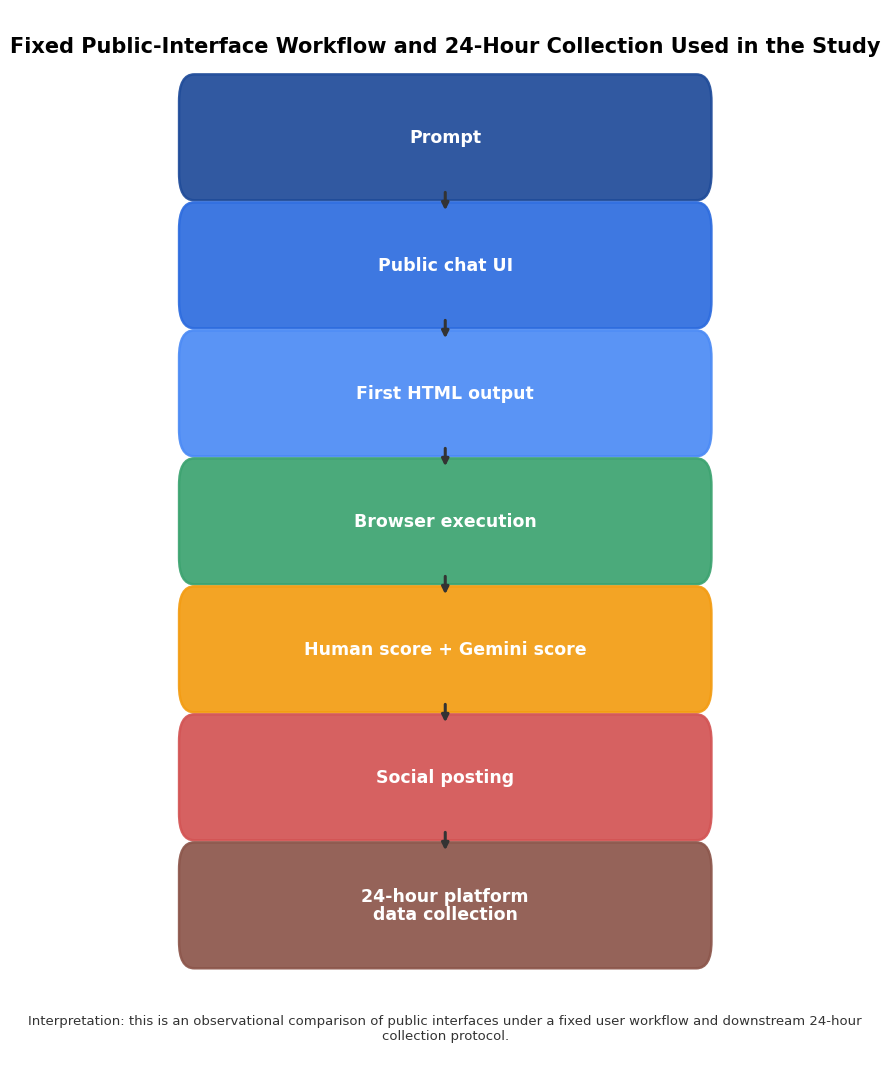

In [ ]:
from matplotlib.patches import FancyBboxPatch

protocol_steps = [
    'Prompt',
    'Public chat UI',
    'First HTML output',
    'Browser execution',
    'Human score + Gemini score',
    'Social posting',
    '24-hour platform\ndata collection'
]

step_colors = ['#1f4b99', '#2d6cdf', '#4c8bf5', '#3ca370', '#f39c12', '#d35454', '#8c564b']

fig, ax = plt.subplots(figsize=(8.5, 11))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

y_positions = [0.88, 0.76, 0.64, 0.52, 0.40, 0.28, 0.16]
box_width = 0.84
box_height = 0.078
x0 = 0.08

for i, (step, color, y) in enumerate(zip(protocol_steps, step_colors, y_positions)):
    box = FancyBboxPatch(
        (x0, y - box_height / 2),
        box_width,
        box_height,
        boxstyle='round,pad=0.02,rounding_size=0.025',
        linewidth=1.8,
        edgecolor=color,
        facecolor=color,
        alpha=0.92
    )
    ax.add_patch(box)
    ax.text(
        x0 + box_width / 2,
        y,
        step,
        ha='center',
        va='center',
        color='white',
        fontsize=12.5,
        fontweight='bold',
        linespacing=1.05
    )

    if i < len(protocol_steps) - 1:
        ax.annotate(
            '',
            xy=(0.5, y_positions[i + 1] + box_height / 2 + 0.01),
            xytext=(0.5, y - box_height / 2 - 0.01),
            arrowprops=dict(arrowstyle='-|>', lw=2.2, color='#333333')
        )

ax.text(
    0.5,
    0.975,
    'Fixed Public-Interface Workflow and 24-Hour Collection Used in the Study',
    ha='center',
    va='top',
    fontsize=15,
    fontweight='bold'
)
ax.text(
    0.5,
    0.045,
    'Interpretation: this is an observational comparison of public interfaces under a fixed user workflow and downstream 24-hour collection protocol.',
    ha='center',
    va='center',
    fontsize=9.5,
    color='#333333',
    wrap=True
)

plt.tight_layout(pad=1.2)
plt.savefig('figures/figure_28.png', dpi=300, bbox_inches='tight')
plt.show()


--- Prompt winners on the main weighted score ---


,Experiment ID,Model Family,Performance Score (0-10)
0,airplane_0117,GPT,9.33
1,backflip_1014,Claude,8.13
2,basketball_0131,Claude,9.38
3,blooming_flower_1217,Claude,9.93
4,dna_0124,Claude,9.53
5,dog_fetch_0103,GPT,9.28
6,drifting_car_1213,Claude,10.00
7,dvd_logo_1220,GPT,10.00
8,flappy_bird_1210,Claude,9.33
9,gravity_cloth_0107,Grok,8.83


--- Prompt win counts ---


,Model Family,Prompt wins
0,Claude,9
1,GPT,6
2,Gemini,1
3,Grok,1


--- Direct prompt-paired Claude comparisons ---


,Comparison,Claude wins,Ties,Claude losses,Mean gap,Median gap,Wilcoxon p
0,Claude vs GPT,10,0,7,0.549,0.13,0.579
1,Claude vs Gemini,12,1,4,0.539,0.68,0.179
2,Claude vs Grok,15,0,2,2.441,1.95,0.003


--- Weight sensitivity check (primary robustness test for the heuristic score) ---


,Weight scheme,Top mean family,Top mean score,Claude prompt wins
0,Author heuristic weights (0.40 / 0.35 / 0.25),Claude,8.505,9
1,Equal weights,Claude,8.524,9
2,Adherence-heavy,Claude,8.502,9
3,Function-heavy,Claude,8.477,8
4,UI-heavy,Claude,8.541,9


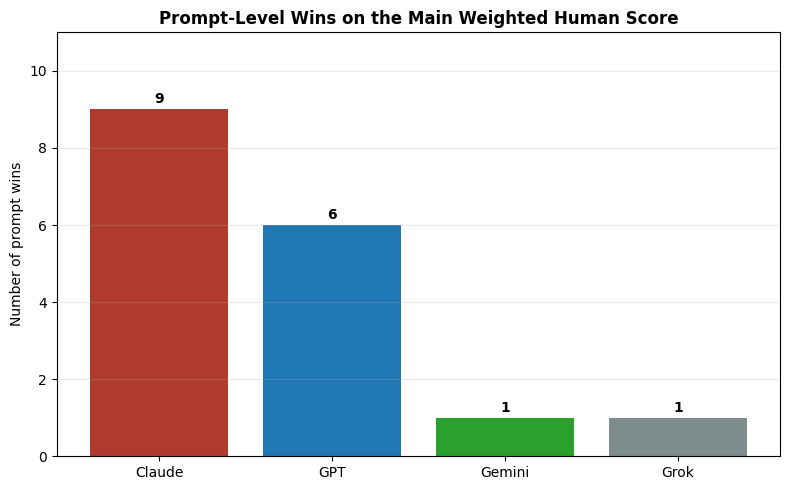

In [ ]:
from scipy.stats import wilcoxon
from IPython.display import display

robust_df = pd.read_excel('experiment_tracker.xlsx')
score_col = 'Performance Score (0-10)'
subscore_cols = [
    'prompt_adherence_score (0-10)',
    'functional_correctness_score (0-10)',
    'ui_score (0-10)'
]
family_order = ['Claude', 'GPT', 'Gemini', 'Grok']

prompt_winner_rows = robust_df.loc[
    robust_df.groupby('Experiment ID')[score_col].idxmax(),
    ['Experiment ID', 'Model Family', score_col]
].sort_values('Experiment ID')

prompt_win_counts = (
    prompt_winner_rows['Model Family']
    .value_counts()
    .reindex(family_order, fill_value=0)
    .rename('Prompt wins')
    .reset_index()
    .rename(columns={'index': 'Model Family'})
)

claude_scores = robust_df[robust_df['Model Family'] == 'Claude'][['Experiment ID', score_col]].rename(columns={score_col: 'Claude'})
pairwise_rows = []
for family in ['GPT', 'Gemini', 'Grok']:
    other_scores = robust_df[robust_df['Model Family'] == family][['Experiment ID', score_col]].rename(columns={score_col: family})
    paired = claude_scores.merge(other_scores, on='Experiment ID')
    diff = paired['Claude'] - paired[family]
    stat, p_value = wilcoxon(diff)
    pairwise_rows.append({
        'Comparison': f'Claude vs {family}',
        'Claude wins': int((diff > 0).sum()),
        'Ties': int((diff == 0).sum()),
        'Claude losses': int((diff < 0).sum()),
        'Mean gap': diff.mean(),
        'Median gap': diff.median(),
        'Wilcoxon p': p_value
    })

pairwise_df = pd.DataFrame(pairwise_rows)

weight_schemes = {
    'Author heuristic weights (0.40 / 0.35 / 0.25)': (0.40, 0.35, 0.25),
    'Equal weights': (1/3, 1/3, 1/3),
    'Adherence-heavy': (0.50, 0.30, 0.20),
    'Function-heavy': (0.30, 0.50, 0.20),
    'UI-heavy': (0.30, 0.30, 0.40),
}

weight_rows = []
for scheme_name, (w_pa, w_fc, w_ui) in weight_schemes.items():
    temp = robust_df.copy()
    temp['Alt Score'] = (
        w_pa * temp[subscore_cols[0]] +
        w_fc * temp[subscore_cols[1]] +
        w_ui * temp[subscore_cols[2]]
    )
    family_means = temp.groupby('Model Family')['Alt Score'].mean().sort_values(ascending=False)
    scheme_winners = temp.loc[temp.groupby('Experiment ID')['Alt Score'].idxmax(), 'Model Family'].value_counts()
    weight_rows.append({
        'Weight scheme': scheme_name,
        'Top mean family': family_means.index[0],
        'Top mean score': family_means.iloc[0],
        'Claude prompt wins': int(scheme_winners.get('Claude', 0))
    })

weight_sensitivity_df = pd.DataFrame(weight_rows)

print('--- Prompt winners on the main weighted score ---')
display(prompt_winner_rows.reset_index(drop=True))

print('--- Prompt win counts ---')
display(prompt_win_counts)

print('--- Direct prompt-paired Claude comparisons ---')
display(pairwise_df.round(3))

print('--- Weight sensitivity check (primary robustness test for the heuristic score) ---')
display(weight_sensitivity_df.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#b03a2e', '#1f77b4', '#2ca02c', '#7f8c8d']
ax.bar(prompt_win_counts['Model Family'], prompt_win_counts['Prompt wins'], color=colors)
ax.set_title('Prompt-Level Wins on the Main Weighted Human Score', fontweight='bold')
ax.set_ylabel('Number of prompt wins')
ax.set_ylim(0, max(prompt_win_counts['Prompt wins']) + 2)
ax.grid(axis='y', alpha=0.25)

for idx, row in prompt_win_counts.iterrows():
    ax.text(idx, row['Prompt wins'] + 0.08, int(row['Prompt wins']), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/figure_29.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation**

The protocol figure clarifies the correct causal framing: the study standardizes the **user workflow and downstream 24-hour collection steps**, not the underlying model environment. The prompt-paired check then shows that the Claude lead is not just a pooled-mean artifact. Because the main weighted score uses author-chosen heuristic weights, the strongest claim should come from the sensitivity analysis: Claude stayed top under every alternative weight scheme tested and had the clearest paired advantage over Grok, while the GPT and Gemini gaps are better described as directionally favorable and somewhat weight-sensitive rather than statistically definitive in this sample.


# Appendix: Mathematical Formulations from the Paper

## 1. Weighted Performance Score (Sperf)
For each model output $i$:

$$
S_{\text{perf},i} = 0.40 \cdot PA_i + 0.35 \cdot FC_i + 0.25 \cdot UI_i
$$
These are author-specified heuristic weights, not theory-derived or externally validated weights. They were chosen to create one practical summary score that prioritizes prompt adherence and functional correctness while still preserving UI as an important but secondary component. Because that choice is subjective, the alternative-weight sensitivity analysis should be treated as the primary robustness check.

## 2. Reasoning Efficiency (Er)
For each model output $i$:

$$
E_{r,i} = \frac{S_{\text{perf},i}}{t_{\text{reason},i}}
$$

When summarized at the experiment level, efficiency is averaged from the four model-level efficiencies:

$$
\bar{E}_{r,e} = \frac{1}{n_e}\sum_{i \in e} E_{r,i}
$$

This is not the same as dividing averaged performance by averaged reasoning time.

## 3. Score Vector & Cosine Similarity
Each evaluation is a vector $\mathbf{s}_i = [PA_i, FC_i, UI_i]^\top$.  
Directional agreement between two evaluations:
$$
\cos(\theta) = \frac{\mathbf{s}_a^\top \mathbf{s}_b}{\|\mathbf{s}_a\| \|\mathbf{s}_b\|}
$$

## 4. Eigen-analysis of Metric Alignment
Let $S$ be the centered score matrix (rows = evaluations, columns = PA/FC/UI).  
Covariance matrix:
$$
C = \frac{1}{n-1} S^\top S
$$
Eigendecomposition $C\mathbf{v}_k = \lambda_k \mathbf{v}_k$. The leading eigenvector $\mathbf{v}_1$ and eigenvalue $\lambda_1$ show the strongest co-movement pattern across PA, FC, and UI, but not why that pattern appears.


In [ ]:
from scipy.spatial.distance import cosine

appendix_model_df = df.copy()

appendix_model_df['Sperf'] = (
    0.40 * appendix_model_df['prompt_adherence_score (0-10)'] +
    0.35 * appendix_model_df['functional_correctness_score (0-10)'] +
    0.25 * appendix_model_df['ui_score (0-10)']
)
appendix_model_df['Reasoning_Efficiency'] = np.where(
    appendix_model_df['LLM Reasoning Time (s)'] > 0,
    appendix_model_df['Sperf'] / appendix_model_df['LLM Reasoning Time (s)'],
    np.nan
)

print('Model-level weighted Sperf and Reasoning Efficiency calculated.\n')
display(appendix_model_df[['Sperf', 'Reasoning_Efficiency']].describe().round(3))

appendix_exp_summary = (
    appendix_model_df.groupby('Experiment ID', as_index=False)
    .agg(
        Sperf_mean=('Sperf', 'mean'),
        Reasoning_Efficiency_mean=('Reasoning_Efficiency', 'mean'),
        ReasonTime_mean=('LLM Reasoning Time (s)', 'mean')
    )
)

print('\nExperiment-level summary averages per-model quantities; it is not Sperf_mean / ReasonTime_mean.\n')
display(appendix_exp_summary[['Sperf_mean', 'Reasoning_Efficiency_mean', 'ReasonTime_mean']].describe().round(3))

score_cols = [
    'prompt_adherence_score (0-10)',
    'functional_correctness_score (0-10)',
    'ui_score (0-10)'
]
score_matrix = appendix_model_df[score_cols].dropna().values

if len(score_matrix) >= 2:
    vec1 = score_matrix[0]
    vec2 = score_matrix[1]
    cos_sim = 1 - cosine(vec1, vec2)
    print(f'Example Cosine Similarity (row 0 vs row 1): {cos_sim:.4f}')

centered = score_matrix - score_matrix.mean(axis=0)
cov_matrix = np.cov(centered.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print('\nEigen-analysis of PA/FC/UI covariance:')
for i in range(3):
    print(
        f'  lambda{i+1} = {eigenvalues[i]:.4f} | '
        f'vector = [{eigenvectors[:, i][0]:.3f}, {eigenvectors[:, i][1]:.3f}, {eigenvectors[:, i][2]:.3f}]'
    )

print(f'\nTop co-movement pattern explains {eigenvalues[0] / eigenvalues.sum() * 100:.1f}% of score variance; this is descriptive and does not by itself distinguish shared quality from rubric overlap or scorer halo.')

Model-level weighted Sperf and Reasoning Efficiency calculated.



,Sperf,Reasoning_Efficiency
count,68.000,68.000
mean,7.624,0.444
std,2.510,0.480
min,0.000,0.000
25%,7.262,0.099
50%,8.600,0.354
75%,9.200,0.626
max,10.000,2.658



Experiment-level summary averages per-model quantities; it is not Sperf_mean / ReasonTime_mean.



,Sperf_mean,Reasoning_Efficiency_mean,ReasonTime_mean
count,17.000,17.000,17.000
mean,7.624,0.444,58.926
std,1.259,0.296,52.940
min,5.000,0.116,9.750
25%,6.811,0.246,27.500
50%,7.931,0.414,39.500
75%,8.698,0.530,52.250
max,9.162,1.150,213.250


Example Cosine Similarity (row 0 vs row 1): 0.9966

Eigen-analysis of PA/FC/UI covariance:
  lambda1 = 18.5046 | vector = [-0.607, -0.603, -0.518]
  lambda2 = 1.0005 | vector = [-0.222, -0.497, 0.839]
  lambda3 = 0.4390 | vector = [-0.763, 0.624, 0.168]

Top co-movement pattern explains 92.8% of score variance; this is descriptive and does not by itself distinguish shared quality from rubric overlap or scorer halo.


* Model-level weighted performance is solid: Sperf averages 7.62/10 across 68 model outputs, with wider spread than the old experiment-level summary because individual model failures are no longer averaged away.

* Model-level efficiency varies a lot: Reasoning Efficiency averages 0.44, has a median of 0.35, and ranges from 0.00 to 2.66, so some outputs deliver much more quality per second than others.

* Experiment-level appendix summaries average the four model-level efficiencies inside each experiment; they do not divide averaged performance by averaged reasoning time.

* Score shape is almost identical for the first two model outputs: cosine similarity 0.9966 means those rows trade off PA, FC, and UI in nearly the same proportions.

* Strong co-movement is present: The top eigen-direction explains about 92.8% of variance, so PA, FC, and UI rise and fall together empirically in this dataset.

* This is descriptive, not diagnostic: The same pattern could reflect true shared quality, rubric overlap, or halo effects from a single human scorer.

* UI contributes, but less than PA/FC: PC1 loads strongest on PA and FC, with a smaller (but still meaningful) UI component.

* Eigenvector signs do not matter: Only the relative magnitudes matter, because flipping the sign represents the same direction.
